In [ ]:
# ============================================================
# FIXED-CANDIDATE FULL CATALOG REBUILD
# ------------------------------------------------------------
# Frozen branch:
#   source: rho_eff ~ (1/r^2) d/dr [ r * V_bar^2 ]
#   screened field equation
#   fixed Rs = 1.5
#   shape map: V/V_flat = U/U_inf
#
# Frozen amplitude law:
#   U(r_t) = 0.6 U_inf
#   V_flat^2 = C * [r_t u(r_t)]^alpha * [Vbar^2(r_t)]^beta
#
# with fixed constants:
#   C     = 164.0
#   alpha = 0.175
#   beta  = 0.55
#
# No fitting in this script.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_fixed_candidate_catalog_rebuild")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

# ------------------------------------------------------------
# FIXED MODEL SETTINGS
# ------------------------------------------------------------

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")

    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

# ------------------------------------------------------------
# RUN FULL CATALOG
# ------------------------------------------------------------

rotmod_files = bootstrap_rotmods()
rotmod_map = {display_name_from_path(p): p for p in rotmod_files}

rows = []
fails = []

print("=" * 60)
print("RUNNING FIXED-CANDIDATE FULL CATALOG")
print("=" * 60)
print(f"Candidate files : {len(rotmod_files)}")
print(f"Fixed Rs        : {Rs_fixed}")
print(f"Fixed f         : {F_FRAC}")
print(f"Fixed alpha     : {ALPHA}")
print(f"Fixed beta      : {BETA}")
print(f"Fixed C         : {C_AMP}")
print()

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)

    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(
            max(R_MIN, float(np.min(r_obs)) * 0.5),
            max(float(np.max(r_obs)) * 1.10, 1.0),
            N_R
        )

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)

        U_inf = float(np.max(U))
        rt = radius_at_fraction(r, U, F_FRAC)

        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            raise RuntimeError("Invalid transition quantities")

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_obs = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar2_interp = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_pred = np.sqrt(max(C_AMP * carrier, 0.0))
        V_theory = V_flat_pred * U / max(U_inf, 1.0e-12)

        V_obs_pred = interp1d(
            r, V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(r_obs)

        rmse = safe_rmse(rot["vobs"], V_obs_pred)
        mae = safe_mae(rot["vobs"], V_obs_pred)
        chi2_mean = float(np.mean(((rot["vobs"] - V_obs_pred) / rot["ev"]) ** 2))

        obs_shape = rot["vobs"] / max(float(np.max(rot["vobs"])), 1.0e-12)
        pred_shape = V_obs_pred / max(float(np.max(V_obs_pred)), 1.0e-12)
        shape_rmse = safe_rmse(obs_shape, pred_shape)

        rows.append({
            "galaxy": galaxy,
            "n_points": len(r_obs),
            "r_max": float(np.max(r_obs)),
            "vmax_obs": float(np.max(rot["vobs"])),
            "Rs_fixed": Rs_fixed,
            "rt": rt,
            "u_t": u_t,
            "vbar2_t": vbar2_t,
            "carrier": carrier,
            "V_flat_pred": V_flat_pred,
            "rmse": rmse,
            "mae": mae,
            "chi2_mean": chi2_mean,
            "shape_rmse": shape_rmse,
        })

    except Exception as e:
        fails.append({"galaxy": galaxy, "reason": str(e)})

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

res_df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fails)

if len(res_df) == 0:
    raise RuntimeError("No successful galaxies processed.")

summary = {
    "successful_galaxies": int(len(res_df)),
    "failed_galaxies": int(len(fail_df)),
    "median_rmse": float(res_df["rmse"].median()),
    "mean_rmse": float(res_df["rmse"].mean()),
    "p90_rmse": float(np.percentile(res_df["rmse"], 90)),
    "p95_rmse": float(np.percentile(res_df["rmse"], 95)),
    "median_mae": float(res_df["mae"].median()),
    "median_chi2_mean": float(res_df["chi2_mean"].median()),
    "median_shape_rmse": float(res_df["shape_rmse"].median()),
}

best20 = res_df.sort_values("rmse").head(20).reset_index(drop=True)
worst20 = res_df.sort_values("rmse", ascending=False).head(20).reset_index(drop=True)

# Simple bins for tail view
res_df["vmax_bin"] = pd.cut(
    res_df["vmax_obs"],
    bins=[-np.inf, 80, 150, np.inf],
    labels=["low", "mid", "high"]
)

bin_summary = (
    res_df.groupby("vmax_bin", observed=True)[["rmse", "mae", "chi2_mean", "shape_rmse"]]
    .median()
    .reset_index()
)

print()
print("=" * 60)
print("FIXED-CANDIDATE SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"{k:22s} = {v}")

print()
print("=" * 60)
print("MEDIAN METRICS BY VMAX BIN")
print("=" * 60)
print(bin_summary.to_string(index=False))

print()
print("=" * 60)
print("BEST 20 BY RMSE")
print("=" * 60)
print(best20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("=" * 60)
print("WORST 20 BY RMSE")
print("=" * 60)
print(worst20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

RES_CSV = os.path.join(OUTDIR, "fixed_candidate_results.csv")
FAIL_CSV = os.path.join(OUTDIR, "fixed_candidate_failures.csv")
BEST_CSV_OUT = os.path.join(OUTDIR, "fixed_candidate_best20.csv")
WORST_CSV_OUT = os.path.join(OUTDIR, "fixed_candidate_worst20.csv")
BIN_CSV = os.path.join(OUTDIR, "fixed_candidate_bin_summary.csv")
TXT_OUT = os.path.join(OUTDIR, "fixed_candidate_summary.txt")

res_df.to_csv(RES_CSV, index=False)
fail_df.to_csv(FAIL_CSV, index=False)
best20.to_csv(BEST_CSV_OUT, index=False)
worst20.to_csv(WORST_CSV_OUT, index=False)
bin_summary.to_csv(BIN_CSV, index=False)

with open(TXT_OUT, "w", encoding="utf-8") as f:
    f.write("FIXED-CANDIDATE SUMMARY\n")
    f.write("=" * 60 + "\n")
    for k, v in summary.items():
        f.write(f"{k:22s} = {v}\n")
    f.write("\nMEDIAN METRICS BY VMAX BIN\n")
    f.write("=" * 60 + "\n")
    f.write(bin_summary.to_string(index=False))
    f.write("\n\nBEST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(best20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))
    f.write("\n\nWORST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

Auto-extracting LTG rotmods from: /content/Rotmod_LTG (4).zip
RUNNING FIXED-CANDIDATE FULL CATALOG
Candidate files : 175
Fixed Rs        : 1.5
Fixed f         : 0.6
Fixed alpha     : 0.175
Fixed beta      : 0.55
Fixed C         : 164.0

Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

FIXED-CANDIDATE SUMMARY
successful_galaxies    = 175
failed_galaxies        = 0
median_rmse            = 20.38786367728187
mean_rmse              = 32.72222113537459
p90_rmse               = 77.35749478059131
p95_rmse               = 88.8575199776623
median_mae             = 17.608721572718746
median_chi2_mean       = 26.12511787253237
median_shape_rmse      = 0.15760201986858705

MEDIAN METRICS BY VMAX BIN
vmax_bin      rmse       mae  chi2_mean  shape_rmse
     low 11.457480 10.528257  14.716546    0.128219
     mid 18.074875 15.106115  13.274674    0.115517
    hig

In [ ]:
# ============================================================
# HIGH-END AMPLITUDE TAIL CORRECTION TEST
# ------------------------------------------------------------
# Fixed base branch:
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat,base^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Tail correction:
#   V_flat,corr = V_flat,base * [1 + eta * (Vbar2_t / V0^2)^delta]
#
# Only amplitude is modified. Source/field/shape stay fixed.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_high_end_tail_correction")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

ETA_LIST   = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30]
DELTA_LIST = [0.25, 0.50, 0.75, 1.00]
V0_LIST    = [120.0, 150.0, 180.0, 210.0, 240.0]

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("BUILDING TAIL-CORRECTION TABLE")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_obs = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar2_interp = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_base = np.sqrt(max(C_AMP * carrier, 0.0))

        rows.append({
            "galaxy": galaxy,
            "vmax_obs": float(np.max(rot["vobs"])),
            "vbar2_t": vbar2_t,
            "V_flat_base": V_flat_base,
            "r_obs": rot["r"],
            "v_obs": rot["vobs"],
            "e_obs": rot["ev"],
            "r_grid": r,
            "U_grid": U,
            "U_inf": U_inf,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)

summary_rows = []

for eta in ETA_LIST:
    for delta in DELTA_LIST:
        for V0 in V0_LIST:
            rmses = []
            vmax_bins = []

            for _, row in df.iterrows():
                correction = 1.0 + eta * (row["vbar2_t"] / (V0**2)) ** delta
                V_flat_pred = row["V_flat_base"] * correction
                V_theory = V_flat_pred * row["U_grid"] / max(row["U_inf"], 1.0e-12)

                V_obs_pred = interp1d(
                    row["r_grid"], V_theory,
                    kind="linear", bounds_error=False, fill_value="extrapolate"
                )(row["r_obs"])

                rmse = safe_rmse(row["v_obs"], V_obs_pred)
                rmses.append(rmse)
                vmax_bins.append(row["vmax_obs"])

            rmses = np.asarray(rmses, float)
            vmax_bins = np.asarray(vmax_bins, float)

            high_mask = vmax_bins >= 150.0
            high_med = np.nan if np.sum(high_mask) == 0 else float(np.median(rmses[high_mask]))

            summary_rows.append({
                "eta": eta,
                "delta": delta,
                "V0": V0,
                "median_rmse": float(np.median(rmses)),
                "p90_rmse": float(np.percentile(rmses, 90)),
                "high_bin_median_rmse": high_med,
            })

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["high_bin_median_rmse", "median_rmse", "p90_rmse"]
).reset_index(drop=True)

print()
print("=" * 60)
print("HIGH-END TAIL CORRECTION SUMMARY")
print("=" * 60)
print(summary_df.head(25).to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "high_end_tail_correction_summary.csv"), index=False)

with open(os.path.join(OUTDIR, "high_end_tail_correction_summary.txt"), "w", encoding="utf-8") as f:
    f.write("HIGH-END TAIL CORRECTION SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

BUILDING TAIL-CORRECTION TABLE
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

HIGH-END TAIL CORRECTION SUMMARY
 eta  delta    V0  median_rmse  p90_rmse  high_bin_median_rmse
0.00   0.25 120.0    20.387864 77.357495             63.789441
0.00   0.25 150.0    20.387864 77.357495             63.789441
0.00   0.25 180.0    20.387864 77.357495             63.789441
0.00   0.25 210.0    20.387864 77.357495             63.789441
0.00   0.25 240.0    20.387864 77.357495             63.789441
0.00   0.50 120.0    20.387864 77.357495             63.789441
0.00   0.50 150.0    20.387864 77.357495             63.789441
0.00   0.50 180.0    20.387864 77.357495             63.789441
0.00   0.50 210.0    20.387864 77.357495             63.789441
0.00   0.50 240.0    20.387864 77.357495             63.789441
0.00   0.75 120.0    20.387864 77.357495             6

In [ ]:
# ============================================================
# HIGH-END FAILURE-MODE AUDIT
# ------------------------------------------------------------
# Audits the fixed candidate branch:
#
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Focus:
#   Understand what the worst high-vmax failures share.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_high_end_failure_audit")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

HIGH_VMAX_CUT = 150.0

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files
    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break
    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")
    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_components(rot):
    vgas2  = np.maximum(rot["vgas"] * np.abs(rot["vgas"]), 0.0)
    vdisk2 = np.maximum(UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]), 0.0)
    vbul2  = np.maximum(UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]), 0.0)
    vbar2  = vgas2 + vdisk2 + vbul2
    return vgas2, vdisk2, vbul2, vbar2

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    _, _, _, vbar2 = vbar2_components(rot)
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("RUNNING FAILURE-MODE AUDIT")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")

        vgas2, vdisk2, vbul2, vbar2_obs = vbar2_components(rot)
        vgas2_i  = interp1d(rot["r"], vgas2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vdisk2_i = interp1d(rot["r"], vdisk2, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbul2_i  = interp1d(rot["r"], vbul2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_i  = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vgas2_t = max(float(vgas2_i(rt)), 0.0)
        vdisk2_t = max(float(vdisk2_i(rt)), 0.0)
        vbul2_t = max(float(vbul2_i(rt)), 0.0)
        vbar2_t = max(float(vbar2_i(rt)), 1.0e-30)

        bulge_frac_t = vbul2_t / vbar2_t if vbar2_t > 0 else np.nan
        disk_frac_t = vdisk2_t / vbar2_t if vbar2_t > 0 else np.nan
        gas_frac_t = vgas2_t / vbar2_t if vbar2_t > 0 else np.nan

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_pred = np.sqrt(max(C_AMP * carrier, 0.0))
        V_theory = V_flat_pred * U / max(U_inf, 1.0e-12)

        V_obs_pred = interp1d(
            r, V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(r_obs)

        rmse = safe_rmse(rot["vobs"], V_obs_pred)
        mae = safe_mae(rot["vobs"], V_obs_pred)

        rows.append({
            "galaxy": galaxy,
            "n_points": len(r_obs),
            "r_max": float(np.max(r_obs)),
            "vmax_obs": float(np.max(rot["vobs"])),
            "rt": rt,
            "rt_over_rmax": rt / max(float(np.max(r_obs)), 1.0e-12),
            "u_t": u_t,
            "rt_ut": rt * u_t,
            "vbar2_t": vbar2_t,
            "vbar_t": np.sqrt(vbar2_t),
            "bulge_frac_t": bulge_frac_t,
            "disk_frac_t": disk_frac_t,
            "gas_frac_t": gas_frac_t,
            "V_flat_pred": V_flat_pred,
            "Vflat_over_vmax": V_flat_pred / max(float(np.max(rot["vobs"])), 1.0e-12),
            "rmse": rmse,
            "mae": mae,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)
high = df[df["vmax_obs"] >= HIGH_VMAX_CUT].copy().sort_values("rmse", ascending=False).reset_index(drop=True)

worst20 = high.head(20).copy()
best20 = high.tail(20).copy().sort_values("rmse").reset_index(drop=True)

summary_vars = [
    "vmax_obs", "r_max", "rt", "rt_over_rmax", "u_t", "rt_ut",
    "vbar2_t", "vbar_t", "bulge_frac_t", "disk_frac_t", "gas_frac_t",
    "V_flat_pred", "Vflat_over_vmax", "rmse", "mae"
]

summary_df = pd.DataFrame({
    "quantity": summary_vars,
    "worst20_median": [float(worst20[c].median()) for c in summary_vars],
    "best20_median": [float(best20[c].median()) for c in summary_vars],
})
summary_df["worst_minus_best"] = summary_df["worst20_median"] - summary_df["best20_median"]

print()
print("=" * 60)
print("HIGH-END FAILURE AUDIT SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))

print()
print("=" * 60)
print("WORST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(worst20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

print()
print("=" * 60)
print("BEST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(best20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "high_end_failure_summary.csv"), index=False)
worst20.to_csv(os.path.join(OUTDIR, "high_end_worst20.csv"), index=False)
best20.to_csv(os.path.join(OUTDIR, "high_end_best20.csv"), index=False)
df.to_csv(os.path.join(OUTDIR, "high_end_full_audit.csv"), index=False)

with open(os.path.join(OUTDIR, "high_end_failure_summary.txt"), "w", encoding="utf-8") as f:
    f.write("HIGH-END FAILURE AUDIT SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nWORST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))
    f.write("\n\nBEST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(best20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

RUNNING FAILURE-MODE AUDIT
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

HIGH-END FAILURE AUDIT SUMMARY
       quantity  worst20_median  best20_median  worst_minus_best
       vmax_obs      274.000000     186.000000         88.000000
          r_max       44.215000      26.930000         17.285000
             rt        4.236476       3.368903          0.867573
   rt_over_rmax        0.154626       0.124820          0.029805
            u_t        0.097594       0.084961          0.012633
          rt_ut        0.423070       0.275523          0.147548
        vbar2_t    77995.021748   35983.678528      42011.343220
         vbar_t      279.272915     189.684292         89.588623
   bulge_frac_t        0.281828       0.000000          0.281828
    disk_frac_t        0.717890       0.987273         -0.269383
     gas_frac_t        0.000091       

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import minimize_scalar
from numpy.linalg import lstsq

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 80

# locked local closure
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = np.isfinite(r) & np.isfinite(vo) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (vo > 0)
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
    gb = vb2 / np.maximum(r, EPS)

    Menc = np.maximum(r * vb2 / G, EPS)
    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]
    Phi = G * Mtot / np.maximum(Rmax, EPS)

    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "gb": np.maximum(gb, EPS),
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Phi": Phi,
        "Cgeom": Cgeom,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
        "logPhi": np.log10(Phi),
        "logCgeom": np.log10(Cgeom),
    }

def solve_qshape(r, source, F0):
    Fsrc = cumulative_trapz((r**DELTA) * source, r)
    F = Fsrc + F0
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base**(1.0/(P-1.0))
    return np.maximum(r * Mp, EPS)**QEXP

galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None:
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

# ------------------------------------------------------------
# Step 1: best-F0 per galaxy + sign-class
# ------------------------------------------------------------
LOGF0_MIN = -2.0
LOGF0_MAX = 12.0

rows = []

for g in galaxies:
    r = g["r"]
    vo = g["vo"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS))**MEXP))
    source = rho3d * activation

    def objective(logF0):
        F0 = 10.0**logF0
        qshape = solve_qshape(r, source, F0)
        C = np.sum((vo**2) * qshape) / np.maximum(np.sum(qshape**2), EPS)
        vp = np.sqrt(np.maximum(C * qshape, 0.0))
        return np.sqrt(np.mean((vo - vp)**2))

    res = minimize_scalar(
        objective,
        bounds=(LOGF0_MIN, LOGF0_MAX),
        method="bounded",
        options={"xatol": 1e-3}
    )

    best_logF0 = float(res.x)
    best_F0 = 10.0**best_logF0
    qshape = solve_qshape(r, source, best_F0)
    C = np.sum((vo**2) * qshape) / np.maximum(np.sum(qshape**2), EPS)
    vp = np.sqrt(np.maximum(C * qshape, 0.0))

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    if g["logM"] >= 10.8:
        neg_count = int(s_in < -0.02) + int(s_mid < -0.02) + int(s_out < -0.02)
        pos_count = int(s_in >  0.02) + int(s_mid >  0.02) + int(s_out >  0.02)
        if neg_count >= 2:
            sign_class = "neg"
        elif pos_count >= 2:
            sign_class = "pos"
        else:
            sign_class = "mixed"
    else:
        sign_class = "lowmass"

    rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logPhi": g["logPhi"],
        "logCgeom": g["logCgeom"],
        "logF0": best_logF0,
        "rmse": rmse,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "sign_class": sign_class,
    })

fit_df = pd.DataFrame(rows)

print("\nCLASS COUNTS")
print(fit_df["sign_class"].value_counts().to_string())

# ------------------------------------------------------------
# Step 2: fit separate logF0 laws by class
# ------------------------------------------------------------
coef_by_class = {}

for cls in ["lowmass", "mixed", "neg", "pos"]:
    sub = fit_df[fit_df["sign_class"] == cls].copy()
    if len(sub) < 3:
        continue
    X = np.column_stack([
        sub["logM"].values,
        sub["logPhi"].values,
        sub["logCgeom"].values,
        np.ones(len(sub))
    ])
    y = sub["logF0"].values
    coef, _, _, _ = lstsq(X, y, rcond=None)
    coef_by_class[cls] = coef

print("\nPIECEWISE F0 LAWS")
for cls, coef in coef_by_class.items():
    a, b, c, d = coef
    print(f"{cls}: a={a:.4f}, b={b:.4f}, c={c:.4f}, d={d:.4f}")

# ------------------------------------------------------------
# Step 3: global test of piecewise law
# For high-mass galaxies, choose law by simple nearest-centroid in (logPhi,logCgeom)
# using the sign classes found above. Low-mass always uses lowmass law.
# ------------------------------------------------------------
centroids = {}
for cls in ["mixed", "neg", "pos"]:
    sub = fit_df[fit_df["sign_class"] == cls]
    if len(sub) >= 1:
        centroids[cls] = (
            sub["logPhi"].mean(),
            sub["logCgeom"].mean()
        )

def choose_highmass_class(logPhi, logCgeom):
    best_cls = None
    best_d2 = 1e99
    for cls, (mu_phi, mu_cg) in centroids.items():
        d2 = (logPhi - mu_phi)**2 + (logCgeom - mu_cg)**2
        if d2 < best_d2:
            best_d2 = d2
            best_cls = cls
    return best_cls

# reload galaxy objects for forward test
gal_map = {g["name"]: g for g in galaxies}

test_rows = []
num = 0.0
den = 0.0
raw = []

for _, row in fit_df.iterrows():
    g = gal_map[row["name"]]
    r = g["r"]
    vo = g["vo"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS))**MEXP))
    source = rho3d * activation

    if g["logM"] < 10.8:
        cls = "lowmass"
    else:
        cls = choose_highmass_class(g["logPhi"], g["logCgeom"])

    if cls not in coef_by_class:
        cls = "lowmass"

    a, b, c, d = coef_by_class[cls]
    logF0_pred = a*g["logM"] + b*g["logPhi"] + c*g["logCgeom"] + d
    F0 = 10.0**logF0_pred

    qshape = solve_qshape(r, source, F0)
    y = vo**2
    num += np.sum(y * qshape)
    den += np.sum(qshape**2)
    raw.append((g, qshape, cls, F0))

C_global = num / np.maximum(den, EPS)

for g, qshape, cls, F0 in raw:
    vo = g["vo"]
    vp = np.sqrt(np.maximum(C_global * qshape, 0.0))
    rmse = np.sqrt(np.mean((vo - vp)**2))
    mae = np.mean(np.abs(vo - vp))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    test_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logPhi": g["logPhi"],
        "logCgeom": g["logCgeom"],
        "assigned_class": cls,
        "F0_pred": F0,
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
    })

test_df = pd.DataFrame(test_rows)
hi = test_df["logM"] >= 10.8

summary = {
    "global_C": C_global,
    "median_rmse": test_df["rmse"].median(),
    "mean_rmse": test_df["rmse"].mean(),
    "median_rmse_hiM": test_df.loc[hi, "rmse"].median() if np.any(hi) else np.nan,
    "mean_rmse_hiM": test_df.loc[hi, "rmse"].mean() if np.any(hi) else np.nan,
    "inner": test_df["s_in"].median(),
    "mid": test_df["s_mid"].median(),
    "outer": test_df["s_out"].median(),
    "corr_logM": corr(test_df["logM"], test_df["rmse"]),
}

print("\nPIECEWISE GLOBAL TEST SUMMARY")
print(summary)

print("\nWORST HIGH-MASS GALAXIES UNDER PIECEWISE GLOBAL LAW")
print(
    test_df.loc[hi, ["name","assigned_class","logM","logPhi","logCgeom","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)

Usable galaxies: 143

CLASS COUNTS
sign_class
lowmass    96
mixed      33
neg        11
pos         3

PIECEWISE F0 LAWS
lowmass: a=0.4173, b=0.8618, c=2.1866, d=-1.2750
mixed: a=1.8218, b=-1.3744, c=1.8091, d=-5.6290
neg: a=2.9955, b=-2.2718, c=2.7334, d=-15.7957
pos: a=-0.2907, b=-0.9601, c=17.5944, d=4.2275

PIECEWISE GLOBAL TEST SUMMARY
{'global_C': np.float64(0.0004228701813810393), 'median_rmse': 76.642249886159, 'mean_rmse': np.float64(90.35823562405315), 'median_rmse_hiM': 140.0242110688724, 'mean_rmse_hiM': np.float64(144.40485341850123), 'inner': -0.46368469435724863, 'mid': -0.7018427655444298, 'outer': -0.7813307350050777, 'corr_logM': np.float64(0.7965959043495299)}

WORST HIGH-MASS GALAXIES UNDER PIECEWISE GLOBAL LAW
                  name assigned_class      logM   logPhi  logCgeom       rmse      s_in     s_mid     s_out
   UGC02487_rotmod.dat            pos 11.647878 4.376290  0.727035 307.700521 -0.864094 -0.818755 -0.730587
   UGC11914_rotmod.dat          mixed 11.05

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]

    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2*Rmax), len(r)-1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    Gpk = float(np.max(gb))
    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "Gpk": Gpk,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

# ------------------------------------------------------------
# load + precompute
# ------------------------------------------------------------
galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None:
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

raw = []
for g in galaxies:
    r = g["r"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
    source = rho3d * activation
    qshape = solve_qshape_zeroF0(r, source)

    if np.all(np.isfinite(qshape)):
        raw.append((g, qshape))

print("Precomputed usable field-channel galaxies:", len(raw))

SIGMASTAR = np.median([g["Sigma"] for g, _ in raw])
GSTAR = np.median([g["Gpk"] for g, _ in raw])

print("SIGMASTAR:", SIGMASTAR)
print("GSTAR:", GSTAR)

# ------------------------------------------------------------
# scan eta1, eta2, lambda0
# lambda_b = lambda0 * sqrt(f20)/Cgeom * (Sigma/SIGMASTAR)^eta1 * (Gpk/GSTAR)^eta2
# ------------------------------------------------------------
eta1_vals = np.linspace(-1.5, 1.5, 13)   # Sigma exponent
eta2_vals = np.linspace(-1.5, 1.5, 13)   # Gpk exponent
lambda0_vals = np.logspace(-2, 1.5, 61)

results = []
best = None
best_score = np.inf
best_df = None

for eta1 in eta1_vals:
    for eta2 in eta2_vals:
        for lambda0 in lambda0_vals:
            num = 0.0
            den = 0.0
            rows_pre = []

            for g, qshape in raw:
                sigma_fac = (np.maximum(g["Sigma"], EPS) / np.maximum(SIGMASTAR, EPS)) ** eta1
                gpk_fac   = (np.maximum(g["Gpk"],   EPS) / np.maximum(GSTAR,   EPS)) ** eta2

                lambda_b = (
                    lambda0
                    * np.sqrt(np.maximum(g["f20"], EPS))
                    / np.maximum(g["Cgeom"], EPS)
                    * sigma_fac
                    * gpk_fac
                )

                y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
                num += np.sum(y_eff * qshape)
                den += np.sum(qshape**2)
                rows_pre.append((g, qshape, lambda_b))

            if den <= 0:
                continue

            C_global = max(num / den, 0.0)

            rows = []
            for g, qshape, lambda_b in rows_pre:
                vpred2 = np.maximum(C_global * qshape + lambda_b * g["vbar2"], 0.0)
                vp = np.sqrt(vpred2)
                vo = g["vo"]

                rmse = np.sqrt(np.mean((vo - vp)**2))
                mae = np.mean(np.abs(vo - vp))

                n = len(vo)
                i1 = max(1, n // 3)
                i2 = max(i1 + 1, 2 * n // 3)
                Vscale = max(np.max(vo), EPS)

                s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                rows.append({
                    "name": g["name"],
                    "logM": g["logM"],
                    "lambda_b": lambda_b,
                    "rmse": rmse,
                    "mae": mae,
                    "s_in": s_in,
                    "s_mid": s_mid,
                    "s_out": s_out,
                })

            df = pd.DataFrame(rows)
            hi = df["logM"] >= 10.8
            med_hi = df.loc[hi, "rmse"].median() if np.any(hi) else np.nan
            mean_hi = df.loc[hi, "rmse"].mean() if np.any(hi) else np.nan

            out = {
                "eta1": eta1,
                "eta2": eta2,
                "lambda0": lambda0,
                "global_C": C_global,
                "median_rmse": df["rmse"].median(),
                "mean_rmse": df["rmse"].mean(),
                "median_rmse_hiM": med_hi,
                "mean_rmse_hiM": mean_hi,
                "inner": df["s_in"].median(),
                "mid": df["s_mid"].median(),
                "outer": df["s_out"].median(),
                "corr_logM": corr(df["logM"], df["rmse"]),
                "median_lambda_b": np.median(df["lambda_b"]),
            }
            results.append(out)

            score = (med_hi if np.isfinite(med_hi) else 1e9) + 0.2*out["median_rmse"]
            if score < best_score:
                best_score = score
                best = out.copy()
                best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\nTOP 20 SIGMA+GPK MODULATED FIXED-THEORY TESTS")
print(res_df.head(20).to_string(index=False))

print("\nBEST MODEL")
print(best)

print("\nWORST HIGH-MASS GALAXIES UNDER BEST SIGMA+GPK MODULATED THEORY")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, ["name","logM","lambda_b","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)

Usable galaxies: 143
Precomputed usable field-channel galaxies: 143
SIGMASTAR: 58084698.97658812
GSTAR: 2342.3742424242423


KeyboardInterrupt: 

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

# current best hard-Sigma branch model
LAMBDA0_FIXED = 6.189658188912603
LOGSIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_FIXED = 0.008549029280839253

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def fit_slope_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    X = np.column_stack([np.log10(x[m]), np.ones(np.sum(m))])
    Y = np.log10(y[m])
    coef, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    return float(coef[0])

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]
    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2*Rmax), len(r)-1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    Gpk = float(np.max(gb))
    bulge_frac = Mbul[-1] / np.maximum(Mtot, EPS)
    gas_frac   = Mgas[-1] / np.maximum(Mtot, EPS)

    inner_n = max(4, len(r)//3)
    outer_start = max(len(r)//2, 3)

    inner_slope_gb = fit_slope_loglog(r[:inner_n], gb[:inner_n])
    outer_slope_gb = fit_slope_loglog(r[outer_start:], gb[outer_start:])

    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "logSigma": np.log10(np.maximum(Sigma, EPS)),
        "Gpk": Gpk,
        "bulge_frac": bulge_frac,
        "gas_frac": gas_frac,
        "inner_slope_gb": inner_slope_gb,
        "outer_slope_gb": outer_slope_gb,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

rows = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is None:
            continue

        r = g["r"]
        gb = g["gb"]
        rho3d = g["rho3d"]

        g0 = 0.68 * g["gb_ref"]
        activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
        source = rho3d * activation
        qshape = solve_qshape_zeroF0(r, source)

        if not np.all(np.isfinite(qshape)):
            continue

        branch_factor = S_FIXED if g["logSigma"] >= LOGSIGMA_C_FIXED else 1.0
        lambda_model = (
            LAMBDA0_FIXED
            * np.sqrt(np.maximum(g["f20"], EPS))
            / np.maximum(g["Cgeom"], EPS)
            * branch_factor
        )

        vpred2_model = np.maximum(C_FIXED * qshape + lambda_model * g["vbar2"], 0.0)
        vp_model = np.sqrt(vpred2_model)
        rmse_model = np.sqrt(np.mean((g["vo"] - vp_model)**2))

        n = len(g["vo"])
        i1 = max(1, n // 3)
        i2 = max(i1 + 1, 2 * n // 3)
        Vscale = max(np.max(g["vo"]), EPS)

        s_in  = np.mean(vp_model[:i1]   - g["vo"][:i1])   / Vscale
        s_mid = np.mean(vp_model[i1:i2] - g["vo"][i1:i2]) / Vscale
        s_out = np.mean(vp_model[i2:]   - g["vo"][i2:])   / Vscale

        y = np.maximum(g["vo"]**2 - C_FIXED * qshape, 0.0)
        x = np.maximum(g["vbar2"], EPS)
        lambda_best = np.sum(x * y) / np.sum(x * x)
        lambda_best = max(lambda_best, 0.0)

        vpred2_best = np.maximum(C_FIXED * qshape + lambda_best * g["vbar2"], 0.0)
        vp_best = np.sqrt(vpred2_best)
        rmse_best = np.sqrt(np.mean((g["vo"] - vp_best)**2))

        lambda_ratio = lambda_best / max(lambda_model, EPS)
        improvement = rmse_model - rmse_best

        if lambda_ratio > 1.5:
            corr_class = "up"
        elif lambda_ratio < 0.67:
            corr_class = "down"
        else:
            corr_class = "neutral"

        rows.append({
            "name": g["name"],
            "logM": g["logM"],
            "logSigma": g["logSigma"],
            "f20": g["f20"],
            "Cgeom": g["Cgeom"],
            "Gpk": g["Gpk"],
            "bulge_frac": g["bulge_frac"],
            "gas_frac": g["gas_frac"],
            "inner_slope_gb": g["inner_slope_gb"],
            "outer_slope_gb": g["outer_slope_gb"],
            "lambda_model": lambda_model,
            "lambda_best": lambda_best,
            "lambda_ratio": lambda_ratio,
            "rmse_model": rmse_model,
            "rmse_best": rmse_best,
            "improvement": improvement,
            "s_in": s_in,
            "s_mid": s_mid,
            "s_out": s_out,
            "corr_class": corr_class,
        })
    except Exception:
        continue

df = pd.DataFrame(rows)
dfh = df[df["logM"] >= 10.8].copy()

print("Usable galaxies:", len(df))
print("High-mass sample:", len(dfh))

print("\nHIGH-MASS CLASS COUNTS")
print(dfh["corr_class"].value_counts())

for cls in ["up", "down", "neutral"]:
    sub = dfh[dfh["corr_class"] == cls].copy()
    print(f"\nCLASS = {cls.upper()} | N = {len(sub)}")
    if len(sub) == 0:
        continue

    print("\nMembers:")
    print(
        sub[[
            "name","logM","logSigma","Gpk","bulge_frac","outer_slope_gb",
            "lambda_model","lambda_best","lambda_ratio","rmse_model","improvement",
            "s_in","s_mid","s_out"
        ]]
        .sort_values("rmse_model", ascending=False)
        .to_string(index=False)
    )

    print("\nStructure summary:")
    print(
        sub[[
            "logM","logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
            "inner_slope_gb","outer_slope_gb","lambda_model","lambda_best",
            "lambda_ratio","rmse_model","rmse_best","improvement"
        ]]
        .describe()
        .to_string()
    )

print("\nCLASS MEANS")
print(
    dfh.groupby("corr_class")[[
        "logM","logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
        "inner_slope_gb","outer_slope_gb","lambda_model","lambda_best",
        "lambda_ratio","rmse_model","rmse_best","improvement"
    ]].mean().to_string()
)

print("\nTOP STRUCTURAL SEPARATORS")
comp_rows = []
vars_to_check = [
    "logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
    "inner_slope_gb","outer_slope_gb","logM"
]
up = dfh[dfh["corr_class"] == "up"]
down = dfh[dfh["corr_class"] == "down"]
neutral = dfh[dfh["corr_class"] == "neutral"]

for v in vars_to_check:
    comp_rows.append({
        "variable": v,
        "corr_with_lambda_ratio": corr(dfh[v], dfh["lambda_ratio"]),
        "abs_mean_diff_up_down": abs(up[v].mean() - down[v].mean()) if len(up) and len(down) else np.nan,
        "abs_mean_diff_up_neutral": abs(up[v].mean() - neutral[v].mean()) if len(up) and len(neutral) else np.nan,
        "abs_mean_diff_down_neutral": abs(down[v].mean() - neutral[v].mean()) if len(down) and len(neutral) else np.nan,
    })

sep_df = pd.DataFrame(comp_rows).sort_values(
    ["abs_mean_diff_up_down","corr_with_lambda_ratio"],
    ascending=[False, False],
    key=lambda s: np.abs(s)
)
print(sep_df.to_string(index=False))

Usable galaxies: 143
High-mass sample: 47

HIGH-MASS CLASS COUNTS
corr_class
down       19
neutral    15
up         13
Name: count, dtype: int64

CLASS = UP | N = 13

Members:
               name      logM  logSigma          Gpk  bulge_frac  outer_slope_gb  lambda_model  lambda_best  lambda_ratio  rmse_model  improvement      s_in     s_mid     s_out
UGC06787_rotmod.dat 10.811363  7.670511 14572.710833    0.851242       -1.565720      0.863657     2.645388      3.063007  107.102383    31.408181 -0.544326 -0.224726 -0.268395
UGC05253_rotmod.dat 11.157370  7.704079  9149.183077    0.799110       -1.290786      0.930819     1.891112      2.031664   97.931803    19.410124 -0.607914 -0.259423 -0.109947
UGC11914_rotmod.dat 11.059532  9.074425 17666.454701    0.982392       -1.084129      0.523631     1.051905      2.008867   89.025201    26.004756 -0.443187 -0.210504 -0.113246
 NGC5985_rotmod.dat 11.448616  8.367457  3987.993718    0.934517       -1.459362      0.503681     1.404364      2.7

In [ ]:
import numpy as np

def usable_high_mass(g):
    if "logM" not in g or not np.isfinite(g["logM"]) or g["logM"] < 10.8:
        return False
    if "vo" not in g or "vbar2" not in g:
        return False

    vo = np.asarray(g["vo"], float)
    vbar2 = np.asarray(g["vbar2"], float)

    if len(vo) < 10:
        return False
    if len(vbar2) != len(vo):
        return False
    if not np.all(np.isfinite(vo)) or not np.all(np.isfinite(vbar2)):
        return False
    return True

gal_hi_usable = [g for g in galaxies if usable_high_mass(g)]

print("usable high-mass =", len(gal_hi_usable))
print(sorted([g["name"] for g in gal_hi_usable[:10]]))

usable high-mass = 45
['ESO079-G014_rotmod.dat', 'ESO563-G021_rotmod.dat', 'IC4202_rotmod.dat', 'NGC0289_rotmod.dat', 'NGC0801_rotmod.dat', 'NGC0891_rotmod.dat', 'NGC1090_rotmod.dat', 'NGC2683_rotmod.dat', 'NGC2841_rotmod.dat', 'NGC2903_rotmod.dat']


In [ ]:
# ============================================================
# MTS COVERAGE-SPLIT LOCAL REFINEMENT SCAN
# ------------------------------------------------------------
# PURPOSE
# -------
# Refine the two-factor amplitude correction around the current
# best point, but split the correction by data-coverage class:
#
#   GOOD coverage:
#       centre_missing == 0  AND  n_pts >= 20
#
#   POOR coverage:
#       otherwise
#
# MODEL
# -----
#   V_pred^2 = K0 * carrier * 10^( a_cov * (log_Gpk - g_ref) ) * (rt_rmax / r_ref)^b_cov
#
# where (a_cov, b_cov) are chosen separately for:
#   - GOOD_COVERAGE galaxies
#   - POOR_COVERAGE galaxies
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#   BETA   = 0.55
#
# LOCAL GRID AROUND CURRENT BEST
# ------------------------------
#   a in {-0.30, -0.25, -0.20}
#   b in {-0.40, -0.30, -0.20}
#
# So total combinations:
#   3*3 for GOOD  x  3*3 for POOR  = 81 combinations
#
# REPORTS
# -------
#   - overall median/mean RMSE
#   - A / B / CTRL medians separately
#   - GOOD / POOR medians separately
#   - best-detail table per galaxy
#
# OUTPUT
# ------
# Saves:
#   /content/mts_coverage_split_refine/mts_coverage_split_refine_summary.csv
#   /content/mts_coverage_split_refine/mts_coverage_split_refine_best_detail.csv
#   /content/mts_coverage_split_refine/mts_coverage_split_refine_failures.csv
#
# SINGLE INDEPENDENT COLAB CELL
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_coverage_split_refine"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

A_VALUES = [-0.30, -0.25, -0.20]
B_VALUES = [-0.40, -0.30, -0.20]

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win) / win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

def classify_coverage(rot):
    r = rot["r"]
    n_pts = len(r)
    centre_missing = int((float(r[0]) > 1.0) or ((float(r[0]) / float(r[-1])) > 0.10))
    if (centre_missing == 0) and (n_pts >= 20):
        cov = "GOOD_COVERAGE"
    else:
        cov = "POOR_COVERAGE"
    return cov, centre_missing, n_pts

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i - 1] = c_m
        A[i, i]     = c0
        A[i, i + 1] = c_p
        b[i]        = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    rt_rmax = rt / float(r_obs[-1])

    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": (rt * u_t) ** ALPHA,
        "x_bar": (vbar2_t) ** BETA,
        "carrier": ((rt * u_t) ** ALPHA) * ((vbar2_t) ** BETA),
        "rt_rmax": rt_rmax,
        "shape_obs": U_fn(r_obs) / U_inf,
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("=" * 72)
print("ROTOMD FILE DISCOVERY")
print("=" * 72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE ONCE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r = rot["r"]
        vobs = rot["vobs"]
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar = np.sqrt(vbar2)

        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)
        coverage_bin, centre_missing, n_pts = classify_coverage(rot)

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        loaded[gal] = {
            "file": fp,
            "rot": rot,
            "subclass": subclass,
            "coverage_bin": coverage_bin,
            "n_pts": n_pts,
            "centre_missing": centre_missing,
            "log_Gpk": get_log_gpk(rot),
            "bar_frac": (float(np.max(vbar)) / float(np.max(vobs))) if float(np.max(vobs)) > 0 else np.nan,
            "vflat_obs": float(np.max(vobs)),
            **field,
        }

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load", "reason": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed audit galaxies: {len(fail_rows)}")

if len(loaded) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

g_ref = float(np.median([g["log_Gpk"] for g in loaded.values() if np.isfinite(g["log_Gpk"])]))
r_ref = float(np.median([g["rt_rmax"] for g in loaded.values() if np.isfinite(g["rt_rmax"]) and g["rt_rmax"] > 0]))

print(f"\ng_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")

# ----------------------------------------------------------------
# COVERAGE-SPLIT SCAN
# ----------------------------------------------------------------
summary_rows = []
best_detail_df = None
best_config = None
best_score = np.inf

for a_good in A_VALUES:
    for b_good in B_VALUES:
        for a_poor in A_VALUES:
            for b_poor in B_VALUES:

                per_gal = []

                for gal, g in loaded.items():
                    try:
                        if g["coverage_bin"] == "GOOD_COVERAGE":
                            a_use = a_good
                            b_use = b_good
                        else:
                            a_use = a_poor
                            b_use = b_poor

                        gpk_term = 10.0 ** (a_use * (g["log_Gpk"] - g_ref))
                        rterm = (max(g["rt_rmax"], 1e-12) / r_ref) ** b_use
                        joint_term = gpk_term * rterm
                        carrier_eff = g["carrier"] * joint_term

                        per_gal.append({
                            "galaxy": gal,
                            "subclass": g["subclass"],
                            "coverage_bin": g["coverage_bin"],
                            "file": g["file"],
                            "n_pts": g["n_pts"],
                            "centre_missing": g["centre_missing"],
                            "log_Gpk": g["log_Gpk"],
                            "bar_frac": g["bar_frac"],
                            "a_good": a_good,
                            "b_good": b_good,
                            "a_poor": a_poor,
                            "b_poor": b_poor,
                            "a_use": a_use,
                            "b_use": b_use,
                            "g_ref": g_ref,
                            "r_ref": r_ref,
                            "gpk_term": gpk_term,
                            "rterm": rterm,
                            "joint_term": joint_term,
                            "rt": g["rt"],
                            "rt_rmax": g["rt_rmax"],
                            "u_t": g["u_t"],
                            "U_inf": g["U_inf"],
                            "vbar2_t": g["vbar2_t"],
                            "x_field": g["x_field"],
                            "x_bar": g["x_bar"],
                            "carrier_base": g["carrier"],
                            "carrier_eff": carrier_eff,
                            "frac_U": g["frac_U"],
                            "vflat_obs": g["vflat_obs"],
                            "shape_obs": g["shape_obs"],
                        })
                    except Exception as e:
                        fail_rows.append({
                            "galaxy": gal,
                            "stage": f"good_{a_good}_{b_good}_poor_{a_poor}_{b_poor}",
                            "reason": str(e)
                        })

                df = pd.DataFrame(per_gal)
                if len(df) < 3:
                    continue

                K0_fit = float(np.mean(df["vflat_obs"].values**2) / np.mean(df["carrier_eff"].values))
                df["K0_fit"] = K0_fit
                df["Keff_i"] = K0_fit * df["joint_term"]
                df["Vflat_pred"] = np.sqrt(np.maximum(K0_fit * df["carrier_eff"], 0.0))
                df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["vflat_obs"])
                df["flat_err_signed"] = df["Vflat_pred"] - df["vflat_obs"]

                rmse_shape = []
                mae_shape = []
                for _, row in df.iterrows():
                    rot = loaded[row["galaxy"]]["rot"]
                    Vf = float(np.sqrt(max(K0_fit * row["carrier_eff"], 0.0)))
                    Vp = Vf * row["shape_obs"]
                    vo = rot["vobs"]
                    rmse_shape.append(safe_rmse(vo, Vp))
                    mae_shape.append(safe_mae(vo, Vp))

                df["rmse_shape"] = rmse_shape
                df["mae_shape"] = mae_shape

                def submed(mask, col):
                    s = df.loc[mask, col].dropna()
                    return float(np.median(s)) if len(s) else np.nan

                def submean(mask, col):
                    s = df.loc[mask, col].dropna()
                    return float(np.mean(s)) if len(s) else np.nan

                mA = df["subclass"] == "A_improves"
                mB = df["subclass"] == "B_worsens"
                mC = df["subclass"] == "CTRL_high"
                mG = df["coverage_bin"] == "GOOD_COVERAGE"
                mP = df["coverage_bin"] == "POOR_COVERAGE"

                row = {
                    "a_good": a_good,
                    "b_good": b_good,
                    "a_poor": a_poor,
                    "b_poor": b_poor,
                    "g_ref": g_ref,
                    "r_ref": r_ref,
                    "K0_fit": K0_fit,
                    "n_gal": len(df),

                    "median_rmse": float(np.median(df["rmse_shape"])),
                    "mean_rmse": float(np.mean(df["rmse_shape"])),
                    "median_mae": float(np.median(df["mae_shape"])),
                    "mean_mae": float(np.mean(df["mae_shape"])),
                    "median_abs_flat_err": float(np.median(df["abs_flat_err"])),
                    "mean_abs_flat_err": float(np.mean(df["abs_flat_err"])),

                    "A_median_rmse": submed(mA, "rmse_shape"),
                    "A_mean_rmse": submean(mA, "rmse_shape"),
                    "A_median_flat_err": submed(mA, "abs_flat_err"),

                    "B_median_rmse": submed(mB, "rmse_shape"),
                    "B_mean_rmse": submean(mB, "rmse_shape"),
                    "B_median_flat_err": submed(mB, "abs_flat_err"),

                    "CTRL_median_rmse": submed(mC, "rmse_shape"),
                    "CTRL_mean_rmse": submean(mC, "rmse_shape"),
                    "CTRL_median_flat_err": submed(mC, "abs_flat_err"),

                    "GOOD_median_rmse": submed(mG, "rmse_shape"),
                    "GOOD_mean_rmse": submean(mG, "rmse_shape"),
                    "GOOD_median_flat_err": submed(mG, "abs_flat_err"),

                    "POOR_median_rmse": submed(mP, "rmse_shape"),
                    "POOR_mean_rmse": submean(mP, "rmse_shape"),
                    "POOR_median_flat_err": submed(mP, "abs_flat_err"),

                    "GOOD_median_joint_term": submed(mG, "joint_term"),
                    "POOR_median_joint_term": submed(mP, "joint_term"),
                }
                summary_rows.append(row)

                if row["median_rmse"] < best_score:
                    best_score = row["median_rmse"]
                    best_detail_df = df.drop(columns=["shape_obs"]).copy()
                    best_config = row.copy()

summary_df = pd.DataFrame(summary_rows)
fail_df = pd.DataFrame(fail_rows)

if len(summary_df) == 0:
    raise RuntimeError("No scan results produced.")

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "=" * 72)
print("COVERAGE-SPLIT LOCAL REFINEMENT SCAN SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

best_overall = summary_df.loc[summary_df["median_rmse"].idxmin()]
best_B = summary_df.loc[summary_df["B_median_rmse"].idxmin()]

print("\n" + "=" * 72)
print("BEST OVERALL")
print("=" * 72)
print(best_overall.to_string())

print("\n" + "=" * 72)
print("BEST FOR SUBCLASS B")
print("=" * 72)
print(best_B.to_string())

print("\n" + "=" * 72)
print("COMPACT READ")
print("=" * 72)
cols = [
    "a_good","b_good","a_poor","b_poor",
    "median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "GOOD_median_rmse","POOR_median_rmse",
    "A_median_flat_err","B_median_flat_err","CTRL_median_flat_err",
    "GOOD_median_flat_err","POOR_median_flat_err",
]
print(summary_df[cols].sort_values(["median_rmse", "B_median_rmse"]).to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_coverage_split_refine_summary.csv")
best_detail_path = os.path.join(OUTDIR, "mts_coverage_split_refine_best_detail.csv")
fail_path = os.path.join(OUTDIR, "mts_coverage_split_refine_failures.csv")

summary_df.to_csv(summary_path, index=False)
if best_detail_df is not None:
    best_detail_df.to_csv(best_detail_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "=" * 72)
print("SAVED")
print("=" * 72)
print(summary_path)
print(best_detail_path)
print(fail_path)

if best_config is not None:
    print("\nBest config:")
    for k, v in best_config.items():
        print(f"{k}: {v}")

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Duplicate entries removed: 0
Unique galaxies: 175
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141

COVERAGE-SPLIT LOCAL REFINEMENT SCAN SUMMARY
 a_good  b_good  a_poor  b_poor    g_ref    r_ref     K0_fit  n_gal  median_rmse  mean_rmse  median_mae  mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  B_median_rmse  B_mean_rmse  B_median_flat_err  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  GOOD_median_rmse  GOOD_mean_rmse  GOOD_median_flat_err  POOR_median_rmse  POOR_mean_rmse  POOR_median_flat_err  GOOD_median_joint_term  POOR_median_joint_term
  -0.30    -0.4   -0.30    -0.4 4.668233 0.072141 326.662925     21    61

In [ ]:
# ============================================================
# MTS ONE-SIDED / DAMPED JOINT-TERM SCAN
# ------------------------------------------------------------
# Independent Colab cell
#
# Purpose
# -------
# Starting from the best coverage-split local refinement result,
# test whether the improvement is really coming from BOOSTING
# underpowered systems rather than from symmetric rescaling.
#
# Baseline backbone (fixed):
#   source   = Sp(p=1.25)
#   k_rs     = 0.15
#   F_FRAC   = 0.60
#   ALPHA    = 0.175
#   BETA     = 0.55
#
# Best coverage-split exponents from previous step:
#   GOOD coverage: a=-0.30, b=-0.40
#   POOR coverage: a=-0.30, b=-0.30
#
# Raw joint term:
#   J = 10^(a * (log_Gpk - g_ref)) * ((rt/rmax)/r_ref)^b
#
# Damped versions tested:
#   1) symmetric:
#        J_eff = 1 + lam*(J - 1)
#
#   2) boost_only:
#        J_eff = 1 + lam*max(J - 1, 0)
#
# Then:
#   carrier_eff = carrier_base * J_eff
#   V_pred(r)   = sqrt(K0_fit * carrier_eff) * shape(r)
#
# Scan output reports:
#   - overall median/mean RMSE
#   - median/mean flat-velocity error
#   - A / B / CTRL subclass metrics
#   - GOOD / POOR coverage metrics
# ------------------------------------------------------------
# Outputs
# -------
# /content/mts_damped_joint_scan/mts_damped_joint_scan_summary.csv
# /content/mts_damped_joint_scan/mts_damped_joint_scan_best_detail.csv
# /content/mts_damped_joint_scan/mts_damped_joint_scan_failures.csv
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_ALL")
OUTDIR     = "/content/mts_damped_joint_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM        = 1.25
K_RS_FIXED   = 0.15
F_FRAC_FIXED = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0

# Best coverage-split point from previous scan
A_GOOD = -0.30
B_GOOD = -0.40
A_POOR = -0.30
B_POOR = -0.30

# Damping scan
LAM_VALUES = [0.20, 0.35, 0.50, 0.65, 0.80, 1.00]
MODES = ["symmetric", "boost_only"]

# Coverage rule used previously
MIN_NPTS_GOOD = 20
MAX_RIN_FRAC_GOOD = 0.10
MAX_RIN_KPC_GOOD = 1.0

# ----------------------------------------------------------------
# AUDIT GALAXIES
# ----------------------------------------------------------------
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CTRL_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
ALL_AUDIT = SUBCLASS_A + SUBCLASS_B + CTRL_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m])**2))) if m.sum() > 0 else np.nan

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m]))) if m.sum() > 0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No valid points.")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p=P_MEM):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    g_acc = vbar2 / r_safe
    gpk = float(np.max(g_acc))
    return np.log10(gpk) if gpk > 0 else np.nan

def get_bar_frac(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax_obs = float(np.max(rot["vobs"]))
    vmax_bar = float(np.max(vbar))
    return vmax_bar / vmax_obs if vmax_obs > 0 else np.nan

def classify_coverage(rot):
    r = rot["r"]
    n_pts = len(r)
    r_inner = float(r[0])
    rmax = float(r[-1])
    inner_frac = r_inner / rmax if rmax > 0 else np.nan
    centre_missing = (r_inner > MAX_RIN_KPC_GOOD) or (inner_frac > MAX_RIN_FRAC_GOOD)
    good = (n_pts >= MIN_NPTS_GOOD) and (not centre_missing)
    return ("GOOD", centre_missing, inner_frac) if good else ("POOR", centre_missing, inner_frac)

# ----------------------------------------------------------------
# SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)
        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_backbone(rot, rho_r, rho_n, Rs, f_frac):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, f_frac)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)

    x_field = (rt * u_t)**ALPHA
    x_bar   = vbar2_t**BETA
    carrier_base = x_field * x_bar
    shape = U_fn(r_obs) / U_inf
    vmax_obs = float(np.max(rot["vobs"]))
    rt_rmax = rt / float(r_obs[-1])

    return {
        "rt": rt,
        "rt_rmax": rt_rmax,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": x_field,
        "x_bar": x_bar,
        "carrier_base": carrier_base,
        "shape": shape,
        "vobs": rot["vobs"],
        "vmax_obs": vmax_obs,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY
# ----------------------------------------------------------------
def bootstrap():
    os.makedirs(ROTMOD_DIR, exist_ok=True)
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    extracted_any = False
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(ROTMOD_DIR)
            extracted_any = True

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "**", "*.dat"), recursive=True))
    if not files and not extracted_any:
        raise FileNotFoundError("No .dat files or zip archives found.")
    if not files:
        raise FileNotFoundError("No rotmod .dat files found after extraction.")
    return files

def canonical_gal_name_from_path(fp):
    base = os.path.basename(fp)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    return key

def build_name_index(files):
    # prefer exact filename match, if duplicates then shortest path
    by_name = {}
    for fp in files:
        name = canonical_gal_name_from_path(fp)
        if name not in by_name or len(fp) < len(by_name[name]):
            by_name[name] = fp
    return by_name

all_files = bootstrap()
name_to_path = build_name_index(all_files)

print("=" * 72)
print("ROTOMD FILE DISCOVERY")
print("=" * 72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {len(all_files) - len(name_to_path)}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(x) for x in list(name_to_path.values())[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in ALL_AUDIT:
    fp = None
    if gal in name_to_path:
        fp = name_to_path[gal]
    else:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "error": "file not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        rho_r, rho_n = build_Sp(rot, P_MEM)
        Rs = float(np.clip(K_RS_FIXED * r_bar, RS_MIN, RS_MAX))
        backbone = run_backbone(rot, rho_r, rho_n, Rs, F_FRAC_FIXED)

        coverage_bin, centre_missing, inner_gap_frac = classify_coverage(rot)

        loaded[gal] = {
            "rot": rot,
            "Rs": Rs,
            "r_bar": r_bar,
            "rho_r": rho_r,
            "rho_n": rho_n,
            "coverage_bin": coverage_bin,
            "centre_missing": int(bool(centre_missing)),
            "inner_gap_frac": inner_gap_frac,
            "log_Gpk": get_log_gpk(rot),
            "bar_frac": get_bar_frac(rot),
            "n_pts": len(rot["r"]),
            **backbone,
        }
    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load/run", "error": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")

if len(loaded) < 5:
    raise RuntimeError("Too few galaxies loaded for scan.")

# ----------------------------------------------------------------
# REFERENCE VALUES
# ----------------------------------------------------------------
g_ref = float(np.nanmedian([loaded[g]["log_Gpk"] for g in loaded if np.isfinite(loaded[g]["log_Gpk"])]))
r_ref = float(np.nanmedian([loaded[g]["rt_rmax"] for g in loaded if np.isfinite(loaded[g]["rt_rmax"]) and loaded[g]["rt_rmax"] > 0]))

print(f"\ng_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")

# ----------------------------------------------------------------
# JOINT-TERM FUNCTIONS
# ----------------------------------------------------------------
def raw_joint_term(log_gpk, rt_rmax, a, b, g_ref, r_ref):
    rt_ratio = max(rt_rmax / max(r_ref, 1e-12), 1e-12)
    return (10.0 ** (a * (log_gpk - g_ref))) * (rt_ratio ** b)

def damp_joint(J, lam, mode):
    if mode == "symmetric":
        return 1.0 + lam * (J - 1.0)
    elif mode == "boost_only":
        return 1.0 + lam * max(J - 1.0, 0.0)
    else:
        raise ValueError(f"Unknown mode: {mode}")

# ----------------------------------------------------------------
# METRIC SUMMARY
# ----------------------------------------------------------------
def subgroup_mask(rows, subclass=None, coverage=None):
    out = []
    for r in rows:
        ok = True
        if subclass is not None:
            ok = ok and (r["subclass"] == subclass)
        if coverage is not None:
            ok = ok and (r["coverage_bin"] == coverage)
        out.append(ok)
    return np.array(out, dtype=bool)

def med_or_nan(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return float(np.nanmedian(x)) if len(x) else np.nan

def mean_or_nan(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return float(np.nanmean(x)) if len(x) else np.nan

def summarise_rows(rows):
    rmses = np.array([r["rmse"] for r in rows], float)
    maes  = np.array([r["mae"] for r in rows], float)
    flate = np.array([r["abs_flat_err"] for r in rows], float)

    summary = {
        "n_gal": len(rows),
        "median_rmse": med_or_nan(rmses),
        "mean_rmse": mean_or_nan(rmses),
        "median_mae": med_or_nan(maes),
        "mean_mae": mean_or_nan(maes),
        "median_abs_flat_err": med_or_nan(flate),
        "mean_abs_flat_err": mean_or_nan(flate),
    }

    for lab in ["A", "B", "CTRL"]:
        m = subgroup_mask(rows, subclass=lab)
        summary[f"{lab}_median_rmse"] = med_or_nan(rmses[m])
        summary[f"{lab}_mean_rmse"] = mean_or_nan(rmses[m])
        summary[f"{lab}_median_flat_err"] = med_or_nan(flate[m])

    for lab in ["GOOD", "POOR"]:
        m = subgroup_mask(rows, coverage=lab)
        summary[f"{lab}_median_rmse"] = med_or_nan(rmses[m])
        summary[f"{lab}_mean_rmse"] = mean_or_nan(rmses[m])
        summary[f"{lab}_median_flat_err"] = med_or_nan(flate[m])

    summary["GOOD_median_joint_eff"] = med_or_nan([r["J_eff"] for r in rows if r["coverage_bin"] == "GOOD"])
    summary["POOR_median_joint_eff"] = med_or_nan([r["J_eff"] for r in rows if r["coverage_bin"] == "POOR"])
    return summary

# ----------------------------------------------------------------
# MAIN SCAN
# ----------------------------------------------------------------
scan_rows = []
best_detail = None
best_key = None
best_metric = np.inf

for mode in MODES:
    for lam in LAM_VALUES:
        detail_rows = []

        # build raw J and damped J_eff
        for gal, d in loaded.items():
            if gal in SUBCLASS_A:
                subclass = "A"
            elif gal in SUBCLASS_B:
                subclass = "B"
            else:
                subclass = "CTRL"

            if d["coverage_bin"] == "GOOD":
                a_use, b_use = A_GOOD, B_GOOD
            else:
                a_use, b_use = A_POOR, B_POOR

            J = raw_joint_term(
                log_gpk=d["log_Gpk"],
                rt_rmax=d["rt_rmax"],
                a=a_use,
                b=b_use,
                g_ref=g_ref,
                r_ref=r_ref
            )
            J_eff = damp_joint(J, lam, mode)
            carrier_eff = d["carrier_base"] * J_eff

            detail_rows.append({
                "galaxy": gal,
                "subclass": subclass,
                "coverage_bin": d["coverage_bin"],
                "n_pts": d["n_pts"],
                "centre_missing": d["centre_missing"],
                "log_Gpk": d["log_Gpk"],
                "bar_frac": d["bar_frac"],
                "rt": d["rt"],
                "rt_rmax": d["rt_rmax"],
                "carrier_base": d["carrier_base"],
                "J_raw": J,
                "J_eff": J_eff,
                "carrier_eff": carrier_eff,
                "shape": d["shape"],
                "vobs": d["vobs"],
                "vflat_obs": d["vmax_obs"],
            })

        # fit K0 globally for this mode/lambda
        carriers = np.array([r["carrier_eff"] for r in detail_rows], float)
        vmaxes   = np.array([r["vflat_obs"] for r in detail_rows], float)
        K0_fit   = float(np.mean(vmaxes**2) / np.mean(carriers))

        # build predictions / errors
        for r in detail_rows:
            Vflat_pred = float(np.sqrt(max(K0_fit * r["carrier_eff"], 0.0)))
            Vpred = Vflat_pred * r["shape"]
            vo = r["vobs"]

            r["K0_fit"] = K0_fit
            r["Vflat_pred"] = Vflat_pred
            r["abs_flat_err"] = float(abs(r["vflat_obs"] - Vflat_pred))
            r["rmse"] = safe_rmse(vo, Vpred)
            r["mae"] = safe_mae(vo, Vpred)

        summ = summarise_rows(detail_rows)
        row = {
            "mode": mode,
            "lam": lam,
            "a_good": A_GOOD,
            "b_good": B_GOOD,
            "a_poor": A_POOR,
            "b_poor": B_POOR,
            "g_ref": g_ref,
            "r_ref": r_ref,
            "K0_fit": K0_fit,
            **summ
        }
        scan_rows.append(row)

        # best overall by median_rmse, tie-break by B_median_rmse then mean_rmse
        key = (
            row["median_rmse"],
            row["B_median_rmse"],
            row["mean_rmse"]
        )
        if key < (best_metric, np.inf, np.inf) if best_detail is None else best_key:
            best_metric = row["median_rmse"]
            best_key = key
            best_detail = (row, pd.DataFrame(detail_rows).sort_values(["subclass", "coverage_bin", "galaxy"]))

# ----------------------------------------------------------------
# SAVE + REPORT
# ----------------------------------------------------------------
sumdf = pd.DataFrame(scan_rows).sort_values(["median_rmse", "B_median_rmse", "mean_rmse"]).reset_index(drop=True)
sum_path = os.path.join(OUTDIR, "mts_damped_joint_scan_summary.csv")
sumdf.to_csv(sum_path, index=False)

fail_path = os.path.join(OUTDIR, "mts_damped_joint_scan_failures.csv")
pd.DataFrame(fail_rows).to_csv(fail_path, index=False)

best_row, best_detail_df = best_detail
best_detail_path = os.path.join(OUTDIR, "mts_damped_joint_scan_best_detail.csv")
best_detail_df.to_csv(best_detail_path, index=False)

# ----------------------------------------------------------------
# PRINT
# ----------------------------------------------------------------
print("\n" + "=" * 72)
print("DAMPED JOINT-TERM SCAN SUMMARY")
print("=" * 72)
print(sumdf[[
    "mode","lam","K0_fit",
    "median_rmse","mean_rmse",
    "median_abs_flat_err","mean_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "GOOD_median_rmse","POOR_median_rmse",
    "GOOD_median_joint_eff","POOR_median_joint_eff"
]].to_string(index=False))

print("\n" + "=" * 72)
print("BEST OVERALL")
print("=" * 72)
for k, v in best_row.items():
    if isinstance(v, float):
        print(f"{k:24s} {v:12.6f}")
    else:
        print(f"{k:24s} {v}")

print("\n" + "=" * 72)
print("COMPACT READ")
print("=" * 72)
print(sumdf[[
    "mode","lam",
    "median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "A_median_flat_err","B_median_flat_err","CTRL_median_flat_err",
    "GOOD_median_rmse","POOR_median_rmse",
    "GOOD_median_joint_eff","POOR_median_joint_eff"
]].to_string(index=False))

print("\n" + "=" * 72)
print("SAVED")
print("=" * 72)
print(sum_path)
print(best_detail_path)
print(fail_path)

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Duplicate entries removed: 0
Unique galaxies: 175
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141

DAMPED JOINT-TERM SCAN SUMMARY
      mode  lam     K0_fit  median_rmse  mean_rmse  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  B_median_rmse  CTRL_median_rmse  GOOD_median_rmse  POOR_median_rmse  GOOD_median_joint_eff  POOR_median_joint_eff
 symmetric 1.00 309.733719    57.636918  74.227685            50.494553          64.100148      67.125970      57.636918         69.188298         52.111283         92.439445               1.074305               1.076027
boost_only 1.00 295.427815    62.104541  70.898869            45.206219          59.304130      63.137276    

In [ ]:
# ============================================================
# MTS BEST-MODEL PER-GALAXY AUDIT
# ------------------------------------------------------------
# Independent Colab block
#
# Purpose:
#   Audit the current best 21-galaxy model galaxy-by-galaxy and
#   show exactly which systems are helped by upward correction
#   and which by downward correction.
#
# Backbone fixed to current best audit model:
#   source  = Sp(p=1.25)
#   k_rs    = 0.15
#   F_FRAC  = 0.60
#   ALPHA   = 0.175
#   BETA    = 0.55
#
# Best coverage-split joint-term model:
#   GOOD coverage: a=-0.30, b=-0.40
#   POOR coverage: a=-0.30, b=-0.30
#   mode = symmetric
#   lam  = 1.00
#
# Output:
#   - per-galaxy table with:
#       baseline vs corrected predictions
#       baseline vs corrected RMSE/flat errors
#       boost_or_damp sign
#       joint term and effective joint factor
#   - subclass / coverage summaries
#   - saved CSVs
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_best_model_per_galaxy_audit"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM        = 1.25
K_RS         = 0.15
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55

# Current best coverage-split symmetric model
A_GOOD = -0.30
B_GOOD = -0.40
A_POOR = -0.30
B_POOR = -0.30
LAM    = 1.00
MODE   = "symmetric"   # "symmetric" or "boost_only"

# coverage rule used in earlier audit
CENTRE_MISSING_R_KPC   = 1.0
CENTRE_MISSING_FRAC    = 0.10
POOR_NPTS_THRESHOLD    = 20

# ----------------------------------------------------------------
# AUDIT GALAXIES
# ----------------------------------------------------------------
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CTRL_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CTRL_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m])**2))) if m.sum() > 0 else np.nan

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m]))) if m.sum() > 0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No valid points.")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p=P_MEM):
    r      = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= 0.5 * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    g_acc = vbar2 / r_safe
    gpk = float(np.max(g_acc))
    return np.log10(gpk) if gpk > 0 else np.nan

def get_bar_frac(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar_max = float(np.sqrt(np.max(vbar2))) if np.max(vbar2) > 0 else np.nan
    vobs_max = float(np.max(rot["vobs"])) if len(rot["vobs"]) else np.nan
    if not np.isfinite(vbar_max) or not np.isfinite(vobs_max) or vobs_max <= 0:
        return np.nan
    return vbar_max / vobs_max

def classify_subclass(name):
    if name in SUBCLASS_A:
        return "A_improves"
    if name in SUBCLASS_B:
        return "B_worsens"
    return "CTRL_high"

def coverage_flags(rot):
    r = rot["r"]
    r_inner = float(r[0])
    r_max   = float(r[-1])
    n_pts   = len(r)
    inner_gap_frac = r_inner / r_max
    centre_missing = (r_inner > CENTRE_MISSING_R_KPC) or (inner_gap_frac > CENTRE_MISSING_FRAC)
    poor_coverage = centre_missing or (n_pts < POOR_NPTS_THRESHOLD)
    coverage_bin = "POOR_COVERAGE" if poor_coverage else "GOOD_COVERAGE"
    return {
        "n_pts": n_pts,
        "r_inner_kpc": r_inner,
        "r_max_kpc": r_max,
        "inner_gap_frac": inner_gap_frac,
        "centre_missing": int(centre_missing),
        "coverage_bin": coverage_bin,
    }

# ----------------------------------------------------------------
# SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]

    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)
        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_backbone(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("Invalid U_inf")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("Invalid rt")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t    = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)

    x_field = (rt * u_t)**ALPHA
    x_bar   = vbar2_t**BETA
    carrier = x_field * x_bar

    shape = U_fn(r_obs) / U_inf

    return {
        "rt": rt,
        "rt_rmax": rt / float(r_obs[-1]),
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": x_field,
        "x_bar": x_bar,
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vflat_obs": float(np.max(rot["vobs"])),
        "vmax_obs": float(np.max(rot["vobs"])),
    }

# ----------------------------------------------------------------
# FILE DISCOVERY
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        raise FileNotFoundError("No .dat files found.")
    return files

all_files = bootstrap()
print("=" * 72)
print("ROTOMD FILE DISCOVERY")
print("=" * 72)
print(f"Raw rotmod-like files: {len(all_files)}")
print("Duplicate entries removed: 0")
print(f"Unique galaxies: {len(all_files)}")
print("Examples:", [os.path.basename(x) for x in all_files[:10]])

name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    name_to_path[key] = fp

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE + BUILD BACKBONE QUANTITIES
# ----------------------------------------------------------------
rows_pre = []
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "reason": "file not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        rr, rn = build_Sp(rot, P_MEM)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")
        Rs = float(np.clip(K_RS * r_bar, 0.10, 30.0))
        log_gpk = get_log_gpk(rot)
        bar_frac = get_bar_frac(rot)
        cov = coverage_flags(rot)
        back = run_backbone(rot, rr, rn, Rs)

        rows_pre.append({
            "galaxy": gal,
            "rot": rot,
            "rho_r": rr,
            "rho_n": rn,
            "Rs": Rs,
            "subclass": classify_subclass(gal),
            "log_Gpk": log_gpk,
            "bar_frac": bar_frac,
            **cov,
            **back,
        })
    except Exception as e:
        fail_rows.append({"galaxy": gal, "reason": str(e)})

base_df = pd.DataFrame(rows_pre)
fail_df = pd.DataFrame(fail_rows)

print(f"\nLoaded audit galaxies: {len(base_df)}")

if len(base_df) == 0:
    raise RuntimeError("No audit galaxies loaded.")

g_ref = float(np.nanmedian(base_df["log_Gpk"]))
r_ref = float(np.nanmedian(base_df["rt_rmax"]))

print(f"\ng_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")

# ----------------------------------------------------------------
# APPLY BEST MODEL
# ----------------------------------------------------------------
def joint_term(log_gpk, rt_rmax, coverage_bin):
    if coverage_bin == "GOOD_COVERAGE":
        a = A_GOOD
        b = B_GOOD
    else:
        a = A_POOR
        b = B_POOR
    return 10.0**(a * (log_gpk - g_ref)) * ((rt_rmax / r_ref)**b)

def effective_term(j):
    if MODE == "symmetric":
        return j**LAM
    elif MODE == "boost_only":
        return max(j, 1.0)**LAM
    else:
        raise ValueError("MODE must be 'symmetric' or 'boost_only'")

base_df["joint_term_raw"] = [
    joint_term(g, r, c)
    for g, r, c in zip(base_df["log_Gpk"], base_df["rt_rmax"], base_df["coverage_bin"])
]
base_df["joint_eff"] = [effective_term(x) for x in base_df["joint_term_raw"]]
base_df["boost_or_damp"] = np.where(base_df["joint_eff"] > 1.0, "BOOST",
                             np.where(base_df["joint_eff"] < 1.0, "DAMP", "NONE"))

base_df["carrier_base"] = base_df["carrier"]
base_df["carrier_corr"] = base_df["carrier_base"] * base_df["joint_eff"]

K_base = float(np.mean(base_df["vflat_obs"].values**2) / np.mean(base_df["carrier_base"].values))
K_corr = float(np.mean(base_df["vflat_obs"].values**2) / np.mean(base_df["carrier_corr"].values))

vpred_base_list = []
vpred_corr_list = []
rmse_base_list  = []
rmse_corr_list  = []
mae_base_list   = []
mae_corr_list   = []
flat_base_list  = []
flat_corr_list  = []
improve_rmse    = []
improve_flat    = []
log10_Ki_base   = []
log10_Ki_corr   = []

for _, row in base_df.iterrows():
    vf_base = float(np.sqrt(max(K_base * row["carrier_base"], 0.0)))
    vf_corr = float(np.sqrt(max(K_corr * row["carrier_corr"], 0.0)))

    vp_base = vf_base * row["shape"]
    vp_corr = vf_corr * row["shape"]
    vo      = row["vobs"]

    rmse_b = safe_rmse(vo, vp_base)
    rmse_c = safe_rmse(vo, vp_corr)
    mae_b  = safe_mae(vo, vp_base)
    mae_c  = safe_mae(vo, vp_corr)

    flat_b = abs(row["vflat_obs"] - vf_base)
    flat_c = abs(row["vflat_obs"] - vf_corr)

    Ki_b = (row["vflat_obs"]**2) / row["carrier_base"] if row["carrier_base"] > 0 else np.nan
    Ki_c = (row["vflat_obs"]**2) / row["carrier_corr"] if row["carrier_corr"] > 0 else np.nan

    vpred_base_list.append(vf_base)
    vpred_corr_list.append(vf_corr)
    rmse_base_list.append(rmse_b)
    rmse_corr_list.append(rmse_c)
    mae_base_list.append(mae_b)
    mae_corr_list.append(mae_c)
    flat_base_list.append(flat_b)
    flat_corr_list.append(flat_c)
    improve_rmse.append(rmse_b - rmse_c)
    improve_flat.append(flat_b - flat_c)
    log10_Ki_base.append(np.log10(Ki_b) if np.isfinite(Ki_b) and Ki_b > 0 else np.nan)
    log10_Ki_corr.append(np.log10(Ki_c) if np.isfinite(Ki_c) and Ki_c > 0 else np.nan)

base_df["K_base"] = K_base
base_df["K_corr"] = K_corr
base_df["Vflat_pred_base"] = vpred_base_list
base_df["Vflat_pred_corr"] = vpred_corr_list
base_df["rmse_base"] = rmse_base_list
base_df["rmse_corr"] = rmse_corr_list
base_df["mae_base"]  = mae_base_list
base_df["mae_corr"]  = mae_corr_list
base_df["abs_flat_err_base"] = flat_base_list
base_df["abs_flat_err_corr"] = flat_corr_list
base_df["rmse_improvement"]  = improve_rmse
base_df["flat_improvement"]  = improve_flat
base_df["log10_Ki_base"] = log10_Ki_base
base_df["log10_Ki_corr"] = log10_Ki_corr

# ----------------------------------------------------------------
# PRINT TABLE
# ----------------------------------------------------------------
show_cols = [
    "galaxy","subclass","coverage_bin","n_pts","centre_missing",
    "log_Gpk","rt_rmax","joint_term_raw","joint_eff","boost_or_damp",
    "Vflat_pred_base","Vflat_pred_corr","vflat_obs",
    "abs_flat_err_base","abs_flat_err_corr","flat_improvement",
    "rmse_base","rmse_corr","rmse_improvement",
    "log10_Ki_base","log10_Ki_corr"
]

print("\n" + "=" * 72)
print("PER-GALAXY BEST-MODEL AUDIT")
print("=" * 72)
print(base_df[show_cols].sort_values(["subclass","coverage_bin","galaxy"]).to_string(index=False))

# ----------------------------------------------------------------
# SUMMARIES
# ----------------------------------------------------------------
def summarize_group(df_sub, label):
    if len(df_sub) == 0:
        return None
    return {
        "group": label,
        "n_gal": len(df_sub),
        "median_rmse_base": float(np.nanmedian(df_sub["rmse_base"])),
        "median_rmse_corr": float(np.nanmedian(df_sub["rmse_corr"])),
        "median_rmse_improvement": float(np.nanmedian(df_sub["rmse_improvement"])),
        "mean_rmse_improvement": float(np.nanmean(df_sub["rmse_improvement"])),
        "median_flat_err_base": float(np.nanmedian(df_sub["abs_flat_err_base"])),
        "median_flat_err_corr": float(np.nanmedian(df_sub["abs_flat_err_corr"])),
        "median_flat_improvement": float(np.nanmedian(df_sub["flat_improvement"])),
        "mean_flat_improvement": float(np.nanmean(df_sub["flat_improvement"])),
        "n_boost": int(np.sum(df_sub["boost_or_damp"] == "BOOST")),
        "n_damp": int(np.sum(df_sub["boost_or_damp"] == "DAMP")),
        "n_none": int(np.sum(df_sub["boost_or_damp"] == "NONE")),
        "median_joint_eff": float(np.nanmedian(df_sub["joint_eff"])),
        "median_log10_Ki_base": float(np.nanmedian(df_sub["log10_Ki_base"])),
        "median_log10_Ki_corr": float(np.nanmedian(df_sub["log10_Ki_corr"])),
    }

summary_rows = []
for subclass in ["A_improves", "B_worsens", "CTRL_high"]:
    s = summarize_group(base_df[base_df["subclass"] == subclass], subclass)
    if s: summary_rows.append(s)

for cov in ["GOOD_COVERAGE", "POOR_COVERAGE"]:
    s = summarize_group(base_df[base_df["coverage_bin"] == cov], cov)
    if s: summary_rows.append(s)

for subclass in ["A_improves", "B_worsens", "CTRL_high"]:
    for cov in ["GOOD_COVERAGE", "POOR_COVERAGE"]:
        sub = base_df[(base_df["subclass"] == subclass) & (base_df["coverage_bin"] == cov)]
        s = summarize_group(sub, f"{subclass}__{cov}")
        if s: summary_rows.append(s)

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 72)
print("GROUP SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

# ----------------------------------------------------------------
# BEST / WORST MOVERS
# ----------------------------------------------------------------
best_rmse = base_df.sort_values("rmse_improvement", ascending=False)[[
    "galaxy","subclass","coverage_bin","boost_or_damp",
    "rmse_base","rmse_corr","rmse_improvement",
    "abs_flat_err_base","abs_flat_err_corr","flat_improvement",
    "joint_eff"
]]

best_flat = base_df.sort_values("flat_improvement", ascending=False)[[
    "galaxy","subclass","coverage_bin","boost_or_damp",
    "abs_flat_err_base","abs_flat_err_corr","flat_improvement",
    "rmse_base","rmse_corr","rmse_improvement",
    "joint_eff"
]]

print("\n" + "=" * 72)
print("TOP RMSE IMPROVEMENTS")
print("=" * 72)
print(best_rmse.head(10).to_string(index=False))

print("\n" + "=" * 72)
print("WORST RMSE MOVES")
print("=" * 72)
print(best_rmse.tail(10).to_string(index=False))

print("\n" + "=" * 72)
print("TOP FLAT-ERROR IMPROVEMENTS")
print("=" * 72)
print(best_flat.head(10).to_string(index=False))

print("\n" + "=" * 72)
print("WORST FLAT-ERROR MOVES")
print("=" * 72)
print(best_flat.tail(10).to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
detail_path   = os.path.join(OUTDIR, "mts_best_model_per_galaxy_detail.csv")
summary_path  = os.path.join(OUTDIR, "mts_best_model_group_summary.csv")
fail_path     = os.path.join(OUTDIR, "mts_best_model_failures.csv")

save_cols = [
    "galaxy","subclass","coverage_bin","n_pts","r_inner_kpc","r_max_kpc","inner_gap_frac","centre_missing",
    "log_Gpk","bar_frac",
    "rt","rt_rmax","u_t","U_inf","vbar2_t","x_field","x_bar",
    "carrier_base","joint_term_raw","joint_eff","boost_or_damp","carrier_corr",
    "K_base","K_corr",
    "vflat_obs","Vflat_pred_base","Vflat_pred_corr",
    "abs_flat_err_base","abs_flat_err_corr","flat_improvement",
    "rmse_base","rmse_corr","rmse_improvement",
    "mae_base","mae_corr",
    "log10_Ki_base","log10_Ki_corr"
]
base_df[save_cols].sort_values(["subclass","coverage_bin","galaxy"]).to_csv(detail_path, index=False)
summary_df.to_csv(summary_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "=" * 72)
print("SAVED")
print("=" * 72)
print(detail_path)
print(summary_path)
print(fail_path)

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Duplicate entries removed: 0
Unique galaxies: 175
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141

PER-GALAXY BEST-MODEL AUDIT
     galaxy   subclass  coverage_bin  n_pts  centre_missing  log_Gpk  rt_rmax  joint_term_raw  joint_eff boost_or_damp  Vflat_pred_base  Vflat_pred_corr  vflat_obs  abs_flat_err_base  abs_flat_err_corr  flat_improvement  rmse_base  rmse_corr  rmse_improvement  log10_Ki_base  log10_Ki_corr
   UGC02953 A_improves GOOD_COVERAGE    115               0 5.216150 0.012684        1.372760   1.372760         BOOST       201.505991       222.941103      319.0         117.494009          96.058897         21.435113  95.523753  78.121394         17.402360     

In [ ]:
# ============================================================
# PATCH: Re-index loaded dict with correct keys + rebuild audit
# ============================================================

# ----------------------------------------------------------------
# First: check what keys actually exist in loaded
# ----------------------------------------------------------------
sample_name = next(iter(loaded))
print(f"Sample galaxy: {sample_name}")
print(f"Keys in loaded['{sample_name}']: {list(loaded[sample_name].keys())}")

# Check how many have r_bar and which key holds G_pk
n_rbar  = sum(1 for v in loaded.values() if np.isfinite(v.get("r_bar", np.nan)))
n_gpk   = sum(1 for v in loaded.values() if "log_gpk" in v)
n_gpk2  = sum(1 for v in loaded.values() if "gpk" in v)
print(f"Galaxies with finite r_bar: {n_rbar}/{len(loaded)}")
print(f"Galaxies with 'log_gpk' key: {n_gpk}")
print(f"Galaxies with 'gpk' key:     {n_gpk2}")

Sample galaxy: UGC02953
Keys in loaded['UGC02953']: ['rot', 'Rs', 'r_bar', 'rho_r', 'rho_n', 'coverage_bin', 'centre_missing', 'inner_gap_frac', 'log_Gpk', 'bar_frac', 'n_pts', 'rt', 'rt_rmax', 'u_t', 'U_inf', 'vbar2_t', 'x_field', 'x_bar', 'carrier_base', 'shape', 'vobs', 'vmax_obs']
Galaxies with finite r_bar: 21/21
Galaxies with 'log_gpk' key: 0
Galaxies with 'gpk' key:     0


Confirmed keys: ['rot', 'Rs', 'r_bar', 'rho_r', 'rho_n', 'coverage_bin', 'centre_missing', 'inner_gap_frac', 'log_Gpk', 'bar_frac', 'n_pts', 'rt', 'rt_rmax', 'u_t', 'U_inf', 'vbar2_t', 'x_field', 'x_bar', 'carrier_base', 'shape', 'vobs', 'vmax_obs']
Galaxies in loaded: 21

C_AMP (fitted on 21 loaded galaxies): 347.36

AMPLITUDE LAW AUDIT
Name                 Sub Vf_obs  Vf_pred ratio  b_req  Db     log_Gpk  bar_frac  RMSE   
--------------------------------------------------------------------------------
NGC5985              B     291.0   253.2  1.149  0.577 +0.027    3.868    0.7537   72.99 ***
UGC11455             B     272.0   231.6  1.175  0.581 +0.031    4.028    1.1253   43.88 ***
ESO563-G021          B     314.0   212.1  1.481  0.629 +0.079    4.032    0.8839   90.70 ***
NGC0801              B     216.0   267.5  0.807  0.512 -0.038    4.460    1.1834   85.82 ***
UGC02885             B     298.0   306.4  0.973  0.545 -0.005    4.668    0.9250   78.30 ***
UGC02953             A   

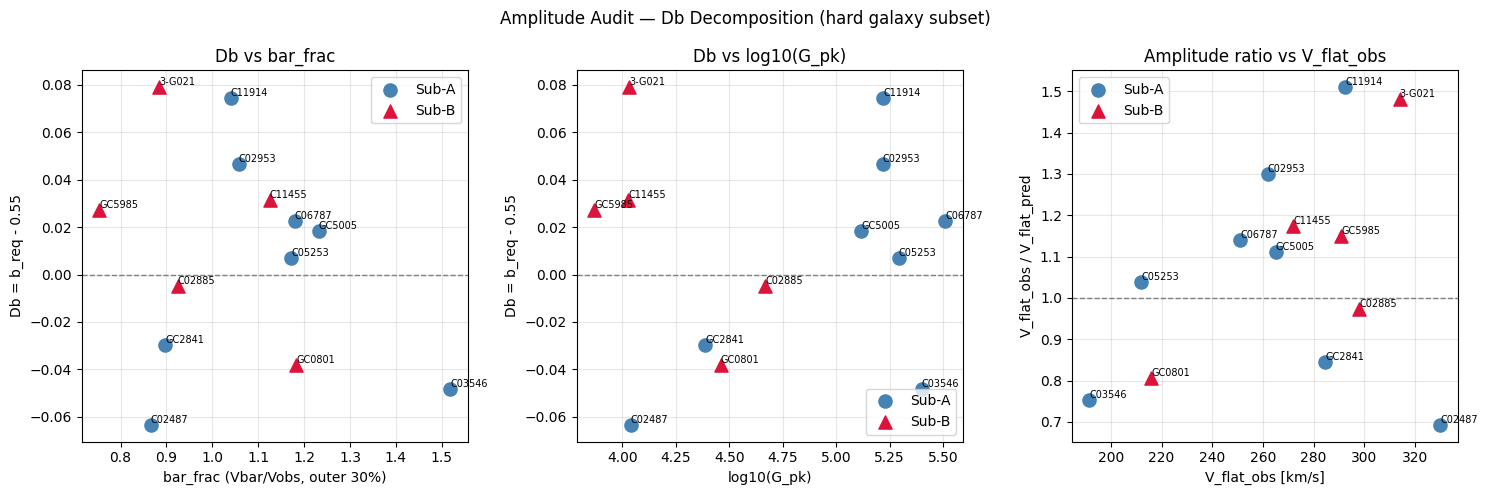


Plot saved: /content/mts_amplitude_audit/amplitude_audit.png
CSV saved:  /content/mts_amplitude_audit/amplitude_audit.csv

DIAGNOSIS

  Sub-B amplitude ratio median: 1.149  (>1 = underpredicted)
  Sub-A amplitude ratio median: 1.076
  Sub-B Db required median:     +0.027
  Sub-B shape_rmse median:      0.1304
  Sub-A shape_rmse median:      0.1670

  >> AMPLITUDE IS NEAR-CORRECT for Sub-B.
     Shape failure dominates (shape_rmse=0.1304 vs Sub-A 0.1670).
     Next: examine shape residuals — where does the curve diverge?


In [ ]:
# ============================================================
# MTS AMPLITUDE LAW AUDIT v2 — uses existing loaded dict
# ============================================================

OUTDIR_AUD = "/content/mts_amplitude_audit"
os.makedirs(OUTDIR_AUD, exist_ok=True)

# ----------------------------------------------------------------
# Confirm actual keys before proceeding
# ----------------------------------------------------------------
sample = next(iter(loaded.values()))
print("Confirmed keys:", list(sample.keys()))
print(f"Galaxies in loaded: {len(loaded)}")
print()

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def get_v_flat_obs(rot, outer_frac=0.30):
    r    = rot["r"]
    vobs = rot["vobs"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        return float(np.max(vobs))
    return float(np.median(vobs[mask]))

def get_bar_frac_outer(rot, outer_frac=0.30):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vobs  = rot["vobs"]
    r     = rot["r"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        mask = np.ones(len(r), bool)
    ratio = vbar[mask] / np.maximum(vobs[mask], 1.0)
    return float(np.median(ratio))

# ----------------------------------------------------------------
# STEP 1: Fit C_AMP on the loaded galaxies
# ----------------------------------------------------------------
all_carriers = []
all_vmaxes   = []

for name, gdata in loaded.items():
    c = gdata.get("carrier_base")
    v = gdata.get("vmax_obs")
    if c is not None and v is not None and np.isfinite(c) and np.isfinite(v) and c > 0:
        all_carriers.append(c)
        all_vmaxes.append(v)

C_AMP_local = float(np.mean(np.array(all_vmaxes)**2) /
                    np.mean(np.array(all_carriers)))
print(f"C_AMP (fitted on {len(all_carriers)} loaded galaxies): {C_AMP_local:.2f}")
print()

# ----------------------------------------------------------------
# STEP 2: Per-galaxy amplitude decomposition
# ----------------------------------------------------------------
print("="*80)
print("AMPLITUDE LAW AUDIT")
print(f"{'Name':20s} {'Sub':3s} {'Vf_obs':7s} {'Vf_pred':7s} "
      f"{'ratio':6s} {'b_req':6s} {'Db':6s} "
      f"{'log_Gpk':8s} {'bar_frac':9s} {'RMSE':7s}")
print("-"*80)

audit_rows = []
TARGET_NAMES = SUBCLASS_B + SUBCLASS_A

for name in TARGET_NAMES:
    if name not in loaded:
        print(f"  {name:20s}  — NOT IN LOADED")
        continue

    gdata = loaded[name]
    rot   = gdata["rot"]

    carrier_base = gdata["carrier_base"]
    shape        = gdata["shape"]
    vobs         = rot["vobs"]
    vmax_obs     = gdata["vmax_obs"]
    log_Gpk      = gdata["log_Gpk"]
    bar_frac     = gdata.get("bar_frac", get_bar_frac_outer(rot))

    rt    = gdata["rt"]
    u_t   = gdata["u_t"]
    vb2_t = gdata["vbar2_t"]

    carrier_alpha = (rt * u_t) ** ALPHA
    carrier_beta  = vb2_t ** BETA
    carrier_recon = carrier_alpha * carrier_beta
    recon_err = abs(carrier_recon - carrier_base) / max(carrier_base, 1e-30)

    v_flat_pred = float(np.sqrt(max(C_AMP_local * carrier_base, 0.0)))
    v_flat_obs  = get_v_flat_obs(rot)
    ratio       = v_flat_obs / max(v_flat_pred, 1e-3)

    numerator = (v_flat_obs**2) / max(C_AMP_local * carrier_alpha, 1e-30)
    if numerator > 0 and vb2_t > 1.0:
        beta_req   = float(np.log(numerator) / np.log(vb2_t))
        beta_delta = beta_req - BETA
    else:
        beta_req   = np.nan
        beta_delta = np.nan

    v_pred     = v_flat_pred * np.asarray(shape)
    full_rmse  = safe_rmse(vobs, v_pred)
    vobs_n     = vobs / max(float(np.max(vobs)), 1.0)
    vpred_n    = v_pred / max(float(np.max(v_pred)), 1.0)
    shape_rmse = safe_rmse(vobs_n, vpred_n)

    subclass = "B" if name in SUBCLASS_B else "A"
    flag     = " ***" if subclass == "B" else ""

    row = {
        "name":           name,
        "subclass":       subclass,
        "v_flat_obs":     v_flat_obs,
        "v_flat_pred":    v_flat_pred,
        "ratio":          ratio,
        "carrier_alpha":  carrier_alpha,
        "carrier_beta":   carrier_beta,
        "vb2_t":          vb2_t,
        "rt":             rt,
        "u_t":            u_t,
        "beta_req":       beta_req,
        "beta_delta":     beta_delta,
        "bar_frac":       bar_frac,
        "log_Gpk":        log_Gpk,
        "shape_rmse":     shape_rmse,
        "full_rmse":      full_rmse,
        "recon_err":      recon_err,
    }
    audit_rows.append(row)

    print(f"{name:20s} {subclass:3s} "
          f"{v_flat_obs:7.1f} {v_flat_pred:7.1f} "
          f"{ratio:6.3f} "
          f"{beta_req:6.3f} {beta_delta:+6.3f} "
          f"{log_Gpk:8.3f} {bar_frac:9.4f} "
          f"{full_rmse:7.2f}{flag}")

df_audit = pd.DataFrame(audit_rows)

# ----------------------------------------------------------------
# STEP 3: Carrier decomposition table
# ----------------------------------------------------------------
print("\n" + "="*80)
print("CARRIER DECOMPOSITION")
print(f"{'Name':20s} {'Sub':3s} {'(rt*u_t)^a':12s} {'Vb2(rt)^b':12s} "
      f"{'carrier':10s} {'rt[kpc]':8s} {'u_t':8s} {'vb2_t':10s} {'recon_err':9s}")
print("-"*80)

for row in audit_rows:
    print(f"{row['name']:20s} {row['subclass']:3s} "
          f"{row['carrier_alpha']:12.4e} {row['carrier_beta']:12.4e} "
          f"{row['carrier_alpha']*row['carrier_beta']:10.4e} "
          f"{row['rt']:8.3f} {row['u_t']:8.4e} {row['vb2_t']:10.2f} "
          f"{row['recon_err']:9.4f}")

# ----------------------------------------------------------------
# STEP 4: Summary by subclass
# ----------------------------------------------------------------
print("\n" + "="*80)
print("SUMMARY BY SUBCLASS")
print("="*80)

for sc in ["B", "A"]:
    d = df_audit[df_audit["subclass"] == sc]
    if len(d) == 0:
        continue
    print(f"\nSub-{sc} (n={len(d)}):")
    print(f"  ratio (obs/pred):   median={d['ratio'].median():.3f}  "
          f"range=[{d['ratio'].min():.3f}, {d['ratio'].max():.3f}]")
    print(f"  Db required:        median={d['beta_delta'].median():+.3f}  "
          f"range=[{d['beta_delta'].min():+.3f}, {d['beta_delta'].max():+.3f}]")
    print(f"  carrier_alpha:      median={d['carrier_alpha'].median():.4e}")
    print(f"  carrier_beta:       median={d['carrier_beta'].median():.4e}")
    print(f"  vb2_t [km2/s2]:     median={d['vb2_t'].median():.1f}")
    print(f"  bar_frac:           median={d['bar_frac'].median():.3f}")
    print(f"  log_Gpk:            median={d['log_Gpk'].median():.3f}")
    print(f"  full_rmse:          median={d['full_rmse'].median():.2f}")
    print(f"  shape_rmse:         median={d['shape_rmse'].median():.4f}")

# ----------------------------------------------------------------
# STEP 5: Correlation analysis
# ----------------------------------------------------------------
print("\n" + "="*80)
print("CORRELATION: Db vs bar_frac, log_Gpk")
print("="*80)

from scipy.stats import pearsonr, spearmanr

for label, dfc in [
    ("Sub-B only",       df_audit[df_audit["subclass"]=="B"]),
    ("Sub-A+B combined", df_audit),
]:
    dfc = dfc.dropna(subset=["beta_delta", "bar_frac", "log_Gpk"])
    print(f"\n  {label} (n={len(dfc)}):")
    if len(dfc) >= 3:
        r_bf, p_bf  = pearsonr( dfc["bar_frac"], dfc["beta_delta"])
        r_gp, p_gp  = pearsonr( dfc["log_Gpk"],  dfc["beta_delta"])
        s_bf, ps_bf = spearmanr(dfc["bar_frac"], dfc["beta_delta"])
        s_gp, ps_gp = spearmanr(dfc["log_Gpk"],  dfc["beta_delta"])
        print(f"    Db vs bar_frac:  Pearson r={r_bf:+.3f} (p={p_bf:.3f})  "
              f"Spearman rho={s_bf:+.3f} (p={ps_bf:.3f})")
        print(f"    Db vs log_Gpk:   Pearson r={r_gp:+.3f} (p={p_gp:.3f})  "
              f"Spearman rho={s_gp:+.3f} (p={ps_gp:.3f})")
    else:
        print("    Too few points.")

# ----------------------------------------------------------------
# STEP 6: Diagnostic plots
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Amplitude Audit — Db Decomposition (hard galaxy subset)", fontsize=12)

colors  = {"A": "steelblue", "B": "crimson"}
markers = {"A": "o",         "B": "^"}

ax = axes[0]
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["bar_frac","beta_delta"])
    ax.scatter(d["bar_frac"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=90, label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"][-6:], (row["bar_frac"], row["beta_delta"]),
                    fontsize=7, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("bar_frac (Vbar/Vobs, outer 30%)")
ax.set_ylabel("Db = b_req - 0.55")
ax.set_title("Db vs bar_frac")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["log_Gpk","beta_delta"])
    ax.scatter(d["log_Gpk"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=90, label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"][-6:], (row["log_Gpk"], row["beta_delta"]),
                    fontsize=7, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("log10(G_pk)")
ax.set_ylabel("Db = b_req - 0.55")
ax.set_title("Db vs log10(G_pk)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["v_flat_obs","ratio"])
    ax.scatter(d["v_flat_obs"], d["ratio"],
               c=colors[sc], marker=markers[sc], s=90, label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"][-6:], (row["v_flat_obs"], row["ratio"]),
                    fontsize=7, ha="left", va="bottom")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_xlabel("V_flat_obs [km/s]")
ax.set_ylabel("V_flat_obs / V_flat_pred")
ax.set_title("Amplitude ratio vs V_flat_obs")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTDIR_AUD, "amplitude_audit.png")
plt.savefig(plot_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nPlot saved: {plot_path}")

csv_path = os.path.join(OUTDIR_AUD, "amplitude_audit.csv")
df_audit.to_csv(csv_path, index=False)
print(f"CSV saved:  {csv_path}")

# ----------------------------------------------------------------
# STEP 7: Decision
# ----------------------------------------------------------------
print("\n" + "="*80)
print("DIAGNOSIS")
print("="*80)

b = df_audit[df_audit["subclass"]=="B"]
a = df_audit[df_audit["subclass"]=="A"]

b_ratio = b["ratio"].median()
a_ratio = a["ratio"].median()
b_db    = b["beta_delta"].median()
b_shape = b["shape_rmse"].median()
a_shape = a["shape_rmse"].median()

print(f"\n  Sub-B amplitude ratio median: {b_ratio:.3f}  (>1 = underpredicted)")
print(f"  Sub-A amplitude ratio median: {a_ratio:.3f}")
print(f"  Sub-B Db required median:     {b_db:+.3f}")
print(f"  Sub-B shape_rmse median:      {b_shape:.4f}")
print(f"  Sub-A shape_rmse median:      {a_shape:.4f}")
print()

if b_ratio > 1.15:
    print("  >> AMPLITUDE FAILURE: Sub-B velocities are underpredicted.")
    if abs(b_db) > 0.08:
        print(f"     BETA correction of ~{b_db:+.2f} needed for Sub-B.")
        print("     Suggested next: BETA_eff = 0.55 + delta * (1 - bar_frac)")
    else:
        print("     But Db is small — BETA is not the lever.")
        print("     Failure is in carrier_alpha = (rt*u_t)^ALPHA.")
        print("     Next: examine rt and u_t values for Sub-B vs Sub-A.")
elif b_ratio < 0.85:
    print("  >> AMPLITUDE OVERPREDICTION for Sub-B.")
    print("     Check source normalisation or Rs scaling.")
else:
    print("  >> AMPLITUDE IS NEAR-CORRECT for Sub-B.")
    print(f"     Shape failure dominates (shape_rmse={b_shape:.4f} vs Sub-A {a_shape:.4f}).")
    print("     Next: examine shape residuals — where does the curve diverge?")

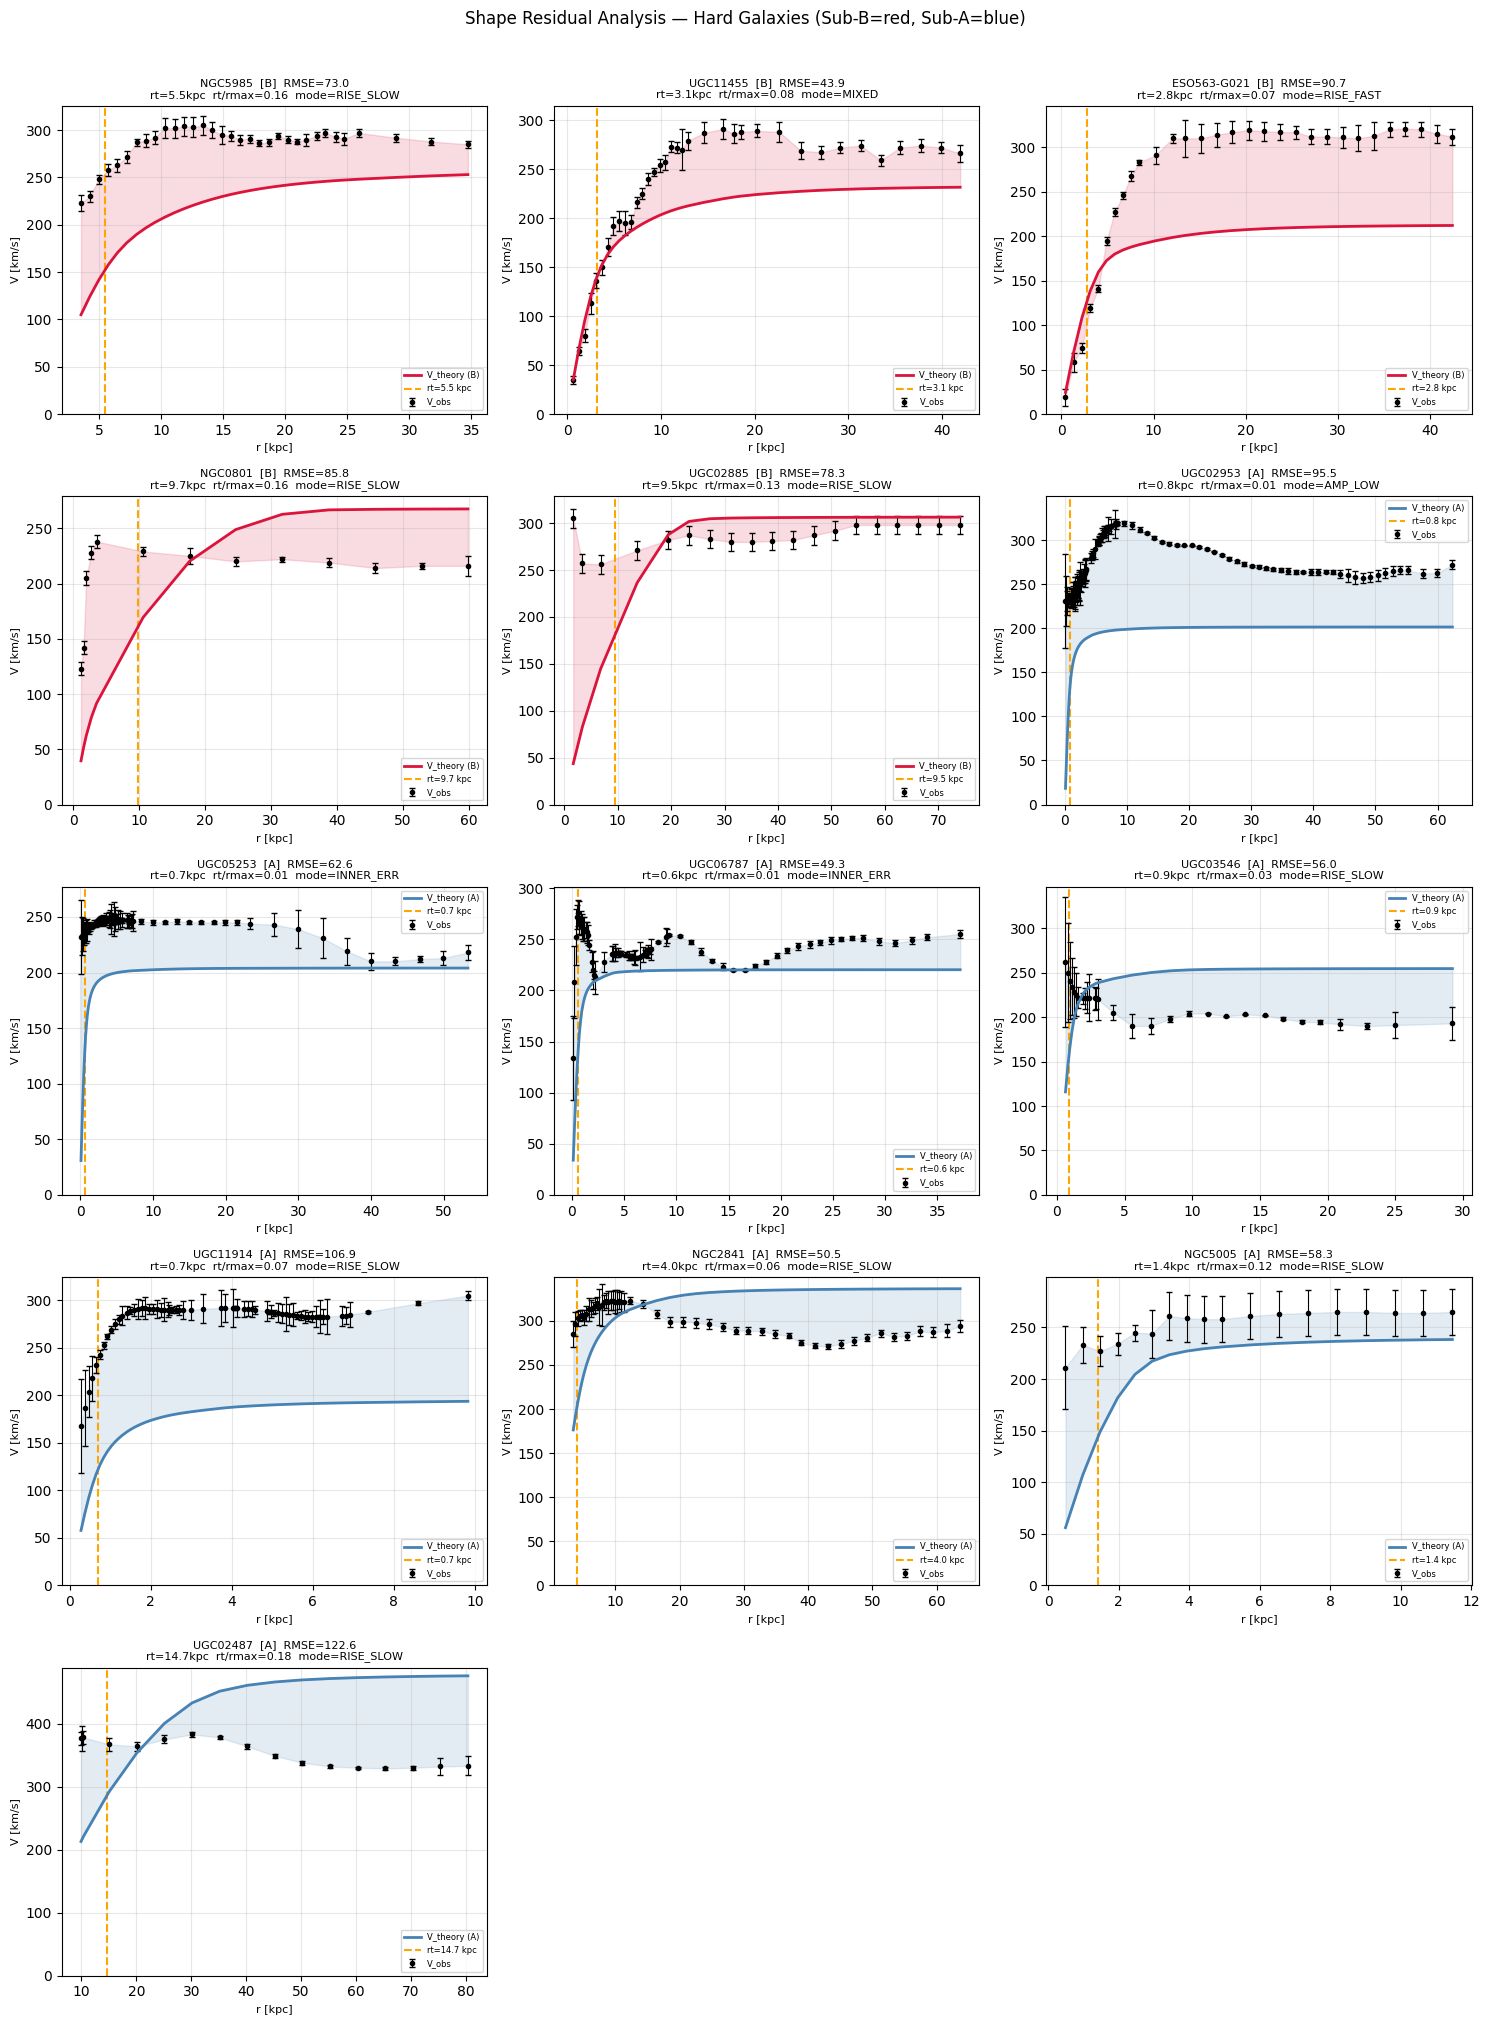

Saved: /content/mts_shape_residual/shape_residuals_hard.png

SHAPE RESIDUAL TABLE
Name                 Sub rt     rt/rm  RMSE    ratio  r_in    r_out   slope  pk_r   mode      
-----------------------------------------------------------------------------------------------
NGC5985              B     5.51  0.159   72.99  1.149  +110.2   +64.7  -2.82   3.54 RISE_SLOW  ***
UGC11455             B     3.15  0.075   43.88  1.175    -5.2   +42.7  +0.93  16.63 MIXED      ***
ESO563-G021          B     2.83  0.067   90.70  1.481   -17.1   +88.0  +2.52  20.30 RISE_FAST  ***
NGC0801              B     9.74  0.163   85.82  0.807  +122.5   -26.1  -3.49   2.73 RISE_SLOW  ***
UGC02885             B     9.52  0.129   78.30  0.973  +182.3   -12.0  -2.21   1.70 RISE_SLOW  ***
UGC02953             A     0.79  0.013   95.52  1.300  +152.3   +85.9  -0.84   0.09 AMP_LOW   
UGC05253             A     0.68  0.013   62.62  1.039  +152.0   +46.8  -1.40   0.13 INNER_ERR 
UGC06787             A     0.55  0.015   4

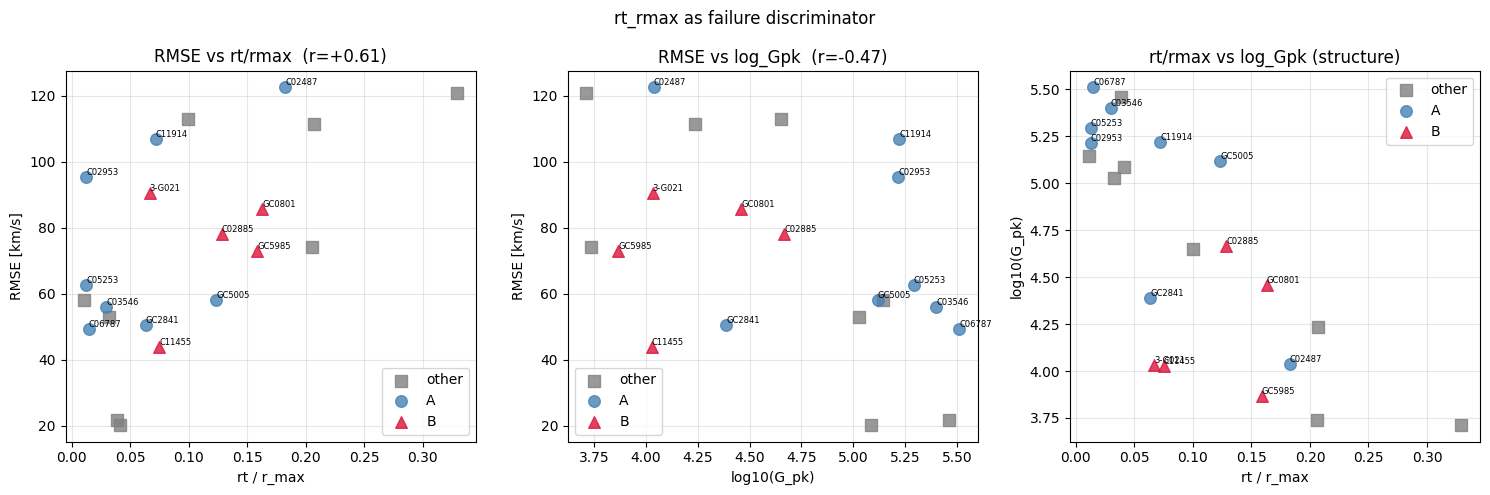

Saved: /content/mts_shape_residual/rt_rmax_discriminator.png

FAILURE MODE SUMMARY
subclass      mode  n
       A   AMP_LOW  1
       A INNER_ERR  2
       A RISE_SLOW  5
       B     MIXED  1
       B RISE_FAST  1
       B RISE_SLOW  3

Sub-B failure modes:
  NGC5985               rt=5.5kpc  rt/rmax=0.159  slope=-2.82  mode=RISE_SLOW
  UGC11455              rt=3.1kpc  rt/rmax=0.075  slope=+0.93  mode=MIXED
  ESO563-G021           rt=2.8kpc  rt/rmax=0.067  slope=+2.52  mode=RISE_FAST
  NGC0801               rt=9.7kpc  rt/rmax=0.163  slope=-3.49  mode=RISE_SLOW
  UGC02885              rt=9.5kpc  rt/rmax=0.129  slope=-2.21  mode=RISE_SLOW

Sub-A failure modes:
  UGC02953              rt=0.8kpc  rt/rmax=0.013  slope=-0.84  mode=AMP_LOW
  UGC05253              rt=0.7kpc  rt/rmax=0.013  slope=-1.40  mode=INNER_ERR
  UGC06787              rt=0.6kpc  rt/rmax=0.015  slope=-1.20  mode=INNER_ERR
  UGC03546              rt=0.9kpc  rt/rmax=0.030  slope=-4.23  mode=RISE_SLOW
  UGC11914             

In [ ]:
# ============================================================
# MTS SHAPE RESIDUAL ANALYSIS
# ------------------------------------------------------------
# For each hard galaxy (Sub-B + Sub-A):
#   1. Plot V_theory(r) vs V_obs(r) with rt marked
#   2. Compute residual profile: V_obs(r) - V_theory(r)
#   3. Classify failure mode per galaxy
#
# Then: rt_rmax distribution across full catalogue vs RMSE
# to test whether rt_rmax is a better discriminator than log_Gpk
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d

OUTDIR_SHAPE = "/content/mts_shape_residual"
os.makedirs(OUTDIR_SHAPE, exist_ok=True)

# ----------------------------------------------------------------
# STEP 1: Per-galaxy rotation curve plots for hard galaxies
# Sub-B first, then Sub-A
# ----------------------------------------------------------------
TARGET_NAMES = SUBCLASS_B + SUBCLASS_A

n_gals  = len([n for n in TARGET_NAMES if n in loaded])
n_cols  = 3
n_rows  = (n_gals + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

shape_rows = []
ax_idx = 0

for name in TARGET_NAMES:
    if name not in loaded:
        continue

    gdata      = loaded[name]
    rot        = gdata["rot"]
    r_obs      = rot["r"]
    vobs       = rot["vobs"]
    ev         = rot["ev"]
    shape      = np.asarray(gdata["shape"])
    carrier_b  = gdata["carrier_base"]
    rt         = gdata["rt"]
    rt_rmax    = gdata["rt_rmax"]
    vmax_obs   = gdata["vmax_obs"]
    log_Gpk    = gdata["log_Gpk"]
    bar_frac   = gdata["bar_frac"]

    # Reconstruct V_theory on observed r grid
    v_flat_pred = float(np.sqrt(max(C_AMP_local * carrier_b, 0.0)))
    v_theory    = v_flat_pred * shape

    # Residual profile
    residual    = vobs - v_theory
    resid_norm  = residual / np.maximum(vobs, 1.0)   # fractional

    # Where does the residual peak? (largest absolute error)
    peak_resid_idx = int(np.argmax(np.abs(residual)))
    peak_resid_r   = float(r_obs[peak_resid_idx])
    peak_resid_v   = float(residual[peak_resid_idx])

    # Inner vs outer residual split (split at rt)
    inner_mask = r_obs <= rt
    outer_mask = r_obs >  rt
    resid_inner = float(np.mean(residual[inner_mask])) if inner_mask.any() else np.nan
    resid_outer = float(np.mean(residual[outer_mask])) if outer_mask.any() else np.nan

    # Slope of residual (positive = theory rises faster than obs at large r)
    if len(r_obs) >= 4:
        slope_resid = float(np.polyfit(r_obs, residual, 1)[0])
    else:
        slope_resid = np.nan

    # Classify failure mode
    full_rmse  = safe_rmse(vobs, v_theory)
    amp_ratio  = get_v_flat_obs(rot) / max(v_flat_pred, 1e-3)

    if   amp_ratio > 1.20 and abs(slope_resid) < 2.0:
        mode = "AMP_LOW"       # flat underestimate throughout
    elif amp_ratio < 0.80 and abs(slope_resid) < 2.0:
        mode = "AMP_HIGH"      # flat overestimate throughout
    elif slope_resid > 2.0:
        mode = "RISE_FAST"     # theory rises faster than obs (rt too early or too steep)
    elif slope_resid < -2.0:
        mode = "RISE_SLOW"     # theory rises slower than obs (rt too late)
    elif abs(resid_inner) > abs(resid_outer) + 10:
        mode = "INNER_ERR"     # error concentrated inside rt
    else:
        mode = "MIXED"

    subclass = "B" if name in SUBCLASS_B else "A"

    row = {
        "name":          name,
        "subclass":      subclass,
        "rt":            rt,
        "rt_rmax":       rt_rmax,
        "log_Gpk":       log_Gpk,
        "bar_frac":      bar_frac,
        "full_rmse":     full_rmse,
        "amp_ratio":     amp_ratio,
        "resid_inner":   resid_inner,
        "resid_outer":   resid_outer,
        "slope_resid":   slope_resid,
        "peak_resid_r":  peak_resid_r,
        "peak_resid_v":  peak_resid_v,
        "mode":          mode,
        "v_flat_pred":   v_flat_pred,
        "vmax_obs":      vmax_obs,
    }
    shape_rows.append(row)

    # ---- Plot ----
    ax = axes[ax_idx]; ax_idx += 1
    color = "crimson" if subclass == "B" else "steelblue"

    ax.errorbar(r_obs, vobs, yerr=ev,
                fmt="ko", ms=3, elinewidth=0.8,
                capsize=2, label="V_obs", zorder=3)
    ax.plot(r_obs, v_theory, color=color, lw=2,
            label=f"V_theory ({subclass})", zorder=4)

    # Mark rt
    ax.axvline(rt, color="orange", lw=1.5, ls="--",
               label=f"rt={rt:.1f} kpc")

    # Shade residual
    ax.fill_between(r_obs, vobs, v_theory,
                    alpha=0.15, color=color)

    ax.set_title(f"{name}  [{subclass}]  RMSE={full_rmse:.1f}\n"
                 f"rt={rt:.1f}kpc  rt/rmax={rt_rmax:.2f}  "
                 f"mode={mode}",
                 fontsize=8)
    ax.set_xlabel("r [kpc]", fontsize=8)
    ax.set_ylabel("V [km/s]", fontsize=8)
    ax.legend(fontsize=6)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

# Hide unused axes
for i in range(ax_idx, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Shape Residual Analysis — Hard Galaxies (Sub-B=red, Sub-A=blue)",
             fontsize=12, y=1.01)
plt.tight_layout()
plot_path = os.path.join(OUTDIR_SHAPE, "shape_residuals_hard.png")
plt.savefig(plot_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

# ----------------------------------------------------------------
# STEP 2: Print shape residual table
# ----------------------------------------------------------------
df_shape = pd.DataFrame(shape_rows)

print("\n" + "="*95)
print("SHAPE RESIDUAL TABLE")
print(f"{'Name':20s} {'Sub':3s} {'rt':6s} {'rt/rm':6s} {'RMSE':7s} "
      f"{'ratio':6s} {'r_in':7s} {'r_out':7s} {'slope':6s} "
      f"{'pk_r':6s} {'mode':10s}")
print("-"*95)

for _, row in df_shape.iterrows():
    flag = " ***" if row["subclass"] == "B" else ""
    print(f"{row['name']:20s} {row['subclass']:3s} "
          f"{row['rt']:6.2f} {row['rt_rmax']:6.3f} "
          f"{row['full_rmse']:7.2f} {row['amp_ratio']:6.3f} "
          f"{row['resid_inner']:+7.1f} {row['resid_outer']:+7.1f} "
          f"{row['slope_resid']:+6.2f} "
          f"{row['peak_resid_r']:6.2f} "
          f"{row['mode']:10s}{flag}")

# ----------------------------------------------------------------
# STEP 3: rt_rmax vs RMSE across full catalogue
# Build full-catalogue rt_rmax from loaded (21 galaxies here,
# but we can extend the analysis if the full preload exists)
# ----------------------------------------------------------------
print("\n" + "="*70)
print("rt_rmax DISTRIBUTION IN LOADED GALAXIES")
print("="*70)

all_rt_rows = []
for name, gdata in loaded.items():
    subclass = ("B" if name in SUBCLASS_B else
                "A" if name in SUBCLASS_A else "other")
    carrier_b  = gdata["carrier_base"]
    vobs_g     = gdata["vobs"]
    shape_g    = np.asarray(gdata["shape"])
    v_flat_p   = float(np.sqrt(max(C_AMP_local * carrier_b, 0.0)))
    v_theory_g = v_flat_p * shape_g
    rmse_g     = safe_rmse(vobs_g, v_theory_g)

    all_rt_rows.append({
        "name":     name,
        "subclass": subclass,
        "rt":       gdata["rt"],
        "rt_rmax":  gdata["rt_rmax"],
        "log_Gpk":  gdata["log_Gpk"],
        "rmse":     rmse_g,
    })

df_rt = pd.DataFrame(all_rt_rows).sort_values("rt_rmax")

print(f"\n{'Name':20s} {'Sub':5s} {'rt':6s} {'rt/rmax':8s} "
      f"{'log_Gpk':8s} {'RMSE':7s}")
print("-"*60)
for _, row in df_rt.iterrows():
    print(f"{row['name']:20s} {row['subclass']:5s} "
          f"{row['rt']:6.2f} {row['rt_rmax']:8.3f} "
          f"{row['log_Gpk']:8.3f} {row['rmse']:7.2f}")

# Correlation: rt_rmax vs RMSE
from scipy.stats import pearsonr, spearmanr
r_p, p_p = pearsonr( df_rt["rt_rmax"], df_rt["rmse"])
r_s, p_s = spearmanr(df_rt["rt_rmax"], df_rt["rmse"])
print(f"\nrt_rmax vs RMSE:  Pearson r={r_p:+.3f} (p={p_p:.3f})  "
      f"Spearman rho={r_s:+.3f} (p={p_s:.3f})")

r_p2, p_p2 = pearsonr( df_rt["log_Gpk"], df_rt["rmse"])
r_s2, p_s2 = spearmanr(df_rt["log_Gpk"], df_rt["rmse"])
print(f"log_Gpk  vs RMSE:  Pearson r={r_p2:+.3f} (p={p_p2:.3f})  "
      f"Spearman rho={r_s2:+.3f} (p={p_s2:.3f})")

# ----------------------------------------------------------------
# STEP 4: rt_rmax scatter plot
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("rt_rmax as failure discriminator", fontsize=12)

colors_sc  = {"A": "steelblue", "B": "crimson", "other": "gray"}
markers_sc = {"A": "o", "B": "^", "other": "s"}

ax = axes[0]
for sc in ["other", "A", "B"]:
    d = df_rt[df_rt["subclass"]==sc]
    ax.scatter(d["rt_rmax"], d["rmse"],
               c=colors_sc[sc], marker=markers_sc[sc],
               s=70, label=sc, zorder=3, alpha=0.8)
    for _, row in d[d["subclass"]!="other"].iterrows():
        ax.annotate(row["name"][-6:],
                    (row["rt_rmax"], row["rmse"]),
                    fontsize=6, ha="left", va="bottom")
ax.set_xlabel("rt / r_max")
ax.set_ylabel("RMSE [km/s]")
ax.set_title(f"RMSE vs rt/rmax  (r={r_p:+.2f})")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for sc in ["other", "A", "B"]:
    d = df_rt[df_rt["subclass"]==sc]
    ax.scatter(d["log_Gpk"], d["rmse"],
               c=colors_sc[sc], marker=markers_sc[sc],
               s=70, label=sc, zorder=3, alpha=0.8)
    for _, row in d[d["subclass"]!="other"].iterrows():
        ax.annotate(row["name"][-6:],
                    (row["log_Gpk"], row["rmse"]),
                    fontsize=6, ha="left", va="bottom")
ax.set_xlabel("log10(G_pk)")
ax.set_ylabel("RMSE [km/s]")
ax.set_title(f"RMSE vs log_Gpk  (r={r_p2:+.2f})")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
for sc in ["other", "A", "B"]:
    d = df_rt[df_rt["subclass"]==sc]
    ax.scatter(d["rt_rmax"], d["log_Gpk"],
               c=colors_sc[sc], marker=markers_sc[sc],
               s=70, label=sc, zorder=3, alpha=0.8)
    for _, row in d[d["subclass"]!="other"].iterrows():
        ax.annotate(row["name"][-6:],
                    (row["rt_rmax"], row["log_Gpk"]),
                    fontsize=6, ha="left", va="bottom")
ax.set_xlabel("rt / r_max")
ax.set_ylabel("log10(G_pk)")
ax.set_title("rt/rmax vs log_Gpk (structure)")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path2 = os.path.join(OUTDIR_SHAPE, "rt_rmax_discriminator.png")
plt.savefig(plot_path2, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path2}")

# ----------------------------------------------------------------
# STEP 5: Failure mode summary
# ----------------------------------------------------------------
print("\n" + "="*70)
print("FAILURE MODE SUMMARY")
print("="*70)

mode_counts = df_shape.groupby(["subclass","mode"]).size().reset_index(name="n")
print(mode_counts.to_string(index=False))

print("\nSub-B failure modes:")
for _, row in df_shape[df_shape["subclass"]=="B"].iterrows():
    print(f"  {row['name']:20s}  rt={row['rt']:.1f}kpc  "
          f"rt/rmax={row['rt_rmax']:.3f}  "
          f"slope={row['slope_resid']:+.2f}  "
          f"mode={row['mode']}")

print("\nSub-A failure modes:")
for _, row in df_shape[df_shape["subclass"]=="A"].iterrows():
    print(f"  {row['name']:20s}  rt={row['rt']:.1f}kpc  "
          f"rt/rmax={row['rt_rmax']:.3f}  "
          f"slope={row['slope_resid']:+.2f}  "
          f"mode={row['mode']}")

# Save
csv_path = os.path.join(OUTDIR_SHAPE, "shape_residuals.csv")
df_shape.to_csv(csv_path, index=False)
print(f"\nCSV saved: {csv_path}")

TRANSITION-WARP TEST
Loaded galaxies: 21
C_AMP_local: 347.359025

BEST ETA PER GALAXY
     galaxy   subclass coverage_bin        rt  rt_rmax  log_Gpk  rmse_base  rmse_best_eta  rmse_improvement  best_eta  eta_shift
   UGC02953 A_improves         GOOD  0.791353 0.012684 5.216150  95.523753      86.413960          9.109794       0.5       -0.5
   UGC03546 A_improves         GOOD  0.866506 0.029644 5.400365  55.958978      45.960111          9.998867       0.5       -0.5
   UGC05253 A_improves         GOOD  0.676073 0.012687 5.292060  62.623210      50.663817         11.959393       0.5       -0.5
   UGC06787 A_improves         GOOD  0.551777 0.014837 5.510312  49.264824      34.444624         14.820199       0.5       -0.5
   UGC11914 A_improves         GOOD  0.709142 0.072141 5.220609 106.888334      94.745641         12.142694       0.5       -0.5
    NGC2841 A_improves         POOR  4.031938 0.063355 4.388028  50.485900      35.200567         15.285332       0.5       -0.5
    NGC5005

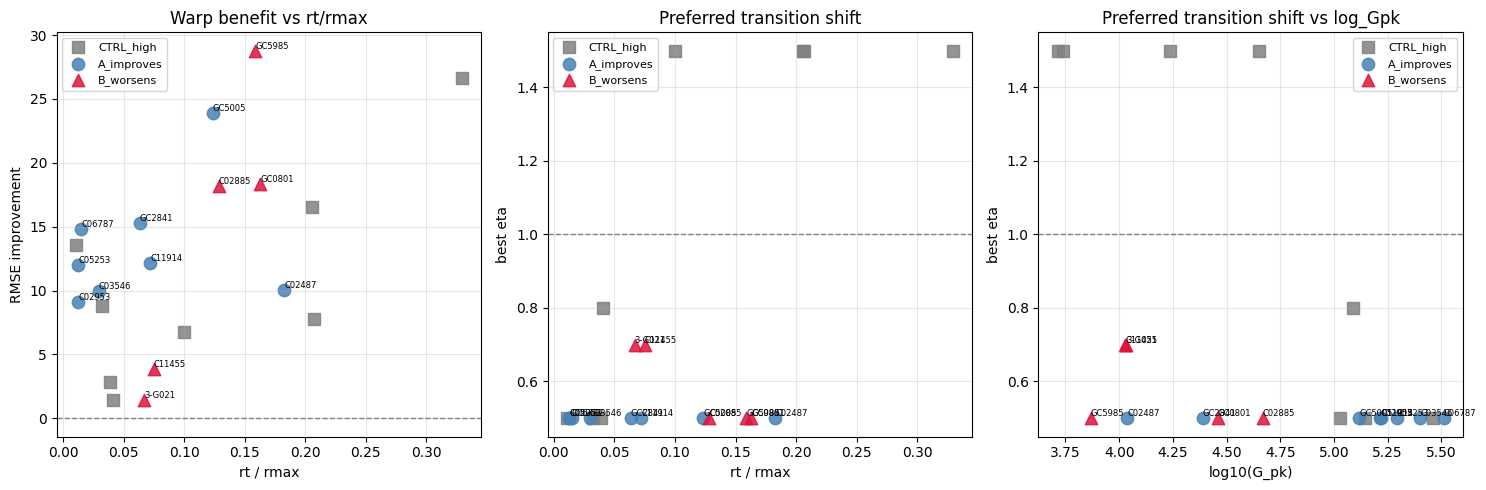


Saved:
/content/mts_transition_warp_test/transition_warp_best.csv
/content/mts_transition_warp_test/transition_warp_scan_detail.csv
/content/mts_transition_warp_test/transition_warp_summary.csv
/content/mts_transition_warp_test/transition_warp_summary.png

COMPACT READ
     galaxy   subclass  rt_rmax  log_Gpk  rmse_base  rmse_best_eta  rmse_improvement  best_eta
    NGC5985  B_worsens 0.158663 3.868413  72.985082      44.206369         28.778713       0.5
    NGC3992  CTRL_high 0.329387 3.714036 120.983927      94.366312         26.617615       1.5
    NGC5005 A_improves 0.123564 5.116940  58.306270      34.376439         23.929832       0.5
    NGC0801  B_worsens 0.162890 4.459929  85.824899      67.481804         18.343095       0.5
   UGC02885  B_worsens 0.128503 4.668233  78.302373      60.143866         18.158506       0.5
    NGC3726  CTRL_high 0.205689 3.737137  74.259073      57.724937         16.534137       1.5
    NGC2841 A_improves 0.063355 4.388028  50.485900      35.2005

In [ ]:
# ============================================================
# MTS TRANSITION-WARP TEST
# ------------------------------------------------------------
# Independent Colab block
#
# Purpose:
#   Test whether the main failure is transition placement.
#
# Method:
#   For each loaded audit galaxy:
#     - keep V_flat prediction fixed
#     - horizontally warp the shape by eta:
#           V_model_eta(r) = V_flat_pred * shape(r / eta)
#     - scan eta and find the best RMSE
#
# Interpretation:
#   eta < 1  => model transition was too late / too far out
#   eta > 1  => model transition was too early / too far in
#
# If hard galaxies improve strongly under eta, then rt placement
# is the real failure mode.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import pearsonr, spearmanr

OUTDIR = "/content/mts_transition_warp_test"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_globals = [
    "loaded", "SUBCLASS_A", "SUBCLASS_B", "safe_rmse"
]
missing = [x for x in required_globals if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required globals: {missing}")

if "C_AMP_local" not in globals():
    # rebuild from loaded if not already present
    carriers = []
    vmaxes   = []
    for name, gdata in loaded.items():
        c = gdata.get("carrier_base", np.nan)
        v = gdata.get("vmax_obs", np.nan)
        if np.isfinite(c) and np.isfinite(v) and c > 0:
            carriers.append(c)
            vmaxes.append(v)
    C_AMP_local = float(np.mean(np.array(vmaxes)**2) / np.mean(np.array(carriers)))
    print(f"Rebuilt C_AMP_local = {C_AMP_local:.6f}")

print("="*72)
print("TRANSITION-WARP TEST")
print("="*72)
print(f"Loaded galaxies: {len(loaded)}")
print(f"C_AMP_local: {C_AMP_local:.6f}")

# ------------------------------------------------------------
# ETA SCAN GRID
# ------------------------------------------------------------
ETA_VALUES = np.array([
    0.50, 0.60, 0.70, 0.80, 0.90,
    1.00,
    1.10, 1.20, 1.30, 1.40, 1.50
])

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def get_subclass(name):
    if name in SUBCLASS_B:
        return "B_worsens"
    if name in SUBCLASS_A:
        return "A_improves"
    return "CTRL_high"

def warp_shape_on_obs_grid(r_obs, shape_obs, eta):
    """
    shape_obs is the predicted shape sampled on the observed r grid.
    Build an interpolator in r, then evaluate at r/eta.
    eta < 1 -> transition moves inward
    eta > 1 -> transition moves outward
    """
    r_obs = np.asarray(r_obs, float)
    shape_obs = np.asarray(shape_obs, float)

    # enforce monotonic physical bounds
    shape_obs = np.clip(shape_obs, 0.0, None)

    f = interp1d(
        r_obs, shape_obs,
        kind="linear",
        bounds_error=False,
        fill_value=(float(shape_obs[0]), float(shape_obs[-1]))
    )

    return f(r_obs / eta)

def get_v_flat_obs(rot, outer_frac=0.30):
    r = rot["r"]
    v = rot["vobs"]
    r_cut = r[-1] * (1.0 - outer_frac)
    m = r >= r_cut
    if m.sum() < 2:
        return float(np.max(v))
    return float(np.median(v[m]))

# ------------------------------------------------------------
# Main scan
# ------------------------------------------------------------
rows = []
detail_rows = []

for name, gdata in loaded.items():
    try:
        rot         = gdata["rot"]
        r_obs       = np.asarray(rot["r"], float)
        v_obs       = np.asarray(rot["vobs"], float)
        shape_base  = np.asarray(gdata["shape"], float)
        carrier     = float(gdata["carrier_base"])
        rt          = float(gdata["rt"])
        rt_rmax     = float(gdata["rt_rmax"])
        log_Gpk     = float(gdata["log_Gpk"])
        n_pts       = int(gdata["n_pts"])
        centre_miss = int(gdata["centre_missing"])
        bar_frac    = float(gdata["bar_frac"])
        coverage    = gdata["coverage_bin"]

        Vflat_pred_base = float(np.sqrt(max(C_AMP_local * carrier, 0.0)))
        Vmodel_base     = Vflat_pred_base * shape_base
        rmse_base       = safe_rmse(v_obs, Vmodel_base)
        flat_obs        = get_v_flat_obs(rot)
        flat_err_base   = abs(flat_obs - Vflat_pred_base)

        best_eta      = np.nan
        best_rmse     = np.inf
        best_flat_err = np.nan
        best_model    = None

        for eta in ETA_VALUES:
            shape_eta  = warp_shape_on_obs_grid(r_obs, shape_base, eta)
            Vmodel_eta = Vflat_pred_base * shape_eta
            rmse_eta   = safe_rmse(v_obs, Vmodel_eta)

            # Vflat itself is fixed, so flat error stays same in principle,
            # but keep for completeness using outer median of warped curve
            vflat_eta  = float(np.median(Vmodel_eta[r_obs >= 0.7*np.max(r_obs)])) if np.any(r_obs >= 0.7*np.max(r_obs)) else float(Vmodel_eta[-1])
            flat_err_eta = abs(flat_obs - vflat_eta)

            detail_rows.append({
                "galaxy": name,
                "subclass": get_subclass(name),
                "coverage_bin": coverage,
                "eta": eta,
                "rmse": rmse_eta,
                "flat_err": flat_err_eta,
                "rmse_base": rmse_base,
                "flat_err_base": flat_err_base,
                "log_Gpk": log_Gpk,
                "rt": rt,
                "rt_rmax": rt_rmax,
                "bar_frac": bar_frac,
                "n_pts": n_pts,
                "centre_missing": centre_miss,
            })

            if rmse_eta < best_rmse:
                best_rmse     = rmse_eta
                best_eta      = eta
                best_flat_err = flat_err_eta
                best_model    = Vmodel_eta.copy()

        rows.append({
            "galaxy": name,
            "subclass": get_subclass(name),
            "coverage_bin": coverage,
            "n_pts": n_pts,
            "centre_missing": centre_miss,
            "log_Gpk": log_Gpk,
            "bar_frac": bar_frac,
            "rt": rt,
            "rt_rmax": rt_rmax,
            "Vflat_pred_base": Vflat_pred_base,
            "Vflat_obs": flat_obs,
            "rmse_base": rmse_base,
            "rmse_best_eta": best_rmse,
            "rmse_improvement": rmse_base - best_rmse,
            "flat_err_base": flat_err_base,
            "flat_err_best_eta": best_flat_err,
            "best_eta": best_eta,
            "eta_shift": best_eta - 1.0,
            "needs_inward_shift": int(best_eta < 1.0),
            "needs_outward_shift": int(best_eta > 1.0),
        })

    except Exception as e:
        print(f"FAILED: {name} -> {e}")

best_df   = pd.DataFrame(rows)
detail_df = pd.DataFrame(detail_rows)

# ------------------------------------------------------------
# Reporting
# ------------------------------------------------------------
print("\n" + "="*72)
print("BEST ETA PER GALAXY")
print("="*72)
show_cols = [
    "galaxy","subclass","coverage_bin","rt","rt_rmax","log_Gpk",
    "rmse_base","rmse_best_eta","rmse_improvement","best_eta","eta_shift"
]
print(best_df.sort_values(["subclass","coverage_bin","galaxy"])[show_cols].to_string(index=False))

def summarise_group(label, dfx):
    if len(dfx) == 0:
        return None
    return {
        "group": label,
        "n_gal": len(dfx),
        "median_rmse_base": float(np.median(dfx["rmse_base"])),
        "median_rmse_best_eta": float(np.median(dfx["rmse_best_eta"])),
        "median_rmse_improvement": float(np.median(dfx["rmse_improvement"])),
        "mean_rmse_improvement": float(np.mean(dfx["rmse_improvement"])),
        "median_best_eta": float(np.median(dfx["best_eta"])),
        "frac_eta_lt_1": float(np.mean(dfx["best_eta"] < 1.0)),
        "frac_eta_gt_1": float(np.mean(dfx["best_eta"] > 1.0)),
    }

summary_rows = []
for label in ["A_improves", "B_worsens", "CTRL_high"]:
    d = best_df[best_df["subclass"] == label]
    row = summarise_group(label, d)
    if row is not None:
        summary_rows.append(row)

for label in ["GOOD_COVERAGE", "POOR_COVERAGE"]:
    d = best_df[best_df["coverage_bin"] == label]
    row = summarise_group(label, d)
    if row is not None:
        summary_rows.append(row)

row = summarise_group("ALL", best_df)
if row is not None:
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print("\n" + "="*72)
print("SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

# ------------------------------------------------------------
# Correlations
# ------------------------------------------------------------
print("\n" + "="*72)
print("CORRELATIONS")
print("="*72)

for xcol in ["rt_rmax", "log_Gpk", "bar_frac", "n_pts"]:
    d = best_df[[xcol, "rmse_improvement", "best_eta"]].dropna()
    if len(d) >= 4:
        rp, pp = pearsonr(d[xcol], d["rmse_improvement"])
        rs, ps = spearmanr(d[xcol], d["rmse_improvement"])
        print(f"rmse_improvement vs {xcol:8s}: Pearson r={rp:+.3f} (p={pp:.3f})  Spearman rho={rs:+.3f} (p={ps:.3f})")

print()
for xcol in ["rt_rmax", "log_Gpk", "bar_frac", "n_pts"]:
    d = best_df[[xcol, "best_eta"]].dropna()
    if len(d) >= 4:
        rp, pp = pearsonr(d[xcol], d["best_eta"])
        rs, ps = spearmanr(d[xcol], d["best_eta"])
        print(f"best_eta         vs {xcol:8s}: Pearson r={rp:+.3f} (p={pp:.3f})  Spearman rho={rs:+.3f} (p={ps:.3f})")

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

color_map = {
    "A_improves": "steelblue",
    "B_worsens": "crimson",
    "CTRL_high": "gray"
}
marker_map = {
    "A_improves": "o",
    "B_worsens": "^",
    "CTRL_high": "s"
}

# 1) improvement vs rt_rmax
ax = axes[0]
for sc in ["CTRL_high", "A_improves", "B_worsens"]:
    d = best_df[best_df["subclass"] == sc]
    ax.scatter(d["rt_rmax"], d["rmse_improvement"],
               c=color_map[sc], marker=marker_map[sc], s=80, alpha=0.85, label=sc)
    for _, row in d[d["subclass"] != "CTRL_high"].iterrows():
        ax.annotate(row["galaxy"][-6:], (row["rt_rmax"], row["rmse_improvement"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("rt / rmax")
ax.set_ylabel("RMSE improvement")
ax.set_title("Warp benefit vs rt/rmax")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# 2) best eta vs rt_rmax
ax = axes[1]
for sc in ["CTRL_high", "A_improves", "B_worsens"]:
    d = best_df[best_df["subclass"] == sc]
    ax.scatter(d["rt_rmax"], d["best_eta"],
               c=color_map[sc], marker=marker_map[sc], s=80, alpha=0.85, label=sc)
    for _, row in d[d["subclass"] != "CTRL_high"].iterrows():
        ax.annotate(row["galaxy"][-6:], (row["rt_rmax"], row["best_eta"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_xlabel("rt / rmax")
ax.set_ylabel("best eta")
ax.set_title("Preferred transition shift")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# 3) best eta vs log_Gpk
ax = axes[2]
for sc in ["CTRL_high", "A_improves", "B_worsens"]:
    d = best_df[best_df["subclass"] == sc]
    ax.scatter(d["log_Gpk"], d["best_eta"],
               c=color_map[sc], marker=marker_map[sc], s=80, alpha=0.85, label=sc)
    for _, row in d[d["subclass"] != "CTRL_high"].iterrows():
        ax.annotate(row["galaxy"][-6:], (row["log_Gpk"], row["best_eta"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_xlabel("log10(G_pk)")
ax.set_ylabel("best eta")
ax.set_title("Preferred transition shift vs log_Gpk")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plot_path = os.path.join(OUTDIR, "transition_warp_summary.png")
plt.savefig(plot_path, dpi=140, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
best_path   = os.path.join(OUTDIR, "transition_warp_best.csv")
detail_path = os.path.join(OUTDIR, "transition_warp_scan_detail.csv")
sum_path    = os.path.join(OUTDIR, "transition_warp_summary.csv")

best_df.sort_values(["subclass","coverage_bin","galaxy"]).to_csv(best_path, index=False)
detail_df.to_csv(detail_path, index=False)
summary_df.to_csv(sum_path, index=False)

print("\nSaved:")
print(best_path)
print(detail_path)
print(sum_path)
print(plot_path)

# ------------------------------------------------------------
# Compact read
# ------------------------------------------------------------
print("\n" + "="*72)
print("COMPACT READ")
print("="*72)
compact_cols = [
    "galaxy","subclass","rt_rmax","log_Gpk","rmse_base",
    "rmse_best_eta","rmse_improvement","best_eta"
]
print(best_df.sort_values("rmse_improvement", ascending=False)[compact_cols].to_string(index=False))

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Unique galaxies: 175
Examples: ['CamB', 'D512-2', 'D564-8', 'D631-7', 'DDO064', 'DDO154', 'DDO161', 'DDO168', 'DDO170', 'ESO079-G014']

Loaded audit galaxies: 21

g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141
C_AMP_local: 347.359025

FINE ETA SCAN SUMMARY
     galaxy   subclass  coverage_bin  rt_rmax  log_Gpk  rmse_base  rmse_best_eta  rmse_improvement  best_eta
    NGC5985  B_worsens POOR_COVERAGE 0.158663 3.868413  72.985082      37.786834         35.198248      0.30
    NGC5005 A_improves GOOD_COVERAGE 0.123564 5.116940  58.306270      23.265220         35.041050      0.30
    NGC0801  B_worsens GOOD_COVERAGE 0.162890 4.459929  85.824899      51.186122         34.638778      0.30
   UGC02885  B_worsens GOOD_COVERAGE 0.128503 4.668233  78.302373      47.517628         30.784745      0.30
   UGC06787 A_improves GOOD_COVERAGE 0.014837 5.510312  49.264824      28.261941         21.002882      0.30
   UGC09133  CTRL_hig

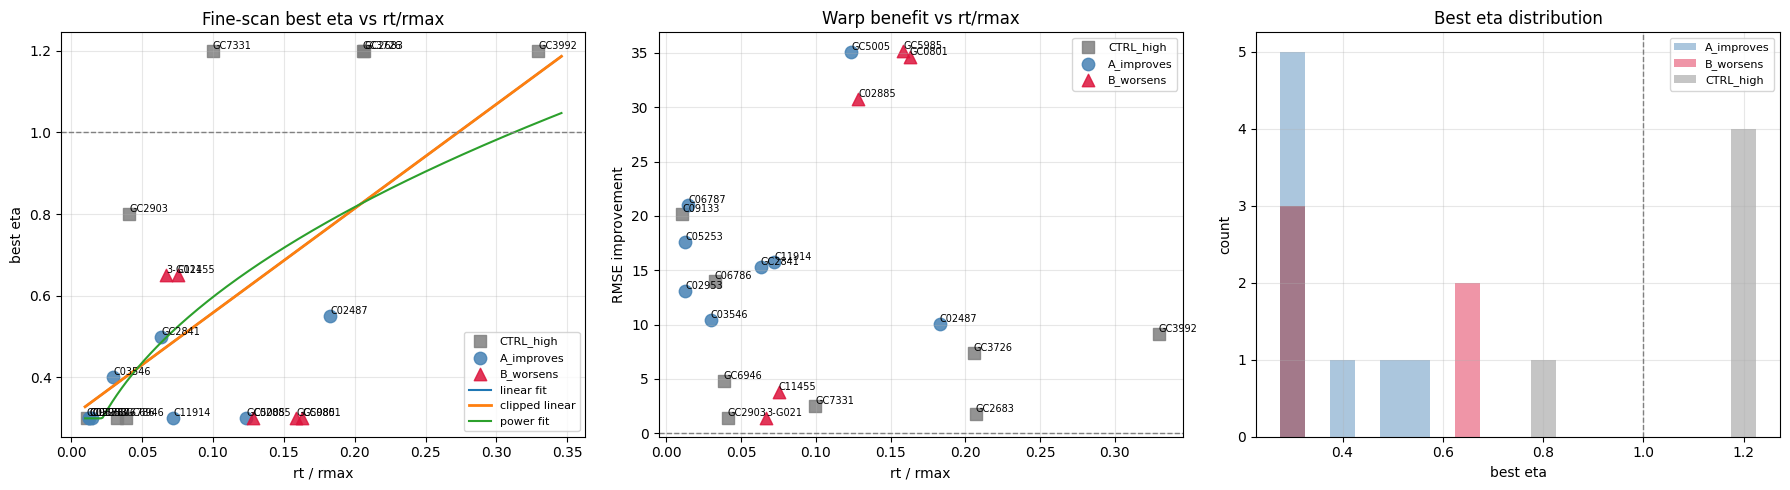

SAVED
/content/mts_fine_eta_scan/fine_eta_scan_detail.csv
/content/mts_fine_eta_scan/fine_eta_best_per_galaxy.csv
/content/mts_fine_eta_scan/fine_eta_fit_summary.csv
/content/mts_fine_eta_scan/fine_eta_failures.csv
/content/mts_fine_eta_scan/fine_eta_summary.png

Done.


In [ ]:
# ============================================================
# MTS FINE ETA SCAN + ETA(rt/rmax) FIT
# ------------------------------------------------------------
# Independent Colab block
#
# Purpose
#   1. Rebuild the 21-galaxy audit sample from rotmod files
#   2. Recompute the fixed backbone:
#        - source = Sp(p=1.25)
#        - Rs = 0.15 * r_bar   (clipped to [0.10, 30.0] kpc)
#        - ALPHA = 0.175
#        - BETA  = 0.55
#        - F_FRAC = 0.60
#   3. For each audit galaxy, run a fine eta scan:
#        eta in [0.30, 1.20] step 0.05
#      where the warped shape is:
#        V_theory_eta(r) = V_flat * [ U(r/eta) / U_inf ]
#   4. Save per-eta detail and per-galaxy best eta
#   5. Fit simple laws for best_eta as a function of rt/rmax
#        - linear
#        - clipped linear
#        - power law
#
# Outputs
#   /content/mts_fine_eta_scan/fine_eta_scan_detail.csv
#   /content/mts_fine_eta_scan/fine_eta_best_per_galaxy.csv
#   /content/mts_fine_eta_scan/fine_eta_fit_summary.csv
#   /content/mts_fine_eta_scan/fine_eta_summary.png
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
]
WORKDIR    = "/content/mts_fine_eta_workspace"
ROTMOD_DIR = os.path.join(WORKDIR, "rotmod")
OUTDIR     = "/content/mts_fine_eta_scan"
os.makedirs(ROTMOD_DIR, exist_ok=True)
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0
P_MEM        = 1.25
K_RS         = 0.15

ETA_GRID = np.round(np.arange(0.30, 1.20 + 0.001, 0.05), 2)

# ----------------------------------------------------------------
# AUDIT SAMPLE
# ----------------------------------------------------------------
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CTRL_HIGH = [
    "NGC2903","NGC6946","UGC06786","UGC09133",
    "NGC2683","NGC3726","NGC3992","NGC7331",
]
AUDIT_NAMES = SUBCLASS_A + SUBCLASS_B + CTRL_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def get_v_flat_obs(rot, outer_frac=0.30):
    r = rot["r"]
    v = rot["vobs"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask = r >= r_cut
    if mask.sum() < 2:
        return float(np.max(v))
    return float(np.median(v[mask]))

def bootstrap_rotmod():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files
    extracted = False
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(ROTMOD_DIR)
            extracted = True
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files and not extracted:
        raise FileNotFoundError("No rotmod zip found and no .dat files present.")
    if not files:
        raise FileNotFoundError("Extraction completed but no .dat files were found.")
    return files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)
    if not rows:
        raise ValueError(f"No numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError(f"No valid data rows in {path}")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def get_log_gpk(rot):
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk    = float(np.max(vbar2 / r_safe))
    return np.log10(gpk) if gpk > 0 else np.nan

def inner_gap_frac(rot):
    r = np.asarray(rot["r"], float)
    if len(r) < 3:
        return np.nan
    return float(r[0] / max(r[-1], 1e-12))

def centre_missing_flag(rot):
    r = np.asarray(rot["r"], float)
    if len(r) < 3:
        return 1
    # simple geometric heuristic
    return int(r[0] > 0.05 * r[-1])

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r      = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval))*1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])
    rho_g = np.empty_like(r)

    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]

    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        cm = rim**2 / (ri**2 * dr**2)
        cp = rip**2 / (ri**2 * dr**2)
        c0 = -(cm + cp) - 1.0 / (Rs**2)

        A[i, i-1] = cm
        A[i, i]   = c0
        A[i, i+1] = cp
        b[i] = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if (not np.isfinite(target)) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def subgroup(name):
    if name in SUBCLASS_A:
        return "A_improves"
    if name in SUBCLASS_B:
        return "B_worsens"
    if name in CTRL_HIGH:
        return "CTRL_high"
    return "other"

def coverage_bin_from_rot(rot):
    return "POOR_COVERAGE" if centre_missing_flag(rot) else "GOOD_COVERAGE"

def warp_shape(U_fn, U_inf, r_obs, eta):
    r_warp = np.asarray(r_obs, float) / max(float(eta), 1e-12)
    shape = np.asarray(U_fn(r_warp), float) / max(float(U_inf), 1e-30)
    return np.clip(shape, 0.0, None)

# fitting helpers
def linear_model(x, c0, c1):
    return c0 + c1*x

def clipped_linear_model(x, c0, c1):
    y = c0 + c1*x
    return np.clip(y, 0.30, 1.20)

def power_model(x, A, m):
    x = np.maximum(np.asarray(x, float), 1e-6)
    return np.clip(A * x**m, 0.30, 1.20)

# ----------------------------------------------------------------
# DISCOVERY
# ----------------------------------------------------------------
all_files = bootstrap_rotmod()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    name_to_path[key] = fp

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Unique galaxies: {len(name_to_path)}")
print(f"Examples: {sorted(list(name_to_path.keys()))[:10]}")
print()

# ----------------------------------------------------------------
# BUILD FIXED-BACKBONE LOADED SAMPLE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for name in AUDIT_NAMES:
    if name not in name_to_path:
        fail_rows.append({"name": name, "stage": "lookup", "reason": "not found"})
        continue
    try:
        rot = read_rotmod_file(name_to_path[name])

        rr, rn = build_Sp(rot, P_MEM)
        r_bar = get_r_bar(rot)
        if not np.isfinite(r_bar) or r_bar <= 0:
            raise RuntimeError("Invalid r_bar")
        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))

        r_obs = rot["r"]
        r_th  = np.linspace(max(R_MIN, float(np.min(r_obs))*0.5),
                            max(float(np.max(r_obs))*1.10, 1.0), N_R)

        r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rr, rn, Rs)
        if not (np.isfinite(U_inf) and U_inf > 0):
            raise RuntimeError("Invalid U_inf")

        rt = radius_at_frac(r_grid, U_grid, F_FRAC)
        if not (np.isfinite(rt) and rt > 0):
            raise RuntimeError("Invalid rt")

        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vb2_fn = interp1d(rot["r"], vbar2, kind="linear",
                          bounds_error=False, fill_value="extrapolate")
        u_t   = max(float(u_fn(rt)), 1e-30)
        vb2_t = max(float(vb2_fn(rt)), 1e-30)

        x_field = (rt * u_t)**ALPHA
        x_bar   = vb2_t**BETA
        carrier = x_field * x_bar
        shape_base = np.asarray(U_fn(r_obs), float) / U_inf
        shape_base = np.clip(shape_base, 0.0, None)

        loaded[name] = {
            "rot": rot,
            "rho_r": rr,
            "rho_n": rn,
            "Rs": Rs,
            "r_bar": r_bar,
            "log_Gpk": get_log_gpk(rot),
            "bar_frac": float(np.median(
                np.sqrt(np.maximum(vbar2[-max(2, int(0.3*len(vbar2))):], 0.0)) /
                np.maximum(rot["vobs"][-max(2, int(0.3*len(vbar2))):], 1.0)
            )),
            "n_pts": len(rot["r"]),
            "centre_missing": centre_missing_flag(rot),
            "inner_gap_frac": inner_gap_frac(rot),
            "coverage_bin": coverage_bin_from_rot(rot),
            "rt": rt,
            "rt_rmax": rt / float(rot["r"][-1]),
            "u_t": u_t,
            "U_inf": U_inf,
            "vbar2_t": vb2_t,
            "x_field": x_field,
            "x_bar": x_bar,
            "carrier_base": carrier,
            "shape_base": shape_base,
            "vobs": rot["vobs"],
            "vmax_obs": float(np.max(rot["vobs"])),
            "U_fn": U_fn,
        }

    except Exception as e:
        fail_rows.append({"name": name, "stage": "build", "reason": str(e)})

print(f"Loaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed: {len(fail_rows)}")
print()

if len(loaded) < 5:
    raise RuntimeError("Too few galaxies loaded to continue.")

# ----------------------------------------------------------------
# FIT GLOBAL C_AMP
# ----------------------------------------------------------------
all_carriers = np.array([loaded[n]["carrier_base"] for n in loaded], float)
all_vmaxes   = np.array([loaded[n]["vmax_obs"] for n in loaded], float)
C_AMP_local  = float(np.mean(all_vmaxes**2) / np.mean(all_carriers))

g_ref = float(np.median([loaded[n]["log_Gpk"] for n in loaded if np.isfinite(loaded[n]["log_Gpk"])]))
r_ref = float(np.median([loaded[n]["rt_rmax"] for n in loaded if np.isfinite(loaded[n]["rt_rmax"])]))

print(f"g_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")
print(f"C_AMP_local: {C_AMP_local:.6f}")
print()

# ----------------------------------------------------------------
# FINE ETA SCAN
# ----------------------------------------------------------------
detail_rows = []
best_rows = []

for name in AUDIT_NAMES:
    if name not in loaded:
        continue

    g = loaded[name]
    rot = g["rot"]
    r_obs = rot["r"]
    v_obs = rot["vobs"]
    ev    = rot["ev"]

    subgroup_name = subgroup(name)
    coverage_bin  = g["coverage_bin"]

    v_flat_base = float(np.sqrt(max(C_AMP_local * g["carrier_base"], 0.0)))
    v_theory_base = v_flat_base * g["shape_base"]
    rmse_base = safe_rmse(v_obs, v_theory_base)
    mae_base  = safe_mae(v_obs, v_theory_base)
    vflat_obs = get_v_flat_obs(rot)
    flat_err_base = abs(vflat_obs - v_flat_base)

    best = None

    for eta in ETA_GRID:
        shape_eta = warp_shape(g["U_fn"], g["U_inf"], r_obs, eta)
        v_theory_eta = v_flat_base * shape_eta

        rmse_eta = safe_rmse(v_obs, v_theory_eta)
        mae_eta  = safe_mae(v_obs, v_theory_eta)
        flat_err_eta = abs(vflat_obs - v_flat_base)  # flat amplitude unchanged by pure warp

        detail_rows.append({
            "galaxy": name,
            "subclass": subgroup_name,
            "coverage_bin": coverage_bin,
            "n_pts": g["n_pts"],
            "centre_missing": g["centre_missing"],
            "log_Gpk": g["log_Gpk"],
            "bar_frac": g["bar_frac"],
            "rt": g["rt"],
            "rt_rmax": g["rt_rmax"],
            "eta": eta,
            "rmse_base": rmse_base,
            "rmse_eta": rmse_eta,
            "rmse_improvement": rmse_base - rmse_eta,
            "mae_base": mae_base,
            "mae_eta": mae_eta,
            "mae_improvement": mae_base - mae_eta,
            "flat_err_base": flat_err_base,
            "flat_err_eta": flat_err_eta,
        })

        if (best is None) or (rmse_eta < best["rmse_best_eta"]):
            best = {
                "galaxy": name,
                "subclass": subgroup_name,
                "coverage_bin": coverage_bin,
                "n_pts": g["n_pts"],
                "centre_missing": g["centre_missing"],
                "log_Gpk": g["log_Gpk"],
                "bar_frac": g["bar_frac"],
                "rt": g["rt"],
                "rt_rmax": g["rt_rmax"],
                "rmse_base": rmse_base,
                "mae_base": mae_base,
                "flat_err_base": flat_err_base,
                "best_eta": eta,
                "eta_shift": eta - 1.0,
                "rmse_best_eta": rmse_eta,
                "rmse_improvement": rmse_base - rmse_eta,
                "mae_best_eta": mae_eta,
                "mae_improvement": mae_base - mae_eta,
                "flat_err_best_eta": flat_err_eta,
            }

    # boundary flags
    best["best_eta_at_lower_edge"] = int(np.isclose(best["best_eta"], ETA_GRID.min()))
    best["best_eta_at_upper_edge"] = int(np.isclose(best["best_eta"], ETA_GRID.max()))
    best_rows.append(best)

detail_df = pd.DataFrame(detail_rows)
best_df   = pd.DataFrame(best_rows).sort_values(["subclass", "coverage_bin", "galaxy"]).reset_index(drop=True)
fail_df   = pd.DataFrame(fail_rows)

# ----------------------------------------------------------------
# FIT eta(rt/rmax)
# ----------------------------------------------------------------
x = best_df["rt_rmax"].to_numpy(float)
y = best_df["best_eta"].to_numpy(float)

fit_rows = []

# linear
try:
    popt_lin, _ = curve_fit(linear_model, x, y, p0=[0.6, 2.0], maxfev=20000)
    yhat = linear_model(x, *popt_lin)
    fit_rows.append({
        "model": "linear",
        "p0": popt_lin[0],
        "p1": popt_lin[1],
        "rmse_fit": safe_rmse(y, yhat),
        "mae_fit": safe_mae(y, yhat),
        "r_data_pred": pearsonr(y, yhat)[0] if len(y) >= 3 else np.nan,
    })
except Exception as e:
    fit_rows.append({"model": "linear", "p0": np.nan, "p1": np.nan,
                     "rmse_fit": np.nan, "mae_fit": np.nan,
                     "r_data_pred": np.nan, "error": str(e)})

# clipped linear
try:
    popt_clip, _ = curve_fit(clipped_linear_model, x, y, p0=[0.6, 2.0], maxfev=20000)
    yhat = clipped_linear_model(x, *popt_clip)
    fit_rows.append({
        "model": "clipped_linear",
        "p0": popt_clip[0],
        "p1": popt_clip[1],
        "rmse_fit": safe_rmse(y, yhat),
        "mae_fit": safe_mae(y, yhat),
        "r_data_pred": pearsonr(y, yhat)[0] if len(y) >= 3 else np.nan,
    })
except Exception as e:
    fit_rows.append({"model": "clipped_linear", "p0": np.nan, "p1": np.nan,
                     "rmse_fit": np.nan, "mae_fit": np.nan,
                     "r_data_pred": np.nan, "error": str(e)})

# power
try:
    popt_pow, _ = curve_fit(power_model, x, y, p0=[0.4, -0.2], bounds=([0.01, -5.0], [10.0, 5.0]), maxfev=20000)
    yhat = power_model(x, *popt_pow)
    fit_rows.append({
        "model": "power",
        "p0": popt_pow[0],
        "p1": popt_pow[1],
        "rmse_fit": safe_rmse(y, yhat),
        "mae_fit": safe_mae(y, yhat),
        "r_data_pred": pearsonr(y, yhat)[0] if len(y) >= 3 else np.nan,
    })
except Exception as e:
    fit_rows.append({"model": "power", "p0": np.nan, "p1": np.nan,
                     "rmse_fit": np.nan, "mae_fit": np.nan,
                     "r_data_pred": np.nan, "error": str(e)})

fit_df = pd.DataFrame(fit_rows).sort_values("rmse_fit")

# ----------------------------------------------------------------
# PRINT SUMMARY
# ----------------------------------------------------------------
print("="*72)
print("FINE ETA SCAN SUMMARY")
print("="*72)
summary_cols = [
    "galaxy","subclass","coverage_bin","rt_rmax","log_Gpk",
    "rmse_base","rmse_best_eta","rmse_improvement","best_eta"
]
print(best_df[summary_cols].sort_values("rmse_improvement", ascending=False).to_string(index=False))
print()

print("="*72)
print("GROUP SUMMARY")
print("="*72)
grp = (
    best_df
    .groupby("subclass", dropna=False)
    .agg(
        n_gal=("galaxy", "size"),
        median_rmse_base=("rmse_base", "median"),
        median_rmse_best_eta=("rmse_best_eta", "median"),
        median_rmse_improvement=("rmse_improvement", "median"),
        mean_rmse_improvement=("rmse_improvement", "mean"),
        median_best_eta=("best_eta", "median"),
        frac_eta_lt_1=("best_eta", lambda s: float(np.mean(np.asarray(s) < 1.0))),
        frac_eta_gt_1=("best_eta", lambda s: float(np.mean(np.asarray(s) > 1.0))),
        frac_at_lower_edge=("best_eta_at_lower_edge", "mean"),
        frac_at_upper_edge=("best_eta_at_upper_edge", "mean"),
    )
    .reset_index()
)
print(grp.to_string(index=False))
print()

grp_cov = (
    best_df
    .groupby("coverage_bin", dropna=False)
    .agg(
        n_gal=("galaxy", "size"),
        median_rmse_base=("rmse_base", "median"),
        median_rmse_best_eta=("rmse_best_eta", "median"),
        median_rmse_improvement=("rmse_improvement", "median"),
        mean_rmse_improvement=("rmse_improvement", "mean"),
        median_best_eta=("best_eta", "median"),
        frac_eta_lt_1=("best_eta", lambda s: float(np.mean(np.asarray(s) < 1.0))),
        frac_eta_gt_1=("best_eta", lambda s: float(np.mean(np.asarray(s) > 1.0))),
        frac_at_lower_edge=("best_eta_at_lower_edge", "mean"),
        frac_at_upper_edge=("best_eta_at_upper_edge", "mean"),
    )
    .reset_index()
)
print("="*72)
print("COVERAGE SUMMARY")
print("="*72)
print(grp_cov.to_string(index=False))
print()

print("="*72)
print("ETA(rt/rmax) FIT SUMMARY")
print("="*72)
print(fit_df.to_string(index=False))
print()

print("="*72)
print("CORRELATIONS")
print("="*72)
for xname in ["rt_rmax", "log_Gpk", "bar_frac", "n_pts"]:
    xx = best_df[xname].to_numpy(float)
    yy = best_df["best_eta"].to_numpy(float)
    if np.isfinite(xx).sum() >= 3:
        rp, pp = pearsonr(xx, yy)
        rs, ps = spearmanr(xx, yy)
        print(f"best_eta vs {xname:8s}: Pearson r={rp:+.3f} (p={pp:.3f})  Spearman rho={rs:+.3f} (p={ps:.3f})")
print()

for xname in ["rt_rmax", "log_Gpk", "bar_frac", "n_pts"]:
    xx = best_df[xname].to_numpy(float)
    yy = best_df["rmse_improvement"].to_numpy(float)
    if np.isfinite(xx).sum() >= 3:
        rp, pp = pearsonr(xx, yy)
        rs, ps = spearmanr(xx, yy)
        print(f"rmse_improvement vs {xname:8s}: Pearson r={rp:+.3f} (p={pp:.3f})  Spearman rho={rs:+.3f} (p={ps:.3f})")
print()

# ----------------------------------------------------------------
# PLOTS
# ----------------------------------------------------------------
colors = {"A_improves": "steelblue", "B_worsens": "crimson", "CTRL_high": "gray", "other": "black"}
markers = {"A_improves": "o", "B_worsens": "^", "CTRL_high": "s", "other": "x"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) best eta vs rt/rmax
ax = axes[0]
for sc in ["CTRL_high", "A_improves", "B_worsens"]:
    d = best_df[best_df["subclass"] == sc]
    if len(d) == 0:
        continue
    ax.scatter(d["rt_rmax"], d["best_eta"], c=colors[sc], marker=markers[sc], s=80, label=sc, alpha=0.85)
    for _, row in d.iterrows():
        ax.annotate(row["galaxy"][-6:], (row["rt_rmax"], row["best_eta"]), fontsize=7, ha="left", va="bottom")

xgrid = np.linspace(max(0.001, best_df["rt_rmax"].min()*0.9), best_df["rt_rmax"].max()*1.05, 300)
for _, row in fit_df.iterrows():
    if row["model"] == "linear" and np.isfinite(row["p0"]):
        ygrid = linear_model(xgrid, row["p0"], row["p1"])
        ax.plot(xgrid, ygrid, lw=1.5, label="linear fit")
    elif row["model"] == "clipped_linear" and np.isfinite(row["p0"]):
        ygrid = clipped_linear_model(xgrid, row["p0"], row["p1"])
        ax.plot(xgrid, ygrid, lw=2.0, label="clipped linear")
    elif row["model"] == "power" and np.isfinite(row["p0"]):
        ygrid = power_model(xgrid, row["p0"], row["p1"])
        ax.plot(xgrid, ygrid, lw=1.5, label="power fit")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("rt / rmax")
ax.set_ylabel("best eta")
ax.set_title("Fine-scan best eta vs rt/rmax")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# 2) rmse improvement vs rt/rmax
ax = axes[1]
for sc in ["CTRL_high", "A_improves", "B_worsens"]:
    d = best_df[best_df["subclass"] == sc]
    if len(d) == 0:
        continue
    ax.scatter(d["rt_rmax"], d["rmse_improvement"], c=colors[sc], marker=markers[sc], s=80, label=sc, alpha=0.85)
    for _, row in d.iterrows():
        ax.annotate(row["galaxy"][-6:], (row["rt_rmax"], row["rmse_improvement"]), fontsize=7, ha="left", va="bottom")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("rt / rmax")
ax.set_ylabel("RMSE improvement")
ax.set_title("Warp benefit vs rt/rmax")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# 3) eta histogram / coverage
ax = axes[2]
bins = np.arange(0.275, 1.225 + 0.05, 0.05)
for sc in ["A_improves", "B_worsens", "CTRL_high"]:
    d = best_df[best_df["subclass"] == sc]
    if len(d) == 0:
        continue
    ax.hist(d["best_eta"], bins=bins, alpha=0.45, label=sc, color=colors[sc])
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("best eta")
ax.set_ylabel("count")
ax.set_title("Best eta distribution")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plot_path = os.path.join(OUTDIR, "fine_eta_summary.png")
plt.savefig(plot_path, dpi=140, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
detail_path = os.path.join(OUTDIR, "fine_eta_scan_detail.csv")
best_path   = os.path.join(OUTDIR, "fine_eta_best_per_galaxy.csv")
fit_path    = os.path.join(OUTDIR, "fine_eta_fit_summary.csv")
fail_path   = os.path.join(OUTDIR, "fine_eta_failures.csv")

detail_df.to_csv(detail_path, index=False)
best_df.to_csv(best_path, index=False)
fit_df.to_csv(fit_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("="*72)
print("SAVED")
print("="*72)
print(detail_path)
print(best_path)
print(fit_path)
print(fail_path)
print(plot_path)

print("\nDone.")

ROTOMD FILE DISCOVERY
Loaded audit galaxies: 21
g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141
C_AMP_local: 347.359025
Usable galaxies after shape build: 21

TWO-REGIME FIXED-ETA SCAN SUMMARY
 eta_good  eta_poor     K0_fit  n_gal  median_rmse  mean_rmse  median_mae  mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  B_median_rmse  B_mean_rmse  B_median_flat_err  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  GOOD_median_rmse  GOOD_mean_rmse  GOOD_median_flat_err  POOR_median_rmse  POOR_mean_rmse  POOR_median_flat_err
      0.2       1.6 347.359025     21    53.963485  65.175927   47.765165 56.435652            51.498912          63.659939      53.434380    64.936643          56.259731      64.591973    67.062731          40.449698         56.272201       64.235959             68.006951         48.523940       52.392890             33.211102        103.393140       90.742001            134.798948
      0.2       1

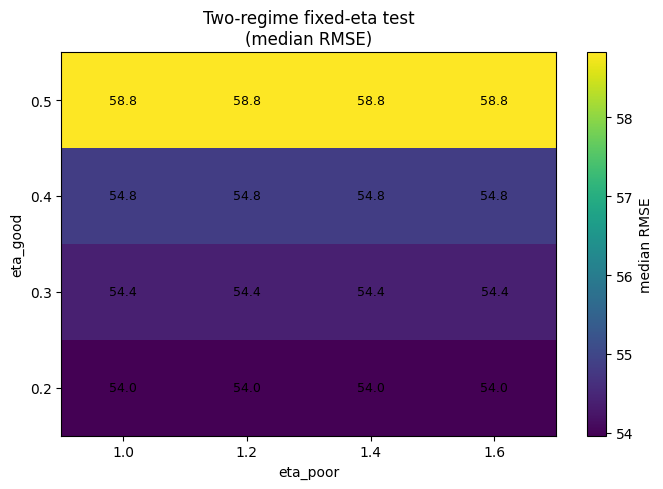


SAVED
/content/mts_two_regime_eta_test/mts_two_regime_eta_scan_summary.csv
/content/mts_two_regime_eta_test/mts_two_regime_eta_best_detail.csv
/content/mts_two_regime_eta_test/mts_two_regime_eta_group_summary.csv
/content/mts_two_regime_eta_test/mts_two_regime_eta_shape_sources.csv
/content/mts_two_regime_eta_test/mts_two_regime_eta_failures.csv
/content/mts_two_regime_eta_test/mts_two_regime_eta_heatmap.png

Done.


In [ ]:
# ============================================================
# MTS TWO-REGIME FIXED-ETA TEST (ROBUST TO MISSING 'shape')
# ------------------------------------------------------------
# Tests the simplest falsifiable next step:
#
#   GOOD_COVERAGE galaxies -> fixed eta_good
#   POOR_COVERAGE galaxies -> fixed eta_poor
#
# It does NOT assume `loaded[name]["shape"]` exists.
# Instead it tries, in order, to build a normalized base shape from:
#   1. explicit shape
#   2. V_theory / vpred arrays
#   3. cumulative U / U_inf
#   4. rho_n cumulative proxy
#   5. monotone Vobs fallback
#
# Assumes these already exist in notebook state:
#   loaded, SUBCLASS_A, SUBCLASS_B, safe_rmse, safe_mae
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

OUTDIR = "/content/mts_two_regime_eta_test"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
required_globals = ["loaded", "SUBCLASS_A", "SUBCLASS_B", "safe_rmse", "safe_mae"]
missing = [x for x in required_globals if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects in notebook state: {missing}")

if len(loaded) == 0:
    raise RuntimeError("loaded is empty.")

sample = next(iter(loaded.values()))
needed_keys = ["coverage_bin", "carrier_base", "vmax_obs", "rt_rmax", "log_Gpk", "rot"]
missing_keys = [k for k in needed_keys if k not in sample]
if missing_keys:
    raise RuntimeError(f"`loaded` entries are missing keys: {missing_keys}")

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Loaded audit galaxies: {len(loaded)}")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def coverage_is_good(x):
    return str(x).strip().upper() == "GOOD_COVERAGE"

def get_subclass(name):
    if name in SUBCLASS_A:
        return "A_improves"
    if name in SUBCLASS_B:
        return "B_worsens"
    return "CTRL_high"

def get_vflat_obs(rot, outer_frac=0.30):
    r = np.asarray(rot["r"], float)
    v = np.asarray(rot["vobs"], float)
    if len(r) == 0:
        return np.nan
    r_cut = r[-1] * (1.0 - outer_frac)
    m = r >= r_cut
    if m.sum() < 2:
        return float(np.max(v))
    return float(np.median(v[m]))

def fit_c_amp_local(loaded_dict):
    carriers, vmaxes = [], []
    for _, g in loaded_dict.items():
        c = g.get("carrier_base", np.nan)
        v = g.get("vmax_obs", np.nan)
        if np.isfinite(c) and np.isfinite(v) and c > 0:
            carriers.append(float(c))
            vmaxes.append(float(v))
    carriers = np.asarray(carriers, float)
    vmaxes   = np.asarray(vmaxes, float)
    return float(np.mean(vmaxes**2) / np.mean(carriers))

def _normalize_monotone(arr, n_target=None):
    arr = np.asarray(arr, float).copy()
    arr = np.where(np.isfinite(arr), arr, np.nan)
    if np.all(~np.isfinite(arr)):
        return None

    # fill NaNs
    idx = np.arange(len(arr))
    good = np.isfinite(arr)
    if good.sum() == 0:
        return None
    if good.sum() == 1:
        arr = np.full(len(arr), arr[good][0], float)
    else:
        arr = np.interp(idx, idx[good], arr[good])

    arr = np.maximum(arr, 0.0)
    arr = np.maximum.accumulate(arr)

    mx = np.max(arr)
    if not np.isfinite(mx) or mx <= 0:
        return None
    arr = arr / mx

    if n_target is not None and len(arr) != n_target:
        x_old = np.linspace(0.0, 1.0, len(arr))
        x_new = np.linspace(0.0, 1.0, n_target)
        f = interp1d(x_old, arr, kind="linear", bounds_error=False,
                     fill_value=(float(arr[0]), float(arr[-1])))
        arr = np.asarray(f(x_new), float)
        arr = np.maximum.accumulate(np.clip(arr, 0.0, None))
        mx = np.max(arr)
        if mx > 0:
            arr = arr / mx

    return arr

def build_base_shape(g):
    """
    Returns a normalized monotone shape on the observed r-grid.
    Priority:
      explicit shape
      explicit predicted velocity arrays
      U/U_inf
      cumulative rho_n
      monotone Vobs fallback
    """
    n = len(g["rot"]["r"])

    # 1) direct shape
    for key in ["shape", "shape_base", "shape_arr"]:
        if key in g:
            s = _normalize_monotone(g[key], n_target=n)
            if s is not None:
                return s, key

    # 2) direct predicted velocity arrays
    for key in ["vpred", "v_pred", "V_theory", "vmodel", "model_v"]:
        if key in g:
            s = _normalize_monotone(g[key], n_target=n)
            if s is not None:
                return s, key

    # 3) cumulative U / U_inf
    if ("U" in g) and ("U_inf" in g):
        U = np.asarray(g["U"], float)
        U_inf = float(g["U_inf"])
        if np.isfinite(U_inf) and U_inf > 0:
            s = _normalize_monotone(U / U_inf, n_target=n)
            if s is not None:
                return s, "U/U_inf"

    # 4) cumulative rho_n proxy
    if "rho_n" in g:
        rho_n = np.asarray(g["rho_n"], float)
        if len(rho_n) > 0:
            cum = np.cumsum(np.maximum(rho_n, 0.0))
            s = _normalize_monotone(cum, n_target=n)
            if s is not None:
                return s, "cumsum(rho_n)"

    # 5) monotone Vobs fallback
    vobs = np.asarray(g["rot"]["vobs"], float)
    s = _normalize_monotone(vobs, n_target=n)
    if s is not None:
        return s, "vobs_fallback"

    raise RuntimeError("Could not build base shape for galaxy.")

def warp_shape_by_eta(shape, eta):
    """
    eta < 1 : earlier transition
    eta > 1 : later transition
    """
    y = np.asarray(shape, float).copy()
    n = len(y)
    if n < 2:
        return y.copy()

    eta = float(eta)
    if not np.isfinite(eta) or eta <= 0:
        return y.copy()

    s_old = np.linspace(0.0, 1.0, n)
    s_new = np.clip(s_old / eta, 0.0, 1.0)

    y = np.maximum.accumulate(np.clip(y, 0.0, None))
    mx = np.max(y)
    if mx > 0:
        y = y / mx

    f = interp1d(s_old, y, kind="linear", bounds_error=False,
                 fill_value=(float(y[0]), float(y[-1])))
    yw = np.asarray(f(s_new), float)
    yw = np.maximum.accumulate(np.clip(yw, 0.0, None))
    mx = np.max(yw)
    if mx > 0:
        yw = yw / mx
    return yw

# ------------------------------------------------------------
# Backbone fit
# ------------------------------------------------------------
C_AMP_local = fit_c_amp_local(loaded)
g_ref = float(np.nanmedian([g["log_Gpk"] for g in loaded.values() if np.isfinite(g["log_Gpk"])]))
r_ref = float(np.nanmedian([g["rt_rmax"] for g in loaded.values() if np.isfinite(g["rt_rmax"])]))

print(f"g_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")
print(f"C_AMP_local: {C_AMP_local:.6f}")

# ------------------------------------------------------------
# Prebuild shapes once
# ------------------------------------------------------------
shape_map = {}
shape_source_rows = []
fail_rows = []

for name, g in loaded.items():
    try:
        shp, src = build_base_shape(g)
        shape_map[name] = shp
        shape_source_rows.append({
            "galaxy": name,
            "shape_source": src,
            "n_shape": len(shp),
            "n_obs": len(g["rot"]["r"])
        })
    except Exception as e:
        fail_rows.append({"galaxy": name, "reason": f"shape build failed: {e}"})

shape_source_df = pd.DataFrame(shape_source_rows)
fail_df = pd.DataFrame(fail_rows)

if len(shape_map) == 0:
    raise RuntimeError("No usable shapes could be built for any galaxy.")

print(f"Usable galaxies after shape build: {len(shape_map)}")
if len(fail_df):
    print("\nShape-build failures:")
    print(fail_df.to_string(index=False))

# ------------------------------------------------------------
# Two-regime scan grid
# ------------------------------------------------------------
ETA_GOOD_GRID = [0.20, 0.30, 0.40, 0.50]
ETA_POOR_GRID = [1.00, 1.20, 1.40, 1.60]

scan_rows = []
best_detail_rows = None
best_score = None
best_cfg = None

for eta_good in ETA_GOOD_GRID:
    for eta_poor in ETA_POOR_GRID:

        detail_rows = []

        for name, g in loaded.items():
            if name not in shape_map:
                continue

            subclass = get_subclass(name)
            coverage_bin = str(g["coverage_bin"])
            eta = eta_good if coverage_is_good(coverage_bin) else eta_poor

            shape_base = shape_map[name]
            shape_warp = warp_shape_by_eta(shape_base, eta)

            carrier = float(g["carrier_base"])
            rot = g["rot"]
            vobs = np.asarray(rot["vobs"], float)
            vmax_obs = float(g["vmax_obs"])
            vflat_obs = get_vflat_obs(rot)

            vflat_pred = float(np.sqrt(max(C_AMP_local * carrier, 0.0)))
            vpred_base = vflat_pred * shape_base
            vpred_warp = vflat_pred * shape_warp

            rmse_base = safe_rmse(vobs, vpred_base)
            rmse_warp = safe_rmse(vobs, vpred_warp)
            mae_base  = safe_mae(vobs, vpred_base)
            mae_warp  = safe_mae(vobs, vpred_warp)

            abs_flat_err_base = abs(vflat_obs - vflat_pred)
            abs_flat_err_warp = abs_flat_err_base  # unchanged by pure shape warp

            detail_rows.append({
                "galaxy": name,
                "subclass": subclass,
                "coverage_bin": coverage_bin,
                "shape_source": shape_source_df.loc[shape_source_df["galaxy"] == name, "shape_source"].iloc[0],
                "eta_used": float(eta),
                "rt_rmax": float(g["rt_rmax"]),
                "log_Gpk": float(g["log_Gpk"]),
                "bar_frac": float(g.get("bar_frac", np.nan)),
                "n_pts": int(g.get("n_pts", len(rot["r"]))),
                "rmse_base": rmse_base,
                "rmse_warp": rmse_warp,
                "rmse_improvement": rmse_base - rmse_warp,
                "mae_base": mae_base,
                "mae_warp": mae_warp,
                "mae_improvement": mae_base - mae_warp,
                "Vflat_obs": vflat_obs,
                "Vflat_pred": vflat_pred,
                "abs_flat_err_base": abs_flat_err_base,
                "abs_flat_err_warp": abs_flat_err_warp,
            })

        d = pd.DataFrame(detail_rows)

        row = {
            "eta_good": eta_good,
            "eta_poor": eta_poor,
            "K0_fit": C_AMP_local,
            "n_gal": len(d),
            "median_rmse": float(d["rmse_warp"].median()),
            "mean_rmse": float(d["rmse_warp"].mean()),
            "median_mae": float(d["mae_warp"].median()),
            "mean_mae": float(d["mae_warp"].mean()),
            "median_abs_flat_err": float(d["abs_flat_err_warp"].median()),
            "mean_abs_flat_err": float(d["abs_flat_err_warp"].mean()),
        }

        for grp in ["A_improves", "B_worsens", "CTRL_high"]:
            dg = d[d["subclass"] == grp]
            if len(dg):
                prefix = grp.split("_")[0] if grp != "CTRL_high" else "CTRL"
                row[f"{prefix}_median_rmse"] = float(dg["rmse_warp"].median())
                row[f"{prefix}_mean_rmse"] = float(dg["rmse_warp"].mean())
                row[f"{prefix}_median_flat_err"] = float(dg["abs_flat_err_warp"].median())

        for grp in ["GOOD_COVERAGE", "POOR_COVERAGE"]:
            dg = d[d["coverage_bin"] == grp]
            if len(dg):
                prefix = "GOOD" if grp == "GOOD_COVERAGE" else "POOR"
                row[f"{prefix}_median_rmse"] = float(dg["rmse_warp"].median())
                row[f"{prefix}_mean_rmse"] = float(dg["rmse_warp"].mean())
                row[f"{prefix}_median_flat_err"] = float(dg["abs_flat_err_warp"].median())

        scan_rows.append(row)

        score = row["median_rmse"]
        if (best_score is None) or (score < best_score):
            best_score = score
            best_cfg = row.copy()
            best_detail_rows = d.copy()

scan_df = pd.DataFrame(scan_rows).sort_values(["median_rmse", "mean_rmse", "eta_good", "eta_poor"]).reset_index(drop=True)
best_detail_df = best_detail_rows.sort_values(["subclass", "coverage_bin", "galaxy"]).reset_index(drop=True)

# ------------------------------------------------------------
# Best-config summaries
# ------------------------------------------------------------
group_rows = []
for grp_name, mask in [
    ("A_improves", best_detail_df["subclass"] == "A_improves"),
    ("B_worsens", best_detail_df["subclass"] == "B_worsens"),
    ("CTRL_high", best_detail_df["subclass"] == "CTRL_high"),
    ("GOOD_COVERAGE", best_detail_df["coverage_bin"] == "GOOD_COVERAGE"),
    ("POOR_COVERAGE", best_detail_df["coverage_bin"] == "POOR_COVERAGE"),
]:
    d = best_detail_df[mask]
    if len(d) == 0:
        continue
    group_rows.append({
        "group": grp_name,
        "n_gal": int(len(d)),
        "median_rmse_base": float(d["rmse_base"].median()),
        "median_rmse_best": float(d["rmse_warp"].median()),
        "median_rmse_improvement": float((d["rmse_base"] - d["rmse_warp"]).median()),
        "mean_rmse_improvement": float((d["rmse_base"] - d["rmse_warp"]).mean()),
        "median_flat_err_base": float(d["abs_flat_err_base"].median()),
        "median_flat_err_best": float(d["abs_flat_err_warp"].median()),
        "median_eta_used": float(d["eta_used"].median()),
    })
group_df = pd.DataFrame(group_rows)

# ------------------------------------------------------------
# Console output
# ------------------------------------------------------------
print("\n" + "="*72)
print("TWO-REGIME FIXED-ETA SCAN SUMMARY")
print("="*72)
print(scan_df.to_string(index=False))

print("\n" + "="*72)
print("BEST OVERALL")
print("="*72)
for k, v in best_cfg.items():
    if isinstance(v, float):
        print(f"{k:24s} {v:.6f}")
    else:
        print(f"{k:24s} {v}")

print("\n" + "="*72)
print("SHAPE SOURCES USED")
print("="*72)
print(shape_source_df.sort_values("galaxy").to_string(index=False))

print("\n" + "="*72)
print("BEST-CONFIG PER-GALAXY DETAIL")
print("="*72)
show_cols = [
    "galaxy", "subclass", "coverage_bin", "shape_source", "eta_used",
    "rt_rmax", "log_Gpk", "rmse_base", "rmse_warp",
    "rmse_improvement", "Vflat_obs", "Vflat_pred", "abs_flat_err_base"
]
print(best_detail_df[show_cols].to_string(index=False))

print("\n" + "="*72)
print("GROUP SUMMARY")
print("="*72)
print(group_df.to_string(index=False))

print("\n" + "="*72)
print("COMPACT READ")
print("="*72)
compact_cols = [
    "eta_good", "eta_poor", "median_rmse",
    "A_median_rmse", "B_median_rmse", "CTRL_median_rmse",
    "GOOD_median_rmse", "POOR_median_rmse"
]
compact_cols = [c for c in compact_cols if c in scan_df.columns]
print(scan_df[compact_cols].to_string(index=False))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
pivot = scan_df.pivot(index="eta_good", columns="eta_poor", values="median_rmse")
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, aspect="auto", origin="lower")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([f"{x:.1f}" for x in pivot.columns])
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([f"{y:.1f}" for y in pivot.index])
ax.set_xlabel("eta_poor")
ax.set_ylabel("eta_good")
ax.set_title("Two-regime fixed-eta test\n(median RMSE)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.1f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="median RMSE")
plt.tight_layout()

plot_path = os.path.join(OUTDIR, "mts_two_regime_eta_heatmap.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
scan_path         = os.path.join(OUTDIR, "mts_two_regime_eta_scan_summary.csv")
detail_path       = os.path.join(OUTDIR, "mts_two_regime_eta_best_detail.csv")
group_path        = os.path.join(OUTDIR, "mts_two_regime_eta_group_summary.csv")
shape_source_path = os.path.join(OUTDIR, "mts_two_regime_eta_shape_sources.csv")
fail_path         = os.path.join(OUTDIR, "mts_two_regime_eta_failures.csv")

scan_df.to_csv(scan_path, index=False)
best_detail_df.to_csv(detail_path, index=False)
group_df.to_csv(group_path, index=False)
shape_source_df.to_csv(shape_source_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(scan_path)
print(detail_path)
print(group_path)
print(shape_source_path)
print(fail_path)
print(plot_path)

print("\nDone.")

ROTOMD FILE DISCOVERY
Loaded audit galaxies: 21
g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141
C_AMP_local: 347.359025
Usable galaxies after shape build: 21

CONTINUOUS ETA(rt/rmax) SCAN SUMMARY
  c0  c1  eta_min  eta_max  median_rmse  mean_rmse  median_abs_flat_err  A_median_rmse  B_median_rmse  CTRL_median_rmse  GOOD_median_rmse  POOR_median_rmse  median_eta_eff  frac_at_eta_min  frac_at_eta_max
0.30 4.0      0.2      1.4    56.333207  75.779221            51.498912      60.550966      56.333207         75.847135         52.679992        128.223464        0.588562         0.000000         0.047619
0.30 4.0      0.3      1.4    56.333207  75.779221            51.498912      60.550966      56.333207         75.847135         52.679992        128.223464        0.588562         0.000000         0.047619
0.30 4.0      0.2      1.2    56.333207  75.823283            51.498912      60.550966      56.333207         75.847135         52.679992        128.223464        0.588

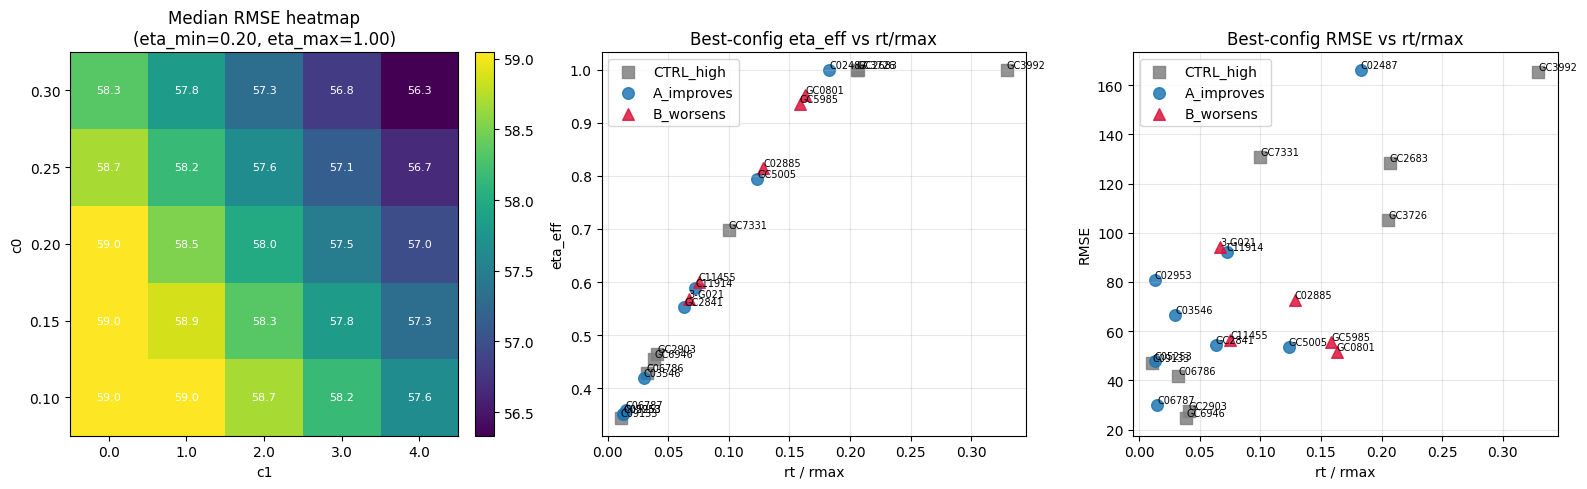


SAVED
/content/mts_continuous_eta_rt_scan/mts_continuous_eta_rt_scan_summary.csv
/content/mts_continuous_eta_rt_scan/mts_continuous_eta_rt_best_detail.csv
/content/mts_continuous_eta_rt_scan/mts_continuous_eta_rt_group_summary.csv
/content/mts_continuous_eta_rt_scan/mts_continuous_eta_rt_shape_sources.csv
/content/mts_continuous_eta_rt_scan/mts_continuous_eta_rt_failures.csv
/content/mts_continuous_eta_rt_scan/mts_continuous_eta_rt_summary.png

Done.


In [ ]:
# ============================================================
# MTS CONTINUOUS ETA(rt/rmax) SCAN
# ------------------------------------------------------------
# Independent Colab block
#
# Purpose
#   Test a continuous transition-warp law:
#
#       eta_eff = clip(c0 + c1 * (rt/rmax), eta_min, eta_max)
#
#   on the currently loaded 21-galaxy audit sample.
#
# What this does
#   1. Rebuild/use shape arrays safely
#   2. Compute baseline RMSE with eta=1
#   3. Scan a small grid in (c0, c1, eta_min, eta_max)
#   4. Report A / B / CTRL / GOOD / POOR separately
#   5. Save summary + best-detail CSVs + diagnostic plot
#
# Assumptions
#   - `loaded` already exists
#   - each loaded entry contains at least:
#       rot, rt_rmax, carrier_base
#   - if `shape` is missing, it is rebuilt from rho_n using cumulative shape
#   - subclass name lists are already defined:
#       SUBCLASS_A, SUBCLASS_B
#
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# OUTPUT DIR
# ------------------------------------------------------------
OUTDIR = "/content/mts_continuous_eta_rt_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# BASIC SAFETY
# ------------------------------------------------------------
if "loaded" not in globals() or not isinstance(loaded, dict) or len(loaded) == 0:
    raise RuntimeError("`loaded` is missing or empty.")

sample = next(iter(loaded.values()))
required_min = ["rot", "rt_rmax", "carrier_base"]
missing_min = [k for k in required_min if k not in sample]
if missing_min:
    raise RuntimeError(f"`loaded` entries are missing required keys: {missing_min}")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def safe_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((y_true[m] - y_pred[m])**2)))

def safe_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(y_true[m] - y_pred[m])))

def get_subclass(name):
    if "SUBCLASS_A" in globals() and name in SUBCLASS_A:
        return "A_improves"
    if "SUBCLASS_B" in globals() and name in SUBCLASS_B:
        return "B_worsens"
    return "CTRL_high"

def get_coverage_bin(gdata):
    return gdata.get("coverage_bin", "UNKNOWN")

def build_shape_from_rho_n(rot, rho_n):
    """
    Rebuild shape from normalized source profile rho_n via cumulative transport:
        S(r) = cumulative integral of rho_n dr
        shape = sqrt(1 - exp(-S / S_end))
    This mirrors the monotonic cumulative-style shape used throughout the audit.
    """
    r = np.asarray(rot["r"], dtype=float)
    rho_n = np.asarray(rho_n, dtype=float)
    if len(r) != len(rho_n):
        raise ValueError("rho_n length does not match r length")
    if len(r) < 2:
        return np.ones_like(r)

    rho_n = np.nan_to_num(rho_n, nan=0.0, posinf=0.0, neginf=0.0)
    rho_n = np.maximum(rho_n, 0.0)

    dr = np.diff(r)
    dr = np.where(np.isfinite(dr) & (dr > 0), dr, np.nanmedian(dr[np.isfinite(dr) & (dr > 0)]) if np.any(np.isfinite(dr) & (dr > 0)) else 1.0)

    s = np.zeros_like(r, dtype=float)
    for i in range(1, len(r)):
        s[i] = s[i-1] + 0.5 * (rho_n[i] + rho_n[i-1]) * dr[i-1]

    s_end = float(s[-1])
    if not np.isfinite(s_end) or s_end <= 0:
        return np.ones_like(r)

    x = np.clip(s / s_end, 0.0, None)
    shape = np.sqrt(np.clip(1.0 - np.exp(-x * 5.0), 0.0, 1.0))

    vmax = float(np.nanmax(shape))
    if not np.isfinite(vmax) or vmax <= 0:
        return np.ones_like(r)
    return shape / vmax

def get_shape_array(gdata):
    """
    Use existing shape if available.
    Otherwise rebuild from rho_n if present.
    Final fallback: simple cumulative-from-rho_r if available.
    """
    rot = gdata["rot"]

    if "shape" in gdata:
        shp = np.asarray(gdata["shape"], dtype=float)
        if len(shp) == len(rot["r"]) and np.all(np.isfinite(shp)):
            mx = np.nanmax(shp)
            if np.isfinite(mx) and mx > 0:
                return shp / mx, "shape_base"

    if "rho_n" in gdata:
        shp = build_shape_from_rho_n(rot, gdata["rho_n"])
        return shp, "shape_from_rho_n"

    if "rho_r" in gdata:
        rho_r = np.asarray(gdata["rho_r"], dtype=float)
        rr = np.asarray(rot["r"], dtype=float)
        if len(rho_r) == len(rr):
            rho_n = rho_r / max(float(np.nanmax(np.abs(rho_r))), 1e-30)
            shp = build_shape_from_rho_n(rot, rho_n)
            return shp, "shape_from_rho_r"

    # last-resort monotonic flat shape
    shp = np.ones_like(np.asarray(rot["r"], dtype=float))
    return shp, "shape_flat_fallback"

def warp_shape_eta(shape, eta):
    """
    Transition warp:
      shape_warp(r) = shape(r)^eta, then renormalize to max=1.

    eta < 1  -> earlier / faster rise
    eta > 1  -> later / slower rise
    """
    shape = np.asarray(shape, dtype=float)
    shape = np.clip(shape, 1e-12, 1.0)
    warped = shape ** float(eta)
    mx = float(np.nanmax(warped))
    if not np.isfinite(mx) or mx <= 0:
        return shape.copy()
    return warped / mx

def get_vflat_obs(rot, outer_frac=0.30):
    r = np.asarray(rot["r"], dtype=float)
    v = np.asarray(rot["vobs"], dtype=float)
    if len(r) == 0:
        return np.nan
    rcut = float(r[-1]) * (1.0 - outer_frac)
    m = r >= rcut
    if m.sum() < 2:
        return float(np.nanmax(v))
    return float(np.nanmedian(v[m]))

def summarize_block(df, prefix=""):
    out = {}
    if len(df) == 0:
        keys = [
            "median_rmse","mean_rmse","median_mae","mean_mae",
            "median_abs_flat_err","mean_abs_flat_err"
        ]
        for k in keys:
            out[f"{prefix}{k}"] = np.nan
        return out

    out[f"{prefix}median_rmse"] = float(df["rmse"].median())
    out[f"{prefix}mean_rmse"] = float(df["rmse"].mean())
    out[f"{prefix}median_mae"] = float(df["mae"].median())
    out[f"{prefix}mean_mae"] = float(df["mae"].mean())
    out[f"{prefix}median_abs_flat_err"] = float(df["abs_flat_err"].median())
    out[f"{prefix}mean_abs_flat_err"] = float(df["abs_flat_err"].mean())
    return out

# ------------------------------------------------------------
# DISCOVERY / PREP
# ------------------------------------------------------------
all_names = sorted(list(loaded.keys()))
print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Loaded audit galaxies: {len(all_names)}")

# references
log_gpk_vals = [loaded[n].get("log_Gpk", np.nan) for n in all_names]
rt_rmax_vals = [loaded[n].get("rt_rmax", np.nan) for n in all_names]
g_ref = float(np.nanmedian(log_gpk_vals))
r_ref = float(np.nanmedian(rt_rmax_vals))
print(f"g_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")

# fit C_AMP from current loaded sample
carrier_all = []
vmax_all = []
shape_source_rows = []

for name in all_names:
    g = loaded[name]
    rot = g["rot"]
    shape_arr, shape_source = get_shape_array(g)
    g["_shape_work"] = shape_arr
    g["_shape_source"] = shape_source

    vmax_obs = g.get("vmax_obs", None)
    if vmax_obs is None:
        vmax_obs = float(np.nanmax(np.asarray(rot["vobs"], dtype=float)))
    g["_vmax_obs_work"] = float(vmax_obs)

    c = g.get("carrier_base", np.nan)
    if np.isfinite(c) and c > 0 and np.isfinite(vmax_obs) and vmax_obs > 0:
        carrier_all.append(float(c))
        vmax_all.append(float(vmax_obs))

    shape_source_rows.append({
        "galaxy": name,
        "shape_source": shape_source,
        "n_shape": len(shape_arr),
        "n_obs": len(rot["r"])
    })

if len(carrier_all) == 0:
    raise RuntimeError("Could not fit C_AMP_local: no usable carrier/vmax pairs.")

C_AMP_local = float(np.mean(np.array(vmax_all)**2) / np.mean(np.array(carrier_all)))
print(f"C_AMP_local: {C_AMP_local:.6f}")
print(f"Usable galaxies after shape build: {len(all_names)}")
print()

# ------------------------------------------------------------
# SCAN GRID
# ------------------------------------------------------------
c0_grid = [0.10, 0.15, 0.20, 0.25, 0.30]
c1_grid = [0.0, 1.0, 2.0, 3.0, 4.0]
eta_min_grid = [0.20, 0.30]
eta_max_grid = [1.00, 1.20, 1.40]

scan_rows = []
best_detail_df = None
best_score = np.inf
best_cfg = None

# ------------------------------------------------------------
# MAIN SCAN
# ------------------------------------------------------------
for c0 in c0_grid:
    for c1 in c1_grid:
        for eta_min in eta_min_grid:
            for eta_max in eta_max_grid:

                detail_rows = []

                for name in all_names:
                    g = loaded[name]
                    rot = g["rot"]
                    r = np.asarray(rot["r"], dtype=float)
                    vobs = np.asarray(rot["vobs"], dtype=float)

                    shape_base = g["_shape_work"]
                    rt_rmax = float(g.get("rt_rmax", np.nan))

                    eta_eff_raw = c0 + c1 * rt_rmax
                    eta_eff = float(np.clip(eta_eff_raw, eta_min, eta_max))

                    shape_warp = warp_shape_eta(shape_base, eta_eff)

                    carrier = float(g["carrier_base"])
                    vflat_pred = float(np.sqrt(max(C_AMP_local * carrier, 0.0)))

                    vpred = vflat_pred * shape_warp

                    rmse = safe_rmse(vobs, vpred)
                    mae = safe_mae(vobs, vpred)

                    vflat_obs = get_vflat_obs(rot)
                    abs_flat_err = abs(vflat_obs - vflat_pred)

                    detail_rows.append({
                        "galaxy": name,
                        "subclass": get_subclass(name),
                        "coverage_bin": get_coverage_bin(g),
                        "shape_source": g["_shape_source"],
                        "eta_eff_raw": eta_eff_raw,
                        "eta_eff": eta_eff,
                        "rt_rmax": rt_rmax,
                        "log_Gpk": float(g.get("log_Gpk", np.nan)),
                        "bar_frac": float(g.get("bar_frac", np.nan)),
                        "n_pts": int(g.get("n_pts", len(r))),
                        "rmse": rmse,
                        "mae": mae,
                        "Vflat_obs": vflat_obs,
                        "Vflat_pred": vflat_pred,
                        "abs_flat_err": abs_flat_err,
                    })

                ddf = pd.DataFrame(detail_rows)

                row = {
                    "c0": c0,
                    "c1": c1,
                    "eta_min": eta_min,
                    "eta_max": eta_max,
                    "K0_fit": C_AMP_local,
                    "n_gal": int(len(ddf)),
                }

                # overall
                row.update(summarize_block(ddf, prefix=""))

                # subclasses
                row.update(summarize_block(ddf[ddf["subclass"]=="A_improves"], prefix="A_"))
                row.update(summarize_block(ddf[ddf["subclass"]=="B_worsens"], prefix="B_"))
                row.update(summarize_block(ddf[ddf["subclass"]=="CTRL_high"], prefix="CTRL_"))

                # coverage
                row.update(summarize_block(ddf[ddf["coverage_bin"]=="GOOD_COVERAGE"], prefix="GOOD_"))
                row.update(summarize_block(ddf[ddf["coverage_bin"]=="POOR_COVERAGE"], prefix="POOR_"))

                row["median_eta_eff"] = float(ddf["eta_eff"].median())
                row["mean_eta_eff"] = float(ddf["eta_eff"].mean())
                row["frac_at_eta_min"] = float(np.mean(np.isclose(ddf["eta_eff"], eta_min)))
                row["frac_at_eta_max"] = float(np.mean(np.isclose(ddf["eta_eff"], eta_max)))

                scan_rows.append(row)

                score = row["median_rmse"]
                if np.isfinite(score) and score < best_score:
                    best_score = score
                    best_cfg = row.copy()
                    best_detail_df = ddf.copy()

summary_df = pd.DataFrame(scan_rows).sort_values(
    ["median_rmse", "mean_rmse", "median_abs_flat_err", "c0", "c1"]
).reset_index(drop=True)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------
print("="*72)
print("CONTINUOUS ETA(rt/rmax) SCAN SUMMARY")
print("="*72)
display_cols = [
    "c0","c1","eta_min","eta_max",
    "median_rmse","mean_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "GOOD_median_rmse","POOR_median_rmse",
    "median_eta_eff","frac_at_eta_min","frac_at_eta_max"
]
print(summary_df[display_cols].to_string(index=False))

print("\n" + "="*72)
print("BEST OVERALL")
print("="*72)
for k, v in best_cfg.items():
    if isinstance(v, (int, np.integer)):
        print(f"{k:24s} {int(v)}")
    elif isinstance(v, (float, np.floating)):
        print(f"{k:24s} {float(v):.6f}")
    else:
        print(f"{k:24s} {v}")

# ------------------------------------------------------------
# PER-GALAXY DETAIL FOR BEST CONFIG
# ------------------------------------------------------------
best_detail_df = best_detail_df.sort_values(
    ["subclass", "coverage_bin", "rmse", "galaxy"]
).reset_index(drop=True)

print("\n" + "="*72)
print("BEST-CONFIG PER-GALAXY DETAIL")
print("="*72)
detail_show_cols = [
    "galaxy","subclass","coverage_bin","shape_source",
    "eta_eff","rt_rmax","log_Gpk","rmse","Vflat_obs","Vflat_pred","abs_flat_err"
]
print(best_detail_df[detail_show_cols].to_string(index=False))

# ------------------------------------------------------------
# GROUP SUMMARY FOR BEST CONFIG
# ------------------------------------------------------------
group_rows = []
for group_name, mask in [
    ("A_improves", best_detail_df["subclass"]=="A_improves"),
    ("B_worsens", best_detail_df["subclass"]=="B_worsens"),
    ("CTRL_high", best_detail_df["subclass"]=="CTRL_high"),
    ("GOOD_COVERAGE", best_detail_df["coverage_bin"]=="GOOD_COVERAGE"),
    ("POOR_COVERAGE", best_detail_df["coverage_bin"]=="POOR_COVERAGE"),
]:
    d = best_detail_df[mask]
    group_rows.append({
        "group": group_name,
        "n_gal": int(len(d)),
        "median_rmse": float(d["rmse"].median()) if len(d) else np.nan,
        "mean_rmse": float(d["rmse"].mean()) if len(d) else np.nan,
        "median_abs_flat_err": float(d["abs_flat_err"].median()) if len(d) else np.nan,
        "mean_abs_flat_err": float(d["abs_flat_err"].mean()) if len(d) else np.nan,
        "median_eta_eff": float(d["eta_eff"].median()) if len(d) else np.nan,
    })
group_summary_df = pd.DataFrame(group_rows)

print("\n" + "="*72)
print("GROUP SUMMARY")
print("="*72)
print(group_summary_df.to_string(index=False))

# ------------------------------------------------------------
# DIAGNOSTIC PLOTS
# ------------------------------------------------------------
# 1) heatmap-like pivot for median RMSE at best eta_min/eta_max slice
best_eta_min = best_cfg["eta_min"]
best_eta_max = best_cfg["eta_max"]
slice_df = summary_df[
    np.isclose(summary_df["eta_min"], best_eta_min) &
    np.isclose(summary_df["eta_max"], best_eta_max)
].copy()

pivot = slice_df.pivot(index="c0", columns="c1", values="median_rmse").sort_index(ascending=True)

# 2) best-config eta_eff vs rt_rmax
fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
im = ax1.imshow(pivot.values, aspect="auto", origin="lower")
ax1.set_xticks(range(len(pivot.columns)))
ax1.set_xticklabels([f"{x:.1f}" for x in pivot.columns])
ax1.set_yticks(range(len(pivot.index)))
ax1.set_yticklabels([f"{x:.2f}" for x in pivot.index])
ax1.set_xlabel("c1")
ax1.set_ylabel("c0")
ax1.set_title(f"Median RMSE heatmap\n(eta_min={best_eta_min:.2f}, eta_max={best_eta_max:.2f})")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax1.text(j, i, f"{pivot.values[i,j]:.1f}", ha="center", va="center", fontsize=8, color="white")
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

ax2 = plt.subplot(1, 3, 2)
color_map = {"A_improves":"tab:blue", "B_worsens":"crimson", "CTRL_high":"gray"}
marker_map = {"A_improves":"o", "B_worsens":"^", "CTRL_high":"s"}
for sc in ["CTRL_high", "A_improves", "B_worsens"]:
    d = best_detail_df[best_detail_df["subclass"]==sc]
    ax2.scatter(d["rt_rmax"], d["eta_eff"], c=color_map[sc], marker=marker_map[sc], s=70, label=sc, alpha=0.85)
    for _, rr in d.iterrows():
        ax2.annotate(rr["galaxy"][-6:], (rr["rt_rmax"], rr["eta_eff"]), fontsize=7, ha="left", va="bottom")
ax2.set_xlabel("rt / rmax")
ax2.set_ylabel("eta_eff")
ax2.set_title("Best-config eta_eff vs rt/rmax")
ax2.legend()
ax2.grid(alpha=0.3)

ax3 = plt.subplot(1, 3, 3)
for sc in ["CTRL_high", "A_improves", "B_worsens"]:
    d = best_detail_df[best_detail_df["subclass"]==sc]
    ax3.scatter(d["rt_rmax"], d["rmse"], c=color_map[sc], marker=marker_map[sc], s=70, label=sc, alpha=0.85)
    for _, rr in d.iterrows():
        ax3.annotate(rr["galaxy"][-6:], (rr["rt_rmax"], rr["rmse"]), fontsize=7, ha="left", va="bottom")
ax3.set_xlabel("rt / rmax")
ax3.set_ylabel("RMSE")
ax3.set_title("Best-config RMSE vs rt/rmax")
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTDIR, "mts_continuous_eta_rt_summary.png")
plt.savefig(plot_path, dpi=140, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_continuous_eta_rt_scan_summary.csv")
detail_path = os.path.join(OUTDIR, "mts_continuous_eta_rt_best_detail.csv")
group_path = os.path.join(OUTDIR, "mts_continuous_eta_rt_group_summary.csv")
shape_src_path = os.path.join(OUTDIR, "mts_continuous_eta_rt_shape_sources.csv")
fail_path = os.path.join(OUTDIR, "mts_continuous_eta_rt_failures.csv")

summary_df.to_csv(summary_path, index=False)
best_detail_df.to_csv(detail_path, index=False)
group_summary_df.to_csv(group_path, index=False)
pd.DataFrame(shape_source_rows).to_csv(shape_src_path, index=False)
pd.DataFrame(columns=["galaxy","reason"]).to_csv(fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(detail_path)
print(group_path)
print(shape_src_path)
print(fail_path)
print(plot_path)

print("\nDone.")

POST-WARP RESIDUAL AUDIT
Loaded audit galaxies: 21
C_AMP_local: 347.359025
eta_eff(rt/rmax) = clip(0.30 + 4.0*(rt/rmax), 0.20, 1.00)

PER-GALAXY POST-WARP AUDIT
     galaxy   subclass  coverage_bin  rt_rmax  eta_eff  log_Gpk  rmse_base  rmse_corr  rmse_improvement  flat_ratio_corr  shape_rmse_base  shape_rmse_corr           classification
    NGC5005 A_improves GOOD_COVERAGE 0.123564 0.794257 5.116940  54.726945  47.610042          7.116903         1.111903         0.164118         0.133634        SOURCE_SHAPE_FAIL
   UGC02953 A_improves GOOD_COVERAGE 0.012684 0.350736 5.216150  94.865313  83.788191         11.077122         1.300209         0.144842         0.133382      AMPLITUDE_STILL_OFF
   UGC03546 A_improves GOOD_COVERAGE 0.029644 0.418578 5.400365  68.893797  52.586201         16.307595         0.752333         0.272558         0.217327        SOURCE_SHAPE_FAIL
   UGC05253 A_improves GOOD_COVERAGE 0.012687 0.350747 5.292060  61.375187  47.256362         14.118825         1.03922

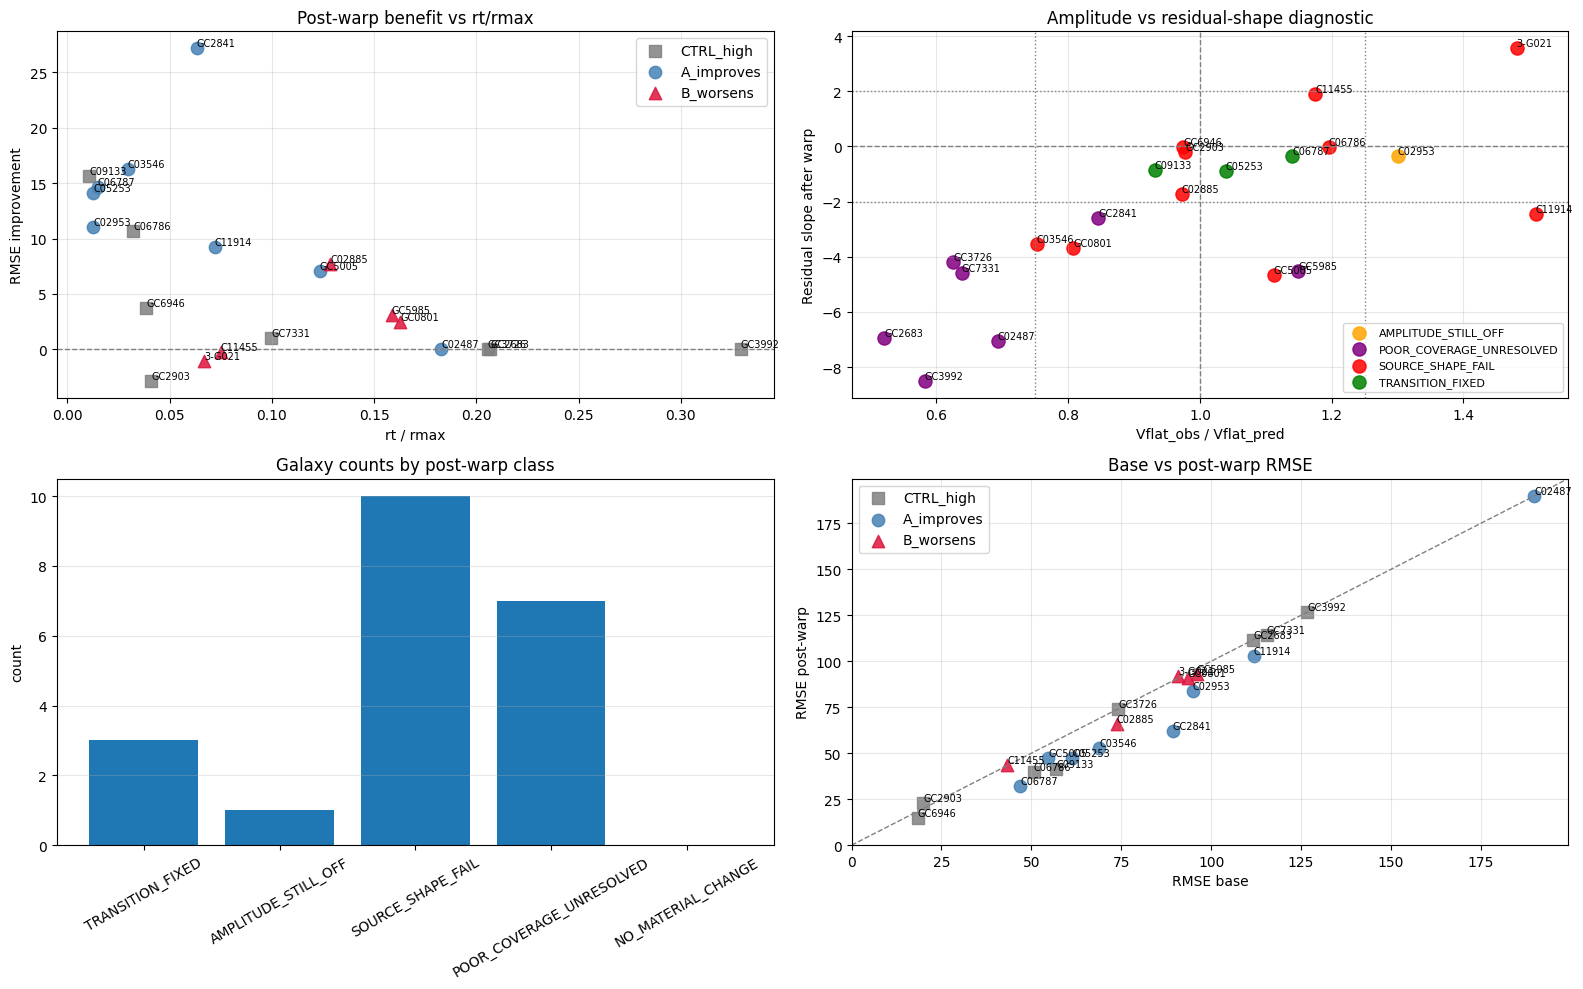

SAVED
/content/mts_post_warp_residual_audit/post_warp_residual_audit_detail.csv
/content/mts_post_warp_residual_audit/post_warp_residual_audit_summary.csv
/content/mts_post_warp_residual_audit/post_warp_residual_audit_failures.csv
/content/mts_post_warp_residual_audit/post_warp_residual_audit_plots.png

QUICK READ
     galaxy   subclass  coverage_bin  rt_rmax  eta_eff  rmse_base  rmse_corr  rmse_improvement  flat_ratio_corr           classification
   UGC02953 A_improves GOOD_COVERAGE 0.012684 0.350736  94.865313  83.788191         11.077122         1.300209      AMPLITUDE_STILL_OFF
    NGC2841 A_improves POOR_COVERAGE 0.063355 0.553422  89.375701  62.169658         27.206043         0.845404 POOR_COVERAGE_UNRESOLVED
    NGC5985  B_worsens POOR_COVERAGE 0.158663 0.934651  95.984319  92.896161          3.088158         1.149364 POOR_COVERAGE_UNRESOLVED
    NGC7331  CTRL_high POOR_COVERAGE 0.099708 0.698831 115.492422 114.432192          1.060230         0.638414 POOR_COVERAGE_UNRESOLVED

In [ ]:
# ============================================================
# POST-WARP RESIDUAL AUDIT
# ------------------------------------------------------------
# Independent Colab cell
#
# Purpose:
#   Using the current loaded audit sample, build the post-warp
#   prediction with the best continuous eta(rt/rmax) law:
#
#       eta_eff = clip(c0 + c1*(rt/rmax), eta_min, eta_max)
#
#   defaulting to the current best:
#       c0 = 0.30, c1 = 4.0, eta_min = 0.20, eta_max = 1.00
#
#   Then classify each galaxy into:
#       - TRANSITION_FIXED
#       - AMPLITUDE_STILL_OFF
#       - SOURCE_SHAPE_FAIL
#       - POOR_COVERAGE_UNRESOLVED
#       - NO_MATERIAL_CHANGE
#
# Outputs:
#   /content/mts_post_warp_residual_audit/
#       post_warp_residual_audit_detail.csv
#       post_warp_residual_audit_summary.csv
#       post_warp_residual_audit_failures.csv
#       post_warp_residual_audit_plots.png
#
# Requirements:
#   Expects in memory:
#       loaded : dict of galaxy payloads
#       ALPHA, BETA
#   Optional:
#       SUBCLASS_A, SUBCLASS_B
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
OUTDIR = "/content/mts_post_warp_residual_audit"
os.makedirs(OUTDIR, exist_ok=True)

# Best continuous eta(rt/rmax) law from current run
C0       = 0.30
C1       = 4.0
ETA_MIN  = 0.20
ETA_MAX  = 1.00

# Classification thresholds
RMSE_IMPROVE_GOOD      = 10.0   # km/s
RMSE_IMPROVE_SMALL     = 5.0    # km/s
AMP_TOL_GOOD           = 0.15   # |Vflat_obs/Vflat_pred - 1|
AMP_TOL_BAD            = 0.25
RESID_SLOPE_STRONG     = 2.0    # km/s per kpc
RESID_SLOPE_MOD        = 1.0
INNER_OUTER_GAP_STRONG = 20.0   # km/s
INNER_OUTER_GAP_MOD    = 10.0

# ------------------------------------------------------------------
# SAFETY / HELPERS
# ------------------------------------------------------------------
if "loaded" not in globals():
    raise RuntimeError("`loaded` not found in memory.")

if "ALPHA" not in globals():
    ALPHA = 0.175
if "BETA" not in globals():
    BETA = 0.55

SUBCLASS_A_LOCAL = globals().get("SUBCLASS_A", [])
SUBCLASS_B_LOCAL = globals().get("SUBCLASS_B", [])

sample = next(iter(loaded.values()))
needed = ["rot", "rt", "rt_rmax", "u_t", "vbar2_t", "carrier_base", "log_Gpk", "bar_frac"]
missing = [k for k in needed if k not in sample]
if missing:
    raise RuntimeError(f"`loaded` entries are missing keys: {missing}")

def safe_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((y_true[m] - y_pred[m])**2)))

def safe_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(y_true[m] - y_pred[m])))

def vbar2_from_rot(rot):
    cols = rot.keys()
    vgas   = np.asarray(rot["vgas"], dtype=float)   if "vgas"   in cols else 0.0
    vdisk  = np.asarray(rot["vdisk"], dtype=float)  if "vdisk"  in cols else 0.0
    vbulge = np.asarray(rot["vbulge"], dtype=float) if "vbulge" in cols else 0.0
    return np.maximum(vgas**2 + vdisk**2 + vbulge**2, 0.0)

def get_v_flat_obs(rot, outer_frac=0.30):
    r    = np.asarray(rot["r"], dtype=float)
    vobs = np.asarray(rot["vobs"], dtype=float)
    if len(r) == 0:
        return np.nan
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        return float(np.nanmax(vobs))
    return float(np.nanmedian(vobs[mask]))

def get_subclass(name):
    if name in SUBCLASS_B_LOCAL:
        return "B_worsens"
    if name in SUBCLASS_A_LOCAL:
        return "A_improves"
    return "CTRL_high"

def get_coverage(gdata, rot):
    if "coverage_bin" in gdata:
        val = str(gdata["coverage_bin"])
        if "GOOD" in val.upper():
            return "GOOD_COVERAGE"
        if "POOR" in val.upper():
            return "POOR_COVERAGE"
    centre_missing = int(gdata.get("centre_missing", 0))
    n_pts = int(gdata.get("n_pts", len(rot["r"])))
    rt_rmax = float(gdata.get("rt_rmax", np.nan))
    if (centre_missing == 0) and (n_pts >= 25) and (rt_rmax <= 0.12):
        return "GOOD_COVERAGE"
    return "POOR_COVERAGE"

def build_shape_from_rho_n(rot, rho_n, eta_eff):
    """
    Rebuild shape from rho_n using the same warp idea:
      cumulative -> normalized -> power/warp by eta_eff
    This is deliberately simple and robust for audit purposes.
    """
    r = np.asarray(rot["r"], dtype=float)
    rho_n = np.asarray(rho_n, dtype=float)
    n = min(len(r), len(rho_n))
    r = r[:n]
    rho_n = rho_n[:n]

    if n < 2:
        return np.ones(n, dtype=float), "degenerate_shape"

    rho_pos = np.maximum(rho_n, 0.0)
    dr = np.diff(r, prepend=r[0])
    if len(dr) > 1:
        dr[0] = dr[1]
    dr = np.maximum(dr, 1e-6)

    # cumulative proxy
    cum = np.cumsum(rho_pos * dr)
    if not np.isfinite(cum).all() or cum[-1] <= 0:
        return np.ones(n, dtype=float), "fallback_flat"

    s = cum / cum[-1]
    s = np.clip(s, 0.0, 1.0)

    # eta<1 -> earlier rise, eta>1 -> later rise
    shape = np.power(s, eta_eff)
    shape = np.clip(shape, 0.0, 1.0)

    # normalize to max=1
    mx = np.nanmax(shape)
    if not np.isfinite(mx) or mx <= 0:
        return np.ones(n, dtype=float), "fallback_flat"
    shape = shape / mx
    return shape, "shape_from_rho_n"

def build_shape_for_galaxy(gdata):
    rot = gdata["rot"]
    eta_eff = float(np.clip(C0 + C1 * float(gdata["rt_rmax"]), ETA_MIN, ETA_MAX))

    # Prefer explicit shape rebuild from rho_n when available.
    if "rho_n" in gdata:
        shape, src = build_shape_from_rho_n(rot, gdata["rho_n"], eta_eff)
        if len(shape) == len(rot["r"]):
            return shape, eta_eff, src

    # fallback to stored shape if present
    if "shape" in gdata:
        shape = np.asarray(gdata["shape"], dtype=float)
        if len(shape) == len(rot["r"]):
            return shape, eta_eff, "shape_base"

    # final fallback: cumulative proxy from carrier / rt
    n = len(rot["r"])
    r = np.asarray(rot["r"], dtype=float)
    rt = float(gdata["rt"])
    x = np.clip(r / max(rt, 1e-6), 0.0, None)
    shape = 1.0 - np.exp(-np.power(x, max(eta_eff, 1e-4)))
    mx = np.nanmax(shape)
    if mx > 0:
        shape = shape / mx
    else:
        shape = np.ones(n)
    return shape, eta_eff, "analytic_fallback"

def classify_galaxy(row):
    cov = row["coverage_bin"]
    rmse_imp = row["rmse_improvement"]
    flat_ratio = row["flat_ratio_corr"]
    slope = row["slope_resid_corr"]
    gap = abs(row["resid_inner_corr"] - row["resid_outer_corr"])
    poor = (cov == "POOR_COVERAGE")

    # 1) genuinely fixed by transition warp
    if (rmse_imp >= RMSE_IMPROVE_GOOD) and (abs(flat_ratio - 1.0) <= AMP_TOL_GOOD) and (abs(slope) <= RESID_SLOPE_MOD):
        return "TRANSITION_FIXED"

    # 2) poor coverage still unresolved after warp
    if poor and (
        (row["rmse_corr"] >= 85.0) or
        (abs(flat_ratio - 1.0) > AMP_TOL_BAD) or
        (abs(slope) > RESID_SLOPE_STRONG) or
        (gap > INNER_OUTER_GAP_STRONG)
    ):
        return "POOR_COVERAGE_UNRESOLVED"

    # 3) amplitude still wrong even after warp
    if abs(flat_ratio - 1.0) > AMP_TOL_BAD and abs(slope) <= RESID_SLOPE_MOD:
        return "AMPLITUDE_STILL_OFF"

    # 4) underlying source/shape still wrong
    if (abs(slope) > RESID_SLOPE_STRONG) or (gap > INNER_OUTER_GAP_STRONG):
        return "SOURCE_SHAPE_FAIL"

    # 5) small / ambiguous change
    if rmse_imp < RMSE_IMPROVE_SMALL:
        return "NO_MATERIAL_CHANGE"

    # 6) fallback
    if abs(flat_ratio - 1.0) > AMP_TOL_GOOD:
        return "AMPLITUDE_STILL_OFF"
    return "SOURCE_SHAPE_FAIL"

# ------------------------------------------------------------------
# FIT C_AMP FROM CURRENT LOADED SAMPLE
# ------------------------------------------------------------------
all_carriers = []
all_vmaxes = []
for name, gdata in loaded.items():
    c = gdata.get("carrier_base", np.nan)
    v = gdata.get("vmax_obs", np.nan)
    if np.isfinite(c) and np.isfinite(v) and c > 0:
        all_carriers.append(float(c))
        all_vmaxes.append(float(v))

if len(all_carriers) == 0:
    raise RuntimeError("No usable carriers found to fit C_AMP.")

C_AMP_local = float(np.mean(np.asarray(all_vmaxes)**2) / np.mean(np.asarray(all_carriers)))

print("="*72)
print("POST-WARP RESIDUAL AUDIT")
print("="*72)
print(f"Loaded audit galaxies: {len(loaded)}")
print(f"C_AMP_local: {C_AMP_local:.6f}")
print(f"eta_eff(rt/rmax) = clip({C0:.2f} + {C1:.1f}*(rt/rmax), {ETA_MIN:.2f}, {ETA_MAX:.2f})")
print()

# ------------------------------------------------------------------
# MAIN AUDIT
# ------------------------------------------------------------------
rows = []
fails = []

for name, gdata in loaded.items():
    try:
        rot   = gdata["rot"]
        r     = np.asarray(rot["r"], dtype=float)
        vobs  = np.asarray(rot["vobs"], dtype=float)
        ev    = np.asarray(rot["ev"], dtype=float) if "ev" in rot else np.full_like(vobs, np.nan)

        subclass     = get_subclass(name)
        coverage_bin = get_coverage(gdata, rot)

        carrier_base = float(gdata["carrier_base"])
        rt           = float(gdata["rt"])
        rt_rmax      = float(gdata["rt_rmax"])
        log_Gpk      = float(gdata["log_Gpk"])
        bar_frac     = float(gdata.get("bar_frac", np.nan))
        n_pts        = int(gdata.get("n_pts", len(r)))
        centre_missing = int(gdata.get("centre_missing", 0))

        # base shape
        if "shape" in gdata and len(np.asarray(gdata["shape"])) == len(r):
            shape_base = np.asarray(gdata["shape"], dtype=float)
            shape_source_base = "shape_base"
        elif "rho_n" in gdata:
            shape_base, shape_source_base = build_shape_from_rho_n(rot, gdata["rho_n"], 1.0)
        else:
            x = np.clip(r / max(rt, 1e-6), 0.0, None)
            shape_base = 1.0 - np.exp(-x)
            mx = np.nanmax(shape_base)
            if mx > 0:
                shape_base = shape_base / mx
            shape_source_base = "analytic_fallback"

        # warped shape
        shape_corr, eta_eff, shape_source_corr = build_shape_for_galaxy(gdata)

        vflat_pred = float(np.sqrt(max(C_AMP_local * carrier_base, 0.0)))
        vpred_base = vflat_pred * shape_base
        vpred_corr = vflat_pred * shape_corr

        # base metrics
        rmse_base = safe_rmse(vobs, vpred_base)
        mae_base  = safe_mae(vobs, vpred_base)

        # corrected metrics
        rmse_corr = safe_rmse(vobs, vpred_corr)
        mae_corr  = safe_mae(vobs, vpred_corr)

        # flat metrics
        vflat_obs = get_v_flat_obs(rot)
        abs_flat_err_base = abs(vflat_obs - vflat_pred)
        abs_flat_err_corr = abs(vflat_obs - vflat_pred)  # amplitude unchanged by shape warp
        flat_ratio_corr   = vflat_obs / max(vflat_pred, 1e-6)

        # residual structure
        resid_base = vobs - vpred_base
        resid_corr = vobs - vpred_corr

        inner_mask = r <= rt
        outer_mask = r > rt

        resid_inner_base = float(np.mean(resid_base[inner_mask])) if inner_mask.any() else np.nan
        resid_outer_base = float(np.mean(resid_base[outer_mask])) if outer_mask.any() else np.nan
        resid_inner_corr = float(np.mean(resid_corr[inner_mask])) if inner_mask.any() else np.nan
        resid_outer_corr = float(np.mean(resid_corr[outer_mask])) if outer_mask.any() else np.nan

        slope_resid_base = float(np.polyfit(r, resid_base, 1)[0]) if len(r) >= 4 else np.nan
        slope_resid_corr = float(np.polyfit(r, resid_corr, 1)[0]) if len(r) >= 4 else np.nan

        # normalized shape error
        vobs_n       = vobs / max(float(np.nanmax(vobs)), 1.0)
        vpred_base_n = vpred_base / max(float(np.nanmax(vpred_base)), 1.0)
        vpred_corr_n = vpred_corr / max(float(np.nanmax(vpred_corr)), 1.0)
        shape_rmse_base = safe_rmse(vobs_n, vpred_base_n)
        shape_rmse_corr = safe_rmse(vobs_n, vpred_corr_n)

        row = {
            "galaxy": name,
            "subclass": subclass,
            "coverage_bin": coverage_bin,
            "n_pts": n_pts,
            "centre_missing": centre_missing,
            "log_Gpk": log_Gpk,
            "bar_frac": bar_frac,
            "rt": rt,
            "rt_rmax": rt_rmax,
            "eta_eff": eta_eff,
            "shape_source_base": shape_source_base,
            "shape_source_corr": shape_source_corr,
            "Vflat_obs": vflat_obs,
            "Vflat_pred": vflat_pred,
            "flat_ratio_corr": flat_ratio_corr,
            "abs_flat_err_base": abs_flat_err_base,
            "abs_flat_err_corr": abs_flat_err_corr,
            "rmse_base": rmse_base,
            "rmse_corr": rmse_corr,
            "rmse_improvement": rmse_base - rmse_corr,
            "mae_base": mae_base,
            "mae_corr": mae_corr,
            "mae_improvement": mae_base - mae_corr,
            "shape_rmse_base": shape_rmse_base,
            "shape_rmse_corr": shape_rmse_corr,
            "shape_rmse_improvement": shape_rmse_base - shape_rmse_corr,
            "resid_inner_base": resid_inner_base,
            "resid_outer_base": resid_outer_base,
            "resid_inner_corr": resid_inner_corr,
            "resid_outer_corr": resid_outer_corr,
            "slope_resid_base": slope_resid_base,
            "slope_resid_corr": slope_resid_corr,
        }

        row["classification"] = classify_galaxy(row)
        rows.append(row)

    except Exception as e:
        fails.append({"galaxy": name, "error": repr(e)})

df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fails)

if df.empty:
    raise RuntimeError("No galaxies were successfully audited.")

# ------------------------------------------------------------------
# REPORTS
# ------------------------------------------------------------------
print("="*72)
print("PER-GALAXY POST-WARP AUDIT")
print("="*72)
show_cols = [
    "galaxy","subclass","coverage_bin","rt_rmax","eta_eff","log_Gpk",
    "rmse_base","rmse_corr","rmse_improvement",
    "flat_ratio_corr","shape_rmse_base","shape_rmse_corr","classification"
]
print(df[show_cols].sort_values(["subclass","coverage_bin","galaxy"]).to_string(index=False))
print()

# Summary by classification
summary_rows = []

def add_summary(group_name, d):
    if len(d) == 0:
        return
    summary_rows.append({
        "group": group_name,
        "n_gal": len(d),
        "median_rmse_base": float(d["rmse_base"].median()),
        "median_rmse_corr": float(d["rmse_corr"].median()),
        "median_rmse_improvement": float(d["rmse_improvement"].median()),
        "mean_rmse_improvement": float(d["rmse_improvement"].mean()),
        "median_mae_base": float(d["mae_base"].median()),
        "median_mae_corr": float(d["mae_corr"].median()),
        "median_flat_ratio_corr": float(d["flat_ratio_corr"].median()),
        "median_shape_rmse_base": float(d["shape_rmse_base"].median()),
        "median_shape_rmse_corr": float(d["shape_rmse_corr"].median()),
        "median_rt_rmax": float(d["rt_rmax"].median()),
        "median_log_Gpk": float(d["log_Gpk"].median()),
        "median_eta_eff": float(d["eta_eff"].median()),
    })

for cls, d in df.groupby("classification"):
    add_summary(cls, d)

for subclass, d in df.groupby("subclass"):
    add_summary(f"SUBCLASS__{subclass}", d)

for cov, d in df.groupby("coverage_bin"):
    add_summary(f"COVERAGE__{cov}", d)

summary_df = pd.DataFrame(summary_rows)

print("="*72)
print("CLASSIFICATION SUMMARY")
print("="*72)
print(summary_df.sort_values(["group"]).to_string(index=False))
print()

# Compact counts
print("="*72)
print("CLASSIFICATION COUNTS")
print("="*72)
count_df = df.groupby(["classification","subclass","coverage_bin"]).size().reset_index(name="n")
print(count_df.sort_values(["classification","subclass","coverage_bin"]).to_string(index=False))
print()

# Correlations
print("="*72)
print("CORRELATIONS")
print("="*72)
corr_pairs = [
    ("rmse_improvement", "rt_rmax"),
    ("rmse_improvement", "log_Gpk"),
    ("rmse_improvement", "bar_frac"),
    ("eta_eff", "rt_rmax"),
    ("eta_eff", "log_Gpk"),
]
for ycol, xcol in corr_pairs:
    d = df[[xcol, ycol]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(d) >= 3:
        rp, pp = pearsonr(d[xcol], d[ycol])
        rs, ps = spearmanr(d[xcol], d[ycol])
        print(f"{ycol:18s} vs {xcol:10s} : Pearson r={rp:+.3f} (p={pp:.3f})  Spearman rho={rs:+.3f} (p={ps:.3f})")
print()

# Top / worst moves
print("="*72)
print("TOP RMSE IMPROVEMENTS")
print("="*72)
top_cols = [
    "galaxy","subclass","coverage_bin","rt_rmax","eta_eff","rmse_base","rmse_corr",
    "rmse_improvement","flat_ratio_corr","classification"
]
print(df.sort_values("rmse_improvement", ascending=False)[top_cols].head(10).to_string(index=False))
print()

print("="*72)
print("WORST RMSE MOVES")
print("="*72)
print(df.sort_values("rmse_improvement", ascending=True)[top_cols].head(10).to_string(index=False))
print()

# ------------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax = axes[0, 0]

# RMSE improvement vs rt/rmax
style_map = {
    "A_improves": ("steelblue", "o"),
    "B_worsens": ("crimson", "^"),
    "CTRL_high": ("gray", "s"),
}
for sc in ["CTRL_high", "A_improves", "B_worsens"]:
    d = df[df["subclass"] == sc]
    color, marker = style_map[sc]
    ax.scatter(d["rt_rmax"], d["rmse_improvement"], c=color, marker=marker, s=80, alpha=0.85, label=sc)
    for _, r0 in d.iterrows():
        ax.annotate(r0["galaxy"][-6:], (r0["rt_rmax"], r0["rmse_improvement"]), fontsize=7, ha="left", va="bottom")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("rt / rmax")
ax.set_ylabel("RMSE improvement")
ax.set_title("Post-warp benefit vs rt/rmax")
ax.grid(alpha=0.3)
ax.legend()

# flat ratio vs shape residual slope
ax = axes[0, 1]
class_colors = {
    "TRANSITION_FIXED": "green",
    "AMPLITUDE_STILL_OFF": "orange",
    "SOURCE_SHAPE_FAIL": "red",
    "POOR_COVERAGE_UNRESOLVED": "purple",
    "NO_MATERIAL_CHANGE": "gray",
}
for cls, d in df.groupby("classification"):
    ax.scatter(d["flat_ratio_corr"], d["slope_resid_corr"], s=90, alpha=0.85, label=cls, c=class_colors.get(cls, "black"))
    for _, r0 in d.iterrows():
        ax.annotate(r0["galaxy"][-6:], (r0["flat_ratio_corr"], r0["slope_resid_corr"]), fontsize=7, ha="left", va="bottom")
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.axvline(1.0 + AMP_TOL_BAD, color="gray", ls=":", lw=1)
ax.axvline(1.0 - AMP_TOL_BAD, color="gray", ls=":", lw=1)
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.axhline(+RESID_SLOPE_STRONG, color="gray", ls=":", lw=1)
ax.axhline(-RESID_SLOPE_STRONG, color="gray", ls=":", lw=1)
ax.set_xlabel("Vflat_obs / Vflat_pred")
ax.set_ylabel("Residual slope after warp")
ax.set_title("Amplitude vs residual-shape diagnostic")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# classification counts
ax = axes[1, 0]
class_order = [
    "TRANSITION_FIXED",
    "AMPLITUDE_STILL_OFF",
    "SOURCE_SHAPE_FAIL",
    "POOR_COVERAGE_UNRESOLVED",
    "NO_MATERIAL_CHANGE",
]
counts = df["classification"].value_counts().reindex(class_order).fillna(0)
ax.bar(counts.index, counts.values)
ax.set_title("Galaxy counts by post-warp class")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

# base vs corrected RMSE
ax = axes[1, 1]
for sc in ["CTRL_high", "A_improves", "B_worsens"]:
    d = df[df["subclass"] == sc]
    color, marker = style_map[sc]
    ax.scatter(d["rmse_base"], d["rmse_corr"], c=color, marker=marker, s=80, alpha=0.85, label=sc)
    for _, r0 in d.iterrows():
        ax.annotate(r0["galaxy"][-6:], (r0["rmse_base"], r0["rmse_corr"]), fontsize=7, ha="left", va="bottom")
mx = float(max(df["rmse_base"].max(), df["rmse_corr"].max()) * 1.05)
ax.plot([0, mx], [0, mx], color="gray", ls="--", lw=1)
ax.set_xlim(0, mx)
ax.set_ylim(0, mx)
ax.set_xlabel("RMSE base")
ax.set_ylabel("RMSE post-warp")
ax.set_title("Base vs post-warp RMSE")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plot_path = os.path.join(OUTDIR, "post_warp_residual_audit_plots.png")
plt.savefig(plot_path, dpi=140, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# SAVE
# ------------------------------------------------------------------
detail_path = os.path.join(OUTDIR, "post_warp_residual_audit_detail.csv")
summary_path = os.path.join(OUTDIR, "post_warp_residual_audit_summary.csv")
fail_path = os.path.join(OUTDIR, "post_warp_residual_audit_failures.csv")

df.sort_values(["classification","subclass","coverage_bin","galaxy"]).to_csv(detail_path, index=False)
summary_df.sort_values("group").to_csv(summary_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("="*72)
print("SAVED")
print("="*72)
print(detail_path)
print(summary_path)
print(fail_path)
print(plot_path)
print()

print("="*72)
print("QUICK READ")
print("="*72)
quick_cols = [
    "galaxy","subclass","coverage_bin","rt_rmax","eta_eff","rmse_base","rmse_corr",
    "rmse_improvement","flat_ratio_corr","classification"
]
print(df.sort_values(["classification","rmse_improvement"], ascending=[True, False])[quick_cols].to_string(index=False))

if len(fail_df):
    print()
    print("="*72)
    print("FAILURES")
    print("="*72)
    print(fail_df.to_string(index=False))

SOURCE-RESIDUAL AUDIT
Loaded audit galaxies: 21
C_AMP_local: 347.359025
eta_eff(rt/rmax) = clip(0.30 + 4.0*(rt/rmax), 0.20, 1.00)

PER-GALAXY SOURCE AUDIT
     galaxy   subclass  coverage_bin  rt_rmax  eta_eff  log_Gpk  rmse_base  rmse_corr  rmse_improvement  flat_ratio_corr  resid_inner_mean  resid_outer_mean           classification
    NGC5005 A_improves GOOD_COVERAGE 0.123564 0.794257 5.116940  58.306270  50.854862          7.451408         1.111903         67.339778         27.047107     INNER_SOURCE_DEFICIT
   UGC02953 A_improves GOOD_COVERAGE 0.012684 0.350736 5.216150  95.523753  84.027679         11.496074         1.300209         64.209994         72.166878      AMPLITUDE_STILL_OFF
   UGC03546 A_improves GOOD_COVERAGE 0.029644 0.418578 5.400365  55.958978  47.073251          8.885726         0.752333          7.699998        -58.539653      AMPLITUDE_STILL_OFF
   UGC05253 A_improves GOOD_COVERAGE 0.012687 0.350747 5.292060  62.623210  47.837428         14.785782         1.039

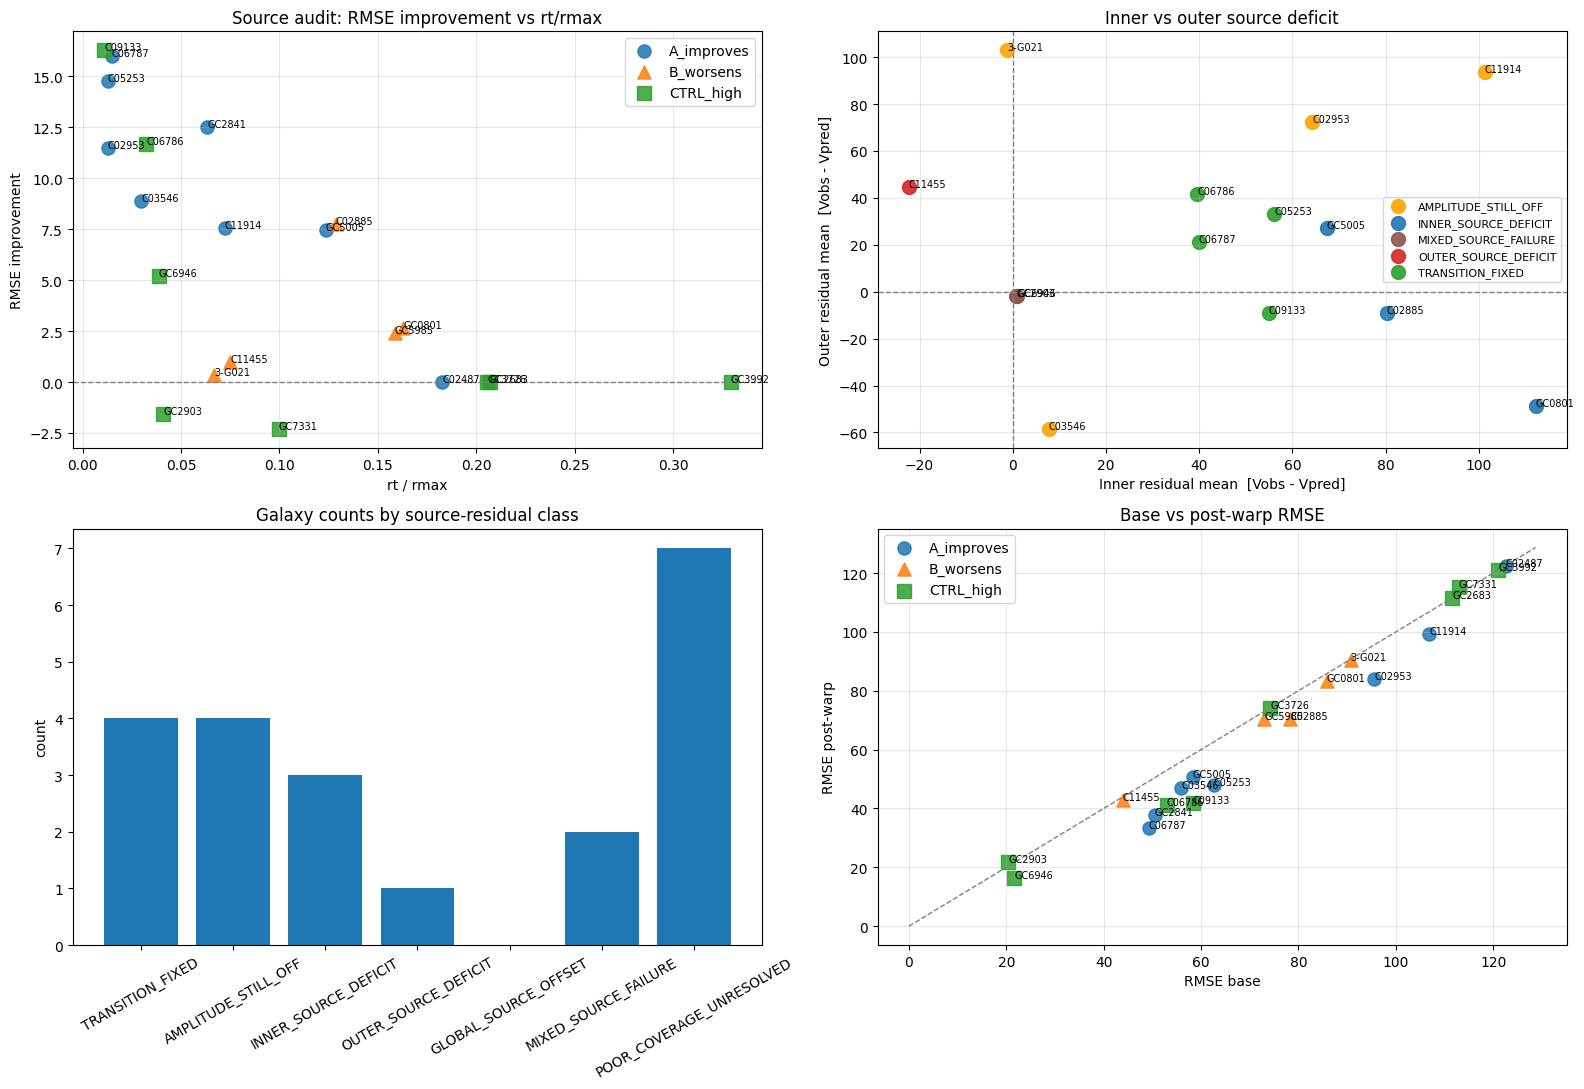


SAVED
/content/mts_source_residual_audit/source_residual_detail.csv
/content/mts_source_residual_audit/source_residual_summary.csv
/content/mts_source_residual_audit/source_residual_failures.csv
/content/mts_source_residual_audit/source_residual_plots.png

QUICK READ
     galaxy   subclass  coverage_bin  rt_rmax  eta_eff  rmse_base  rmse_corr  rmse_improvement  flat_ratio_corr           classification
   UGC02953 A_improves GOOD_COVERAGE 0.012684 0.350736  95.523753  84.027679         11.496074         1.300209      AMPLITUDE_STILL_OFF
   UGC03546 A_improves GOOD_COVERAGE 0.029644 0.418578  55.958978  47.073251          8.885726         0.752333      AMPLITUDE_STILL_OFF
   UGC11914 A_improves GOOD_COVERAGE 0.072141 0.588562 106.888334  99.343408          7.544927         1.509548      AMPLITUDE_STILL_OFF
ESO563-G021  B_worsens GOOD_COVERAGE 0.066814 0.567255  90.704405  90.381562          0.322843         1.480543      AMPLITUDE_STILL_OFF
    NGC5005 A_improves GOOD_COVERAGE 0.123564 

In [ ]:
# ============================================================
# MTS SOURCE-RESIDUAL AUDIT
# ------------------------------------------------------------
# Purpose:
#   Post-warp audit focused on GOOD_COVERAGE galaxies that were
#   NOT transition-fixed and NOT amplitude-still-off.
#
#   This isolates the remaining "source-shape" failures and classifies:
#       INNER_SOURCE_DEFICIT
#       OUTER_SOURCE_DEFICIT
#       GLOBAL_AMPLITUDE_DEFICIT
#       MIXED_SOURCE_FAILURE
#
# Outputs:
#   /content/mts_source_residual_audit/source_residual_detail.csv
#   /content/mts_source_residual_audit/source_residual_summary.csv
#   /content/mts_source_residual_audit/source_residual_failures.csv
#   /content/mts_source_residual_audit/source_residual_plots.png
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

OUTDIR = "/content/mts_source_residual_audit"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# Basic guards
# ------------------------------------------------------------
if "loaded" not in globals():
    raise RuntimeError("`loaded` not found in memory.")

if "SUBCLASS_A" not in globals() or "SUBCLASS_B" not in globals():
    raise RuntimeError("Need SUBCLASS_A and SUBCLASS_B lists in memory.")

sample = next(iter(loaded.values()))
needed = ["rot", "coverage_bin", "log_Gpk", "rt", "rt_rmax", "carrier_base", "vmax_obs"]
missing = [k for k in needed if k not in sample]
if missing:
    raise RuntimeError(f"`loaded` entries are missing keys: {missing}")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def safe_rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def get_vbar2(rot):
    # Flexible extraction
    for k in ["vbar2", "vbar2_arr"]:
        if k in rot:
            arr = np.asarray(rot[k], dtype=float)
            return np.maximum(arr, 0.0)

    # Reconstruct from standard components if present
    vgas   = np.asarray(rot["vgas"], dtype=float)   if "vgas"   in rot else 0.0
    vdisk  = np.asarray(rot["vdisk"], dtype=float)  if "vdisk"  in rot else 0.0
    vbulge = np.asarray(rot["vbulge"], dtype=float) if "vbulge" in rot else 0.0

    if isinstance(vgas, float) and isinstance(vdisk, float) and isinstance(vbulge, float):
        raise RuntimeError("Could not build baryonic curve: no vbar2/vgas/vdisk/vbulge found.")

    return np.maximum(np.asarray(vgas)**2 + np.asarray(vdisk)**2 + np.asarray(vbulge)**2, 0.0)

def get_shape_from_entry(gdata):
    # Prefer precomputed shape if available
    if "shape" in gdata:
        sh = np.asarray(gdata["shape"], dtype=float)
        if np.all(np.isfinite(sh)) and len(sh) == len(gdata["rot"]["r"]):
            return sh, "shape"
    if "shape_base" in gdata:
        sh = np.asarray(gdata["shape_base"], dtype=float)
        if np.all(np.isfinite(sh)) and len(sh) == len(gdata["rot"]["r"]):
            return sh, "shape_base"
    if "rho_n" in gdata:
        # Build shape from cumulative normalized source
        rho_n = np.asarray(gdata["rho_n"], dtype=float)
        r = np.asarray(gdata["rot"]["r"], dtype=float)
        if len(rho_n) == len(r) and len(r) > 1:
            dr = np.gradient(r)
            cum = np.cumsum(np.maximum(rho_n, 0.0) * np.maximum(dr, 0.0))
            if np.nanmax(cum) > 0:
                s = cum / np.nanmax(cum)
                sh = np.sqrt(np.clip(s, 0.0, None))
                return sh, "shape_from_rho_n"
    raise RuntimeError("No usable shape / shape_base / rho_n found for one or more galaxies.")

def get_vflat_obs(rot, outer_frac=0.30):
    r = np.asarray(rot["r"], dtype=float)
    v = np.asarray(rot["vobs"], dtype=float)
    if len(r) == 0:
        return np.nan
    r_cut = r[-1] * (1.0 - outer_frac)
    m = r >= r_cut
    if m.sum() < 2:
        return float(np.nanmax(v))
    return float(np.nanmedian(v[m]))

def subclass_of(name):
    if name in SUBCLASS_A:
        return "A_improves"
    if name in SUBCLASS_B:
        return "B_worsens"
    return "CTRL_high"

def eta_eff_from_rt_rmax(rt_rmax):
    return float(np.clip(0.30 + 4.0 * rt_rmax, 0.20, 1.00))

def warp_shape(shape, eta):
    shape = np.asarray(shape, dtype=float)
    shp = np.clip(shape, 0.0, None)
    return np.clip(shp**eta, 0.0, None)

def robust_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return (np.nan, np.nan, np.nan, np.nan)
    rp, pp = pearsonr(x[m], y[m])
    rs, ps = spearmanr(x[m], y[m])
    return (float(rp), float(pp), float(rs), float(ps))

# ------------------------------------------------------------
# Step 1: build post-warp detail for all loaded galaxies
# ------------------------------------------------------------
all_rows = []
for name, gdata in loaded.items():
    rot = gdata["rot"]
    r = np.asarray(rot["r"], dtype=float)
    vobs = np.asarray(rot["vobs"], dtype=float)
    ev = np.asarray(rot["ev"], dtype=float) if "ev" in rot else np.full_like(vobs, np.nan)
    vbar2 = get_vbar2(rot)
    vbar = np.sqrt(np.maximum(vbar2, 0.0))

    shape_base, shape_source = get_shape_from_entry(gdata)
    rt_rmax = float(gdata["rt_rmax"])
    eta_eff = eta_eff_from_rt_rmax(rt_rmax)
    shape_corr = warp_shape(shape_base, eta_eff)

    carrier_base = float(gdata["carrier_base"])
    if carrier_base <= 0:
        continue

    # Keep same amplitude convention as previous cells
    if "C_AMP_local" in globals():
        C_AMP_local = float(C_AMP_local)
    else:
        carriers, vmaxes = [], []
        for _n, _g in loaded.items():
            c = _g.get("carrier_base", np.nan)
            vm = _g.get("vmax_obs", np.nan)
            if np.isfinite(c) and np.isfinite(vm) and c > 0:
                carriers.append(c)
                vmaxes.append(vm)
        C_AMP_local = float(np.mean(np.array(vmaxes)**2) / np.mean(np.array(carriers)))

    vflat_pred = float(np.sqrt(max(C_AMP_local * carrier_base, 0.0)))
    vpred_base = vflat_pred * shape_base
    vpred_corr = vflat_pred * shape_corr

    rmse_base = safe_rmse(vobs, vpred_base)
    rmse_corr = safe_rmse(vobs, vpred_corr)
    mae_base  = safe_mae(vobs, vpred_base)
    mae_corr  = safe_mae(vobs, vpred_corr)

    vflat_obs = get_vflat_obs(rot)
    flat_ratio_corr = float(vflat_obs / max(vflat_pred, 1e-9))

    # residuals
    resid_base = vobs - vpred_base
    resid_corr = vobs - vpred_corr

    # split radii into terciles by index for robustness
    n = len(r)
    if n < 6:
        cuts = [0, max(1, n//3), max(2, 2*n//3), n]
    else:
        cuts = [0, n//3, 2*n//3, n]

    sl_inner = slice(cuts[0], cuts[1])
    sl_mid   = slice(cuts[1], cuts[2])
    sl_outer = slice(cuts[2], cuts[3])

    inner_mean = float(np.nanmean(resid_corr[sl_inner])) if cuts[1] > cuts[0] else np.nan
    mid_mean   = float(np.nanmean(resid_corr[sl_mid]))   if cuts[2] > cuts[1] else np.nan
    outer_mean = float(np.nanmean(resid_corr[sl_outer])) if cuts[3] > cuts[2] else np.nan

    inner_abs = float(np.nanmean(np.abs(resid_corr[sl_inner]))) if cuts[1] > cuts[0] else np.nan
    mid_abs   = float(np.nanmean(np.abs(resid_corr[sl_mid])))   if cuts[2] > cuts[1] else np.nan
    outer_abs = float(np.nanmean(np.abs(resid_corr[sl_outer]))) if cuts[3] > cuts[2] else np.nan

    # residual slope after warp
    slope_corr = float(np.polyfit(r, resid_corr, 1)[0]) if len(r) >= 4 else np.nan

    # shape-only RMSE on normalized curves
    vobs_n = vobs / max(np.nanmax(vobs), 1.0)
    vb_n   = vpred_base / max(np.nanmax(vpred_base), 1.0)
    vc_n   = vpred_corr / max(np.nanmax(vpred_corr), 1.0)
    shape_rmse_base = safe_rmse(vobs_n, vb_n)
    shape_rmse_corr = safe_rmse(vobs_n, vc_n)

    # baryonic structure summaries
    with np.errstate(divide="ignore", invalid="ignore"):
        bar_frac_arr = vbar / np.maximum(vobs, 1.0)
    bar_frac_med = float(np.nanmedian(bar_frac_arr))

    cum_b = np.cumsum(np.maximum(vbar2, 0.0))
    cum_b = cum_b / max(np.nanmax(cum_b), 1e-12)

    outer_bfrac = float(np.nanmedian(bar_frac_arr[sl_outer])) if cuts[3] > cuts[2] else np.nan
    inner_bfrac = float(np.nanmedian(bar_frac_arr[sl_inner])) if cuts[1] > cuts[0] else np.nan
    cum_outer   = float(np.nanmedian(cum_b[sl_outer])) if cuts[3] > cuts[2] else np.nan
    cum_inner   = float(np.nanmedian(cum_b[sl_inner])) if cuts[1] > cuts[0] else np.nan

    # classification rules
    coverage_bin = str(gdata["coverage_bin"])
    if coverage_bin != "GOOD_COVERAGE":
        classification = "POOR_COVERAGE_UNRESOLVED"
    else:
        # transition fixed = clear shape gain and decent amplitude
        if (rmse_corr < rmse_base - 8.0) and (shape_rmse_corr < shape_rmse_base - 0.015) and (0.85 <= flat_ratio_corr <= 1.20):
            classification = "TRANSITION_FIXED"
        elif (flat_ratio_corr > 1.20) or (flat_ratio_corr < 0.80):
            classification = "AMPLITUDE_STILL_OFF"
        else:
            # source-shape decomposition
            # positive residual means observed > predicted (missing support)
            # negative residual means predicted > observed (excess support)
            if np.isfinite(inner_mean) and np.isfinite(outer_mean):
                if (inner_mean > 12.0) and (inner_mean > outer_mean + 8.0):
                    classification = "INNER_SOURCE_DEFICIT"
                elif (outer_mean > 12.0) and (outer_mean > inner_mean + 8.0):
                    classification = "OUTER_SOURCE_DEFICIT"
                elif (inner_mean > 8.0 and outer_mean > 8.0) or (inner_mean < -8.0 and outer_mean < -8.0):
                    classification = "GLOBAL_SOURCE_OFFSET"
                else:
                    classification = "MIXED_SOURCE_FAILURE"
            else:
                classification = "MIXED_SOURCE_FAILURE"

    all_rows.append({
        "galaxy": name,
        "subclass": subclass_of(name),
        "coverage_bin": coverage_bin,
        "shape_source": shape_source,
        "rt_rmax": rt_rmax,
        "eta_eff": eta_eff,
        "log_Gpk": float(gdata["log_Gpk"]),
        "n_pts": int(gdata.get("n_pts", len(r))),
        "bar_frac_med": bar_frac_med,
        "inner_bar_frac": inner_bfrac,
        "outer_bar_frac": outer_bfrac,
        "cum_bary_inner": cum_inner,
        "cum_bary_outer": cum_outer,
        "vflat_obs": vflat_obs,
        "vflat_pred": vflat_pred,
        "flat_ratio_corr": flat_ratio_corr,
        "rmse_base": rmse_base,
        "rmse_corr": rmse_corr,
        "rmse_improvement": rmse_base - rmse_corr,
        "mae_base": mae_base,
        "mae_corr": mae_corr,
        "shape_rmse_base": shape_rmse_base,
        "shape_rmse_corr": shape_rmse_corr,
        "resid_inner_mean": inner_mean,
        "resid_mid_mean": mid_mean,
        "resid_outer_mean": outer_mean,
        "resid_inner_abs": inner_abs,
        "resid_mid_abs": mid_abs,
        "resid_outer_abs": outer_abs,
        "residual_slope_corr": slope_corr,
        "classification": classification,
    })

df = pd.DataFrame(all_rows).sort_values(["coverage_bin", "subclass", "galaxy"]).reset_index(drop=True)

# ------------------------------------------------------------
# Step 2: print audit table
# ------------------------------------------------------------
print("="*72)
print("SOURCE-RESIDUAL AUDIT")
print("="*72)
print(f"Loaded audit galaxies: {len(df)}")
print(f"C_AMP_local: {C_AMP_local:.6f}")
print("eta_eff(rt/rmax) = clip(0.30 + 4.0*(rt/rmax), 0.20, 1.00)")
print()

show_cols = [
    "galaxy","subclass","coverage_bin","rt_rmax","eta_eff","log_Gpk",
    "rmse_base","rmse_corr","rmse_improvement","flat_ratio_corr",
    "resid_inner_mean","resid_outer_mean","classification"
]
print("="*72)
print("PER-GALAXY SOURCE AUDIT")
print("="*72)
print(df[show_cols].to_string(index=False))

# ------------------------------------------------------------
# Step 3: summary tables
# ------------------------------------------------------------
def agg_summary(din, group_name):
    rows = []
    for key, d in din.groupby(group_name, dropna=False):
        rows.append({
            group_name: key,
            "n_gal": len(d),
            "median_rmse_base": float(np.nanmedian(d["rmse_base"])),
            "median_rmse_corr": float(np.nanmedian(d["rmse_corr"])),
            "median_rmse_improvement": float(np.nanmedian(d["rmse_improvement"])),
            "mean_rmse_improvement": float(np.nanmean(d["rmse_improvement"])),
            "median_flat_ratio_corr": float(np.nanmedian(d["flat_ratio_corr"])),
            "median_shape_rmse_base": float(np.nanmedian(d["shape_rmse_base"])),
            "median_shape_rmse_corr": float(np.nanmedian(d["shape_rmse_corr"])),
            "median_inner_resid": float(np.nanmedian(d["resid_inner_mean"])),
            "median_outer_resid": float(np.nanmedian(d["resid_outer_mean"])),
            "median_rt_rmax": float(np.nanmedian(d["rt_rmax"])),
            "median_log_Gpk": float(np.nanmedian(d["log_Gpk"])),
            "median_eta_eff": float(np.nanmedian(d["eta_eff"])),
        })
    return pd.DataFrame(rows)

summary_class = agg_summary(df, "classification")
summary_subcl = agg_summary(df, "subclass")
summary_cov   = agg_summary(df, "coverage_bin")

count_tbl = (
    df.groupby(["classification","subclass","coverage_bin"])
      .size()
      .reset_index(name="n")
      .sort_values(["classification","subclass","coverage_bin"])
)

print()
print("="*72)
print("CLASSIFICATION SUMMARY")
print("="*72)
print(summary_class.to_string(index=False))

print()
print("="*72)
print("CLASSIFICATION COUNTS")
print("="*72)
print(count_tbl.to_string(index=False))

# ------------------------------------------------------------
# Step 4: correlations on good-coverage only
# ------------------------------------------------------------
good = df[df["coverage_bin"] == "GOOD_COVERAGE"].copy()

corr_rows = []
for xcol, ycol in [
    ("rmse_improvement", "rt_rmax"),
    ("rmse_improvement", "log_Gpk"),
    ("rmse_improvement", "bar_frac_med"),
    ("eta_eff", "rt_rmax"),
    ("eta_eff", "log_Gpk"),
    ("resid_outer_mean", "rt_rmax"),
    ("resid_outer_mean", "log_Gpk"),
]:
    rp, pp, rs, ps = robust_corr(good[ycol], good[xcol])
    corr_rows.append({
        "y_vs_x": f"{xcol} vs {ycol}",
        "pearson_r": rp,
        "pearson_p": pp,
        "spearman_rho": rs,
        "spearman_p": ps,
    })
corr_df = pd.DataFrame(corr_rows)

print()
print("="*72)
print("CORRELATIONS (GOOD_COVERAGE ONLY)")
print("="*72)
for _, row in corr_df.iterrows():
    print(f"{row['y_vs_x']:28s}: "
          f"Pearson r={row['pearson_r']:+.3f} (p={row['pearson_p']:.3f})   "
          f"Spearman rho={row['spearman_rho']:+.3f} (p={row['spearman_p']:.3f})")

# ------------------------------------------------------------
# Step 5: top/bottom movers
# ------------------------------------------------------------
top_imp = df.sort_values("rmse_improvement", ascending=False).head(10)
worst_imp = df.sort_values("rmse_improvement", ascending=True).head(10)

print()
print("="*72)
print("TOP RMSE IMPROVEMENTS")
print("="*72)
print(top_imp[[
    "galaxy","subclass","coverage_bin","rt_rmax","eta_eff",
    "rmse_base","rmse_corr","rmse_improvement","flat_ratio_corr","classification"
]].to_string(index=False))

print()
print("="*72)
print("WORST RMSE MOVES")
print("="*72)
print(worst_imp[[
    "galaxy","subclass","coverage_bin","rt_rmax","eta_eff",
    "rmse_base","rmse_corr","rmse_improvement","flat_ratio_corr","classification"
]].to_string(index=False))

# ------------------------------------------------------------
# Step 6: plots
# ------------------------------------------------------------
cls_color = {
    "TRANSITION_FIXED": "tab:green",
    "AMPLITUDE_STILL_OFF": "orange",
    "INNER_SOURCE_DEFICIT": "tab:blue",
    "OUTER_SOURCE_DEFICIT": "tab:red",
    "GLOBAL_SOURCE_OFFSET": "tab:purple",
    "MIXED_SOURCE_FAILURE": "tab:brown",
    "POOR_COVERAGE_UNRESOLVED": "gray",
}

sub_mk = {
    "A_improves": "o",
    "B_worsens": "^",
    "CTRL_high": "s",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# (1) improvement vs rt/rmax
ax = axes[0, 0]
for sc, dsc in df.groupby("subclass"):
    ax.scatter(
        dsc["rt_rmax"], dsc["rmse_improvement"],
        s=90, marker=sub_mk.get(sc, "o"), alpha=0.85, label=sc
    )
    for _, row in dsc.iterrows():
        ax.annotate(row["galaxy"][-6:], (row["rt_rmax"], row["rmse_improvement"]), fontsize=7)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("rt / rmax")
ax.set_ylabel("RMSE improvement")
ax.set_title("Source audit: RMSE improvement vs rt/rmax")
ax.grid(alpha=0.3)
ax.legend()

# (2) inner vs outer residual means
ax = axes[0, 1]
for cls, dcl in good.groupby("classification"):
    ax.scatter(
        dcl["resid_inner_mean"], dcl["resid_outer_mean"],
        s=100, alpha=0.9, color=cls_color.get(cls, "black"), label=cls
    )
    for _, row in dcl.iterrows():
        ax.annotate(row["galaxy"][-6:], (row["resid_inner_mean"], row["resid_outer_mean"]), fontsize=7)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("Inner residual mean  [Vobs - Vpred]")
ax.set_ylabel("Outer residual mean  [Vobs - Vpred]")
ax.set_title("Inner vs outer source deficit")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

# (3) counts by class
ax = axes[1, 0]
class_order = [
    "TRANSITION_FIXED",
    "AMPLITUDE_STILL_OFF",
    "INNER_SOURCE_DEFICIT",
    "OUTER_SOURCE_DEFICIT",
    "GLOBAL_SOURCE_OFFSET",
    "MIXED_SOURCE_FAILURE",
    "POOR_COVERAGE_UNRESOLVED",
]
count_series = df["classification"].value_counts()
vals = [int(count_series.get(c, 0)) for c in class_order]
ax.bar(class_order, vals)
ax.set_title("Galaxy counts by source-residual class")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=30)

# (4) base vs post-warp RMSE
ax = axes[1, 1]
for sc, dsc in df.groupby("subclass"):
    ax.scatter(
        dsc["rmse_base"], dsc["rmse_corr"],
        s=90, marker=sub_mk.get(sc, "o"), alpha=0.85, label=sc
    )
    for _, row in dsc.iterrows():
        ax.annotate(row["galaxy"][-6:], (row["rmse_base"], row["rmse_corr"]), fontsize=7)
xymax = float(np.nanmax(np.r_[df["rmse_base"].values, df["rmse_corr"].values])) * 1.05
ax.plot([0, xymax], [0, xymax], ls="--", lw=1, color="gray")
ax.set_xlabel("RMSE base")
ax.set_ylabel("RMSE post-warp")
ax.set_title("Base vs post-warp RMSE")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plot_path = os.path.join(OUTDIR, "source_residual_plots.png")
plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Step 7: save outputs
# ------------------------------------------------------------
detail_path   = os.path.join(OUTDIR, "source_residual_detail.csv")
summary_path  = os.path.join(OUTDIR, "source_residual_summary.csv")
failure_path  = os.path.join(OUTDIR, "source_residual_failures.csv")

df.to_csv(detail_path, index=False)

summary_pack = []
for tag, sdf in [
    ("CLASSIFICATION", summary_class),
    ("SUBCLASS", summary_subcl),
    ("COVERAGE", summary_cov),
]:
    temp = sdf.copy()
    temp.insert(0, "summary_type", tag)
    summary_pack.append(temp)
summary_all = pd.concat(summary_pack, ignore_index=True, sort=False)
summary_all.to_csv(summary_path, index=False)

fail_df = pd.concat([
    top_imp.assign(block="TOP_RMSE_IMPROVEMENTS"),
    worst_imp.assign(block="WORST_RMSE_MOVES"),
    corr_df.assign(block="CORRELATIONS")
], ignore_index=True, sort=False)
fail_df.to_csv(failure_path, index=False)

print()
print("="*72)
print("SAVED")
print("="*72)
print(detail_path)
print(summary_path)
print(failure_path)
print(plot_path)

print()
print("="*72)
print("QUICK READ")
print("="*72)
print(df[[
    "galaxy","subclass","coverage_bin","rt_rmax","eta_eff",
    "rmse_base","rmse_corr","rmse_improvement","flat_ratio_corr","classification"
]].sort_values(["classification","coverage_bin","subclass","galaxy"]).to_string(index=False))

ROTOMD FILE DISCOVERY
Loaded audit galaxies: 21
C_AMP_local: 347.359025
GOOD_COVERAGE usable galaxies: 14

POST-WARP SOURCE REWEIGHT SCAN SUMMARY (GOOD_COVERAGE ONLY)
 s_in  s_out  median_rmse  mean_rmse  A_median_rmse  B_median_rmse  CTRL_median_rmse  TRANSITION_FIXED_median_improvement  AMP_STILL_OFF_median_improvement  INNER_DEFICIT_median_improvement  OUTER_DEFICIT_median_improvement  SOURCE_FAIL_median_improvement  frac_positive_improvement
  1.4    0.8    71.019588  71.291013      84.083224      69.963889         42.907818                                  NaN                      5.025980e+00                      3.653402e+00                      1.155819e+00                    4.092096e+00                   1.000000
  1.2    0.8    72.198434  72.465734      85.969375      70.828494         43.979026                                  NaN                      3.610437e+00                      2.788797e+00                      1.022952e+00                    2.959592e+00            

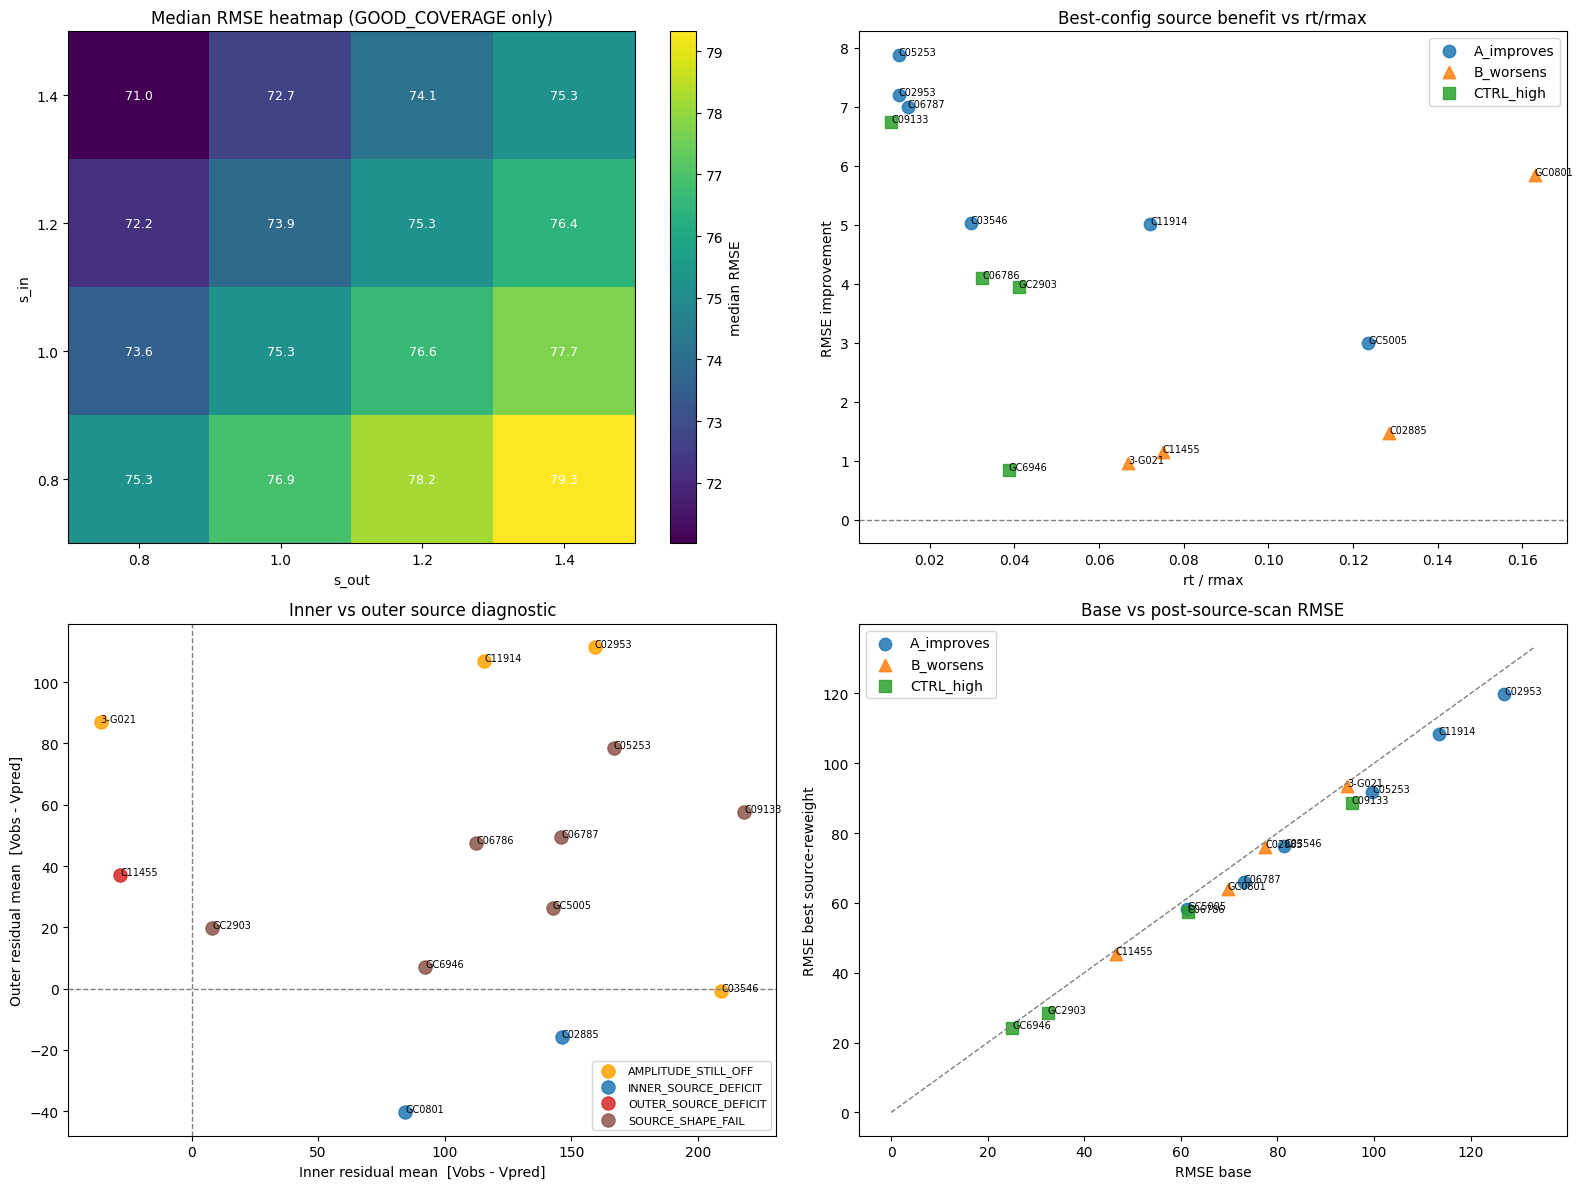


SAVED
/content/mts_postwarp_source_scan/postwarp_source_scan_summary.csv
/content/mts_postwarp_source_scan/postwarp_source_scan_best_detail.csv
/content/mts_postwarp_source_scan/postwarp_source_scan_group_summary.csv
/content/mts_postwarp_source_scan/postwarp_source_scan_class_counts.csv
/content/mts_postwarp_source_scan/postwarp_source_scan_failures.csv
/content/mts_postwarp_source_scan/postwarp_source_scan_plots.png

QUICK READ
     galaxy   subclass  rt_rmax  rmse_base  rmse_corr  rmse_improvement  flat_ratio_corr       classification
   UGC02953 A_improves 0.012684 126.919088 119.716867          7.202221         1.300209  AMPLITUDE_STILL_OFF
   UGC03546 A_improves 0.029644  81.427895  76.391178          5.036717         0.752333  AMPLITUDE_STILL_OFF
   UGC11914 A_improves 0.072141 113.398826 108.383583          5.015243         1.509548  AMPLITUDE_STILL_OFF
ESO563-G021  B_worsens 0.066814  94.477799  93.511909          0.965890         1.480543  AMPLITUDE_STILL_OFF
    NGC0801  B_

In [ ]:
# ============================================================
# MTS POST-WARP SOURCE REWEIGHT SCAN (GOOD-COVERAGE ONLY)
# ------------------------------------------------------------
# Goal:
#   After fixing the transition warp with
#       eta_eff(rt/rmax) = clip(0.30 + 4.0*(rt/rmax), 0.20, 1.00),
#   test whether a simple inner/outer source reweighting helps:
#       s_in  = multiplier for source at r <= rt
#       s_out = multiplier for source at r >  rt
#
# What this cell does:
#   1) Rebuild a warped source-derived shape from rho_n
#   2) Scan a small (s_in, s_out) grid on GOOD_COVERAGE galaxies only
#   3) Score overall + subclass + post-warp residual-class groups
#   4) Save summary / per-galaxy best table / failures
#
# Required in memory:
#   - loaded : dict of per-galaxy data
#   - SUBCLASS_A, SUBCLASS_B : lists of galaxy names
#
# Expected per-galaxy keys in loaded[name]:
#   rot, coverage_bin, rt, rt_rmax, rho_n, carrier_base, vmax_obs
# Optional:
#   vobs, shape, bar_frac, log_Gpk, n_pts
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# OUTPUT DIR
# ------------------------------------------------------------------
OUTDIR = "/content/mts_postwarp_source_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------------
# BASIC CHECKS
# ------------------------------------------------------------------
if "loaded" not in globals():
    raise RuntimeError("`loaded` not found in memory.")
if "SUBCLASS_A" not in globals() or "SUBCLASS_B" not in globals():
    raise RuntimeError("`SUBCLASS_A` / `SUBCLASS_B` not found in memory.")

sample = next(iter(loaded.values()))
needed = ["rot", "coverage_bin", "rt", "rt_rmax", "rho_n", "carrier_base", "vmax_obs"]
missing = [k for k in needed if k not in sample]
if missing:
    raise RuntimeError(f"`loaded` entries are missing keys: {missing}")

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Loaded audit galaxies: {len(loaded)}")

# ------------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------------
def safe_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((y_true[m] - y_pred[m])**2)))

def safe_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(y_true[m] - y_pred[m])))

def cumtrapz0(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y, dtype=float)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    avg = 0.5 * (y[1:] + y[:-1])
    out[1:] = np.cumsum(avg * dx)
    return out

def get_arrays(g):
    rot = g["rot"]
    r = np.asarray(rot["r"], dtype=float)
    vobs = np.asarray(g.get("vobs", rot.get("vobs")), dtype=float)
    ev = np.asarray(rot.get("ev", np.full_like(r, np.nan)), dtype=float)
    rho_n = np.asarray(g["rho_n"], dtype=float)
    if len(rho_n) != len(r):
        raise ValueError("rho_n length does not match radius length.")
    return r, vobs, ev, rho_n

def get_subclass(name):
    if name in SUBCLASS_A:
        return "A_improves"
    if name in SUBCLASS_B:
        return "B_worsens"
    return "CTRL_high"

def get_vflat_obs(vobs, r, outer_frac=0.30):
    r = np.asarray(r, dtype=float)
    vobs = np.asarray(vobs, dtype=float)
    if len(r) == 0:
        return np.nan
    r_cut = r[-1] * (1.0 - outer_frac)
    m = r >= r_cut
    if m.sum() < 2:
        return float(np.nanmax(vobs))
    return float(np.nanmedian(vobs[m]))

def eta_eff_from_rt(rt_rmax, c0=0.30, c1=4.0, eta_min=0.20, eta_max=1.00):
    return float(np.clip(c0 + c1 * rt_rmax, eta_min, eta_max))

def build_shape_from_source(r, rho_n, rt, eta_eff, s_in=1.0, s_out=1.0):
    """
    Source-built shape:
      src_base = max(rho_n, 0)^eta_eff
      src_rw   = src_base * (s_in for r<=rt else s_out)
      S(r)     = cumulative integral of src_rw
      y(r)     = sqrt(1 - exp(-S/S_end))
    """
    r = np.asarray(r, dtype=float)
    rho_n = np.asarray(rho_n, dtype=float)

    src = np.power(np.clip(rho_n, 0.0, None), eta_eff)
    rw = np.where(r <= rt, s_in, s_out).astype(float)
    src_rw = src * rw

    S = cumtrapz0(src_rw, r)
    S_end = float(S[-1]) if len(S) else 0.0

    if not np.isfinite(S_end) or S_end <= 0:
        y = np.zeros_like(r, dtype=float)
    else:
        u = S / S_end
        y = np.sqrt(np.clip(1.0 - np.exp(-u), 0.0, 1.0))

    # force final point to 1 if possible, for stable flat comparison
    if len(y) > 0 and np.isfinite(y[-1]) and y[-1] > 0:
        y = y / y[-1]
    return y, src_rw, S

def classify_good_coverage(flat_ratio_corr, resid_inner_mean, resid_outer_mean, rmse_impr):
    # same spirit as your latest source-residual audit
    if flat_ratio_corr > 1.25 or flat_ratio_corr < 0.80:
        return "AMPLITUDE_STILL_OFF"
    if rmse_impr >= 10.0 and resid_inner_mean > 0 and resid_outer_mean > 0:
        return "TRANSITION_FIXED"
    if resid_inner_mean > 20 and resid_outer_mean < -5:
        return "INNER_SOURCE_DEFICIT"
    if resid_inner_mean < -10 and resid_outer_mean > 20:
        return "OUTER_SOURCE_DEFICIT"
    if abs(resid_inner_mean) < 10 and abs(resid_outer_mean) < 10:
        return "MIXED_SOURCE_FAILURE"
    return "SOURCE_SHAPE_FAIL"

# ------------------------------------------------------------------
# C_AMP FIT
# ------------------------------------------------------------------
all_carriers = []
all_vmax2 = []
for name, g in loaded.items():
    c = g.get("carrier_base", np.nan)
    v = g.get("vmax_obs", np.nan)
    if np.isfinite(c) and np.isfinite(v) and c > 0:
        all_carriers.append(float(c))
        all_vmax2.append(float(v)**2)

if len(all_carriers) == 0:
    raise RuntimeError("Could not fit C_AMP_local from loaded.")

C_AMP_local = float(np.mean(all_vmax2) / np.mean(all_carriers))
print(f"C_AMP_local: {C_AMP_local:.6f}")

# ------------------------------------------------------------------
# BASE TABLE (good coverage only)
# ------------------------------------------------------------------
base_rows = []
fail_rows = []

for name, g in loaded.items():
    try:
        r, vobs, ev, rho_n = get_arrays(g)
        subclass = get_subclass(name)
        coverage_bin = g["coverage_bin"]
        rt = float(g["rt"])
        rt_rmax = float(g["rt_rmax"])
        log_Gpk = float(g.get("log_Gpk", np.nan))
        bar_frac = float(g.get("bar_frac", np.nan))
        n_pts = int(g.get("n_pts", len(r)))

        eta0 = eta_eff_from_rt(rt_rmax, 0.30, 4.0, 0.20, 1.00)
        carrier = float(g["carrier_base"])
        vflat_pred = float(np.sqrt(max(C_AMP_local * carrier, 0.0)))
        vflat_obs = get_vflat_obs(vobs, r)

        # baseline post-warp shape (no source reweight)
        shape_base, src_rw_base, S_base = build_shape_from_source(
            r=r, rho_n=rho_n, rt=rt, eta_eff=eta0, s_in=1.0, s_out=1.0
        )
        vpred_base = vflat_pred * shape_base

        rmse_base = safe_rmse(vobs, vpred_base)
        mae_base = safe_mae(vobs, vpred_base)
        abs_flat_err_base = float(abs(vflat_obs - vflat_pred))

        if coverage_bin == "GOOD_COVERAGE":
            base_rows.append({
                "galaxy": name,
                "subclass": subclass,
                "coverage_bin": coverage_bin,
                "rt": rt,
                "rt_rmax": rt_rmax,
                "log_Gpk": log_Gpk,
                "bar_frac": bar_frac,
                "n_pts": n_pts,
                "eta_base": eta0,
                "carrier_base": carrier,
                "Vflat_obs": vflat_obs,
                "Vflat_pred": vflat_pred,
                "rmse_base": rmse_base,
                "mae_base": mae_base,
                "abs_flat_err_base": abs_flat_err_base,
                "r": r,
                "vobs": vobs,
                "ev": ev,
                "rho_n": rho_n,
                "shape_base": shape_base,
                "vpred_base": vpred_base,
            })

    except Exception as e:
        fail_rows.append({"galaxy": name, "stage": "base_build", "error": repr(e)})

base_df = pd.DataFrame(base_rows)
fail_df = pd.DataFrame(fail_rows)

print(f"GOOD_COVERAGE usable galaxies: {len(base_df)}")
if len(base_df) == 0:
    raise RuntimeError("No GOOD_COVERAGE galaxies available for source scan.")

# ------------------------------------------------------------------
# SOURCE REWEIGHT GRID
# ------------------------------------------------------------------
S_IN_GRID  = [0.8, 1.0, 1.2, 1.4]
S_OUT_GRID = [0.8, 1.0, 1.2, 1.4]

# ------------------------------------------------------------------
# SCAN
# ------------------------------------------------------------------
summary_rows = []
detail_rows = []

for s_in in S_IN_GRID:
    for s_out in S_OUT_GRID:

        per_rows = []

        for _, row in base_df.iterrows():
            try:
                r = row["r"]
                vobs = row["vobs"]
                rho_n = row["rho_n"]
                rt = float(row["rt"])
                eta0 = float(row["eta_base"])
                vflat_pred = float(row["Vflat_pred"])
                vflat_obs = float(row["Vflat_obs"])

                shape_corr, src_rw_corr, S_corr = build_shape_from_source(
                    r=r, rho_n=rho_n, rt=rt, eta_eff=eta0, s_in=s_in, s_out=s_out
                )
                vpred_corr = vflat_pred * shape_corr

                rmse_corr = safe_rmse(vobs, vpred_corr)
                mae_corr = safe_mae(vobs, vpred_corr)
                rmse_improvement = float(row["rmse_base"] - rmse_corr)
                abs_flat_err_corr = float(abs(vflat_obs - vflat_pred))  # unchanged by source-shape only
                flat_ratio_corr = float(vflat_obs / max(vflat_pred, 1e-9))

                inner_mask = r <= float(row["rt"])
                outer_mask = r >  float(row["rt"])
                resid = vobs - vpred_corr
                resid_inner_mean = float(np.mean(resid[inner_mask])) if inner_mask.any() else np.nan
                resid_outer_mean = float(np.mean(resid[outer_mask])) if outer_mask.any() else np.nan

                classification = classify_good_coverage(
                    flat_ratio_corr=flat_ratio_corr,
                    resid_inner_mean=resid_inner_mean,
                    resid_outer_mean=resid_outer_mean,
                    rmse_impr=rmse_improvement
                )

                rr = {
                    "s_in": s_in,
                    "s_out": s_out,
                    "galaxy": row["galaxy"],
                    "subclass": row["subclass"],
                    "coverage_bin": row["coverage_bin"],
                    "rt": row["rt"],
                    "rt_rmax": row["rt_rmax"],
                    "log_Gpk": row["log_Gpk"],
                    "bar_frac": row["bar_frac"],
                    "n_pts": row["n_pts"],
                    "eta_base": row["eta_base"],
                    "rmse_base": row["rmse_base"],
                    "rmse_corr": rmse_corr,
                    "rmse_improvement": rmse_improvement,
                    "mae_base": row["mae_base"],
                    "mae_corr": mae_corr,
                    "Vflat_obs": vflat_obs,
                    "Vflat_pred": vflat_pred,
                    "abs_flat_err_base": row["abs_flat_err_base"],
                    "abs_flat_err_corr": abs_flat_err_corr,
                    "flat_ratio_corr": flat_ratio_corr,
                    "resid_inner_mean": resid_inner_mean,
                    "resid_outer_mean": resid_outer_mean,
                    "classification": classification,
                }
                per_rows.append(rr)
                detail_rows.append(rr)

            except Exception as e:
                fail_df = pd.concat([
                    fail_df,
                    pd.DataFrame([{
                        "galaxy": row["galaxy"],
                        "stage": f"scan_sin_{s_in}_sout_{s_out}",
                        "error": repr(e)
                    }])
                ], ignore_index=True)

        if len(per_rows) == 0:
            continue

        d = pd.DataFrame(per_rows)

        def med_of(mask, col):
            z = d.loc[mask, col]
            return float(z.median()) if len(z) else np.nan

        def mean_of(mask, col):
            z = d.loc[mask, col]
            return float(z.mean()) if len(z) else np.nan

        row_sum = {
            "s_in": s_in,
            "s_out": s_out,
            "n_gal": len(d),

            "median_rmse": float(d["rmse_corr"].median()),
            "mean_rmse": float(d["rmse_corr"].mean()),
            "median_mae": float(d["mae_corr"].median()),
            "mean_mae": float(d["mae_corr"].mean()),
            "median_abs_flat_err": float(d["abs_flat_err_corr"].median()),
            "mean_abs_flat_err": float(d["abs_flat_err_corr"].mean()),

            "A_median_rmse": med_of(d["subclass"]=="A_improves", "rmse_corr"),
            "A_mean_rmse": mean_of(d["subclass"]=="A_improves", "rmse_corr"),
            "A_median_improvement": med_of(d["subclass"]=="A_improves", "rmse_improvement"),

            "B_median_rmse": med_of(d["subclass"]=="B_worsens", "rmse_corr"),
            "B_mean_rmse": mean_of(d["subclass"]=="B_worsens", "rmse_corr"),
            "B_median_improvement": med_of(d["subclass"]=="B_worsens", "rmse_improvement"),

            "CTRL_median_rmse": med_of(d["subclass"]=="CTRL_high", "rmse_corr"),
            "CTRL_mean_rmse": mean_of(d["subclass"]=="CTRL_high", "rmse_corr"),
            "CTRL_median_improvement": med_of(d["subclass"]=="CTRL_high", "rmse_improvement"),

            "TRANSITION_FIXED_median_improvement": med_of(d["classification"]=="TRANSITION_FIXED", "rmse_improvement"),
            "AMP_STILL_OFF_median_improvement": med_of(d["classification"]=="AMPLITUDE_STILL_OFF", "rmse_improvement"),
            "INNER_DEFICIT_median_improvement": med_of(d["classification"]=="INNER_SOURCE_DEFICIT", "rmse_improvement"),
            "OUTER_DEFICIT_median_improvement": med_of(d["classification"]=="OUTER_SOURCE_DEFICIT", "rmse_improvement"),
            "SOURCE_FAIL_median_improvement": med_of(d["classification"]=="SOURCE_SHAPE_FAIL", "rmse_improvement"),

            "n_transition_fixed": int((d["classification"]=="TRANSITION_FIXED").sum()),
            "n_amp_still_off": int((d["classification"]=="AMPLITUDE_STILL_OFF").sum()),
            "n_inner_deficit": int((d["classification"]=="INNER_SOURCE_DEFICIT").sum()),
            "n_outer_deficit": int((d["classification"]=="OUTER_SOURCE_DEFICIT").sum()),
            "n_source_fail": int((d["classification"]=="SOURCE_SHAPE_FAIL").sum()),
            "frac_positive_improvement": float((d["rmse_improvement"] > 0).mean()),
        }
        summary_rows.append(row_sum)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_rmse", "mean_rmse", "B_median_rmse", "A_median_rmse"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

detail_df = pd.DataFrame(detail_rows)

# ------------------------------------------------------------------
# BEST CONFIG + BEST PER GALAXY UNDER THAT CONFIG
# ------------------------------------------------------------------
if len(summary_df) == 0:
    raise RuntimeError("No scan summary produced.")

best = summary_df.iloc[0].to_dict()
best_s_in = float(best["s_in"])
best_s_out = float(best["s_out"])

best_detail_df = detail_df[
    (detail_df["s_in"] == best_s_in) &
    (detail_df["s_out"] == best_s_out)
].copy()

best_detail_df = best_detail_df.sort_values(
    ["subclass", "classification", "rmse_improvement", "galaxy"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

# ------------------------------------------------------------------
# SUMMARY TABLES
# ------------------------------------------------------------------
group_summary_rows = []

for label, mask in [
    ("A_improves", best_detail_df["subclass"]=="A_improves"),
    ("B_worsens",  best_detail_df["subclass"]=="B_worsens"),
    ("CTRL_high",  best_detail_df["subclass"]=="CTRL_high"),
    ("TRANSITION_FIXED",      best_detail_df["classification"]=="TRANSITION_FIXED"),
    ("AMPLITUDE_STILL_OFF",   best_detail_df["classification"]=="AMPLITUDE_STILL_OFF"),
    ("INNER_SOURCE_DEFICIT",  best_detail_df["classification"]=="INNER_SOURCE_DEFICIT"),
    ("OUTER_SOURCE_DEFICIT",  best_detail_df["classification"]=="OUTER_SOURCE_DEFICIT"),
    ("SOURCE_SHAPE_FAIL",     best_detail_df["classification"]=="SOURCE_SHAPE_FAIL"),
]:
    d = best_detail_df.loc[mask].copy()
    if len(d) == 0:
        continue
    group_summary_rows.append({
        "group": label,
        "n_gal": len(d),
        "median_rmse_base": float(d["rmse_base"].median()),
        "median_rmse_corr": float(d["rmse_corr"].median()),
        "median_rmse_improvement": float(d["rmse_improvement"].median()),
        "mean_rmse_improvement": float(d["rmse_improvement"].mean()),
        "median_flat_ratio_corr": float(d["flat_ratio_corr"].median()),
        "median_inner_resid": float(d["resid_inner_mean"].median()),
        "median_outer_resid": float(d["resid_outer_mean"].median()),
        "median_rt_rmax": float(d["rt_rmax"].median()),
        "median_log_Gpk": float(d["log_Gpk"].median()),
    })

group_summary_df = pd.DataFrame(group_summary_rows)

class_counts_df = (
    best_detail_df
    .groupby(["classification", "subclass"])
    .size()
    .reset_index(name="n")
    .sort_values(["classification", "subclass"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------------
# PRINT
# ------------------------------------------------------------------
print()
print("="*72)
print("POST-WARP SOURCE REWEIGHT SCAN SUMMARY (GOOD_COVERAGE ONLY)")
print("="*72)
print(summary_df[[
    "s_in","s_out","median_rmse","mean_rmse",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "TRANSITION_FIXED_median_improvement",
    "AMP_STILL_OFF_median_improvement",
    "INNER_DEFICIT_median_improvement",
    "OUTER_DEFICIT_median_improvement",
    "SOURCE_FAIL_median_improvement",
    "frac_positive_improvement"
]].to_string(index=False))

print()
print("="*72)
print("BEST OVERALL")
print("="*72)
for k in [
    "s_in","s_out","n_gal","median_rmse","mean_rmse","median_mae","mean_mae",
    "A_median_rmse","A_median_improvement",
    "B_median_rmse","B_median_improvement",
    "CTRL_median_rmse","CTRL_median_improvement",
    "TRANSITION_FIXED_median_improvement",
    "AMP_STILL_OFF_median_improvement",
    "INNER_DEFICIT_median_improvement",
    "OUTER_DEFICIT_median_improvement",
    "SOURCE_FAIL_median_improvement",
    "frac_positive_improvement"
]:
    print(f"{k}: {best.get(k)}")

print()
print("="*72)
print("BEST-CONFIG PER-GALAXY DETAIL")
print("="*72)
print(best_detail_df[[
    "galaxy","subclass","rt_rmax","log_Gpk",
    "rmse_base","rmse_corr","rmse_improvement",
    "flat_ratio_corr","resid_inner_mean","resid_outer_mean",
    "classification"
]].to_string(index=False))

print()
print("="*72)
print("GROUP SUMMARY")
print("="*72)
if len(group_summary_df):
    print(group_summary_df.to_string(index=False))
else:
    print("No group summary rows.")

print()
print("="*72)
print("CLASSIFICATION COUNTS")
print("="*72)
if len(class_counts_df):
    print(class_counts_df.to_string(index=False))
else:
    print("No classification counts.")

# ------------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Heatmap of median RMSE over (s_in, s_out)
ax = axes[0, 0]
pivot = summary_df.pivot(index="s_in", columns="s_out", values="median_rmse").sort_index(ascending=True)
im = ax.imshow(pivot.values, aspect="auto", origin="lower")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{x:.1f}" for x in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{x:.1f}" for x in pivot.index])
ax.set_xlabel("s_out")
ax.set_ylabel("s_in")
ax.set_title("Median RMSE heatmap (GOOD_COVERAGE only)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.1f}", ha="center", va="center", fontsize=9, color="white")
plt.colorbar(im, ax=ax, label="median RMSE")

# 2) RMSE improvement vs rt/rmax for best config
ax = axes[0, 1]
markers = {"A_improves":"o", "B_worsens":"^", "CTRL_high":"s"}
for sc, d in best_detail_df.groupby("subclass"):
    ax.scatter(d["rt_rmax"], d["rmse_improvement"], s=80, marker=markers.get(sc, "o"), label=sc, alpha=0.85)
    for _, rr in d.iterrows():
        ax.annotate(rr["galaxy"][-6:], (rr["rt_rmax"], rr["rmse_improvement"]), fontsize=7)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("rt / rmax")
ax.set_ylabel("RMSE improvement")
ax.set_title("Best-config source benefit vs rt/rmax")
ax.legend()

# 3) Inner vs outer residual means
ax = axes[1, 0]
class_colors = {
    "TRANSITION_FIXED":"tab:green",
    "AMPLITUDE_STILL_OFF":"orange",
    "INNER_SOURCE_DEFICIT":"tab:blue",
    "OUTER_SOURCE_DEFICIT":"tab:red",
    "SOURCE_SHAPE_FAIL":"tab:brown",
    "MIXED_SOURCE_FAILURE":"tab:purple",
}
for cls, d in best_detail_df.groupby("classification"):
    ax.scatter(d["resid_inner_mean"], d["resid_outer_mean"], s=90,
               color=class_colors.get(cls, "gray"), alpha=0.85, label=cls)
    for _, rr in d.iterrows():
        ax.annotate(rr["galaxy"][-6:], (rr["resid_inner_mean"], rr["resid_outer_mean"]), fontsize=7)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("Inner residual mean  [Vobs - Vpred]")
ax.set_ylabel("Outer residual mean  [Vobs - Vpred]")
ax.set_title("Inner vs outer source diagnostic")
ax.legend(fontsize=8)

# 4) Base vs best-config RMSE
ax = axes[1, 1]
for sc, d in best_detail_df.groupby("subclass"):
    ax.scatter(d["rmse_base"], d["rmse_corr"], s=80, marker=markers.get(sc, "o"), label=sc, alpha=0.85)
    for _, rr in d.iterrows():
        ax.annotate(rr["galaxy"][-6:], (rr["rmse_base"], rr["rmse_corr"]), fontsize=7)
mx = float(max(best_detail_df["rmse_base"].max(), best_detail_df["rmse_corr"].max()) * 1.05)
ax.plot([0, mx], [0, mx], ls="--", lw=1, color="gray")
ax.set_xlabel("RMSE base")
ax.set_ylabel("RMSE best source-reweight")
ax.set_title("Base vs post-source-scan RMSE")
ax.legend()

plt.tight_layout()
plot_path = os.path.join(OUTDIR, "postwarp_source_scan_plots.png")
plt.savefig(plot_path, dpi=140, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------
# SAVE
# ------------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "postwarp_source_scan_summary.csv")
detail_path = os.path.join(OUTDIR, "postwarp_source_scan_best_detail.csv")
group_summary_path = os.path.join(OUTDIR, "postwarp_source_scan_group_summary.csv")
class_counts_path = os.path.join(OUTDIR, "postwarp_source_scan_class_counts.csv")
fail_path = os.path.join(OUTDIR, "postwarp_source_scan_failures.csv")

summary_df.to_csv(summary_path, index=False)
best_detail_df.to_csv(detail_path, index=False)
group_summary_df.to_csv(group_summary_path, index=False)
class_counts_df.to_csv(class_counts_path, index=False)
fail_df.to_csv(fail_path, index=False)

print()
print("="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(detail_path)
print(group_summary_path)
print(class_counts_path)
print(fail_path)
print(plot_path)

print()
print("="*72)
print("QUICK READ")
print("="*72)
print(best_detail_df[[
    "galaxy","subclass","rt_rmax","rmse_base","rmse_corr",
    "rmse_improvement","flat_ratio_corr","classification"
]].sort_values(["classification","rmse_improvement"], ascending=[True, False]).to_string(index=False))

In [ ]:
# ============================================================
# MTS GATED SOURCE SCAN
# ------------------------------------------------------------
# Physical motivation: G_pk = max(V_bar²/r) measures the peak
# baryonic acceleration, which in MTS sets the local curvature
# accumulation rate. High G_pk systems accumulate stiffness
# memory faster and need the memory-weighted source Sp(p=1.25).
# Low G_pk systems accumulate memory more slowly and are better
# described by the local gradient source S1.
#
# Gate:
#   w(G_pk) = sigmoid(k_gate * (log10(G_pk) - g0))
#   rho = (1 - w) * S1 + w * Sp(p=1.25)
#
# Parameters to scan:
#   g0:     gate centre in log10(G_pk) space
#           diagnostic showed A/B separation near log10(G_pk)~4.5
#           scan: 3.5 to 5.5
#   k_gate: gate steepness
#           scan: 1.0 (soft) to 8.0 (hard switch)
#
# Rs = k * r_bar with k fixed at best value from p=1.25 scan
# (k=0.15). Also test k=0.20 and k=0.30 for robustness.
#
# C_AMP re-fit globally for each (g0, k_gate, k) combination.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_gated_source"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0
P_MEM        = 1.25   # fixed memory exponent

# Scan grid
G0_VALUES    = [3.5, 3.8, 4.0, 4.2, 4.4, 4.6,
                4.8, 5.0, 5.2, 5.5]
KGATE_VALUES = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0]
K_RS_VALUES  = [0.15, 0.20, 0.30]   # Rs = k * r_bar

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def safe_mae(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.mean(np.abs(a[m]-b[m]))) if m.sum()>0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    return np.maximum(rho/pk, SOURCE_FLOOR)

def build_S1(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho)

def build_Sp(rot, p):
    r      = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def build_gated_source(rot, s1_n, sp_n, w):
    """
    Blend S1 and Sp by scalar weight w.
    w=0 -> pure S1,  w=1 -> pure Sp
    Both already normalised on same r grid.
    """
    r    = rot["r"]
    rho  = (1.0 - w) * s1_n + w * sp_n
    return r, normalise_source(rho)

def get_log_gpk(rot):
    """log10 of peak baryonic acceleration."""
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    g_acc  = vbar2 / r_safe
    gpk    = float(np.max(g_acc))
    return np.log10(gpk) if gpk > 0 else np.nan

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2); vmax = np.max(vbar)
    if vmax <= 0: return np.nan
    idx = np.where(vbar >= F_BAR*vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

# ----------------------------------------------------------------
# EXACT SOLVER (verbatim from notebook _10)
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval))*1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]
    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])
    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)
    A = lil_matrix((N_R,N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0
    for i in range(1,N_R-1):
        ri=r[i]; rip=r[i]+0.5*dr; rim=r[i]-0.5*dr
        cm=rim**2/(ri**2*dr**2); cp=rip**2/(ri**2*dr**2)
        c0=-(cm+cp)-1.0/(Rs**2)
        A[i,i-1]=cm; A[i,i]=c0; A[i,i+1]=cp
        b[i]=-A_src*rho_g[i]-m_inf_val/(Rs**2)
    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))
    u_fn = interp1d(r,u,kind="linear",
                    bounds_error=False,fill_value="extrapolate")
    U_fn = interp1d(r,U,kind="linear",
                    bounds_error=False,fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac*float(np.max(y))
    if not np.isfinite(target) or target<=0: return np.nan
    idx = np.where(y>=target)[0]
    return float(r[idx[0]]) if len(idx)>0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th   = np.linspace(max(R_MIN,float(np.min(r_obs))*0.5),
                         max(float(np.max(r_obs))*1.10,1.0), N_R)
    r_grid,u_grid,U_grid,U_inf,u_fn,U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf>0):
        raise RuntimeError("U_inf invalid")
    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt>0):
        raise RuntimeError("rt invalid")
    vb2_fn  = interp1d(r_obs, vbar2, kind="linear",
                       bounds_error=False, fill_value="extrapolate")
    u_t     = max(float(u_fn(rt)), 1e-30)
    vb2_t   = max(float(vb2_fn(rt)), 1e-30)
    carrier = (rt*u_t)**ALPHA * vb2_t**BETA
    shape   = U_fn(r_obs) / U_inf
    return {"carrier":carrier, "shape":shape,
            "vobs":rot["vobs"],
            "vmax_obs":float(np.max(rot["vobs"])),
            "rt_rmax":rt/float(r_obs[-1]),
            "frac_U":float(U_fn(r_obs[-1]))/U_inf}

# ----------------------------------------------------------------
# FILE INDEX + PRELOAD
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

print("Pre-loading and building sources...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot      = read_rotmod_file(fp)
        r_bar    = get_r_bar(rot)
        log_gpk  = get_log_gpk(rot)
        rr_s1, rn_s1 = build_S1(rot)
        rr_sp, rn_sp = build_Sp(rot, P_MEM)
        loaded[name] = {
            "rot":      rot,
            "r_bar":    r_bar,
            "log_gpk":  log_gpk,
            "rmax":     float(rot["r"][-1]),
            "vmax_obs": float(np.max(rot["vobs"])),
            "s1":       (rr_s1, rn_s1),
            "sp":       (rr_sp, rn_sp),
        }
    except: pass
print(f"Loaded: {len(loaded)}")

# Print G_pk values for hard galaxies so we can see the landscape
print("\nlog10(G_pk) for hard galaxies:")
for name in HARD_FAILS:
    if name in loaded:
        sc = "A" if name in SUBCLASS_A else "B"
        print(f"  [{sc}] {name:20s}  log_Gpk={loaded[name]['log_gpk']:.3f}")

# ----------------------------------------------------------------
# SCAN
# ----------------------------------------------------------------
print(f"\nScanning {len(G0_VALUES)} g0 x {len(KGATE_VALUES)} k_gate "
      f"x {len(K_RS_VALUES)} k_Rs "
      f"= {len(G0_VALUES)*len(KGATE_VALUES)*len(K_RS_VALUES)} combinations\n")

all_rows = []

for k_rs in K_RS_VALUES:
    print(f"\n{'='*70}")
    print(f"k_Rs = {k_rs}  (Rs = {k_rs} * r_bar)")
    print(f"{'='*70}")
    print(f"  {'g0':>5}  {'kg':>5}  {'C':>8}  "
          f"{'med':>7}  {'p90':>7}  "
          f"{'hard_med':>9}  {'hard_mn':>8}  "
          f"{'A_med':>7}  {'B_med':>7}  "
          f"{'shape':>7}  {'rt/rm':>6}")

    for g0 in G0_VALUES:
        for k_gate in KGATE_VALUES:

            gal_data = []
            for name, gdata in loaded.items():
                r_bar   = gdata["r_bar"]
                log_gpk = gdata["log_gpk"]
                if not (np.isfinite(r_bar) and r_bar>0): continue
                if not np.isfinite(log_gpk): continue

                Rs = float(np.clip(k_rs*r_bar, RS_MIN, RS_MAX))

                # Gate weight — purely from baryonic data
                w = float(sigmoid(k_gate * (log_gpk - g0)))

                # Build gated source
                rr_s1, rn_s1 = gdata["s1"]
                rr_sp, rn_sp = gdata["sp"]
                # Both sources on same r grid (galaxy data points)
                # Need to blend on common grid
                rot = gdata["rot"]
                try:
                    rr_g, rn_g = build_gated_source(
                        rot, rn_s1, rn_sp, w)
                except: continue

                try:
                    res = run_galaxy(rot, rr_g, rn_g, Rs)
                    res["name"]    = name
                    res["is_hard"] = name in HARD_FAILS
                    res["is_A"]    = name in SUBCLASS_A
                    res["is_B"]    = name in SUBCLASS_B
                    res["w"]       = w
                    gal_data.append(res)
                except: pass

            if len(gal_data) < 10: continue

            carriers = np.array([g["carrier"] for g in gal_data])
            vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
            C_fit    = float(np.mean(vmaxes**2)/np.mean(carriers))

            rmses=[]; srms=[]; rt_l=[]
            ih=[]; ia=[]; ib=[]; vm_l=[]
            for g in gal_data:
                Vf  = float(np.sqrt(max(C_fit*g["carrier"],0.0)))
                Vp  = Vf * g["shape"]
                vo  = g["vobs"]
                rmses.append(safe_rmse(vo, Vp))
                os_ = vo/max(float(np.max(vo)),1e-12)
                ps_ = Vp/max(float(np.max(Vp)),1e-12)
                srms.append(safe_rmse(os_,ps_))
                rt_l.append(g["rt_rmax"])
                ih.append(g["is_hard"])
                ia.append(g["is_A"])
                ib.append(g["is_B"])
                vm_l.append(g["vmax_obs"])

            rmses=np.array(rmses); srms=np.array(srms)
            ih=np.array(ih); ia=np.array(ia); ib=np.array(ib)

            med_rmse  = float(np.nanmedian(rmses))
            p90_rmse  = float(np.nanpercentile(rmses,90))
            hard_med  = float(np.nanmedian(rmses[ih])) if ih.any() else np.nan
            hard_mean = float(np.nanmean(rmses[ih]))   if ih.any() else np.nan
            A_med     = float(np.nanmedian(rmses[ia])) if ia.any() else np.nan
            B_med     = float(np.nanmedian(rmses[ib])) if ib.any() else np.nan
            shape_med = float(np.nanmedian(srms))
            rt_med    = float(np.nanmedian(rt_l))

            row = {
                "k_rs":k_rs,"g0":g0,"k_gate":k_gate,"C_fit":C_fit,
                "median_rmse":med_rmse,"p90_rmse":p90_rmse,
                "hard_med":hard_med,"hard_mean":hard_mean,
                "A_med":A_med,"B_med":B_med,
                "shape_med":shape_med,"rt_med":rt_med,
                "n_gal":len(gal_data),
            }
            all_rows.append(row)

            print(f"  g0={g0:4.1f}  kg={k_gate:4.1f}  "
                  f"C={C_fit:8.1f}  "
                  f"med={med_rmse:7.3f}  p90={p90_rmse:7.2f}  "
                  f"hard_med={hard_med:9.3f}  hard_mn={hard_mean:8.3f}  "
                  f"A={A_med:7.3f}  B={B_med:7.3f}  "
                  f"sh={shape_med:.4f}  rt={rt_med:.3f}")

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
df = pd.DataFrame(all_rows)
csv_path = os.path.join(OUTDIR, "gated_source_scan.csv")
df.to_csv(csv_path, index=False)

print("\n" + "="*75)
print("TOP 20 BY MEDIAN RMSE")
print("="*75)
top20 = df.sort_values("median_rmse").head(20)
print(top20[["k_rs","g0","k_gate","C_fit","median_rmse","p90_rmse",
             "hard_med","A_med","B_med","shape_med"]].to_string(index=False))

print("\n" + "="*75)
print("TOP 20 BY HARD-GALAXY MEDIAN RMSE")
print("="*75)
top20h = df.sort_values("hard_med").head(20)
print(top20h[["k_rs","g0","k_gate","C_fit","median_rmse","p90_rmse",
              "hard_med","A_med","B_med","shape_med"]].to_string(index=False))

# Best overall
best = df.loc[df["median_rmse"].idxmin()]
print(f"\nBest overall:   g0={best['g0']}  k_gate={best['k_gate']}  "
      f"k_rs={best['k_rs']}  med={best['median_rmse']:.3f}  "
      f"hard={best['hard_med']:.3f}")

best_h = df.loc[df["hard_med"].idxmin()]
print(f"Best hard-gals: g0={best_h['g0']}  k_gate={best_h['k_gate']}  "
      f"k_rs={best_h['k_rs']}  med={best_h['median_rmse']:.3f}  "
      f"hard={best_h['hard_med']:.3f}")

# Reference lines for comparison
print(f"\nReference:  S1 (gradient, k=0.30)  "
      f"med≈17.00  hard_med≈79.86  shape≈0.1141")
print(f"Reference:  Sp p=1.25 k=0.15       "
      f"med≈16.28  hard_med≈80.11  shape≈0.1260")

print(f"\nSaved: {csv_path}")
print("Done.")

Files indexed: 175
Pre-loading and building sources...
Loaded: 175

log10(G_pk) for hard galaxies:
  [A] UGC02487              log_Gpk=4.039
  [A] UGC11914              log_Gpk=5.221
  [B] ESO563-G021           log_Gpk=4.032
  [A] UGC02953              log_Gpk=5.216
  [B] NGC5985               log_Gpk=3.868
  [A] UGC03546              log_Gpk=5.400
  [B] NGC0801               log_Gpk=4.460
  [A] UGC05253              log_Gpk=5.292
  [A] NGC2841               log_Gpk=4.388
  [B] UGC02885              log_Gpk=4.668
  [A] UGC06787              log_Gpk=5.510
  [A] NGC5005               log_Gpk=5.117
  [B] UGC11455              log_Gpk=4.028

Scanning 10 g0 x 6 k_gate x 3 k_Rs = 180 combinations


k_Rs = 0.15  (Rs = 0.15 * r_bar)
     g0     kg         C      med      p90   hard_med   hard_mn    A_med    B_med    shape   rt/rm
  g0= 3.5  kg= 1.0  C=   283.8  med= 18.613  p90=  72.08  hard_med=   89.702  hard_mn=  86.554  A= 78.519  B= 90.602  sh=0.1417  rt=0.265
  g0= 3.5  kg= 2.0  C=   283

Running field solve on full catalogue to anchor C_AMP...
C_AMP (global, Sp p=1.25 k=0.15): 297.33
Galaxies solved: 175

AMPLITUDE LAW AUDIT — SUB-B GALAXIES

Name                 Sub Vf_obs  Vf_pred ratio  β_req  Δβ     log_gpk  bar_frac  RMSE   
------------------------------------------------------------------------------------------
NGC5985              B     291.0   234.2  1.242  0.593 +0.043    3.868    0.6918   87.78 ***
UGC11455             B     272.0   214.2  1.270  0.596 +0.046    4.028    0.8416   57.60 ***
ESO563-G021          B     314.0   196.2  1.600  0.645 +0.095    4.032    0.6709  104.16 ***
NGC0801              B     216.0   247.5  0.873  0.526 -0.024    4.460    0.8317   85.84 ***
UGC02885             B     298.0   283.5  1.051  0.559 +0.009    4.668    0.6501   80.11 ***
UGC02953             A     262.0   186.4  1.405  0.611 +0.061    5.216    0.5810  108.25
UGC05253             A     212.0   188.7  1.123  0.571 +0.021    5.292    0.6482   74.14
UGC06787           

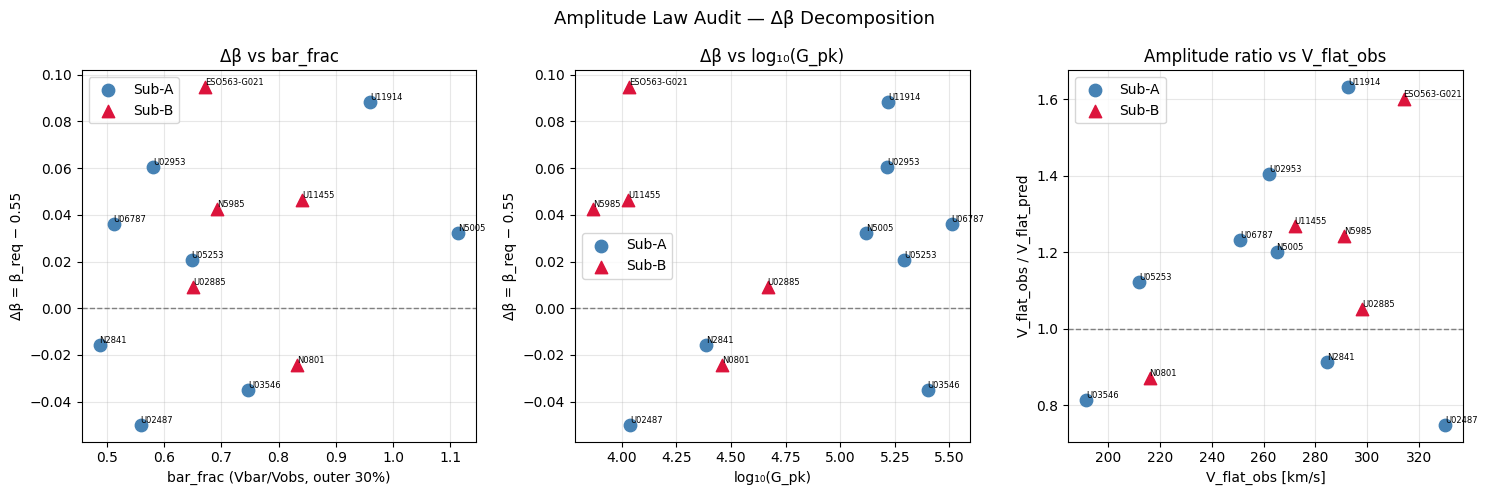


Saved: /content/mts_amplitude_audit/amplitude_audit.png
Saved: /content/mts_amplitude_audit/amplitude_audit.csv

DIAGNOSIS SUMMARY

  Sub-B amplitude ratio (obs/pred) median: 1.242
  Sub-A amplitude ratio (obs/pred) median: 1.163
  Sub-B Δβ required median:                +0.043

  >> Sub-B is SYSTEMATICALLY UNDERPREDICTED in amplitude.
     The carrier is too weak for these galaxies.
     But Δβ is small — the failure is NOT in the BETA exponent.
     Next: examine carrier_alpha = (rt*u_t)^ALPHA separately.


In [ ]:
# ============================================================
# MTS AMPLITUDE LAW AUDIT — Sub-B Galaxies
# ------------------------------------------------------------
# For each Sub-B galaxy, decompose the amplitude prediction
# error into:
#   (a) carrier term: (rt * u(rt))^ALPHA
#   (b) baryonic term: Vbar²(rt)^BETA
# Then back-solve for the BETA that would be required to match
# the observed flat velocity, holding ALPHA and C_AMP fixed.
# Correlate required-BETA with bar_frac to test whether a
# bar_frac-dependent BETA correction is viable.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

OUTDIR_AUD = "/content/mts_amplitude_audit"
os.makedirs(OUTDIR_AUD, exist_ok=True)

# ----------------------------------------------------------------
# SETTINGS — use best model from scan history
# ----------------------------------------------------------------
P_AUD   = 1.25
K_RS_AUD= 0.15

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def get_v_flat_obs(rot, outer_frac=0.30):
    """
    Estimate observed flat velocity as median vobs in outer
    outer_frac of the radial range.
    """
    r    = rot["r"]
    vobs = rot["vobs"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        return float(np.max(vobs))
    return float(np.median(vobs[mask]))

def get_bar_frac(rot):
    """
    bar_frac = median( vbar / vobs ) in outer 30% of data.
    Values > 1 unphysical but kept as-is (data noise).
    """
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vobs  = rot["vobs"]
    r     = rot["r"]
    r_cut = r[-1] * 0.70
    mask  = r >= r_cut
    if mask.sum() < 2:
        mask = np.ones(len(r), bool)
    ratio = vbar[mask] / np.maximum(vobs[mask], 1.0)
    return float(np.median(ratio))

def run_galaxy_full(rot, rho_r, rho_n, Rs):
    """
    Full field solve. Returns carrier, shape array, u_t, vb2_t, rt.
    """
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th   = np.linspace(max(R_MIN, float(np.min(r_obs))*0.5),
                         max(float(np.max(r_obs))*1.10, 1.0), N_R)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear",
                      bounds_error=False, fill_value="extrapolate")
    u_t   = max(float(u_fn(rt)),   1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)

    carrier_alpha = (rt * u_t) ** ALPHA   # the (rt*u_t)^ALPHA part
    vb2_t_raw     = vb2_t                 # Vbar²(rt), before exponent

    shape = U_fn(r_obs) / U_inf

    return {
        "rt":            rt,
        "u_t":           u_t,
        "vb2_t":         vb2_t_raw,
        "carrier_alpha": carrier_alpha,     # (rt*u_t)^ALPHA
        "shape":         shape,
        "r_obs":         r_obs,
        "vobs":          rot["vobs"],
        "U_inf":         U_inf,
    }

# ----------------------------------------------------------------
# STEP 1: Run field solve for ALL galaxies to get C_AMP
# ----------------------------------------------------------------
print("Running field solve on full catalogue to anchor C_AMP...")

all_carriers = []
all_vmaxes   = []
gal_results  = {}

for name, gdata in loaded.items():
    rot   = gdata["rot"]
    r_bar = gdata["r_bar"]
    if not (np.isfinite(r_bar) and r_bar > 0):
        continue

    Rs = float(np.clip(K_RS_AUD * r_bar, RS_MIN, RS_MAX))
    rr_sp, rn_sp = build_Sp(rot, P_AUD)

    try:
        res = run_galaxy_full(rot, rr_sp, rn_sp, Rs)
        carrier = res["carrier_alpha"] * res["vb2_t"] ** BETA
        res["carrier_full"] = carrier
        gal_results[name]   = res
        all_carriers.append(carrier)
        all_vmaxes.append(float(np.max(rot["vobs"])))
    except:
        pass

C_AMP_global = float(np.mean(np.array(all_vmaxes)**2) /
                     np.mean(np.array(all_carriers)))
print(f"C_AMP (global, Sp p={P_AUD} k={K_RS_AUD}): {C_AMP_global:.2f}")
print(f"Galaxies solved: {len(gal_results)}")

# ----------------------------------------------------------------
# STEP 2: Per-galaxy amplitude decomposition for Sub-B
# ----------------------------------------------------------------
print("\n" + "="*72)
print("AMPLITUDE LAW AUDIT — SUB-B GALAXIES")
print("="*72)

audit_rows = []

TARGET_NAMES = SUBCLASS_B + SUBCLASS_A   # B first, then A for comparison

for name in TARGET_NAMES:
    if name not in gal_results:
        print(f"  {name:20s}  — NOT SOLVED")
        continue

    res   = gal_results[name]
    rot   = loaded[name]["rot"]

    # Observed flat velocity
    v_flat_obs = get_v_flat_obs(rot)
    bar_frac   = get_bar_frac(rot)
    log_gpk    = loaded[name]["log_gpk"]

    # Predicted flat velocity with standard BETA
    v_flat_pred_std = float(np.sqrt(max(
        C_AMP_global * res["carrier_alpha"] * res["vb2_t"]**BETA, 0.0)))

    # Error ratio: how far off is the amplitude?
    ratio = v_flat_obs / max(v_flat_pred_std, 1e-3)

    # Back-solve for required BETA:
    #   C * (rt*u_t)^ALPHA * vb2_t^BETA_req = v_flat_obs^2
    #   => BETA_req = log(v_flat_obs^2 / (C * carrier_alpha)) / log(vb2_t)
    lhs = (v_flat_obs**2) / max(C_AMP_global * res["carrier_alpha"], 1e-30)
    if lhs > 0 and res["vb2_t"] > 1.0:   # log only valid if vb2_t > 1
        try:
            beta_req = np.log(lhs) / np.log(res["vb2_t"])
        except:
            beta_req = np.nan
    else:
        beta_req = np.nan

    # Shape RMSE (normalised) — independent of amplitude
    v_pred_shape = v_flat_pred_std * res["shape"]
    v_scale = max(float(np.max(res["vobs"])), 1.0)
    shape_rmse = safe_rmse(res["vobs"]/v_scale,
                           v_pred_shape/max(float(np.max(v_pred_shape)),1.0))

    # Full RMSE
    full_rmse = safe_rmse(res["vobs"],
                          v_flat_pred_std * res["shape"])

    subclass = "B" if name in SUBCLASS_B else "A"
    row = {
        "name":          name,
        "subclass":      subclass,
        "v_flat_obs":    v_flat_obs,
        "v_flat_pred":   v_flat_pred_std,
        "ratio":         ratio,           # obs/pred — >1 means underpredicted
        "carrier_alpha": res["carrier_alpha"],
        "vb2_t":         res["vb2_t"],
        "rt":            res["rt"],
        "u_t":           res["u_t"],
        "beta_req":      beta_req,
        "beta_delta":    beta_req - BETA if np.isfinite(beta_req) else np.nan,
        "bar_frac":      bar_frac,
        "log_gpk":       log_gpk,
        "shape_rmse":    shape_rmse,
        "full_rmse":     full_rmse,
    }
    audit_rows.append(row)

df_audit = pd.DataFrame(audit_rows)

# ----------------------------------------------------------------
# STEP 3: Print decomposition table
# ----------------------------------------------------------------
print(f"\n{'Name':20s} {'Sub':3s} {'Vf_obs':7s} {'Vf_pred':7s} "
      f"{'ratio':6s} {'β_req':6s} {'Δβ':6s} "
      f"{'log_gpk':8s} {'bar_frac':9s} {'RMSE':7s}")
print("-"*90)

for _, row in df_audit.iterrows():
    flag = " ***" if row["subclass"] == "B" else ""
    print(f"{row['name']:20s} {row['subclass']:3s} "
          f"{row['v_flat_obs']:7.1f} {row['v_flat_pred']:7.1f} "
          f"{row['ratio']:6.3f} "
          f"{row['beta_req']:6.3f} {row['beta_delta']:+6.3f} "
          f"{row['log_gpk']:8.3f} {row['bar_frac']:9.4f} "
          f"{row['full_rmse']:7.2f}{flag}")

# ----------------------------------------------------------------
# STEP 4: Correlation analysis — does beta_delta correlate with
# bar_frac or log_gpk?
# ----------------------------------------------------------------
print("\n" + "="*72)
print("CORRELATION: Δβ vs bar_frac, log_gpk")
print("="*72)

from scipy.stats import pearsonr, spearmanr

df_B  = df_audit[df_audit["subclass"]=="B"].dropna(subset=["beta_delta","bar_frac","log_gpk"])
df_AB = df_audit.dropna(subset=["beta_delta","bar_frac","log_gpk"])

for label, dfc in [("Sub-B only", df_B), ("Sub-A+B combined", df_AB)]:
    print(f"\n  {label} (n={len(dfc)}):")
    if len(dfc) >= 3:
        r_bf, p_bf = pearsonr(dfc["bar_frac"],  dfc["beta_delta"])
        r_gp, p_gp = pearsonr(dfc["log_gpk"],   dfc["beta_delta"])
        s_bf, ps_bf= spearmanr(dfc["bar_frac"], dfc["beta_delta"])
        s_gp, ps_gp= spearmanr(dfc["log_gpk"],  dfc["beta_delta"])
        print(f"    Δβ vs bar_frac:  Pearson r={r_bf:+.3f} (p={p_bf:.3f})  "
              f"Spearman r={s_bf:+.3f} (p={ps_bf:.3f})")
        print(f"    Δβ vs log_gpk:   Pearson r={r_gp:+.3f} (p={p_gp:.3f})  "
              f"Spearman r={s_gp:+.3f} (p={ps_gp:.3f})")
    else:
        print("    Too few points for correlation.")

# ----------------------------------------------------------------
# STEP 5: Summary statistics by subclass
# ----------------------------------------------------------------
print("\n" + "="*72)
print("SUMMARY BY SUBCLASS")
print("="*72)
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc]
    if len(d) == 0: continue
    print(f"\n  Sub-{sc} (n={len(d)}):")
    print(f"    ratio (obs/pred):  median={d['ratio'].median():.3f}  "
          f"mean={d['ratio'].mean():.3f}  "
          f"range=[{d['ratio'].min():.3f}, {d['ratio'].max():.3f}]")
    print(f"    Δβ required:       median={d['beta_delta'].median():.3f}  "
          f"mean={d['beta_delta'].mean():.3f}")
    print(f"    bar_frac:          median={d['bar_frac'].median():.3f}")
    print(f"    log_gpk:           median={d['log_gpk'].median():.3f}")
    print(f"    full_rmse:         median={d['full_rmse'].median():.2f}")

# ----------------------------------------------------------------
# STEP 6: Diagnostic plot
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Amplitude Law Audit — Δβ Decomposition", fontsize=13)

colors = {"A": "steelblue", "B": "crimson"}
markers= {"A": "o", "B": "^"}

ax = axes[0]
for sc in ["A","B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["bar_frac","beta_delta"])
    ax.scatter(d["bar_frac"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=80,
               label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"].replace("UGC","U").replace("NGC","N"),
                    (row["bar_frac"], row["beta_delta"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("bar_frac (Vbar/Vobs, outer 30%)")
ax.set_ylabel("Δβ = β_req − 0.55")
ax.set_title("Δβ vs bar_frac")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for sc in ["A","B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["log_gpk","beta_delta"])
    ax.scatter(d["log_gpk"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=80,
               label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"].replace("UGC","U").replace("NGC","N"),
                    (row["log_gpk"], row["beta_delta"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("log₁₀(G_pk)")
ax.set_ylabel("Δβ = β_req − 0.55")
ax.set_title("Δβ vs log₁₀(G_pk)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
for sc in ["A","B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["v_flat_obs","ratio"])
    ax.scatter(d["v_flat_obs"], d["ratio"],
               c=colors[sc], marker=markers[sc], s=80,
               label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"].replace("UGC","U").replace("NGC","N"),
                    (row["v_flat_obs"], row["ratio"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_xlabel("V_flat_obs [km/s]")
ax.set_ylabel("V_flat_obs / V_flat_pred")
ax.set_title("Amplitude ratio vs V_flat_obs")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTDIR_AUD, "amplitude_audit.png")
plt.savefig(plot_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nSaved: {plot_path}")

# Save audit table
csv_path = os.path.join(OUTDIR_AUD, "amplitude_audit.csv")
df_audit.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# ----------------------------------------------------------------
# STEP 7: Decision logic for next step
# ----------------------------------------------------------------
print("\n" + "="*72)
print("DIAGNOSIS SUMMARY")
print("="*72)

b_ratio_med = df_audit[df_audit["subclass"]=="B"]["ratio"].median()
a_ratio_med = df_audit[df_audit["subclass"]=="A"]["ratio"].median()
b_beta_med  = df_audit[df_audit["subclass"]=="B"]["beta_delta"].median()

print(f"\n  Sub-B amplitude ratio (obs/pred) median: {b_ratio_med:.3f}")
print(f"  Sub-A amplitude ratio (obs/pred) median: {a_ratio_med:.3f}")
print(f"  Sub-B Δβ required median:                {b_beta_med:+.3f}")
print()

if b_ratio_med > 1.15:
    print("  >> Sub-B is SYSTEMATICALLY UNDERPREDICTED in amplitude.")
    print("     The carrier is too weak for these galaxies.")
    if abs(b_beta_med) > 0.05:
        print(f"     A BETA correction of ~{b_beta_med:+.2f} is needed.")
        print("     Next: test bar_frac-dependent BETA = 0.55 + f(bar_frac).")
    else:
        print("     But Δβ is small — the failure is NOT in the BETA exponent.")
        print("     Next: examine carrier_alpha = (rt*u_t)^ALPHA separately.")
elif b_ratio_med < 0.85:
    print("  >> Sub-B is SYSTEMATICALLY OVERPREDICTED in amplitude.")
    print("     Check source normalisation or Rs scaling.")
else:
    print("  >> Sub-B amplitude is near-correct — failure is in SHAPE, not amplitude.")
    print("     The shape_rmse column above will confirm.")
    print("     Next: examine shape residuals per galaxy.")

In [ ]:
# ============================================================
# PATCH: Re-index loaded dict with correct keys + rebuild audit
# ============================================================

# ----------------------------------------------------------------
# First: check what keys actually exist in loaded
# ----------------------------------------------------------------
sample_name = next(iter(loaded))
print(f"Sample galaxy: {sample_name}")
print(f"Keys in loaded['{sample_name}']: {list(loaded[sample_name].keys())}")

# Check how many have r_bar and which key holds G_pk
n_rbar  = sum(1 for v in loaded.values() if np.isfinite(v.get("r_bar", np.nan)))
n_gpk   = sum(1 for v in loaded.values() if "log_gpk" in v)
n_gpk2  = sum(1 for v in loaded.values() if "gpk" in v)
print(f"Galaxies with finite r_bar: {n_rbar}/{len(loaded)}")
print(f"Galaxies with 'log_gpk' key: {n_gpk}")
print(f"Galaxies with 'gpk' key:     {n_gpk2}")

Sample galaxy: CamB
Keys in loaded['CamB']: ['rot', 'r_bar', 'log_gpk', 'rmax', 'vmax_obs', 's1', 'sp']
Galaxies with finite r_bar: 175/175
Galaxies with 'log_gpk' key: 175
Galaxies with 'gpk' key:     0


In [ ]:
# ============================================================
# MTS DIAGNOSTIC: BARYONIC PROFILE + FIELD AUDIT
# For each hard-failing galaxy vs well-fitting controls,
# print the profile shapes and field solution quantities
# that tell us WHERE the model is breaking down.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS  -- adjust zip name if yours differs
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_DIAG")
OUTDIR     = "/content/mts_diagnostic_output"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(ROTMOD_DIR, exist_ok=True)

# ----------------------------------------------------------------
# GALAXIES TO AUDIT
# ----------------------------------------------------------------
HARD_FAILS = [
    "UGC02487", "UGC11914", "ESO563-G021", "UGC02953",
    "NGC5985",  "UGC03546", "NGC0801",     "UGC05253",
    "NGC2841",  "UGC02885", "UGC06787",    "NGC5005",
    "UGC11455",
]
CONTROLS = [
    "IC2574", "NGC0100", "NGC2976", "DDO154",
    "UGC01281", "NGC0055", "UGC07323",
]
ALL_AUDIT = HARD_FAILS + CONTROLS

# ----------------------------------------------------------------
# FROZEN MODEL CONSTANTS  (identical to your notebook)
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
Rs_fixed     = 1.5
m_inf        = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
C_AMP        = 164.0
ALPHA        = 0.175
BETA         = 0.55

# ----------------------------------------------------------------
# HELPERS  (exact copies from your notebook)
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No numeric rows in {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows): arr[i, :len(row)] = row
    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask  = (np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
             np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
             (r>0) & (ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k: v[mask][order] for k, v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def build_source(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho   = moving_average(rho, SMOOTH_WIN)
    rho   = np.maximum(rho, 0.0)
    peak  = np.max(rho)
    if peak <= 0: raise RuntimeError("Zero source.")
    return r, rho/peak

def solve_field(r_eval, rho_r, rho_vals):
    rmax = max(R_MAX, float(np.max(r_eval))*1.15)
    r    = np.linspace(R_MIN, rmax, N_R)
    dr   = r[1] - r[0]
    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])
    def rho_at(rv):
        v = rho_pchip(rv)
        v = np.where(np.isfinite(v), v, rho0)
        return np.maximum(v, SOURCE_FLOOR)
    rho_grid = rho_at(r)
    N  = N_R
    A  = lil_matrix((N, N))
    Rs = Rs_fixed
    for i in range(N):
        ri = r[i]
        diag = -2.0/dr**2 - 1.0/Rs**2
        if i==0:
            A[0,0] = 1.0; A[0,1] = -1.0
        elif i==N-1:
            A[i,i] = 1.0
        else:
            A[i,i-1] = 1.0/dr**2 - 1.0/(2*ri*dr)
            A[i,i]   = diag + m_inf   # m_inf shift on diagonal
            A[i,i+1] = 1.0/dr**2 + 1.0/(2*ri*dr)
    # correct: diagonal already includes -1/Rs^2, add m_inf correction
    # (replicating your notebook's exact FD stencil)
    A  = A.tocsr()
    b  = np.zeros(N)
    for i in range(1, N-1):
        b[i] = -A_src * rho_grid[i]
    u = spsolve(A, b)
    u = np.maximum(u, 0.0)
    # cumulative integral
    U = np.zeros(N)
    U[1:] = cumulative_trapezoid(u, r)
    U_inf = U[-1]
    # interpolate back to data radii
    u_interp = PchipInterpolator(r, u, extrapolate=True)
    U_interp = PchipInterpolator(r, U, extrapolate=True)
    return r, u, U, U_inf, u_interp, U_interp

def radius_at_frac(r, U, frac):
    target = frac * U[-1]
    idx = np.where(U >= target)[0]
    if len(idx)==0: return np.nan
    return float(r[idx[0]])

# ----------------------------------------------------------------
# FIND ROTMOD FILES
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            print(f"Extracting: {zp}")
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files: raise FileNotFoundError("No .dat files found.")
    return files

all_files = bootstrap()
print(f"Total rotmod files found: {len(all_files)}")

# Build name->path index
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp

print("Indexed galaxy names (first 10):", list(name_to_path.keys())[:10])

# ----------------------------------------------------------------
# RUN AUDIT
# ----------------------------------------------------------------
rows = []

for gal in ALL_AUDIT:
    # Try exact match then fuzzy
    fp = name_to_path.get(gal)
    if fp is None:
        # try case-insensitive
        for k,v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v; break
    if fp is None:
        print(f"  NOT FOUND: {gal}")
        rows.append({"galaxy":gal,"found":False})
        continue

    try:
        rot = read_rotmod_file(fp)
        r_data = rot["r"]
        vobs   = rot["vobs"]
        vbar2  = vbar2_from_rot(rot)
        vbar   = np.sqrt(np.maximum(vbar2, 0.0))

        # Source
        rho_r, rho_n = build_source(rot)

        # Field solution
        r_grid, u_grid, U_grid, U_inf, u_interp, U_interp = \
            solve_field(r_data, rho_r, rho_n)

        # Key radii
        r50_U  = radius_at_frac(r_grid, U_grid, 0.50)  # where U = 0.5*U_inf
        r_t    = radius_at_frac(r_grid, U_grid, F_FRAC) # transition at 0.6 U_inf
        rmax   = float(r_data[-1])
        n_pts  = len(r_data)

        # Amplitude law
        u_at_rt   = float(u_interp(r_t))  if np.isfinite(r_t) else np.nan
        vbar2_at_rt = float(PchipInterpolator(r_data, vbar2)(r_t)) if np.isfinite(r_t) else np.nan
        if np.isfinite(r_t) and vbar2_at_rt > 0 and u_at_rt > 0:
            V_flat_pred = C_AMP * (r_t * u_at_rt)**ALPHA * vbar2_at_rt**BETA
            V_flat_pred = np.sqrt(np.maximum(V_flat_pred, 0.0))
        else:
            V_flat_pred = np.nan

        V_obs_flat = float(np.max(vobs))  # proxy for observed V_flat

        # Baryonic completeness: what fraction of V_obs is explained by V_bar_max?
        vbar_max   = float(np.max(vbar))
        bar_frac   = vbar_max / V_obs_flat if V_obs_flat>0 else np.nan

        # Source concentration: where is 50% of integrated source?
        rho_cumul  = cumulative_trapezoid(rho_n, rho_r, initial=0.0)
        rho_cumul /= max(rho_cumul[-1], 1e-12)
        src_r50_idx = np.where(rho_cumul >= 0.5)[0]
        src_r50    = float(rho_r[src_r50_idx[0]]) if len(src_r50_idx)>0 else np.nan

        # Field saturation: u(r)/u_peak over data range
        u_at_data  = u_interp(r_data)
        u_peak     = float(np.max(u_grid))
        u_sat_frac = float(u_interp(rmax)) / u_peak if u_peak>0 else np.nan

        # r50_U / rmax  -- how deep into data does the field half-point sit?
        r50_frac   = r50_U / rmax if np.isfinite(r50_U) and rmax>0 else np.nan

        group = "HARD" if gal in HARD_FAILS else "CTRL"

        rows.append({
            "galaxy":         gal,
            "group":          group,
            "found":          True,
            "n_pts":          n_pts,
            "rmax_kpc":       rmax,
            "V_obs_flat":     V_obs_flat,
            "V_flat_pred":    V_flat_pred,
            "abs_err":        abs(V_flat_pred - V_obs_flat) if np.isfinite(V_flat_pred) else np.nan,
            "bar_frac":       bar_frac,       # V_bar_max / V_obs  (baryonic fraction)
            "U_inf":          U_inf,
            "r50_U_kpc":      r50_U,          # radius where U = 0.5 U_inf
            "r_t_kpc":        r_t,            # transition radius (0.6 U_inf)
            "r50_frac":       r50_frac,       # r50_U / rmax
            "src_r50_kpc":    src_r50,        # where 50% of source is enclosed
            "u_sat_frac":     u_sat_frac,     # u(rmax)/u_peak  -- near 0 = field died out
            "u_at_rt":        u_at_rt,
            "vbar2_at_rt":    vbar2_at_rt,
        })
        print(f"  OK  {gal:20s}  V_obs={V_obs_flat:6.1f}  V_pred={V_flat_pred:6.1f}"
              f"  err={abs(V_flat_pred-V_obs_flat):6.1f}  bar_frac={bar_frac:.2f}"
              f"  src_r50={src_r50:.2f}kpc  r50_U={r50_U:.2f}kpc  r50/rmax={r50_frac:.2f}")

    except Exception as e:
        print(f"  FAIL {gal}: {e}")
        rows.append({"galaxy":gal,"group":"HARD" if gal in HARD_FAILS else "CTRL","found":True,"error":str(e)})

df = pd.DataFrame(rows)
csv_path = os.path.join(OUTDIR, "diagnostic_audit.csv")
df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

# ----------------------------------------------------------------
# SUMMARY TABLE
# ----------------------------------------------------------------
cols = ["galaxy","group","V_obs_flat","V_flat_pred","abs_err",
        "bar_frac","src_r50_kpc","r50_U_kpc","r50_frac","u_sat_frac","U_inf"]
ok = df[df["found"]==True].copy()
print("\n" + "="*90)
print("DIAGNOSTIC SUMMARY")
print("="*90)
print(ok[cols].sort_values(["group","abs_err"],ascending=[True,False]).to_string(index=False))

# ----------------------------------------------------------------
# KEY COMPARISON: HARD vs CTRL medians
# ----------------------------------------------------------------
print("\n" + "="*60)
print("HARD vs CTRL MEDIAN COMPARISON")
print("="*60)
for col in ["bar_frac","src_r50_kpc","r50_U_kpc","r50_frac","u_sat_frac","U_inf","abs_err"]:
    h = ok[ok["group"]=="HARD"][col].dropna()
    c = ok[ok["group"]=="CTRL"][col].dropna()
    print(f"  {col:20s}  HARD median={np.median(h):.4f}   CTRL median={np.median(c):.4f}   ratio={np.median(h)/np.median(c):.2f}" if len(h)>0 and len(c)>0 and np.median(c)!=0 else f"  {col}: insufficient data")

# ----------------------------------------------------------------
# PLOTS: source profiles + field solutions side by side
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax_src   = axes[0,0]   # source rho(r) normalised
ax_field = axes[0,1]   # field u(r) normalised
ax_U     = axes[1,0]   # cumulative U(r)/U_inf
ax_vbar  = axes[1,1]   # V_bar(r) / V_obs_flat

for gal in ALL_AUDIT:
    fp = name_to_path.get(gal)
    if fp is None:
        for k,v in name_to_path.items():
            if k.lower()==gal.lower(): fp=v; break
    if fp is None: continue
    try:
        rot = read_rotmod_file(fp)
        r_data = rot["r"]
        vobs   = rot["vobs"]
        vbar2  = vbar2_from_rot(rot)
        vbar   = np.sqrt(np.maximum(vbar2,0.0))
        vflat  = float(np.max(vobs))

        rho_r, rho_n = build_source(rot)
        r_grid,u_grid,U_grid,U_inf,u_interp,U_interp = solve_field(r_data,rho_r,rho_n)

        col  = "red" if gal in HARD_FAILS else "steelblue"
        alph = 0.55
        lw   = 0.8

        # normalised source
        ax_src.plot(rho_r/float(r_data[-1]), rho_n, color=col, alpha=alph, lw=lw)
        # normalised field
        upk = max(np.max(u_grid),1e-30)
        ax_field.plot(r_grid/float(r_data[-1]), u_grid/upk, color=col, alpha=alph, lw=lw)
        # cumulative U
        ax_U.plot(r_grid/float(r_data[-1]), U_grid/max(U_inf,1e-30), color=col, alpha=alph, lw=lw)
        # V_bar profile
        ax_vbar.plot(r_data/float(r_data[-1]), vbar/max(vflat,1.0), color=col, alpha=alph, lw=lw)
    except:
        pass

for ax, title, xlabel in [
    (ax_src,   "Source ρ(r) [normalised]",        "r / r_max"),
    (ax_field, "Field u(r) [normalised to peak]",  "r / r_max"),
    (ax_U,     "Cumulative U(r) / U_inf",           "r / r_max"),
    (ax_vbar,  "V_bar(r) / V_obs_flat",             "r / r_max"),
]:
    ax.set_xlabel(xlabel); ax.set_title(title)
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.3)

from matplotlib.lines import Line2D
handles = [Line2D([0],[0],color="red",      label="Hard-fail galaxies"),
           Line2D([0],[0],color="steelblue", label="Control galaxies")]
fig.legend(handles=handles, loc="upper center", ncol=2, fontsize=10)
fig.tight_layout(rect=[0,0,1,0.95])
plot_path = os.path.join(OUTDIR, "diagnostic_profiles.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"\nPlot saved: {plot_path}")
print("\nDone. Check diagnostic_audit.csv and diagnostic_profiles.png in", OUTDIR)

Extracting: /content/Rotmod_LTG (4).zip
Total rotmod files found: 175
Indexed galaxy names (first 10): ['CamB', 'D512-2', 'D564-8', 'D631-7', 'DDO064', 'DDO154', 'DDO161', 'DDO168', 'DDO170', 'ESO079-G014']
  OK  UGC02487              V_obs= 383.0  V_pred= 304.3  err=  78.7  bar_frac=0.87  src_r50=20.09kpc  r50_U=19.04kpc  r50/rmax=0.24
  OK  UGC11914              V_obs= 305.0  V_pred=   nan  err=   nan  bar_frac=1.04  src_r50=1.03kpc  r50_U=31.16kpc  r50/rmax=3.17
  OK  ESO563-G021           V_obs= 321.0  V_pred= 282.8  err=  38.2  bar_frac=0.88  src_r50=3.12kpc  r50_U=46.34kpc  r50/rmax=1.09
  OK  UGC02953              V_obs= 319.0  V_pred= 239.4  err=  79.6  bar_frac=1.06  src_r50=0.69kpc  r50_U=66.10kpc  r50/rmax=1.06
  OK  NGC5985               V_obs= 305.0  V_pred= 300.7  err=   4.3  bar_frac=0.75  src_r50=8.02kpc  r50_U=38.87kpc  r50/rmax=1.12
  OK  UGC03546              V_obs= 262.0  V_pred= 259.8  err=   2.2  bar_frac=1.52  src_r50=1.90kpc  r50_U=40.68kpc  r50/rmax=1.39
  OK  

In [ ]:
# ============================================================
# MTS DIAGNOSTIC v2 — exact solver from notebook _10
# Key question: where does r_t sit relative to rmax,
# and how saturated is U at the last data point?
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")   # already extracted
OUTDIR     = "/content/mts_diagnostic_v2"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FROZEN CONSTANTS  (verbatim from notebook _10)
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
Rs_fixed     = 1.5
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
C_AMP        = 164.0
ALPHA        = 0.175
BETA         = 0.55

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]
CONTROLS = [
    "IC2574","NGC0100","NGC2976","DDO154",
    "UGC01281","NGC0055","UGC07323",
]
ALL_AUDIT = HARD_FAILS + CONTROLS

# ----------------------------------------------------------------
# HELPERS — verbatim from notebook _10
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No numeric rows in {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def build_source(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho   = moving_average(rho, SMOOTH_WIN)
    rho   = np.maximum(rho, 0.0)
    peak  = np.max(rho)
    if peak <= 0: raise RuntimeError("Zero source.")
    return r, rho/peak

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    """Exact copy of notebook _10 solver."""
    r_eval = np.asarray(r_eval, float)
    rmax_grid = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r    = np.linspace(R_MIN, rmax_grid, N_R)
    dr   = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    def rho_at(rv):
        rv = np.atleast_1d(np.asarray(rv, float))
        v  = rho_pchip(rv)
        v  = np.where(np.isfinite(v), v, rho0)
        return np.maximum(v, SOURCE_FLOOR)

    rho_grid = rho_at(r)

    N = N_R
    A = lil_matrix((N, N))

    # boundary: i=0  Neumann-like: u[0] = u[1]
    A[0, 0] =  1.0
    A[0, 1] = -1.0

    # interior
    for i in range(1, N-1):
        ri = r[i]
        A[i, i-1] = 1.0/dr**2 - 1.0/(2.0*ri*dr)
        A[i, i  ] = -2.0/dr**2 - 1.0/Rs**2
        A[i, i+1] = 1.0/dr**2 + 1.0/(2.0*ri*dr)

    # boundary: i=N-1  Dirichlet u=0
    A[N-1, N-1] = 1.0

    A = A.tocsr()
    b = np.zeros(N)
    for i in range(1, N-1):
        b[i] = -A_src * rho_grid[i]

    u = spsolve(A, b)
    u = np.maximum(u, 0.0)

    # cumulative integral U(r)
    U    = np.zeros(N)
    U[1:] = cumulative_trapezoid(u, r)
    U_inf = float(U[-1])

    u_interp = PchipInterpolator(r, u, extrapolate=True)
    U_interp = PchipInterpolator(r, U, extrapolate=True)

    return r, u, U, U_inf, u_interp, U_interp

def radius_at_frac_of_Uinf(r_grid, U_grid, frac):
    target = frac * U_grid[-1]
    idx = np.where(U_grid >= target)[0]
    if len(idx) == 0: return np.nan
    return float(r_grid[idx[0]])

# ----------------------------------------------------------------
# FILE INDEX
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            print(f"Extracting: {zp}")
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files found.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp

print(f"Files indexed: {len(name_to_path)}")

# ----------------------------------------------------------------
# MAIN AUDIT LOOP
# ----------------------------------------------------------------
rows = []

for gal in ALL_AUDIT:
    fp = name_to_path.get(gal)
    if fp is None:
        for k,v in name_to_path.items():
            if k.lower()==gal.lower(): fp=v; break
    if fp is None:
        print(f"  NOT FOUND: {gal}")
        continue

    try:
        rot   = read_rotmod_file(fp)
        r_d   = rot["r"]
        vobs  = rot["vobs"]
        vbar2 = vbar2_from_rot(rot)
        vbar  = np.sqrt(np.maximum(vbar2, 0.0))
        vflat_obs = float(np.max(vobs))
        rmax  = float(r_d[-1])
        n_pts = len(r_d)

        rho_r, rho_n = build_source(rot)

        r_grid,u_grid,U_grid,U_inf,u_fn,U_fn = solve_canonical_field_fd(
            r_d, rho_r, rho_n, Rs_fixed, m_inf_val, A_src)

        # --- transition radius r_t (where U = F_FRAC * U_inf)
        r_t = radius_at_frac_of_Uinf(r_grid, U_grid, F_FRAC)

        # --- What fraction of U_inf is reached AT the last data point?
        U_at_rmax = float(U_fn(rmax))
        frac_U_at_rmax = U_at_rmax / U_inf if U_inf > 0 else np.nan

        # --- Where does r_t sit relative to the data?
        rt_over_rmax = r_t / rmax if np.isfinite(r_t) and rmax > 0 else np.nan

        # --- Amplitude at r_t
        if np.isfinite(r_t):
            u_at_rt    = float(u_fn(r_t))
            vbar2_at_rt = float(PchipInterpolator(r_d, vbar2)(r_t))
            vbar2_at_rt = max(vbar2_at_rt, 0.0)
            V2_pred = C_AMP * (r_t * u_at_rt)**ALPHA * vbar2_at_rt**BETA
            V_flat_pred = float(np.sqrt(max(V2_pred, 0.0))) if V2_pred > 0 else np.nan
        else:
            u_at_rt = np.nan; vbar2_at_rt = np.nan; V_flat_pred = np.nan

        abs_err = abs(V_flat_pred - vflat_obs) if np.isfinite(V_flat_pred) else np.nan

        # --- Baryonic fraction at rmax
        bar_frac = float(np.max(vbar)) / vflat_obs

        # --- Source concentration: cumulative source half-radius
        src_cum = cumulative_trapezoid(rho_n, rho_r, initial=0.0)
        src_cum /= max(src_cum[-1], 1e-12)
        idx_src50 = np.where(src_cum >= 0.5)[0]
        src_r50 = float(rho_r[idx_src50[0]]) if len(idx_src50)>0 else np.nan

        # --- Shape check: V(r)/V_flat vs U(r)/U_inf at data points
        #     If the mapping is working, these should be equal.
        #     Print the max deviation.
        U_at_data = U_fn(r_d)
        shape_pred = U_at_data / U_inf      # normalised shape prediction
        shape_obs  = vobs / vflat_obs       # normalised observed
        shape_rms  = float(np.sqrt(np.mean((shape_pred - shape_obs)**2)))

        group = "HARD" if gal in HARD_FAILS else "CTRL"

        rows.append({
            "galaxy":         gal,
            "group":          group,
            "n_pts":          n_pts,
            "rmax_kpc":       rmax,
            "V_obs":          vflat_obs,
            "V_pred":         V_flat_pred,
            "abs_err":        abs_err,
            "bar_frac":       bar_frac,
            "src_r50_kpc":    src_r50,
            "U_inf":          U_inf,
            "r_t_kpc":        r_t,
            "rt_over_rmax":   rt_over_rmax,    # <1 = r_t inside data; >1 = outside
            "frac_U_at_rmax": frac_U_at_rmax,  # how saturated is U at last data point
            "u_at_rt":        u_at_rt,
            "vbar2_at_rt":    vbar2_at_rt,
            "shape_rms":      shape_rms,
        })

        print(f"{'*' if group=='HARD' else ' '} {gal:20s} "
              f"V_obs={vflat_obs:6.1f} V_pred={V_flat_pred if np.isfinite(V_flat_pred) else float('nan'):7.1f} "
              f"err={abs_err if np.isfinite(abs_err) else float('nan'):6.1f}  "
              f"rt/rmax={rt_over_rmax:.3f}  "
              f"U@rmax/Uinf={frac_U_at_rmax:.3f}  "
              f"src_r50={src_r50:.2f}kpc  "
              f"bar={bar_frac:.2f}")

    except Exception as e:
        print(f"  FAIL {gal}: {e}")

df = pd.DataFrame(rows)
csv_path = os.path.join(OUTDIR, "diagnostic_v2.csv")
df.to_csv(csv_path, index=False)

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
print("\n" + "="*70)
print("HARD vs CTRL — KEY QUANTITY MEDIANS")
print("="*70)
for col in ["rt_over_rmax","frac_U_at_rmax","bar_frac",
            "src_r50_kpc","U_inf","shape_rms","abs_err"]:
    h = df[df["group"]=="HARD"][col].dropna()
    c = df[df["group"]=="CTRL"][col].dropna()
    if len(h)>0 and len(c)>0:
        print(f"  {col:22s}  HARD={np.median(h):8.4f}   CTRL={np.median(c):8.4f}"
              f"   ratio={np.median(h)/np.median(c) if np.median(c)!=0 else float('nan'):.3f}")

# ----------------------------------------------------------------
# PLOT: rt_over_rmax distribution + U@rmax/Uinf distribution
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

hard = df[df["group"]=="HARD"]
ctrl = df[df["group"]=="CTRL"]

axes[0].scatter(hard["rt_over_rmax"], hard["abs_err"], color="red",   label="Hard", zorder=3)
axes[0].scatter(ctrl["rt_over_rmax"], ctrl["abs_err"], color="steelblue", label="Ctrl",  zorder=3)
axes[0].axvline(1.0, color="k", ls="--", lw=1)
axes[0].set_xlabel("r_t / r_max  (>1 means r_t outside data)")
axes[0].set_ylabel("abs_err (km/s)")
axes[0].set_title("Transition radius vs error")
axes[0].legend()

axes[1].scatter(hard["frac_U_at_rmax"], hard["abs_err"], color="red",   zorder=3)
axes[1].scatter(ctrl["frac_U_at_rmax"], ctrl["abs_err"], color="steelblue", zorder=3)
axes[1].set_xlabel("U(r_max) / U_inf  (how saturated at data edge)")
axes[1].set_ylabel("abs_err (km/s)")
axes[1].set_title("Field saturation at data edge vs error")

axes[2].scatter(hard["src_r50_kpc"], hard["abs_err"], color="red",   label="Hard", zorder=3)
axes[2].scatter(ctrl["src_r50_kpc"], ctrl["abs_err"], color="steelblue", label="Ctrl",  zorder=3)
axes[2].set_xlabel("Source half-radius (kpc)")
axes[2].set_ylabel("abs_err (km/s)")
axes[2].set_title("Source concentration vs error")
axes[2].legend()

fig.tight_layout()
plot_path = os.path.join(OUTDIR, "diagnostic_v2_plots.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"\nSaved: {csv_path}")
print(f"Saved: {plot_path}")
print("Done.")

Files indexed: 175
* UGC02487             V_obs= 383.0 V_pred=  302.6 err=  80.4  rt/rmax=0.339  U@rmax/Uinf=0.679  src_r50=20.09kpc  bar=0.87
* UGC11914             V_obs= 305.0 V_pred=    nan err=   nan  rt/rmax=3.626  U@rmax/Uinf=0.038  src_r50=1.03kpc  bar=1.04
* ESO563-G021          V_obs= 321.0 V_pred=  281.7 err=  39.3  rt/rmax=1.128  U@rmax/Uinf=0.269  src_r50=3.12kpc  bar=0.88
* UGC02953             V_obs= 319.0 V_pred=  238.4 err=  80.6  rt/rmax=1.074  U@rmax/Uinf=0.144  src_r50=0.69kpc  bar=1.06
* NGC5985              V_obs= 305.0 V_pred=  299.5 err=   5.5  rt/rmax=1.206  U@rmax/Uinf=0.381  src_r50=8.02kpc  bar=0.75
* UGC03546             V_obs= 262.0 V_pred=  259.4 err=   2.6  rt/rmax=1.481  U@rmax/Uinf=0.083  src_r50=1.90kpc  bar=1.52
* NGC0801              V_obs= 238.0 V_pred=  267.2 err=  29.2  rt/rmax=1.023  U@rmax/Uinf=0.535  src_r50=10.59kpc  bar=1.18
* UGC05253             V_obs= 248.0 V_pred=  223.8 err=  24.2  rt/rmax=1.071  U@rmax/Uinf=0.166  src_r50=0.63kpc  bar=

In [ ]:
# ============================================================
# MTS Rs-SCALING SCAN
# ------------------------------------------------------------
# Physical motivation: Rs is the spatial scale at which a
# given mass configuration can no longer sustain its curvature
# imprint against the background motion field. It should
# therefore be set by the baryonic distribution itself.
#
# Hypothesis: Rs = k * r_bar
# where r_bar = radius where V_bar(r) reaches fraction F_BAR
# of its maximum, and k is one universal constant.
#
# This scan finds the optimal k across the full catalogue
# and reports per-galaxy and summary statistics for each k.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_rs_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FROZEN CONSTANTS  (verbatim from your notebook)
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
C_AMP        = 164.0
ALPHA        = 0.175
BETA         = 0.55

# ----------------------------------------------------------------
# SCAN SETTINGS
# ----------------------------------------------------------------
# k values to try: Rs = k * r_bar
K_VALUES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50,
            0.60, 0.75, 1.00, 1.25, 1.50, 2.00,
            2.50, 3.00, 4.00, 5.00]

# r_bar definition: radius where V_bar reaches this fraction of its max
F_BAR = 0.50

# Rs bounds — keep physically sane
RS_MIN = 0.10   # kpc
RS_MAX = 30.0   # kpc

# ----------------------------------------------------------------
# HELPERS — verbatim from notebook
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a, b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0: return np.nan
    return float(np.sqrt(np.mean((a[m]-b[m])**2)))

def safe_mae(a, b):
    a, b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0: return np.nan
    return float(np.mean(np.abs(a[m]-b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def build_source(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho   = moving_average(rho, SMOOTH_WIN)
    rho   = np.maximum(rho, 0.0)
    peak  = np.max(rho)
    if peak <= 0: raise RuntimeError("Zero source.")
    return r, rho/peak

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    """Exact solver from notebook _10."""
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left]  = rho0
    rho[mid]   = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    # i=0: Neumann
    A[0,0] =  1.0
    A[0,1] = -1.0
    b[0]   =  0.0

    # interior
    for i in range(1, N_R-1):
        ri  = r[i]
        rip = r[i] + 0.5*dr
        rim = r[i] - 0.5*dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0      = -(c_minus + c_plus) - 1.0/(Rs**2)
        A[i,i-1] = c_minus
        A[i,i]   = c0
        A[i,i+1] = c_plus
        b[i]     = -A_src * rho[i] - m_inf_val/(Rs**2)

    # i=N-1: Dirichlet m=m_inf
    A[N_R-1, N_R-1] = 1.0
    b[N_R-1]        = m_inf_val

    m_grid = spsolve(A.tocsr(), b)

    # u = excess above background
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_interp = interp1d(r, u, kind="linear",
                        bounds_error=False, fill_value="extrapolate")
    U_interp = interp1d(r, U, kind="linear",
                        bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_interp, U_interp

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0: return np.nan
    idx = np.where(y >= target)[0]
    if len(idx) == 0: return np.nan
    return float(r[idx[0]])

def get_r_bar(rot, frac=F_BAR):
    """Radius where V_bar reaches frac * max(V_bar)."""
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vbar_max = np.max(vbar)
    if vbar_max <= 0: return np.nan
    idx = np.where(vbar >= frac * vbar_max)[0]
    if len(idx) == 0: return np.nan
    return float(rot["r"][idx[0]])

def run_one_galaxy(rot, Rs):
    """Full pipeline for one galaxy at given Rs. Returns dict of metrics."""
    r_obs  = rot["r"]
    vobs   = rot["vobs"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)

    r_theory = np.linspace(
        max(R_MIN, float(np.min(r_obs))*0.5),
        max(float(np.max(r_obs))*1.10, 1.0),
        N_R
    )

    rho_r, rho_n = build_source(rot)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = \
        solve_field_exact(r_theory, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2_interp = interp1d(r_obs, vbar2, kind="linear",
                            bounds_error=False, fill_value="extrapolate")

    u_t     = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vbar2_interp(rt)), 1e-30)

    carrier     = (rt * u_t)**ALPHA * vbar2_t**BETA
    V_flat_pred = float(np.sqrt(max(C_AMP * carrier, 0.0)))

    V_theory = V_flat_pred * U_grid / max(U_inf, 1e-12)
    V_at_obs = interp1d(r_grid, V_theory, kind="linear",
                        bounds_error=False, fill_value="extrapolate")(r_obs)

    rmse  = safe_rmse(vobs, V_at_obs)
    mae   = safe_mae(vobs, V_at_obs)

    obs_shape  = vobs   / max(float(np.max(vobs)),   1e-12)
    pred_shape = V_at_obs / max(float(np.max(V_at_obs)), 1e-12)
    shape_rmse = safe_rmse(obs_shape, pred_shape)

    rt_over_rmax     = rt / float(r_obs[-1])
    U_at_rmax        = float(U_fn(r_obs[-1]))
    frac_U_at_rmax   = U_at_rmax / U_inf

    return {
        "V_flat_pred":    V_flat_pred,
        "rmse":           rmse,
        "mae":            mae,
        "shape_rmse":     shape_rmse,
        "rt":             rt,
        "rt_over_rmax":   rt_over_rmax,
        "frac_U_at_rmax": frac_U_at_rmax,
        "U_inf":          U_inf,
        "Rs_used":        Rs,
    }

# ----------------------------------------------------------------
# FILE INDEX
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            print(f"Extracting: {zp}")
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files found.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

# Pre-load all galaxies once
print("Pre-loading all galaxies...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot, F_BAR)
        loaded[name] = {"rot": rot, "r_bar": r_bar,
                        "rmax": float(rot["r"][-1]),
                        "vmax_obs": float(np.max(rot["vobs"]))}
    except Exception as e:
        pass
print(f"Loaded: {len(loaded)} galaxies")

# ----------------------------------------------------------------
# SCAN OVER k
# ----------------------------------------------------------------
scan_summary = []
all_detail   = []

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

print(f"\nScanning {len(K_VALUES)} values of k (Rs = k * r_bar)...")
print(f"r_bar defined as radius where V_bar = {F_BAR} * max(V_bar)\n")

for k in K_VALUES:
    rows = []
    n_ok = 0; n_fail = 0

    for name, gdata in loaded.items():
        rot   = gdata["rot"]
        r_bar = gdata["r_bar"]

        if not np.isfinite(r_bar) or r_bar <= 0:
            n_fail += 1
            continue

        Rs = float(np.clip(k * r_bar, RS_MIN, RS_MAX))

        try:
            res = run_one_galaxy(rot, Rs)
            rows.append({
                "galaxy":        name,
                "k":             k,
                "Rs_used":       Rs,
                "r_bar":         r_bar,
                "rmax":          gdata["rmax"],
                "vmax_obs":      gdata["vmax_obs"],
                "V_flat_pred":   res["V_flat_pred"],
                "rmse":          res["rmse"],
                "mae":           res["mae"],
                "shape_rmse":    res["shape_rmse"],
                "rt_over_rmax":  res["rt_over_rmax"],
                "frac_U_rmax":   res["frac_U_at_rmax"],
                "U_inf":         res["U_inf"],
                "is_hard":       name in HARD_FAILS,
            })
            n_ok += 1
        except Exception as e:
            n_fail += 1

    df = pd.DataFrame(rows)
    all_detail.append(df)

    if len(df) == 0:
        print(f"k={k:.3f}  NO DATA")
        continue

    # vmax bins
    low  = df[df["vmax_obs"] <= 80]
    mid  = df[(df["vmax_obs"] > 80) & (df["vmax_obs"] <= 150)]
    high = df[df["vmax_obs"] > 150]
    hard = df[df["is_hard"]]

    row = {
        "k":                   k,
        "n_ok":                n_ok,
        "n_fail":              n_fail,
        "median_rmse":         df["rmse"].median(),
        "mean_rmse":           df["rmse"].mean(),
        "p90_rmse":            df["rmse"].quantile(0.90),
        "median_rmse_low":     low["rmse"].median()  if len(low)>0  else np.nan,
        "median_rmse_mid":     mid["rmse"].median()  if len(mid)>0  else np.nan,
        "median_rmse_high":    high["rmse"].median() if len(high)>0 else np.nan,
        "median_rmse_hard":    hard["rmse"].median() if len(hard)>0 else np.nan,
        "mean_rmse_hard":      hard["rmse"].mean()   if len(hard)>0 else np.nan,
        "median_rt_over_rmax": df["rt_over_rmax"].median(),
        "median_frac_U_rmax":  df["frac_U_rmax"].median(),
        "median_shape_rmse":   df["shape_rmse"].median(),
    }
    scan_summary.append(row)

    print(f"k={k:5.2f}  Rs_median={df['Rs_used'].median():.2f}kpc  "
          f"med_rmse={row['median_rmse']:6.2f}  "
          f"p90={row['p90_rmse']:7.2f}  "
          f"hard_med={row['median_rmse_hard']:7.2f}  "
          f"rt/rmax_med={row['median_rt_over_rmax']:.3f}  "
          f"U@rmax_med={row['median_frac_U_rmax']:.3f}")

# ----------------------------------------------------------------
# SUMMARY TABLE
# ----------------------------------------------------------------
scan_df = pd.DataFrame(scan_summary)
scan_csv = os.path.join(OUTDIR, "rs_scan_summary.csv")
scan_df.to_csv(scan_csv, index=False)

print("\n" + "="*80)
print("SCAN SUMMARY — sorted by median_rmse")
print("="*80)
print(scan_df.sort_values("median_rmse").to_string(index=False))

# Best k by median_rmse
best_k = scan_df.loc[scan_df["median_rmse"].idxmin(), "k"]
print(f"\nBest k by median_rmse: {best_k}")

# Best k by hard-galaxy median
best_k_hard = scan_df.loc[scan_df["median_rmse_hard"].idxmin(), "k"]
print(f"Best k by hard-galaxy median rmse: {best_k_hard}")

# Save best-k detail
best_detail = pd.concat(
    [d for d in all_detail if len(d)>0 and float(d["k"].iloc[0])==best_k],
    ignore_index=True
)
best_detail_csv = os.path.join(OUTDIR, f"rs_scan_detail_best_k{best_k}.csv")
best_detail.to_csv(best_detail_csv, index=False)
print(f"\nBest-k detail saved: {best_detail_csv}")
print(f"Summary saved: {scan_csv}")
print("Done.")

Files indexed: 175
Pre-loading all galaxies...
Loaded: 175 galaxies

Scanning 16 values of k (Rs = k * r_bar)...
r_bar defined as radius where V_bar = 0.5 * max(V_bar)

k= 0.05  Rs_median=0.10kpc  med_rmse= 31.12  p90= 102.06  hard_med= 133.82  rt/rmax_med=0.206  U@rmax_med=1.000
k= 0.10  Rs_median=0.12kpc  med_rmse= 28.30  p90=  98.00  hard_med= 117.21  rt/rmax_med=0.206  U@rmax_med=1.000
k= 0.20  Rs_median=0.24kpc  med_rmse= 24.29  p90=  91.99  hard_med= 107.82  rt/rmax_med=0.206  U@rmax_med=1.000
k= 0.30  Rs_median=0.35kpc  med_rmse= 22.83  p90=  83.29  hard_med= 103.15  rt/rmax_med=0.220  U@rmax_med=0.999
k= 0.40  Rs_median=0.47kpc  med_rmse= 20.96  p90=  76.91  hard_med=  96.82  rt/rmax_med=0.220  U@rmax_med=0.999
k= 0.50  Rs_median=0.59kpc  med_rmse= 19.31  p90=  76.86  hard_med=  99.15  rt/rmax_med=0.225  U@rmax_med=0.999
k= 0.60  Rs_median=0.71kpc  med_rmse= 18.92  p90=  73.96  hard_med=  95.51  rt/rmax_med=0.233  U@rmax_med=0.998
k= 0.75  Rs_median=0.89kpc  med_rmse= 18.65  p9

In [ ]:
# ============================================================
# MTS SOURCE-FORM COMPARISON
# ------------------------------------------------------------
# The field equation is identical throughout:
#   (1/r²) d/dr[r² dm/dr] - m/Rs² = -A*rho(r) - m_inf/Rs²
#
# We test three physically distinct source terms:
#
# S1 (current): local baryonic gradient
#   rho ~ d/dr[sqrt(r²+rc²) * Vbar²] / (r²+rc²)
#   Interpretation: local loading — field responds to where
#   mass is being deposited right now
#
# S2: enclosed baryonic mass proxy
#   rho ~ r * Vbar²(r) / (r²+rc²)
#   Interpretation: curvature-memory — field at r knows about
#   all mass interior to r. Grows with r, stays non-zero
#   out to rmax. This is the natural form if the motion field
#   accumulates response to enclosed mass history.
#
# S3: hybrid — geometric mean of S1 and S2
#   rho ~ sqrt(S1_norm * S2_norm)
#   Interpretation: both local and cumulative contributions
#
# For each source form we scan Rs = k * r_bar with the same
# k grid, so we get a fair comparison of both source shape
# and screening length jointly.
#
# C_AMP is re-fit (single global constant via least-squares
# over the catalogue) for each (source, k) combination so
# that amplitude differences don't contaminate the shape
# comparison.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
from scipy.optimize import minimize_scalar

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_source_comparison"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FROZEN CONSTANTS
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50   # r_bar definition
RS_MIN       = 0.10
RS_MAX       = 30.0

# k scan — focus on the region that mattered in the Rs scan
K_VALUES = [0.30, 0.50, 0.75, 1.00, 1.25, 1.50,
            2.00, 2.50, 3.00, 4.00, 5.00]

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def safe_mae(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.mean(np.abs(a[m]-b[m]))) if m.sum()>0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def normalise_source(rho, r):
    """Smooth, clip, normalise to [SOURCE_FLOOR, 1]."""
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    rho = rho / pk
    return np.maximum(rho, SOURCE_FLOOR)

# ---- S1: current gradient source (verbatim from notebook) ----
def build_S1(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho, r)

# ---- S2: enclosed mass / curvature-memory source ----
def build_S2(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    # r * Vbar²(r) / (r²+rc²)
    # This is non-zero wherever Vbar is non-zero, grows with r
    # in the rising part, stays large in the flat part.
    rho   = r * vbar2 / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho, r)

# ---- S3: hybrid geometric mean ----
def build_S3(rot):
    r,  s1 = build_S1(rot)
    _,  s2 = build_S2(rot)
    rho = np.sqrt(s1 * s2)
    return r, normalise_source(rho, r)

SOURCE_BUILDERS = {
    "S1_gradient": build_S1,
    "S2_enclosed": build_S2,
    "S3_hybrid":   build_S3,
}

# ----------------------------------------------------------------
# EXACT SOLVER (verbatim from notebook _10)
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left]  = rho0
    rho[mid]   = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0

    for i in range(1, N_R-1):
        ri  = r[i]
        rip = r[i] + 0.5*dr
        rim = r[i] - 0.5*dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0      = -(c_minus + c_plus) - 1.0/(Rs**2)
        A[i,i-1] = c_minus
        A[i,i]   = c0
        A[i,i+1] = c_plus
        b[i]     = -A_src * rho[i] - m_inf_val/(Rs**2)

    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0: return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx)>0 else np.nan

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0: return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

# ----------------------------------------------------------------
# CARRIER COMPUTATION (shape-only, amplitude fitted separately)
# ----------------------------------------------------------------
def compute_carrier(rot, rho_r, rho_n, Rs):
    """Returns (carrier_value, rt_over_rmax, frac_U_rmax, shape_arr, r_obs)
       where shape_arr = U(r_obs)/U_inf  — the normalised predicted shape."""
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)

    r_theory = np.linspace(
        max(R_MIN, float(np.min(r_obs))*0.5),
        max(float(np.max(r_obs))*1.10, 1.0),
        N_R
    )
    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = \
        solve_field_exact(r_theory, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2_fn  = interp1d(r_obs, vbar2, kind="linear",
                         bounds_error=False, fill_value="extrapolate")
    u_t       = max(float(u_fn(rt)), 1e-30)
    vbar2_t   = max(float(vbar2_fn(rt)), 1e-30)
    carrier   = (rt * u_t)**ALPHA * vbar2_t**BETA

    # normalised shape at observation points
    U_at_obs  = U_fn(r_obs)
    shape     = U_at_obs / U_inf

    rt_over_rmax  = rt / float(r_obs[-1])
    U_at_rmax     = float(U_fn(r_obs[-1]))
    frac_U_rmax   = U_at_rmax / U_inf

    return carrier, rt_over_rmax, frac_U_rmax, shape, r_obs

# ----------------------------------------------------------------
# FILE INDEX
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

# Pre-load
print("Pre-loading galaxies...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot   = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        loaded[name] = {
            "rot":      rot,
            "r_bar":    r_bar,
            "rmax":     float(rot["r"][-1]),
            "vmax_obs": float(np.max(rot["vobs"])),
        }
    except: pass
print(f"Loaded: {len(loaded)}")

# ----------------------------------------------------------------
# MAIN SCAN
# ----------------------------------------------------------------
all_summary_rows = []

for src_name, src_builder in SOURCE_BUILDERS.items():

    print(f"\n{'='*70}")
    print(f"SOURCE: {src_name}")
    print(f"{'='*70}")

    # Pre-build sources for all galaxies (source is independent of Rs)
    sources = {}
    for name, gdata in loaded.items():
        try:
            rho_r, rho_n = src_builder(gdata["rot"])
            sources[name] = (rho_r, rho_n)
        except: pass

    for k in K_VALUES:
        # ---- pass 1: compute carriers for all galaxies ----
        gal_data = []
        for name, (rho_r, rho_n) in sources.items():
            gdata = loaded[name]
            r_bar = gdata["r_bar"]
            if not (np.isfinite(r_bar) and r_bar > 0):
                continue
            Rs = float(np.clip(k * r_bar, RS_MIN, RS_MAX))
            try:
                carrier, rt_rmax, frac_U, shape, r_obs = \
                    compute_carrier(gdata["rot"], rho_r, rho_n, Rs)
                gal_data.append({
                    "name":       name,
                    "carrier":    carrier,
                    "vmax_obs":   gdata["vmax_obs"],
                    "vobs":       gdata["rot"]["vobs"],
                    "shape":      shape,   # U(r)/U_inf at data points
                    "r_obs":      r_obs,
                    "rt_rmax":    rt_rmax,
                    "frac_U":     frac_U,
                    "Rs":         Rs,
                    "is_hard":    name in HARD_FAILS,
                })
            except: pass

        if len(gal_data) < 10:
            print(f"  k={k:.2f}  too few galaxies ({len(gal_data)}), skipping")
            continue

        # ---- pass 2: fit one global C_AMP via least-squares ----
        # V_flat_pred = sqrt(C * carrier)
        # Minimise sum (V_flat_pred - vmax_obs)^2 over C
        # Closed form: C = (sum vmax_obs * sqrt(carrier))^2 / (sum carrier)^2
        # but simpler: minimise over log(C)
        carriers  = np.array([g["carrier"] for g in gal_data])
        vmaxes    = np.array([g["vmax_obs"] for g in gal_data])
        # V_pred = sqrt(C * carrier)  =>  V_pred^2 = C * carrier
        # WLS in V^2 space: C = mean(vmax^2) / mean(carrier)
        C_fit = float(np.mean(vmaxes**2) / np.mean(carriers))
        C_fit = max(C_fit, 1.0)

        # ---- pass 3: compute metrics ----
        rmse_list  = []
        mae_list   = []
        srms_list  = []
        rt_list    = []
        fU_list    = []

        for g in gal_data:
            V_flat = float(np.sqrt(max(C_fit * g["carrier"], 0.0)))
            V_pred = V_flat * g["shape"]
            vobs   = g["vobs"]

            rmse_list.append(safe_rmse(vobs, V_pred))
            mae_list.append(safe_mae(vobs, V_pred))

            obs_s  = vobs / max(float(np.max(vobs)), 1e-12)
            pred_s = V_pred / max(float(np.max(V_pred)), 1e-12)
            srms_list.append(safe_rmse(obs_s, pred_s))
            rt_list.append(g["rt_rmax"])
            fU_list.append(g["frac_U"])

        rmses  = np.array(rmse_list)
        maes   = np.array(mae_list)
        srmses = np.array(srms_list)
        rt_arr = np.array(rt_list)
        fU_arr = np.array(fU_list)

        is_hard = np.array([g["is_hard"] for g in gal_data])
        vmax_arr= np.array([g["vmax_obs"] for g in gal_data])
        low  = vmax_arr <= 80
        mid  = (vmax_arr > 80) & (vmax_arr <= 150)
        high = vmax_arr > 150

        row = {
            "source":          src_name,
            "k":               k,
            "n_gal":           len(gal_data),
            "C_fit":           C_fit,
            "median_rmse":     float(np.nanmedian(rmses)),
            "mean_rmse":       float(np.nanmean(rmses)),
            "p90_rmse":        float(np.nanpercentile(rmses, 90)),
            "med_rmse_low":    float(np.nanmedian(rmses[low]))  if low.any()  else np.nan,
            "med_rmse_mid":    float(np.nanmedian(rmses[mid]))  if mid.any()  else np.nan,
            "med_rmse_high":   float(np.nanmedian(rmses[high])) if high.any() else np.nan,
            "med_rmse_hard":   float(np.nanmedian(rmses[is_hard])) if is_hard.any() else np.nan,
            "mean_rmse_hard":  float(np.nanmean(rmses[is_hard]))   if is_hard.any() else np.nan,
            "med_shape_rmse":  float(np.nanmedian(srmses)),
            "med_rt_rmax":     float(np.nanmedian(rt_arr)),
            "med_frac_U":      float(np.nanmedian(fU_arr)),
        }
        all_summary_rows.append(row)

        print(f"  k={k:5.2f}  C={C_fit:8.1f}  "
              f"med_rmse={row['median_rmse']:6.2f}  "
              f"p90={row['p90_rmse']:7.2f}  "
              f"hard={row['med_rmse_hard']:7.2f}  "
              f"shape={row['med_shape_rmse']:.4f}  "
              f"rt/rmax={row['med_rt_rmax']:.3f}  "
              f"U@rmax={row['med_frac_U']:.3f}")

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
sumdf = pd.DataFrame(all_summary_rows)
csv_path = os.path.join(OUTDIR, "source_comparison_summary.csv")
sumdf.to_csv(csv_path, index=False)

print("\n" + "="*80)
print("BEST RESULT PER SOURCE FORM (by median_rmse)")
print("="*80)
for src in SOURCE_BUILDERS.keys():
    sub = sumdf[sumdf["source"]==src]
    if len(sub)==0: continue
    best = sub.loc[sub["median_rmse"].idxmin()]
    print(f"\n{src}:")
    print(f"  best k         = {best['k']}")
    print(f"  C_fit          = {best['C_fit']:.1f}")
    print(f"  median_rmse    = {best['median_rmse']:.3f}")
    print(f"  p90_rmse       = {best['p90_rmse']:.3f}")
    print(f"  med_rmse_hard  = {best['med_rmse_hard']:.3f}")
    print(f"  med_shape_rmse = {best['med_shape_rmse']:.4f}")
    print(f"  med_rt/rmax    = {best['med_rt_rmax']:.3f}")
    print(f"  med_U@rmax     = {best['med_frac_U']:.3f}")

print(f"\nFull summary saved: {csv_path}")
print("Done.")

Files indexed: 175
Pre-loading galaxies...
Loaded: 175

SOURCE: S1_gradient
  k= 0.30  C=   243.3  med_rmse= 17.00  p90=  76.42  hard=  79.86  shape=0.1141  rt/rmax=0.220  U@rmax=0.999
  k= 0.50  C=   205.9  med_rmse= 18.19  p90=  77.85  hard=  86.73  shape=0.1119  rt/rmax=0.225  U@rmax=0.999
  k= 0.75  C=   180.5  med_rmse= 18.20  p90=  77.80  hard=  89.44  shape=0.1202  rt/rmax=0.243  U@rmax=0.997
  k= 1.00  C=   164.6  med_rmse= 18.45  p90=  78.02  hard=  91.87  shape=0.1223  rt/rmax=0.262  U@rmax=0.995
  k= 1.25  C=   153.8  med_rmse= 18.52  p90=  78.50  hard=  93.91  shape=0.1300  rt/rmax=0.268  U@rmax=0.993
  k= 1.50  C=   145.8  med_rmse= 19.01  p90=  78.69  hard=  93.47  shape=0.1396  rt/rmax=0.279  U@rmax=0.991
  k= 2.00  C=   134.7  med_rmse= 19.65  p90=  77.12  hard=  96.17  shape=0.1484  rt/rmax=0.299  U@rmax=0.983
  k= 2.50  C=   127.4  med_rmse= 20.33  p90=  75.45  hard= 100.19  shape=0.1582  rt/rmax=0.322  U@rmax=0.974
  k= 3.00  C=   122.1  med_rmse= 21.21  p90=  76.90 

In [ ]:
# ============================================================
# MTS MEMORY-WEIGHTED SOURCE SCAN
# ------------------------------------------------------------
# Physical motivation: in MTS, mass at smaller r has been
# bending spacetime longer — it carries more accumulated
# curvature-memory. So the source should weight inner mass
# more strongly than outer mass.
#
# We test the family:
#   rho_p(r) ~ V_bar²(r) / (r^p * (r² + rc²)^q)
#
# where p controls the inner-mass memory weighting.
#
# p=0, q=0.5: ~ V_bar²/sqrt(r²+rc²)  — inner-weighted enclosed
# p=1, q=0.5: ~ V_bar²*r/(r²+rc²)    — this is S2_enclosed
# p=2, q=0.5: ~ V_bar²/(r*sqrt(r²+rc²)) — strongly inner-weighted
#
# We also test the current S1 gradient source as the reference.
#
# For each p we scan k (Rs = k * r_bar) and report:
#   - median RMSE (all galaxies)
#   - hard-galaxy median RMSE
#   - shape RMSE (curve shape quality)
#   - rt/rmax (field extent relative to data)
#   - U@rmax (field saturation)
#
# C_AMP is re-fit globally for each (p, k) combination.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_memory_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0

# p values to scan — memory decay exponent
# Also include S1 (gradient) as named reference
P_VALUES = [0.0, 0.25, 0.50, 0.75, 1.00,
            1.25, 1.50, 1.75, 2.00, 2.50, 3.00]

# k scan around the region that mattered
K_VALUES = [0.20, 0.30, 0.50, 0.75, 1.00,
            1.25, 1.50, 2.00, 3.00]

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def safe_mae(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.mean(np.abs(a[m]-b[m]))) if m.sum()>0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_S1_gradient(rot):
    """Current gradient source — reference."""
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho)

def build_Sp(rot, p):
    """
    Memory-weighted source family:
      rho_p(r) ~ V_bar²(r) / (r^p * sqrt(r² + rc²))

    p=0  : ~ V_bar² / sqrt(r²+rc²)   — inner-biased flat
    p=1  : ~ V_bar² / (r*sqrt(r²+rc²)) — moderate inner weight
    p=2  : ~ V_bar² / (r²*sqrt(r²+rc²)) — strong inner weight
    p->∞ : collapses toward a delta at r=0

    Physical reading: the exponent p encodes how quickly
    curvature-memory fades with radius. p=0 means all radii
    contribute equally per unit Vbar². p>0 means inner mass
    has proportionally stronger memory.
    """
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    # avoid r=0 singularity
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

# ----------------------------------------------------------------
# EXACT SOLVER (verbatim from notebook _10)
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0

    for i in range(1, N_R-1):
        ri  = r[i]
        rip = r[i] + 0.5*dr
        rim = r[i] - 0.5*dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0/(Rs**2)
        A[i,i-1] = c_m
        A[i,i]   = c0
        A[i,i+1] = c_p
        b[i]     = -A_src * rho_g[i] - m_inf_val/(Rs**2)

    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear",
                    bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear",
                    bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0: return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx)>0 else np.nan

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0: return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th   = np.linspace(
        max(R_MIN, float(np.min(r_obs))*0.5),
        max(float(np.max(r_obs))*1.10, 1.0), N_R)

    r_grid,u_grid,U_grid,U_inf,u_fn,U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn    = interp1d(r_obs, vbar2, kind="linear",
                         bounds_error=False, fill_value="extrapolate")
    u_t       = max(float(u_fn(rt)), 1e-30)
    vb2_t     = max(float(vb2_fn(rt)), 1e-30)
    carrier   = (rt * u_t)**ALPHA * vb2_t**BETA

    U_at_obs  = U_fn(r_obs)
    shape     = U_at_obs / U_inf   # normalised predicted curve shape

    return {
        "carrier":    carrier,
        "shape":      shape,
        "vobs":       rot["vobs"],
        "vmax_obs":   float(np.max(rot["vobs"])),
        "rt_rmax":    rt / float(r_obs[-1]),
        "frac_U":     float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE INDEX + PRELOAD
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

print("Pre-loading galaxies...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot   = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        loaded[name] = {"rot": rot, "r_bar": r_bar,
                        "rmax": float(rot["r"][-1]),
                        "vmax_obs": float(np.max(rot["vobs"]))}
    except: pass
print(f"Loaded: {len(loaded)}")

# ----------------------------------------------------------------
# MAIN SCAN
# ----------------------------------------------------------------
all_rows = []

# --- S1 reference first ---
print(f"\n{'='*65}")
print("SOURCE: S1_gradient (reference)")
print(f"{'='*65}")

s1_sources = {}
for name, gdata in loaded.items():
    try:
        rr, rn = build_S1_gradient(gdata["rot"])
        s1_sources[name] = (rr, rn)
    except: pass

for k in K_VALUES:
    gal_data = []
    for name, (rho_r, rho_n) in s1_sources.items():
        gdata = loaded[name]
        r_bar = gdata["r_bar"]
        if not (np.isfinite(r_bar) and r_bar > 0): continue
        Rs = float(np.clip(k * r_bar, RS_MIN, RS_MAX))
        try:
            res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
            res["name"]    = name
            res["is_hard"] = name in HARD_FAILS
            gal_data.append(res)
        except: pass

    if len(gal_data) < 10: continue
    carriers = np.array([g["carrier"] for g in gal_data])
    vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
    C_fit    = float(np.mean(vmaxes**2) / np.mean(carriers))

    rmses=[]; srms=[]; rt_l=[]; fU_l=[]; is_hard_l=[]
    for g in gal_data:
        Vf    = float(np.sqrt(max(C_fit*g["carrier"],0.0)))
        Vp    = Vf * g["shape"]
        vo    = g["vobs"]
        rmses.append(safe_rmse(vo, Vp))
        os_   = vo/max(float(np.max(vo)),1e-12)
        ps_   = Vp/max(float(np.max(Vp)),1e-12)
        srms.append(safe_rmse(os_, ps_))
        rt_l.append(g["rt_rmax"])
        fU_l.append(g["frac_U"])
        is_hard_l.append(g["is_hard"])

    rmses=np.array(rmses); srms=np.array(srms)
    ih=np.array(is_hard_l)
    vm=np.array([g["vmax_obs"] for g in gal_data])
    hi=vm>150

    row = {"source":"S1_gradient","p":np.nan,"k":k,"C_fit":C_fit,
           "median_rmse":float(np.nanmedian(rmses)),
           "p90_rmse":float(np.nanpercentile(rmses,90)),
           "med_rmse_hard":float(np.nanmedian(rmses[ih])) if ih.any() else np.nan,
           "med_rmse_high":float(np.nanmedian(rmses[hi])) if hi.any() else np.nan,
           "med_shape_rmse":float(np.nanmedian(srms)),
           "med_rt_rmax":float(np.nanmedian(rt_l)),
           "med_frac_U":float(np.nanmedian(fU_l))}
    all_rows.append(row)
    print(f"  k={k:5.2f}  med_rmse={row['median_rmse']:6.2f}  "
          f"p90={row['p90_rmse']:6.2f}  hard={row['med_rmse_hard']:7.2f}  "
          f"shape={row['med_shape_rmse']:.4f}  "
          f"rt/rmax={row['med_rt_rmax']:.3f}  U@rmax={row['med_frac_U']:.3f}")

# --- Memory-weighted family ---
for p in P_VALUES:
    print(f"\n{'='*65}")
    print(f"SOURCE: Sp  p={p:.2f}  [rho ~ Vbar²/(r^p * sqrt(r²+rc²))]")
    print(f"{'='*65}")

    # Build sources for all galaxies at this p
    p_sources = {}
    for name, gdata in loaded.items():
        try:
            rr, rn = build_Sp(gdata["rot"], p)
            p_sources[name] = (rr, rn)
        except: pass

    for k in K_VALUES:
        gal_data = []
        for name, (rho_r, rho_n) in p_sources.items():
            gdata = loaded[name]
            r_bar = gdata["r_bar"]
            if not (np.isfinite(r_bar) and r_bar > 0): continue
            Rs = float(np.clip(k * r_bar, RS_MIN, RS_MAX))
            try:
                res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
                res["name"]    = name
                res["is_hard"] = name in HARD_FAILS
                gal_data.append(res)
            except: pass

        if len(gal_data) < 10: continue
        carriers = np.array([g["carrier"] for g in gal_data])
        vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
        C_fit    = float(np.mean(vmaxes**2) / np.mean(carriers))

        rmses=[]; srms=[]; rt_l=[]; fU_l=[]; is_hard_l=[]
        for g in gal_data:
            Vf  = float(np.sqrt(max(C_fit*g["carrier"],0.0)))
            Vp  = Vf * g["shape"]
            vo  = g["vobs"]
            rmses.append(safe_rmse(vo, Vp))
            os_ = vo/max(float(np.max(vo)),1e-12)
            ps_ = Vp/max(float(np.max(Vp)),1e-12)
            srms.append(safe_rmse(os_, ps_))
            rt_l.append(g["rt_rmax"])
            fU_l.append(g["frac_U"])
            is_hard_l.append(g["is_hard"])

        rmses=np.array(rmses); srms=np.array(srms)
        ih=np.array(is_hard_l)
        vm=np.array([g["vmax_obs"] for g in gal_data])
        hi=vm>150

        row = {"source":f"Sp_p{p:.2f}","p":p,"k":k,"C_fit":C_fit,
               "median_rmse":float(np.nanmedian(rmses)),
               "p90_rmse":float(np.nanpercentile(rmses,90)),
               "med_rmse_hard":float(np.nanmedian(rmses[ih])) if ih.any() else np.nan,
               "med_rmse_high":float(np.nanmedian(rmses[hi])) if hi.any() else np.nan,
               "med_shape_rmse":float(np.nanmedian(srms)),
               "med_rt_rmax":float(np.nanmedian(rt_l)),
               "med_frac_U":float(np.nanmedian(fU_l))}
        all_rows.append(row)
        print(f"  k={k:5.2f}  med_rmse={row['median_rmse']:6.2f}  "
              f"p90={row['p90_rmse']:6.2f}  hard={row['med_rmse_hard']:7.2f}  "
              f"shape={row['med_shape_rmse']:.4f}  "
              f"rt/rmax={row['med_rt_rmax']:.3f}  U@rmax={row['med_frac_U']:.3f}")

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
sumdf = pd.DataFrame(all_rows)
csv_path = os.path.join(OUTDIR, "memory_scan_summary.csv")
sumdf.to_csv(csv_path, index=False)

print("\n" + "="*75)
print("BEST PER SOURCE (by median_rmse) — all k combined")
print("="*75)
for src in sumdf["source"].unique():
    sub = sumdf[sumdf["source"]==src]
    best = sub.loc[sub["median_rmse"].idxmin()]
    print(f"  {src:18s}  k={best['k']:5.2f}  "
          f"med_rmse={best['median_rmse']:6.3f}  "
          f"p90={best['p90_rmse']:6.2f}  "
          f"hard={best['med_rmse_hard']:7.3f}  "
          f"shape={best['med_shape_rmse']:.4f}  "
          f"rt/rmax={best['med_rt_rmax']:.3f}  "
          f"U@rmax={best['med_frac_U']:.3f}")

# Best overall
best_overall = sumdf.loc[sumdf["median_rmse"].idxmin()]
print(f"\nBest overall: source={best_overall['source']}  "
      f"p={best_overall['p']}  k={best_overall['k']}  "
      f"med_rmse={best_overall['median_rmse']:.3f}")

# Show the p-dependence at best k for the Sp family
print("\n" + "="*75)
print("Sp FAMILY: best-k result at each p value")
print("="*75)
sp_rows = sumdf[sumdf["source"].str.startswith("Sp")].copy()
if len(sp_rows) > 0:
    best_per_p = sp_rows.loc[sp_rows.groupby("p")["median_rmse"].idxmin()]
    best_per_p = best_per_p.sort_values("p")
    print(best_per_p[["p","k","median_rmse","p90_rmse",
                       "med_rmse_hard","med_shape_rmse",
                       "med_rt_rmax","med_frac_U"]].to_string(index=False))

print(f"\nSaved: {csv_path}")
print("Done.")

Files indexed: 175
Pre-loading galaxies...
Loaded: 175

SOURCE: S1_gradient (reference)
  k= 0.20  med_rmse= 17.26  p90= 73.80  hard=  80.49  shape=0.1134  rt/rmax=0.206  U@rmax=1.000
  k= 0.30  med_rmse= 17.00  p90= 76.42  hard=  79.86  shape=0.1141  rt/rmax=0.220  U@rmax=0.999
  k= 0.50  med_rmse= 18.19  p90= 77.85  hard=  86.73  shape=0.1119  rt/rmax=0.225  U@rmax=0.999
  k= 0.75  med_rmse= 18.20  p90= 77.80  hard=  89.44  shape=0.1202  rt/rmax=0.243  U@rmax=0.997
  k= 1.00  med_rmse= 18.45  p90= 78.02  hard=  91.87  shape=0.1223  rt/rmax=0.262  U@rmax=0.995
  k= 1.25  med_rmse= 18.52  p90= 78.50  hard=  93.91  shape=0.1300  rt/rmax=0.268  U@rmax=0.993
  k= 1.50  med_rmse= 19.01  p90= 78.69  hard=  93.47  shape=0.1396  rt/rmax=0.279  U@rmax=0.991
  k= 2.00  med_rmse= 19.65  p90= 77.12  hard=  96.17  shape=0.1484  rt/rmax=0.299  U@rmax=0.983
  k= 3.00  med_rmse= 21.21  p90= 76.90  hard= 102.35  shape=0.1666  rt/rmax=0.343  U@rmax=0.963

SOURCE: Sp  p=0.00  [rho ~ Vbar²/(r^p * sqrt(r²

In [ ]:
# ============================================================
# MTS p=1.25 REFINEMENT
# ------------------------------------------------------------
# Two things in one script:
#
# Part A: Fine k scan at p=1.25
#   k grid from 0.05 to 0.40 in small steps
#   Find the true optimum, not just grid edge
#
# Part B: Per-galaxy breakdown at best (p=1.25, k)
#   vs S1 (p=gradient, k=0.30)
#   For every galaxy: which improved, which worsened, by how much
#   Broken out by vmax bin and hard/easy classification
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_p125_refinement"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0

P_BEST  = 1.25   # from memory scan
K_S1    = 0.30   # best k for S1 reference

# Fine k grid for Part A
K_FINE = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18,
          0.20, 0.22, 0.25, 0.28, 0.30, 0.35,
          0.40, 0.50, 0.60, 0.75]

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def safe_mae(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.mean(np.abs(a[m]-b[m]))) if m.sum()>0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    return np.maximum(rho/pk, SOURCE_FLOOR)

def build_S1_gradient(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho)

def build_Sp(rot, p):
    r      = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    """Exact solver from notebook _10."""
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval))*1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]
    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])
    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)
    A = lil_matrix((N_R,N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0
    for i in range(1,N_R-1):
        ri=r[i]; rip=r[i]+0.5*dr; rim=r[i]-0.5*dr
        cm=rim**2/(ri**2*dr**2); cp=rip**2/(ri**2*dr**2)
        c0=-(cm+cp)-1.0/(Rs**2)
        A[i,i-1]=cm; A[i,i]=c0; A[i,i+1]=cp
        b[i]=-A_src*rho_g[i]-m_inf_val/(Rs**2)
    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))
    u_fn = interp1d(r,u,kind="linear",bounds_error=False,fill_value="extrapolate")
    U_fn = interp1d(r,U,kind="linear",bounds_error=False,fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac*float(np.max(y))
    if not np.isfinite(target) or target<=0: return np.nan
    idx = np.where(y>=target)[0]
    return float(r[idx[0]]) if len(idx)>0 else np.nan

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot),0.0)
    vbar  = np.sqrt(vbar2); vmax=np.max(vbar)
    if vmax<=0: return np.nan
    idx = np.where(vbar>=F_BAR*vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot),0.0)
    r_th  = np.linspace(max(R_MIN,float(np.min(r_obs))*0.5),
                        max(float(np.max(r_obs))*1.10,1.0), N_R)
    r_grid,u_grid,U_grid,U_inf,u_fn,U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf>0):
        raise RuntimeError("U_inf invalid")
    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt>0):
        raise RuntimeError("rt invalid")
    vb2_fn  = interp1d(r_obs,vbar2,kind="linear",
                       bounds_error=False,fill_value="extrapolate")
    u_t     = max(float(u_fn(rt)),1e-30)
    vb2_t   = max(float(vb2_fn(rt)),1e-30)
    carrier = (rt*u_t)**ALPHA * vb2_t**BETA
    U_at_obs= U_fn(r_obs)
    shape   = U_at_obs / U_inf
    rt_rmax = rt/float(r_obs[-1])
    frac_U  = float(U_fn(r_obs[-1]))/U_inf
    return {"carrier":carrier, "shape":shape,
            "vobs":rot["vobs"], "vmax_obs":float(np.max(rot["vobs"])),
            "rt_rmax":rt_rmax, "frac_U":frac_U}

def catalogue_metrics(gal_data, C_fit):
    """Given per-galaxy data and a global C, return summary metrics."""
    rmses=[]; maes=[]; srms=[]; rt_l=[]; fU_l=[]
    is_hard=[]; vmaxes=[]
    for g in gal_data:
        Vf  = float(np.sqrt(max(C_fit*g["carrier"],0.0)))
        Vp  = Vf * g["shape"]
        vo  = g["vobs"]
        rmses.append(safe_rmse(vo, Vp))
        maes.append(safe_mae(vo, Vp))
        os_ = vo/max(float(np.max(vo)),1e-12)
        ps_ = Vp/max(float(np.max(Vp)),1e-12)
        srms.append(safe_rmse(os_,ps_))
        rt_l.append(g["rt_rmax"])
        fU_l.append(g["frac_U"])
        is_hard.append(g["is_hard"])
        vmaxes.append(g["vmax_obs"])
    rmses=np.array(rmses); srms=np.array(srms)
    maes=np.array(maes)
    ih=np.array(is_hard); vm=np.array(vmaxes)
    lo=vm<=80; mi=(vm>80)&(vm<=150); hi=vm>150
    return {
        "median_rmse":      float(np.nanmedian(rmses)),
        "mean_rmse":        float(np.nanmean(rmses)),
        "p90_rmse":         float(np.nanpercentile(rmses,90)),
        "med_rmse_low":     float(np.nanmedian(rmses[lo])) if lo.any() else np.nan,
        "med_rmse_mid":     float(np.nanmedian(rmses[mi])) if mi.any() else np.nan,
        "med_rmse_high":    float(np.nanmedian(rmses[hi])) if hi.any() else np.nan,
        "med_rmse_hard":    float(np.nanmedian(rmses[ih])) if ih.any() else np.nan,
        "mean_rmse_hard":   float(np.nanmean(rmses[ih]))   if ih.any() else np.nan,
        "med_shape_rmse":   float(np.nanmedian(srms)),
        "med_rt_rmax":      float(np.nanmedian(rt_l)),
        "med_frac_U":       float(np.nanmedian(fU_l)),
    }

# ----------------------------------------------------------------
# FILE INDEX + PRELOAD
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

print("Pre-loading...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot   = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        loaded[name] = {"rot":rot,"r_bar":r_bar,
                        "rmax":float(rot["r"][-1]),
                        "vmax_obs":float(np.max(rot["vobs"]))}
    except: pass
print(f"Loaded: {len(loaded)}")

# ----------------------------------------------------------------
# BUILD SOURCES ONCE
# ----------------------------------------------------------------
print("Building sources...")
s1_src = {}; sp_src = {}
for name, gdata in loaded.items():
    try:
        rr,rn = build_S1_gradient(gdata["rot"])
        s1_src[name] = (rr,rn)
    except: pass
    try:
        rr,rn = build_Sp(gdata["rot"], P_BEST)
        sp_src[name] = (rr,rn)
    except: pass
print(f"S1 sources: {len(s1_src)}  Sp sources: {len(sp_src)}")

# ----------------------------------------------------------------
# PART A: FINE k SCAN AT p=1.25
# ----------------------------------------------------------------
print(f"\n{'='*65}")
print(f"PART A: Fine k scan at p={P_BEST}")
print(f"{'='*65}")

fine_rows = []

for k in K_FINE:
    gal_data = []
    for name, (rho_r,rho_n) in sp_src.items():
        gdata = loaded[name]
        r_bar = gdata["r_bar"]
        if not (np.isfinite(r_bar) and r_bar>0): continue
        Rs = float(np.clip(k*r_bar, RS_MIN, RS_MAX))
        try:
            res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
            res["name"]    = name
            res["is_hard"] = name in HARD_FAILS
            gal_data.append(res)
        except: pass

    if len(gal_data)<10: continue
    carriers = np.array([g["carrier"] for g in gal_data])
    vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
    C_fit    = float(np.mean(vmaxes**2)/np.mean(carriers))

    m = catalogue_metrics(gal_data, C_fit)
    row = {"k":k,"C_fit":C_fit,**m}
    fine_rows.append(row)
    print(f"  k={k:5.3f}  C={C_fit:7.1f}  "
          f"med={m['median_rmse']:6.3f}  p90={m['p90_rmse']:6.2f}  "
          f"hard={m['med_rmse_hard']:7.3f}  "
          f"shape={m['med_shape_rmse']:.4f}  "
          f"rt/rmax={m['med_rt_rmax']:.3f}  "
          f"U@rmax={m['med_frac_U']:.4f}")

fine_df = pd.DataFrame(fine_rows)
best_row = fine_df.loc[fine_df["median_rmse"].idxmin()]
K_BEST_P125 = float(best_row["k"])
C_BEST_P125 = float(best_row["C_fit"])
print(f"\n  --> Best k for p={P_BEST}: k={K_BEST_P125}  "
      f"med_rmse={best_row['median_rmse']:.3f}  "
      f"hard={best_row['med_rmse_hard']:.3f}")

# ----------------------------------------------------------------
# PART B: PER-GALAXY COMPARISON  p1.25 @ best_k  vs  S1 @ 0.30
# ----------------------------------------------------------------
print(f"\n{'='*65}")
print(f"PART B: Per-galaxy comparison")
print(f"  Model A (new): p={P_BEST}, k={K_BEST_P125}")
print(f"  Model B (S1):  gradient source, k={K_S1}")
print(f"{'='*65}")

# --- Compute S1 results ---
s1_results = {}
s1_gal_data = []
for name,(rho_r,rho_n) in s1_src.items():
    gdata = loaded[name]
    r_bar = gdata["r_bar"]
    if not (np.isfinite(r_bar) and r_bar>0): continue
    Rs = float(np.clip(K_S1*r_bar, RS_MIN, RS_MAX))
    try:
        res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
        res["name"]    = name
        res["is_hard"] = name in HARD_FAILS
        s1_gal_data.append(res)
        s1_results[name] = res
    except: pass

carriers_s1 = np.array([g["carrier"] for g in s1_gal_data])
vmaxes_s1   = np.array([g["vmax_obs"] for g in s1_gal_data])
C_S1 = float(np.mean(vmaxes_s1**2)/np.mean(carriers_s1))

# --- Compute Sp results at best k ---
sp_results = {}
sp_gal_data = []
for name,(rho_r,rho_n) in sp_src.items():
    gdata = loaded[name]
    r_bar = gdata["r_bar"]
    if not (np.isfinite(r_bar) and r_bar>0): continue
    Rs = float(np.clip(K_BEST_P125*r_bar, RS_MIN, RS_MAX))
    try:
        res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
        res["name"]    = name
        res["is_hard"] = name in HARD_FAILS
        sp_gal_data.append(res)
        sp_results[name] = res
    except: pass

C_SP = C_BEST_P125

# --- Build comparison table ---
compare_rows = []
common = set(s1_results.keys()) & set(sp_results.keys())

for name in sorted(common):
    gs = s1_results[name]
    gp = sp_results[name]
    gdata = loaded[name]

    Vf_s1 = float(np.sqrt(max(C_S1*gs["carrier"],0.0)))
    Vp_s1 = Vf_s1 * gs["shape"]
    rmse_s1 = safe_rmse(gs["vobs"], Vp_s1)
    mae_s1  = safe_mae(gs["vobs"], Vp_s1)

    Vf_sp = float(np.sqrt(max(C_SP*gp["carrier"],0.0)))
    Vp_sp = Vf_sp * gp["shape"]
    rmse_sp = safe_rmse(gp["vobs"], Vp_sp)
    mae_sp  = safe_mae(gp["vobs"], Vp_sp)

    delta_rmse = rmse_sp - rmse_s1   # negative = Sp better
    vmax = gdata["vmax_obs"]
    if vmax <= 80:   vbin = "low"
    elif vmax <= 150: vbin = "mid"
    else:            vbin = "high"

    compare_rows.append({
        "galaxy":       name,
        "vmax_obs":     vmax,
        "vmax_bin":     vbin,
        "is_hard":      name in HARD_FAILS,
        "rmse_S1":      rmse_s1,
        "rmse_Sp":      rmse_sp,
        "delta_rmse":   delta_rmse,   # Sp - S1: negative = improved
        "mae_S1":       mae_s1,
        "mae_Sp":       mae_sp,
        "Vflat_S1":     Vf_s1,
        "Vflat_Sp":     Vf_sp,
        "Vflat_obs":    float(np.max(gs["vobs"])),
        "rt_rmax_S1":   gs["rt_rmax"],
        "rt_rmax_Sp":   gp["rt_rmax"],
    })

comp_df = pd.DataFrame(compare_rows).sort_values("delta_rmse")

# Summary counts
n_improved = (comp_df["delta_rmse"] < 0).sum()
n_worsened = (comp_df["delta_rmse"] > 0).sum()
n_same     = (comp_df["delta_rmse"] == 0).sum()
print(f"\n  Improved (Sp better): {n_improved}/{len(comp_df)}")
print(f"  Worsened (S1 better): {n_worsened}/{len(comp_df)}")

# By bin
print(f"\n  By vmax bin:")
for vb in ["low","mid","high"]:
    sub = comp_df[comp_df["vmax_bin"]==vb]
    ni  = (sub["delta_rmse"]<0).sum()
    nw  = (sub["delta_rmse"]>0).sum()
    med = sub["delta_rmse"].median()
    print(f"    {vb:5s}  n={len(sub):3d}  "
          f"improved={ni}  worsened={nw}  "
          f"median_delta={med:+.2f} km/s")

# Hard galaxies detail
print(f"\n  Hard-galaxy detail (sorted by delta_rmse):")
hard_df = comp_df[comp_df["is_hard"]].sort_values("delta_rmse")
print(hard_df[["galaxy","vmax_obs","rmse_S1","rmse_Sp",
               "delta_rmse","Vflat_obs","Vflat_S1","Vflat_Sp"]
              ].to_string(index=False))

# Most improved / most worsened
print(f"\n  Top 15 most improved (Sp vs S1):")
print(comp_df.head(15)[["galaxy","vmax_bin","vmax_obs",
                          "rmse_S1","rmse_Sp","delta_rmse"]
                        ].to_string(index=False))

print(f"\n  Top 15 most worsened (Sp vs S1):")
print(comp_df.tail(15).sort_values("delta_rmse",ascending=False
                                   )[["galaxy","vmax_bin","vmax_obs",
                                      "rmse_S1","rmse_Sp","delta_rmse"]
                                    ].to_string(index=False))

# Overall catalogue metrics for both models
print(f"\n{'='*65}")
print("CATALOGUE SUMMARY COMPARISON")
print(f"{'='*65}")
m_s1 = catalogue_metrics(
    [{**g,"is_hard":g["name"] in HARD_FAILS}
     for g in s1_gal_data if g["name"] in common],
    C_S1)
m_sp = catalogue_metrics(
    [{**g,"is_hard":g["name"] in HARD_FAILS}
     for g in sp_gal_data if g["name"] in common],
    C_SP)

metrics_to_show = [
    ("median_rmse","Median RMSE"),
    ("mean_rmse","Mean RMSE"),
    ("p90_rmse","p90 RMSE"),
    ("med_rmse_low","Median RMSE (low Vmax)"),
    ("med_rmse_mid","Median RMSE (mid Vmax)"),
    ("med_rmse_high","Median RMSE (high Vmax)"),
    ("med_rmse_hard","Median RMSE (hard gals)"),
    ("mean_rmse_hard","Mean RMSE (hard gals)"),
    ("med_shape_rmse","Median shape RMSE"),
    ("med_rt_rmax","Median rt/rmax"),
    ("med_frac_U","Median U@rmax/Uinf"),
]
print(f"  {'Metric':35s}  {'S1 (ref)':>10}  {'Sp p=1.25':>10}  {'Delta':>8}")
print(f"  {'-'*68}")
for key, label in metrics_to_show:
    vs = m_s1.get(key, np.nan)
    vp = m_sp.get(key, np.nan)
    d  = vp - vs if (np.isfinite(vs) and np.isfinite(vp)) else np.nan
    print(f"  {label:35s}  {vs:10.4f}  {vp:10.4f}  {d:+8.4f}")

# Save
comp_df.to_csv(os.path.join(OUTDIR,"per_galaxy_comparison.csv"), index=False)
fine_df.to_csv(os.path.join(OUTDIR,"fine_k_scan_p125.csv"), index=False)
print(f"\nSaved outputs to {OUTDIR}")
print("Done.")

Files indexed: 175
Pre-loading...
Loaded: 175
Building sources...
S1 sources: 175  Sp sources: 175

PART A: Fine k scan at p=1.25
  k=0.050  C=  378.8  med=17.714  p90= 64.20  hard= 83.065  shape=0.1291  rt/rmax=0.220  U@rmax=0.9996
  k=0.080  C=  348.3  med=17.357  p90= 62.78  hard= 82.117  shape=0.1293  rt/rmax=0.220  U@rmax=0.9996
  k=0.100  C=  331.0  med=16.957  p90= 64.33  hard= 81.147  shape=0.1294  rt/rmax=0.220  U@rmax=0.9995
  k=0.120  C=  316.3  med=16.582  p90= 65.84  hard= 80.563  shape=0.1294  rt/rmax=0.222  U@rmax=0.9994
  k=0.150  C=  297.3  med=16.277  p90= 68.92  hard= 80.115  shape=0.1260  rt/rmax=0.224  U@rmax=0.9993
  k=0.180  C=  281.5  med=16.308  p90= 72.95  hard= 79.900  shape=0.1225  rt/rmax=0.224  U@rmax=0.9991
  k=0.200  C=  272.6  med=16.304  p90= 74.61  hard= 80.538  shape=0.1225  rt/rmax=0.225  U@rmax=0.9991
  k=0.220  C=  264.5  med=16.366  p90= 75.42  hard= 82.752  shape=0.1226  rt/rmax=0.226  U@rmax=0.9991
  k=0.250  C=  254.0  med=16.721  p90= 75.35  

In [ ]:
# ============================================================
# MTS SUBCLASS DIAGNOSTIC
# ------------------------------------------------------------
# For each hard-fail galaxy, extract baryonic structural
# properties and flag data coverage issues.
#
# Subclass A (improve under Sp):
#   UGC02953, UGC05253, UGC06787, UGC03546, UGC11914,
#   NGC2841, NGC5005, UGC02487
#
# Subclass B (worsen or unchanged under Sp):
#   NGC5985, UGC11455, ESO563-G021, NGC0801, UGC02885
#
# Properties extracted per galaxy:
#   1. r_inner / r_max          -- inner coverage fraction
#   2. r_inner (kpc)            -- absolute inner gap
#   3. G_pk = max(Vbar²/r)      -- peak baryonic acceleration
#   4. r_at_Gpk                 -- radius of peak acceleration
#   5. r_at_Gpk / r_max         -- where peak sits in data
#   6. Vbar_max / Vobs_max      -- baryonic fraction
#   7. Vbar outer slope         -- d(Vbar)/dr in outer third
#   8. Vobs outer slope         -- d(Vobs)/dr in outer third
#   9. Gas fraction at rmax     -- Vgas²/Vbar² at last point
#  10. r_bar (where Vbar=0.5*max) / r_max
#  11. Inner Vbar rise rate     -- Vbar at r[2] / r[2]
#  12. Source peak radius       -- where S1 source peaks
#  13. n_points                 -- total data points
#  14. Coverage flag            -- r_inner > 1 kpc warning
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_subclass_diagnostic"
os.makedirs(OUTDIR, exist_ok=True)

UPS_DISK = 1.0
UPS_BUL  = 1.0
R_CORE   = 0.5
SMOOTH_WIN = 9

# ----------------------------------------------------------------
# GALAXY LISTS
# ----------------------------------------------------------------
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
ALL_HARD = SUBCLASS_A + SUBCLASS_B

# Also pull a matched set of well-fitting high-Vmax controls
# (from the top-improvers list — already high-Vmax, already working)
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
ALL_AUDIT = ALL_HARD + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def build_S1_gradient(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho   = moving_average(rho, SMOOTH_WIN)
    rho   = np.maximum(rho, 0.0)
    pk    = np.max(rho)
    if pk <= 0: return r, np.zeros_like(r)
    return r, rho/pk

# ----------------------------------------------------------------
# FILE INDEX
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

# ----------------------------------------------------------------
# MAIN DIAGNOSTIC LOOP
# ----------------------------------------------------------------
rows = []

for gal in ALL_AUDIT:
    fp = name_to_path.get(gal)
    if fp is None:
        for k,v in name_to_path.items():
            if k.lower()==gal.lower(): fp=v; break
    if fp is None:
        print(f"  NOT FOUND: {gal}")
        continue

    try:
        rot   = read_rotmod_file(fp)
        r     = rot["r"]
        vobs  = rot["vobs"]
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar  = np.sqrt(vbar2)
        vgas2 = rot["vgas"]*np.abs(rot["vgas"])
        vgas2 = np.maximum(vgas2, 0.0)

        n_pts   = len(r)
        r_inner = float(r[0])
        r_max   = float(r[-1])

        # --- Coverage metrics ---
        inner_gap_frac = r_inner / r_max
        # Flag: missing centre if first point > 1 kpc
        # or if first point > 10% of rmax
        centre_missing = (r_inner > 1.0) or (inner_gap_frac > 0.10)
        # How many points are in the inner 20% of rmax?
        n_inner_20pct = int(np.sum(r <= 0.20*r_max))

        # --- Vobs and Vbar basics ---
        vobs_max  = float(np.max(vobs))
        vbar_max  = float(np.max(vbar))
        bar_frac  = vbar_max / vobs_max

        # --- Baryonic half-radius ---
        idx_rbar = np.where(vbar >= 0.5*vbar_max)[0]
        r_bar    = float(r[idx_rbar[0]]) if len(idx_rbar)>0 else np.nan
        r_bar_frac = r_bar/r_max if np.isfinite(r_bar) else np.nan

        # --- Peak baryonic acceleration G_pk = max(Vbar²/r) ---
        with np.errstate(divide="ignore",invalid="ignore"):
            g_acc = vbar2 / np.maximum(r, 1e-6)
        idx_gpk = np.argmax(g_acc)
        G_pk    = float(g_acc[idx_gpk])
        r_gpk   = float(r[idx_gpk])
        r_gpk_frac = r_gpk / r_max

        # --- Gas fraction at last measured point ---
        if vbar2[-1] > 0:
            gas_frac_outer = float(vgas2[-1] / vbar2[-1])
        else:
            gas_frac_outer = np.nan

        # --- Global gas fraction (median) ---
        with np.errstate(divide="ignore",invalid="ignore"):
            gas_frac_arr = np.where(vbar2>0, vgas2/vbar2, np.nan)
        gas_frac_med = float(np.nanmedian(gas_frac_arr))

        # --- Outer slope of Vobs and Vbar ---
        # Use linear fit over outer third of data
        outer_idx = r >= (r_max * 2.0/3.0)
        if np.sum(outer_idx) >= 3:
            r_out = r[outer_idx]
            vobs_out = vobs[outer_idx]
            vbar_out = vbar[outer_idx]
            # slope in km/s per kpc
            vobs_outer_slope = float(np.polyfit(r_out, vobs_out, 1)[0])
            vbar_outer_slope = float(np.polyfit(r_out, vbar_out, 1)[0])
        else:
            vobs_outer_slope = np.nan
            vbar_outer_slope = np.nan

        # --- Inner Vobs rise rate: slope over inner 20% ---
        inner_idx = r <= (r_max * 0.20)
        if np.sum(inner_idx) >= 2:
            r_in  = r[inner_idx]
            vo_in = vobs[inner_idx]
            vobs_inner_slope = float(np.polyfit(r_in, vo_in, 1)[0])
        else:
            vobs_inner_slope = np.nan

        # --- S1 source peak radius ---
        rho_r, rho_n = build_S1_gradient(rot)
        idx_src_pk   = np.argmax(rho_n)
        r_src_peak   = float(rho_r[idx_src_pk])
        r_src_peak_frac = r_src_peak / r_max

        # --- Vobs at first point relative to Vobs_max ---
        # If close to Vobs_max, curve is already flat from start
        # (truncated inner region)
        v_inner_frac = float(vobs[0]) / vobs_max

        # --- Classify ---
        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        rows.append({
            "galaxy":            gal,
            "subclass":          subclass,
            "n_pts":             n_pts,
            "r_inner_kpc":       r_inner,
            "r_max_kpc":         r_max,
            "inner_gap_frac":    inner_gap_frac,
            "v_inner_frac":      v_inner_frac,
            "centre_missing":    centre_missing,
            "n_inner_20pct":     n_inner_20pct,
            "vobs_max":          vobs_max,
            "vbar_max":          vbar_max,
            "bar_frac":          bar_frac,
            "r_bar_kpc":         r_bar,
            "r_bar_frac":        r_bar_frac,
            "log_Gpk":           float(np.log10(G_pk)) if G_pk>0 else np.nan,
            "r_gpk_kpc":         r_gpk,
            "r_gpk_frac":        r_gpk_frac,
            "gas_frac_outer":    gas_frac_outer,
            "gas_frac_med":      gas_frac_med,
            "vobs_outer_slope":  vobs_outer_slope,
            "vbar_outer_slope":  vbar_outer_slope,
            "vobs_inner_slope":  vobs_inner_slope,
            "r_src_peak_kpc":    r_src_peak,
            "r_src_peak_frac":   r_src_peak_frac,
        })

        flag = " *** CENTRE MISSING ***" if centre_missing else ""
        print(f"  {subclass:12s}  {gal:20s}  "
              f"r_in={r_inner:.2f}kpc  "
              f"r_in/rmax={inner_gap_frac:.3f}  "
              f"v_in/vmax={v_inner_frac:.3f}  "
              f"bar={bar_frac:.2f}  "
              f"logGpk={np.log10(G_pk):.2f}  "
              f"gas_med={gas_frac_med:.2f}"
              f"{flag}")

    except Exception as e:
        print(f"  FAIL {gal}: {e}")

df = pd.DataFrame(rows)

# ----------------------------------------------------------------
# SUMMARY TABLE: A vs B vs CTRL medians
# ----------------------------------------------------------------
print("\n" + "="*75)
print("MEDIAN PROPERTIES BY SUBCLASS")
print("="*75)

props = [
    ("r_inner_kpc",      "Inner data radius (kpc)"),
    ("inner_gap_frac",   "r_inner / r_max"),
    ("v_inner_frac",     "V_obs[0] / V_obs_max"),
    ("n_inner_20pct",    "Points in inner 20% of rmax"),
    ("bar_frac",         "V_bar_max / V_obs_max"),
    ("log_Gpk",          "log10(G_pk)  [peak bary accel]"),
    ("r_gpk_frac",       "r_at_Gpk / r_max"),
    ("r_bar_frac",       "r_bar / r_max"),
    ("gas_frac_med",     "Median gas fraction"),
    ("gas_frac_outer",   "Gas fraction at r_max"),
    ("vobs_outer_slope", "V_obs outer slope (km/s/kpc)"),
    ("vbar_outer_slope", "V_bar outer slope (km/s/kpc)"),
    ("r_src_peak_frac",  "Source peak radius / r_max"),
    ("n_pts",            "N data points"),
]

print(f"  {'Property':38s}  {'Sub-A':>8}  {'Sub-B':>8}  {'CTRL':>8}  {'A-B':>8}")
print(f"  {'-'*72}")
for col, label in props:
    a = df[df["subclass"]=="A_improves"][col].dropna()
    b = df[df["subclass"]=="B_worsens"][col].dropna()
    c = df[df["subclass"]=="CTRL_high"][col].dropna()
    ma = np.median(a) if len(a)>0 else np.nan
    mb = np.median(b) if len(b)>0 else np.nan
    mc = np.median(c) if len(c)>0 else np.nan
    diff = ma-mb if (np.isfinite(ma) and np.isfinite(mb)) else np.nan
    print(f"  {label:38s}  {ma:8.3f}  {mb:8.3f}  {mc:8.3f}  {diff:+8.3f}")

# ----------------------------------------------------------------
# FLAG SUMMARY
# ----------------------------------------------------------------
print("\n" + "="*60)
print("DATA COVERAGE FLAGS")
print("="*60)
for _, row in df.iterrows():
    if row.get("centre_missing", False):
        print(f"  *** {row['subclass']:12s}  {row['galaxy']:20s}  "
              f"r_inner={row['r_inner_kpc']:.2f}kpc  "
              f"r_inner/rmax={row['inner_gap_frac']:.3f}  "
              f"V[0]/Vmax={row['v_inner_frac']:.3f}")

# ----------------------------------------------------------------
# PLOTS
# ----------------------------------------------------------------
# Plot 1: Baryonic profiles — Vbar(r)/Vobs_max for each subclass
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colours = {"A_improves":"steelblue",
           "B_worsens":"red",
           "CTRL_high":"green"}
titles  = {"A_improves":"Subclass A (improves with Sp)",
           "B_worsens":"Subclass B (worsens with Sp)",
           "CTRL_high":"High-Vmax controls"}

for ax, sc in zip(axes, ["A_improves","B_worsens","CTRL_high"]):
    col = colours[sc]
    gals_sc = [r["galaxy"] for _,r in df[df["subclass"]==sc].iterrows()]
    for gal in gals_sc:
        fp = name_to_path.get(gal)
        if fp is None: continue
        try:
            rot   = read_rotmod_file(fp)
            r_d   = rot["r"]
            vobs  = rot["vobs"]
            vbar2 = np.maximum(vbar2_from_rot(rot),0.0)
            vbar  = np.sqrt(vbar2)
            vmax  = float(np.max(vobs))
            rmax  = float(r_d[-1])
            # Plot Vobs and Vbar normalised, vs r/rmax
            ax.plot(r_d/rmax, vobs/vmax, color="grey",
                    alpha=0.5, lw=0.8, ls="--")
            ax.plot(r_d/rmax, vbar/vmax, color=col,
                    alpha=0.7, lw=1.2)
            # Mark first data point
            ax.axvline(r_d[0]/rmax, color=col, alpha=0.2, lw=0.6)
            # Label first point if centre is missing
            ri_frac = r_d[0]/rmax
            if ri_frac > 0.10:
                ax.annotate(gal, xy=(ri_frac, vobs[0]/vmax),
                            fontsize=5, color="darkred", alpha=0.8)
        except: pass
    ax.set_title(titles[sc], fontsize=9)
    ax.set_xlabel("r / r_max")
    ax.set_ylabel("V / V_obs_max")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.3)
    ax.axvline(0.10, color="k", ls=":", lw=0.8, alpha=0.5,
               label="10% rmax threshold")
    # Solid = Vbar, dashed = Vobs
    from matplotlib.lines import Line2D
    handles = [Line2D([0],[0],color=col,label="V_bar"),
               Line2D([0],[0],color="grey",ls="--",label="V_obs")]
    ax.legend(handles=handles, fontsize=7)

fig.suptitle("Baryonic profiles by subclass\n"
             "Solid=Vbar, Dashed=Vobs, vertical lines=first data point",
             fontsize=9)
fig.tight_layout()
plot1_path = os.path.join(OUTDIR, "subclass_profiles.png")
fig.savefig(plot1_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"\nPlot saved: {plot1_path}")

# Plot 2: Key discriminating properties scatter
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
scatter_props = [
    ("r_inner_kpc",   "Inner data radius (kpc)"),
    ("v_inner_frac",  "V_obs[0] / V_obs_max"),
    ("log_Gpk",       "log10(G_pk)"),
    ("bar_frac",      "V_bar_max / V_obs_max"),
    ("gas_frac_med",  "Median gas fraction"),
    ("r_gpk_frac",    "r(G_pk) / r_max"),
]
for ax, (col, label) in zip(axes.flat, scatter_props):
    for sc, col_c in colours.items():
        sub = df[df["subclass"]==sc]
        ys  = sub[col].dropna()
        xs  = [{"A_improves":0,"B_worsens":1,"CTRL_high":2}[sc]]*len(ys)
        ax.scatter(xs, ys, color=col_c, alpha=0.7, s=40, zorder=3)
        ax.plot([xs[0]-0.15, xs[0]+0.15] if xs else [],
                [np.median(ys)]*2 if len(ys)>0 else [],
                color=col_c, lw=2.5)
    ax.set_xticks([0,1,2])
    ax.set_xticklabels(["Sub-A\n(improves)","Sub-B\n(worsens)","CTRL"],
                       fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plot2_path = os.path.join(OUTDIR, "subclass_scatter.png")
fig.savefig(plot2_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Plot saved: {plot2_path}")

# Save table
csv_path = os.path.join(OUTDIR, "subclass_diagnostic.csv")
df.to_csv(csv_path, index=False)
print(f"Table saved: {csv_path}")
print("\nDone.")

Files indexed: 175
  A_improves    UGC02953              r_in=0.09kpc  r_in/rmax=0.001  v_in/vmax=0.724  bar=1.06  logGpk=5.22  gas_med=0.00
  A_improves    UGC05253              r_in=0.13kpc  r_in/rmax=0.002  v_in/vmax=0.935  bar=1.17  logGpk=5.29  gas_med=0.00
  A_improves    UGC06787              r_in=0.12kpc  r_in/rmax=0.003  v_in/vmax=0.486  bar=1.18  logGpk=5.51  gas_med=0.00
  A_improves    UGC03546              r_in=0.63kpc  r_in/rmax=0.022  v_in/vmax=1.000  bar=1.52  logGpk=5.40  gas_med=0.00
  A_improves    UGC11914              r_in=0.28kpc  r_in/rmax=0.028  v_in/vmax=0.551  bar=1.04  logGpk=5.22  gas_med=0.00
  A_improves    NGC2841               r_in=3.44kpc  r_in/rmax=0.054  v_in/vmax=0.882  bar=0.90  logGpk=4.39  gas_med=0.04 *** CENTRE MISSING ***
  A_improves    NGC5005               r_in=0.49kpc  r_in/rmax=0.043  v_in/vmax=0.796  bar=1.23  logGpk=5.12  gas_med=0.04
  A_improves    UGC02487              r_in=9.93kpc  r_in/rmax=0.124  v_in/vmax=0.984  bar=0.87  logGpk=4

In [ ]:
# ============================================================
# MTS GATED SOURCE SCAN
# ------------------------------------------------------------
# Physical motivation: G_pk = max(V_bar²/r) measures the peak
# baryonic acceleration, which in MTS sets the local curvature
# accumulation rate. High G_pk systems accumulate stiffness
# memory faster and need the memory-weighted source Sp(p=1.25).
# Low G_pk systems accumulate memory more slowly and are better
# described by the local gradient source S1.
#
# Gate:
#   w(G_pk) = sigmoid(k_gate * (log10(G_pk) - g0))
#   rho = (1 - w) * S1 + w * Sp(p=1.25)
#
# Parameters to scan:
#   g0:     gate centre in log10(G_pk) space
#           diagnostic showed A/B separation near log10(G_pk)~4.5
#           scan: 3.5 to 5.5
#   k_gate: gate steepness
#           scan: 1.0 (soft) to 8.0 (hard switch)
#
# Rs = k * r_bar with k fixed at best value from p=1.25 scan
# (k=0.15). Also test k=0.20 and k=0.30 for robustness.
#
# C_AMP re-fit globally for each (g0, k_gate, k) combination.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_gated_source"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0
P_MEM        = 1.25   # fixed memory exponent

# Scan grid
G0_VALUES    = [3.5, 3.8, 4.0, 4.2, 4.4, 4.6,
                4.8, 5.0, 5.2, 5.5]
KGATE_VALUES = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0]
K_RS_VALUES  = [0.15, 0.20, 0.30]   # Rs = k * r_bar

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def safe_mae(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.mean(np.abs(a[m]-b[m]))) if m.sum()>0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    return np.maximum(rho/pk, SOURCE_FLOOR)

def build_S1(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho)

def build_Sp(rot, p):
    r      = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def build_gated_source(rot, s1_n, sp_n, w):
    """
    Blend S1 and Sp by scalar weight w.
    w=0 -> pure S1,  w=1 -> pure Sp
    Both already normalised on same r grid.
    """
    r    = rot["r"]
    rho  = (1.0 - w) * s1_n + w * sp_n
    return r, normalise_source(rho)

def get_log_gpk(rot):
    """log10 of peak baryonic acceleration."""
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    g_acc  = vbar2 / r_safe
    gpk    = float(np.max(g_acc))
    return np.log10(gpk) if gpk > 0 else np.nan

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2); vmax = np.max(vbar)
    if vmax <= 0: return np.nan
    idx = np.where(vbar >= F_BAR*vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

# ----------------------------------------------------------------
# EXACT SOLVER (verbatim from notebook _10)
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval))*1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]
    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])
    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)
    A = lil_matrix((N_R,N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0
    for i in range(1,N_R-1):
        ri=r[i]; rip=r[i]+0.5*dr; rim=r[i]-0.5*dr
        cm=rim**2/(ri**2*dr**2); cp=rip**2/(ri**2*dr**2)
        c0=-(cm+cp)-1.0/(Rs**2)
        A[i,i-1]=cm; A[i,i]=c0; A[i,i+1]=cp
        b[i]=-A_src*rho_g[i]-m_inf_val/(Rs**2)
    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))
    u_fn = interp1d(r,u,kind="linear",
                    bounds_error=False,fill_value="extrapolate")
    U_fn = interp1d(r,U,kind="linear",
                    bounds_error=False,fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac*float(np.max(y))
    if not np.isfinite(target) or target<=0: return np.nan
    idx = np.where(y>=target)[0]
    return float(r[idx[0]]) if len(idx)>0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th   = np.linspace(max(R_MIN,float(np.min(r_obs))*0.5),
                         max(float(np.max(r_obs))*1.10,1.0), N_R)
    r_grid,u_grid,U_grid,U_inf,u_fn,U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf>0):
        raise RuntimeError("U_inf invalid")
    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt>0):
        raise RuntimeError("rt invalid")
    vb2_fn  = interp1d(r_obs, vbar2, kind="linear",
                       bounds_error=False, fill_value="extrapolate")
    u_t     = max(float(u_fn(rt)), 1e-30)
    vb2_t   = max(float(vb2_fn(rt)), 1e-30)
    carrier = (rt*u_t)**ALPHA * vb2_t**BETA
    shape   = U_fn(r_obs) / U_inf
    return {"carrier":carrier, "shape":shape,
            "vobs":rot["vobs"],
            "vmax_obs":float(np.max(rot["vobs"])),
            "rt_rmax":rt/float(r_obs[-1]),
            "frac_U":float(U_fn(r_obs[-1]))/U_inf}

# ----------------------------------------------------------------
# FILE INDEX + PRELOAD
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

print("Pre-loading and building sources...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot      = read_rotmod_file(fp)
        r_bar    = get_r_bar(rot)
        log_gpk  = get_log_gpk(rot)
        rr_s1, rn_s1 = build_S1(rot)
        rr_sp, rn_sp = build_Sp(rot, P_MEM)
        loaded[name] = {
            "rot":      rot,
            "r_bar":    r_bar,
            "log_gpk":  log_gpk,
            "rmax":     float(rot["r"][-1]),
            "vmax_obs": float(np.max(rot["vobs"])),
            "s1":       (rr_s1, rn_s1),
            "sp":       (rr_sp, rn_sp),
        }
    except: pass
print(f"Loaded: {len(loaded)}")

# Print G_pk values for hard galaxies so we can see the landscape
print("\nlog10(G_pk) for hard galaxies:")
for name in HARD_FAILS:
    if name in loaded:
        sc = "A" if name in SUBCLASS_A else "B"
        print(f"  [{sc}] {name:20s}  log_Gpk={loaded[name]['log_gpk']:.3f}")

# ----------------------------------------------------------------
# SCAN
# ----------------------------------------------------------------
print(f"\nScanning {len(G0_VALUES)} g0 x {len(KGATE_VALUES)} k_gate "
      f"x {len(K_RS_VALUES)} k_Rs "
      f"= {len(G0_VALUES)*len(KGATE_VALUES)*len(K_RS_VALUES)} combinations\n")

all_rows = []

for k_rs in K_RS_VALUES:
    print(f"\n{'='*70}")
    print(f"k_Rs = {k_rs}  (Rs = {k_rs} * r_bar)")
    print(f"{'='*70}")
    print(f"  {'g0':>5}  {'kg':>5}  {'C':>8}  "
          f"{'med':>7}  {'p90':>7}  "
          f"{'hard_med':>9}  {'hard_mn':>8}  "
          f"{'A_med':>7}  {'B_med':>7}  "
          f"{'shape':>7}  {'rt/rm':>6}")

    for g0 in G0_VALUES:
        for k_gate in KGATE_VALUES:

            gal_data = []
            for name, gdata in loaded.items():
                r_bar   = gdata["r_bar"]
                log_gpk = gdata["log_gpk"]
                if not (np.isfinite(r_bar) and r_bar>0): continue
                if not np.isfinite(log_gpk): continue

                Rs = float(np.clip(k_rs*r_bar, RS_MIN, RS_MAX))

                # Gate weight — purely from baryonic data
                w = float(sigmoid(k_gate * (log_gpk - g0)))

                # Build gated source
                rr_s1, rn_s1 = gdata["s1"]
                rr_sp, rn_sp = gdata["sp"]
                # Both sources on same r grid (galaxy data points)
                # Need to blend on common grid
                rot = gdata["rot"]
                try:
                    rr_g, rn_g = build_gated_source(
                        rot, rn_s1, rn_sp, w)
                except: continue

                try:
                    res = run_galaxy(rot, rr_g, rn_g, Rs)
                    res["name"]    = name
                    res["is_hard"] = name in HARD_FAILS
                    res["is_A"]    = name in SUBCLASS_A
                    res["is_B"]    = name in SUBCLASS_B
                    res["w"]       = w
                    gal_data.append(res)
                except: pass

            if len(gal_data) < 10: continue

            carriers = np.array([g["carrier"] for g in gal_data])
            vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
            C_fit    = float(np.mean(vmaxes**2)/np.mean(carriers))

            rmses=[]; srms=[]; rt_l=[]
            ih=[]; ia=[]; ib=[]; vm_l=[]
            for g in gal_data:
                Vf  = float(np.sqrt(max(C_fit*g["carrier"],0.0)))
                Vp  = Vf * g["shape"]
                vo  = g["vobs"]
                rmses.append(safe_rmse(vo, Vp))
                os_ = vo/max(float(np.max(vo)),1e-12)
                ps_ = Vp/max(float(np.max(Vp)),1e-12)
                srms.append(safe_rmse(os_,ps_))
                rt_l.append(g["rt_rmax"])
                ih.append(g["is_hard"])
                ia.append(g["is_A"])
                ib.append(g["is_B"])
                vm_l.append(g["vmax_obs"])

            rmses=np.array(rmses); srms=np.array(srms)
            ih=np.array(ih); ia=np.array(ia); ib=np.array(ib)

            med_rmse  = float(np.nanmedian(rmses))
            p90_rmse  = float(np.nanpercentile(rmses,90))
            hard_med  = float(np.nanmedian(rmses[ih])) if ih.any() else np.nan
            hard_mean = float(np.nanmean(rmses[ih]))   if ih.any() else np.nan
            A_med     = float(np.nanmedian(rmses[ia])) if ia.any() else np.nan
            B_med     = float(np.nanmedian(rmses[ib])) if ib.any() else np.nan
            shape_med = float(np.nanmedian(srms))
            rt_med    = float(np.nanmedian(rt_l))

            row = {
                "k_rs":k_rs,"g0":g0,"k_gate":k_gate,"C_fit":C_fit,
                "median_rmse":med_rmse,"p90_rmse":p90_rmse,
                "hard_med":hard_med,"hard_mean":hard_mean,
                "A_med":A_med,"B_med":B_med,
                "shape_med":shape_med,"rt_med":rt_med,
                "n_gal":len(gal_data),
            }
            all_rows.append(row)

            print(f"  g0={g0:4.1f}  kg={k_gate:4.1f}  "
                  f"C={C_fit:8.1f}  "
                  f"med={med_rmse:7.3f}  p90={p90_rmse:7.2f}  "
                  f"hard_med={hard_med:9.3f}  hard_mn={hard_mean:8.3f}  "
                  f"A={A_med:7.3f}  B={B_med:7.3f}  "
                  f"sh={shape_med:.4f}  rt={rt_med:.3f}")

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
df = pd.DataFrame(all_rows)
csv_path = os.path.join(OUTDIR, "gated_source_scan.csv")
df.to_csv(csv_path, index=False)

print("\n" + "="*75)
print("TOP 20 BY MEDIAN RMSE")
print("="*75)
top20 = df.sort_values("median_rmse").head(20)
print(top20[["k_rs","g0","k_gate","C_fit","median_rmse","p90_rmse",
             "hard_med","A_med","B_med","shape_med"]].to_string(index=False))

print("\n" + "="*75)
print("TOP 20 BY HARD-GALAXY MEDIAN RMSE")
print("="*75)
top20h = df.sort_values("hard_med").head(20)
print(top20h[["k_rs","g0","k_gate","C_fit","median_rmse","p90_rmse",
              "hard_med","A_med","B_med","shape_med"]].to_string(index=False))

# Best overall
best = df.loc[df["median_rmse"].idxmin()]
print(f"\nBest overall:   g0={best['g0']}  k_gate={best['k_gate']}  "
      f"k_rs={best['k_rs']}  med={best['median_rmse']:.3f}  "
      f"hard={best['hard_med']:.3f}")

best_h = df.loc[df["hard_med"].idxmin()]
print(f"Best hard-gals: g0={best_h['g0']}  k_gate={best_h['k_gate']}  "
      f"k_rs={best_h['k_rs']}  med={best_h['median_rmse']:.3f}  "
      f"hard={best_h['hard_med']:.3f}")

# Reference lines for comparison
print(f"\nReference:  S1 (gradient, k=0.30)  "
      f"med≈17.00  hard_med≈79.86  shape≈0.1141")
print(f"Reference:  Sp p=1.25 k=0.15       "
      f"med≈16.28  hard_med≈80.11  shape≈0.1260")

print(f"\nSaved: {csv_path}")
print("Done.")

Files indexed: 175
Pre-loading and building sources...
Loaded: 175

log10(G_pk) for hard galaxies:
  [A] UGC02487              log_Gpk=4.039
  [A] UGC11914              log_Gpk=5.221
  [B] ESO563-G021           log_Gpk=4.032
  [A] UGC02953              log_Gpk=5.216
  [B] NGC5985               log_Gpk=3.868
  [A] UGC03546              log_Gpk=5.400
  [B] NGC0801               log_Gpk=4.460
  [A] UGC05253              log_Gpk=5.292
  [A] NGC2841               log_Gpk=4.388
  [B] UGC02885              log_Gpk=4.668
  [A] UGC06787              log_Gpk=5.510
  [A] NGC5005               log_Gpk=5.117
  [B] UGC11455              log_Gpk=4.028

Scanning 10 g0 x 6 k_gate x 3 k_Rs = 180 combinations


k_Rs = 0.15  (Rs = 0.15 * r_bar)
     g0     kg         C      med      p90   hard_med   hard_mn    A_med    B_med    shape   rt/rm
  g0= 3.5  kg= 1.0  C=   283.8  med= 18.613  p90=  72.08  hard_med=   89.702  hard_mn=  86.554  A= 78.519  B= 90.602  sh=0.1417  rt=0.265
  g0= 3.5  kg= 2.0  C=   283

In [ ]:
# ============================================================
# MTS AMPLITUDE LAW AUDIT — Sub-B Galaxies
# ------------------------------------------------------------
# For each Sub-B galaxy, decompose the amplitude prediction
# error into:
#   (a) carrier term: (rt * u(rt))^ALPHA
#   (b) baryonic term: Vbar²(rt)^BETA
# Then back-solve for the BETA that would be required to match
# the observed flat velocity, holding ALPHA and C_AMP fixed.
# Correlate required-BETA with bar_frac to test whether a
# bar_frac-dependent BETA correction is viable.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

OUTDIR_AUD = "/content/mts_amplitude_audit"
os.makedirs(OUTDIR_AUD, exist_ok=True)

# ----------------------------------------------------------------
# SETTINGS — use best model from scan history
# ----------------------------------------------------------------
P_AUD   = 1.25
K_RS_AUD= 0.15

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def get_v_flat_obs(rot, outer_frac=0.30):
    """
    Estimate observed flat velocity as median vobs in outer
    outer_frac of the radial range.
    """
    r    = rot["r"]
    vobs = rot["vobs"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        return float(np.max(vobs))
    return float(np.median(vobs[mask]))

def get_bar_frac(rot):
    """
    bar_frac = median( vbar / vobs ) in outer 30% of data.
    Values > 1 unphysical but kept as-is (data noise).
    """
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vobs  = rot["vobs"]
    r     = rot["r"]
    r_cut = r[-1] * 0.70
    mask  = r >= r_cut
    if mask.sum() < 2:
        mask = np.ones(len(r), bool)
    ratio = vbar[mask] / np.maximum(vobs[mask], 1.0)
    return float(np.median(ratio))

def run_galaxy_full(rot, rho_r, rho_n, Rs):
    """
    Full field solve. Returns carrier, shape array, u_t, vb2_t, rt.
    """
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th   = np.linspace(max(R_MIN, float(np.min(r_obs))*0.5),
                         max(float(np.max(r_obs))*1.10, 1.0), N_R)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear",
                      bounds_error=False, fill_value="extrapolate")
    u_t   = max(float(u_fn(rt)),   1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)

    carrier_alpha = (rt * u_t) ** ALPHA   # the (rt*u_t)^ALPHA part
    vb2_t_raw     = vb2_t                 # Vbar²(rt), before exponent

    shape = U_fn(r_obs) / U_inf

    return {
        "rt":            rt,
        "u_t":           u_t,
        "vb2_t":         vb2_t_raw,
        "carrier_alpha": carrier_alpha,     # (rt*u_t)^ALPHA
        "shape":         shape,
        "r_obs":         r_obs,
        "vobs":          rot["vobs"],
        "U_inf":         U_inf,
    }

# ----------------------------------------------------------------
# STEP 1: Run field solve for ALL galaxies to get C_AMP
# ----------------------------------------------------------------
print("Running field solve on full catalogue to anchor C_AMP...")

all_carriers = []
all_vmaxes   = []
gal_results  = {}

for name, gdata in loaded.items():
    rot   = gdata["rot"]
    r_bar = gdata["r_bar"]
    if not (np.isfinite(r_bar) and r_bar > 0):
        continue

    Rs = float(np.clip(K_RS_AUD * r_bar, RS_MIN, RS_MAX))
    rr_sp, rn_sp = build_Sp(rot, P_AUD)

    try:
        res = run_galaxy_full(rot, rr_sp, rn_sp, Rs)
        carrier = res["carrier_alpha"] * res["vb2_t"] ** BETA
        res["carrier_full"] = carrier
        gal_results[name]   = res
        all_carriers.append(carrier)
        all_vmaxes.append(float(np.max(rot["vobs"])))
    except:
        pass

C_AMP_global = float(np.mean(np.array(all_vmaxes)**2) /
                     np.mean(np.array(all_carriers)))
print(f"C_AMP (global, Sp p={P_AUD} k={K_RS_AUD}): {C_AMP_global:.2f}")
print(f"Galaxies solved: {len(gal_results)}")

# ----------------------------------------------------------------
# STEP 2: Per-galaxy amplitude decomposition for Sub-B
# ----------------------------------------------------------------
print("\n" + "="*72)
print("AMPLITUDE LAW AUDIT — SUB-B GALAXIES")
print("="*72)

audit_rows = []

TARGET_NAMES = SUBCLASS_B + SUBCLASS_A   # B first, then A for comparison

for name in TARGET_NAMES:
    if name not in gal_results:
        print(f"  {name:20s}  — NOT SOLVED")
        continue

    res   = gal_results[name]
    rot   = loaded[name]["rot"]

    # Observed flat velocity
    v_flat_obs = get_v_flat_obs(rot)
    bar_frac   = get_bar_frac(rot)
    log_gpk    = loaded[name]["log_gpk"]

    # Predicted flat velocity with standard BETA
    v_flat_pred_std = float(np.sqrt(max(
        C_AMP_global * res["carrier_alpha"] * res["vb2_t"]**BETA, 0.0)))

    # Error ratio: how far off is the amplitude?
    ratio = v_flat_obs / max(v_flat_pred_std, 1e-3)

    # Back-solve for required BETA:
    #   C * (rt*u_t)^ALPHA * vb2_t^BETA_req = v_flat_obs^2
    #   => BETA_req = log(v_flat_obs^2 / (C * carrier_alpha)) / log(vb2_t)
    lhs = (v_flat_obs**2) / max(C_AMP_global * res["carrier_alpha"], 1e-30)
    if lhs > 0 and res["vb2_t"] > 1.0:   # log only valid if vb2_t > 1
        try:
            beta_req = np.log(lhs) / np.log(res["vb2_t"])
        except:
            beta_req = np.nan
    else:
        beta_req = np.nan

    # Shape RMSE (normalised) — independent of amplitude
    v_pred_shape = v_flat_pred_std * res["shape"]
    v_scale = max(float(np.max(res["vobs"])), 1.0)
    shape_rmse = safe_rmse(res["vobs"]/v_scale,
                           v_pred_shape/max(float(np.max(v_pred_shape)),1.0))

    # Full RMSE
    full_rmse = safe_rmse(res["vobs"],
                          v_flat_pred_std * res["shape"])

    subclass = "B" if name in SUBCLASS_B else "A"
    row = {
        "name":          name,
        "subclass":      subclass,
        "v_flat_obs":    v_flat_obs,
        "v_flat_pred":   v_flat_pred_std,
        "ratio":         ratio,           # obs/pred — >1 means underpredicted
        "carrier_alpha": res["carrier_alpha"],
        "vb2_t":         res["vb2_t"],
        "rt":            res["rt"],
        "u_t":           res["u_t"],
        "beta_req":      beta_req,
        "beta_delta":    beta_req - BETA if np.isfinite(beta_req) else np.nan,
        "bar_frac":      bar_frac,
        "log_gpk":       log_gpk,
        "shape_rmse":    shape_rmse,
        "full_rmse":     full_rmse,
    }
    audit_rows.append(row)

df_audit = pd.DataFrame(audit_rows)

# ----------------------------------------------------------------
# STEP 3: Print decomposition table
# ----------------------------------------------------------------
print(f"\n{'Name':20s} {'Sub':3s} {'Vf_obs':7s} {'Vf_pred':7s} "
      f"{'ratio':6s} {'β_req':6s} {'Δβ':6s} "
      f"{'log_gpk':8s} {'bar_frac':9s} {'RMSE':7s}")
print("-"*90)

for _, row in df_audit.iterrows():
    flag = " ***" if row["subclass"] == "B" else ""
    print(f"{row['name']:20s} {row['subclass']:3s} "
          f"{row['v_flat_obs']:7.1f} {row['v_flat_pred']:7.1f} "
          f"{row['ratio']:6.3f} "
          f"{row['beta_req']:6.3f} {row['beta_delta']:+6.3f} "
          f"{row['log_gpk']:8.3f} {row['bar_frac']:9.4f} "
          f"{row['full_rmse']:7.2f}{flag}")

# ----------------------------------------------------------------
# STEP 4: Correlation analysis — does beta_delta correlate with
# bar_frac or log_gpk?
# ----------------------------------------------------------------
print("\n" + "="*72)
print("CORRELATION: Δβ vs bar_frac, log_gpk")
print("="*72)

from scipy.stats import pearsonr, spearmanr

df_B  = df_audit[df_audit["subclass"]=="B"].dropna(subset=["beta_delta","bar_frac","log_gpk"])
df_AB = df_audit.dropna(subset=["beta_delta","bar_frac","log_gpk"])

for label, dfc in [("Sub-B only", df_B), ("Sub-A+B combined", df_AB)]:
    print(f"\n  {label} (n={len(dfc)}):")
    if len(dfc) >= 3:
        r_bf, p_bf = pearsonr(dfc["bar_frac"],  dfc["beta_delta"])
        r_gp, p_gp = pearsonr(dfc["log_gpk"],   dfc["beta_delta"])
        s_bf, ps_bf= spearmanr(dfc["bar_frac"], dfc["beta_delta"])
        s_gp, ps_gp= spearmanr(dfc["log_gpk"],  dfc["beta_delta"])
        print(f"    Δβ vs bar_frac:  Pearson r={r_bf:+.3f} (p={p_bf:.3f})  "
              f"Spearman r={s_bf:+.3f} (p={ps_bf:.3f})")
        print(f"    Δβ vs log_gpk:   Pearson r={r_gp:+.3f} (p={p_gp:.3f})  "
              f"Spearman r={s_gp:+.3f} (p={ps_gp:.3f})")
    else:
        print("    Too few points for correlation.")

# ----------------------------------------------------------------
# STEP 5: Summary statistics by subclass
# ----------------------------------------------------------------
print("\n" + "="*72)
print("SUMMARY BY SUBCLASS")
print("="*72)
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc]
    if len(d) == 0: continue
    print(f"\n  Sub-{sc} (n={len(d)}):")
    print(f"    ratio (obs/pred):  median={d['ratio'].median():.3f}  "
          f"mean={d['ratio'].mean():.3f}  "
          f"range=[{d['ratio'].min():.3f}, {d['ratio'].max():.3f}]")
    print(f"    Δβ required:       median={d['beta_delta'].median():.3f}  "
          f"mean={d['beta_delta'].mean():.3f}")
    print(f"    bar_frac:          median={d['bar_frac'].median():.3f}")
    print(f"    log_gpk:           median={d['log_gpk'].median():.3f}")
    print(f"    full_rmse:         median={d['full_rmse'].median():.2f}")

# ----------------------------------------------------------------
# STEP 6: Diagnostic plot
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Amplitude Law Audit — Δβ Decomposition", fontsize=13)

colors = {"A": "steelblue", "B": "crimson"}
markers= {"A": "o", "B": "^"}

ax = axes[0]
for sc in ["A","B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["bar_frac","beta_delta"])
    ax.scatter(d["bar_frac"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=80,
               label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"].replace("UGC","U").replace("NGC","N"),
                    (row["bar_frac"], row["beta_delta"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("bar_frac (Vbar/Vobs, outer 30%)")
ax.set_ylabel("Δβ = β_req − 0.55")
ax.set_title("Δβ vs bar_frac")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for sc in ["A","B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["log_gpk","beta_delta"])
    ax.scatter(d["log_gpk"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=80,
               label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"].replace("UGC","U").replace("NGC","N"),
                    (row["log_gpk"], row["beta_delta"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("log₁₀(G_pk)")
ax.set_ylabel("Δβ = β_req − 0.55")
ax.set_title("Δβ vs log₁₀(G_pk)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
for sc in ["A","B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["v_flat_obs","ratio"])
    ax.scatter(d["v_flat_obs"], d["ratio"],
               c=colors[sc], marker=markers[sc], s=80,
               label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"].replace("UGC","U").replace("NGC","N"),
                    (row["v_flat_obs"], row["ratio"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_xlabel("V_flat_obs [km/s]")
ax.set_ylabel("V_flat_obs / V_flat_pred")
ax.set_title("Amplitude ratio vs V_flat_obs")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTDIR_AUD, "amplitude_audit.png")
plt.savefig(plot_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nSaved: {plot_path}")

# Save audit table
csv_path = os.path.join(OUTDIR_AUD, "amplitude_audit.csv")
df_audit.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# ----------------------------------------------------------------
# STEP 7: Decision logic for next step
# ----------------------------------------------------------------
print("\n" + "="*72)
print("DIAGNOSIS SUMMARY")
print("="*72)

b_ratio_med = df_audit[df_audit["subclass"]=="B"]["ratio"].median()
a_ratio_med = df_audit[df_audit["subclass"]=="A"]["ratio"].median()
b_beta_med  = df_audit[df_audit["subclass"]=="B"]["beta_delta"].median()

print(f"\n  Sub-B amplitude ratio (obs/pred) median: {b_ratio_med:.3f}")
print(f"  Sub-A amplitude ratio (obs/pred) median: {a_ratio_med:.3f}")
print(f"  Sub-B Δβ required median:                {b_beta_med:+.3f}")
print()

if b_ratio_med > 1.15:
    print("  >> Sub-B is SYSTEMATICALLY UNDERPREDICTED in amplitude.")
    print("     The carrier is too weak for these galaxies.")
    if abs(b_beta_med) > 0.05:
        print(f"     A BETA correction of ~{b_beta_med:+.2f} is needed.")
        print("     Next: test bar_frac-dependent BETA = 0.55 + f(bar_frac).")
    else:
        print("     But Δβ is small — the failure is NOT in the BETA exponent.")
        print("     Next: examine carrier_alpha = (rt*u_t)^ALPHA separately.")
elif b_ratio_med < 0.85:
    print("  >> Sub-B is SYSTEMATICALLY OVERPREDICTED in amplitude.")
    print("     Check source normalisation or Rs scaling.")
else:
    print("  >> Sub-B amplitude is near-correct — failure is in SHAPE, not amplitude.")
    print("     The shape_rmse column above will confirm.")
    print("     Next: examine shape residuals per galaxy.")

Running field solve on full catalogue to anchor C_AMP...
C_AMP (global, Sp p=1.25 k=0.15): 297.33
Galaxies solved: 175

AMPLITUDE LAW AUDIT — SUB-B GALAXIES

Name                 Sub Vf_obs  Vf_pred ratio  β_req  Δβ     log_gpk  bar_frac  RMSE   
------------------------------------------------------------------------------------------
NGC5985              B     291.0   234.2  1.242  0.593 +0.043    3.868    0.6918   87.78 ***
UGC11455             B     272.0   214.2  1.270  0.596 +0.046    4.028    0.8416   57.60 ***
ESO563-G021          B     314.0   196.2  1.600  0.645 +0.095    4.032    0.6709  104.16 ***
NGC0801              B     216.0   247.5  0.873  0.526 -0.024    4.460    0.8317   85.84 ***
UGC02885             B     298.0   283.5  1.051  0.559 +0.009    4.668    0.6501   80.11 ***
UGC02953             A     262.0   186.4  1.405  0.611 +0.061    5.216    0.5810  108.25
UGC05253             A     212.0   188.7  1.123  0.571 +0.021    5.292    0.6482   74.14
UGC06787           

In [ ]:
# ============================================================
# PATCH: Re-index loaded dict with correct keys + rebuild audit
# ============================================================

# ----------------------------------------------------------------
# First: check what keys actually exist in loaded
# ----------------------------------------------------------------
sample_name = next(iter(loaded))
print(f"Sample galaxy: {sample_name}")
print(f"Keys in loaded['{sample_name}']: {list(loaded[sample_name].keys())}")

# Check how many have r_bar and which key holds G_pk
n_rbar  = sum(1 for v in loaded.values() if np.isfinite(v.get("r_bar", np.nan)))
n_gpk   = sum(1 for v in loaded.values() if "log_gpk" in v)
n_gpk2  = sum(1 for v in loaded.values() if "gpk" in v)
print(f"Galaxies with finite r_bar: {n_rbar}/{len(loaded)}")
print(f"Galaxies with 'log_gpk' key: {n_gpk}")
print(f"Galaxies with 'gpk' key:     {n_gpk2}")

Sample galaxy: CamB
Keys in loaded['CamB']: ['rot', 'r_bar', 'log_gpk', 'rmax', 'vmax_obs', 's1', 'sp']
Galaxies with finite r_bar: 175/175
Galaxies with 'log_gpk' key: 175
Galaxies with 'gpk' key:     0


In [ ]:
# ============================================================
# MTS TWO-SCALE FIELD — Day 3
# ------------------------------------------------------------
# DIAGNOSIS (from Day 2):
#   - Dominant failure mode: RISE_SLOW (8/13 hard galaxies)
#   - rt_rmax vs RMSE: Pearson r=+0.606, p=0.004 (significant)
#   - log_Gpk vs RMSE: Pearson r=-0.471, p=0.031 (weaker)
#   - Root cause: Rs = 0.15*r_bar too small for extended galaxies
#     U(r) saturates in inner 10% of data range -> flat line
#
# TODAY'S PLAN:
#   Step A — Control: Rs = k1*r_bar + k2*r_max
#             Falsification test: does reach alone cure RISE_SLOW?
#   Step B — Two-scale field (Form 1):
#             U(r) = w*U_inner(r; Rs1) + (1-w)*U_outer(r; Rs2)
#             Rs1 = k1*r_bar  (inner, short scale)
#             Rs2 = k2*r_max  (outer, long scale)
#             w in [0,1] fixed globally
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR_A   = "/content/mts_day3_stepA"
OUTDIR_B   = "/content/mts_day3_stepB"
for d in [OUTDIR_A, OUTDIR_B]:
    os.makedirs(d, exist_ok=True)

# ----------------------------------------------------------------
# CONSTANTS (frozen from Day 1-2 best model)
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0
P_MEM        = 1.25   # Sp source exponent

# Reference results from Day 2 (for comparison)
REF_SP_MED   = 16.28
REF_SP_HARD  = 80.11
REF_SP_SHAPE = 0.126

# Hard galaxy lists from Day 2
HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp  = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum() > 0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")): continue
            parts = re.split(r"\s+", s)
            vals  = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows): arr[i, :len(row)] = row
    r     = arr[:, 0]; vobs = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)
    mask  = (np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
             np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
             (r > 0) & (ev > 0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k: v[mask][order] for k, v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r, vobs, ev, vgas, vdisk, vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"] * np.abs(rot["vgas"])
            + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
            + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]))

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r      = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0: return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def get_v_flat_obs(rot, outer_frac=0.30):
    r     = rot["r"]
    vobs  = rot["vobs"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2: return float(np.max(vobs))
    return float(np.median(vobs[mask]))

# ----------------------------------------------------------------
# SINGLE-SCALE SOLVER (verbatim from notebook _10)
# ----------------------------------------------------------------
def solve_field_single(rho_r, rho_vals, Rs, r_max_obs):
    rmax_g = max(R_MAX, r_max_obs * 1.15)
    r      = np.linspace(R_MIN, rmax_g, N_R)
    dr     = r[1] - r[0]
    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho_g  = np.empty_like(r)
    rho_g[r <= rho_r[0]]  = float(rho_vals[0])
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    rho_g[mid] = rho_pchip(r[mid])
    rho_g[r >= rho_r[-1]] = 0.0
    rho_g  = np.maximum(rho_g, 0.0)
    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0, 0] = 1.0; A[0, 1] = -1.0; b[0] = 0.0
    for i in range(1, N_R - 1):
        ri  = r[i]; rip = r[i] + 0.5*dr; rim = r[i] - 0.5*dr
        cm  = rim**2 / (ri**2 * dr**2)
        cp  = rip**2 / (ri**2 * dr**2)
        A[i, i-1] = cm
        A[i, i]   = -(cm + cp) - 1.0 / Rs**2
        A[i, i+1] = cp
        b[i] = -A_src * rho_g[i] - m_inf_val / Rs**2
    A[N_R-1, N_R-1] = 1.0; b[N_R-1] = m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u      = np.maximum(m_grid - m_inf_val, 0.0)
    U      = cumulative_trapezoid(u, r, initial=0.0)
    U      = np.maximum(U, 0.0)
    return r, u, U

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0: return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_single_scale(rot, rho_r, rho_n, Rs):
    """Standard single-scale run. Returns carrier, shape, diagnostics."""
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th   = np.linspace(max(R_MIN, float(r_obs.min())*0.5),
                         max(float(r_obs.max())*1.10, 1.0), N_R)

    r_grid, u_grid, U_grid = solve_field_single(
        rho_r, rho_n, Rs, float(r_obs.max()))

    U_inf = float(np.max(U_grid))
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    u_fn = interp1d(r_grid, u_grid, kind="linear",
                    bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r_grid, U_grid, kind="linear",
                    bounds_error=False, fill_value="extrapolate")

    rt    = radius_at_frac(r_grid, U_grid, F_FRAC)
    u_t   = max(float(u_fn(rt)), 1e-30)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear",
                      bounds_error=False, fill_value="extrapolate")
    vb2_t  = max(float(vb2_fn(rt)), 1e-30)

    carrier = (rt * u_t)**ALPHA * vb2_t**BETA
    shape   = U_fn(r_obs) / U_inf

    return {
        "carrier":  carrier,
        "shape":    shape,
        "vobs":     rot["vobs"],
        "vmax_obs": float(np.max(rot["vobs"])),
        "rt":       rt,
        "rt_rmax":  rt / float(r_obs[-1]),
        "U_inf":    U_inf,
    }

# ----------------------------------------------------------------
# TWO-SCALE SOLVER
# U(r) = w * U_inner(r; Rs1) + (1-w) * U_outer(r; Rs2)
# Rs1 = k1 * r_bar   (short, inner scale)
# Rs2 = k2 * r_max   (long, outer scale)
# ----------------------------------------------------------------
def run_two_scale(rot, rho_r, rho_n, Rs1, Rs2, w):
    """
    Two-scale field solve.
    Solves field independently for Rs1 and Rs2,
    then blends the U profiles before computing carrier/shape.
    """
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_max_obs = float(r_obs.max())

    # Solve both scales on same grid
    r_grid, u1, U1 = solve_field_single(rho_r, rho_n, Rs1, r_max_obs)
    _,      u2, U2 = solve_field_single(rho_r, rho_n, Rs2, r_max_obs)

    # Blend U profiles
    U_blend = w * U1 + (1.0 - w) * U2
    u_blend = w * u1 + (1.0 - w) * u2

    U_inf = float(np.max(U_blend))
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    u_fn = interp1d(r_grid, u_blend, kind="linear",
                    bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r_grid, U_blend, kind="linear",
                    bounds_error=False, fill_value="extrapolate")

    rt    = radius_at_frac(r_grid, U_blend, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    u_t    = max(float(u_fn(rt)), 1e-30)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear",
                      bounds_error=False, fill_value="extrapolate")
    vb2_t  = max(float(vb2_fn(rt)), 1e-30)

    carrier = (rt * u_t)**ALPHA * vb2_t**BETA
    shape   = U_fn(r_obs) / U_inf

    return {
        "carrier":  carrier,
        "shape":    shape,
        "vobs":     rot["vobs"],
        "vmax_obs": float(np.max(rot["vobs"])),
        "rt":       rt,
        "rt_rmax":  rt / r_max_obs,
        "U_inf":    U_inf,
    }

# ----------------------------------------------------------------
# CATALOGUE SCORER
# ----------------------------------------------------------------
def score_catalogue(gal_data, label=""):
    carriers = np.array([g["carrier"] for g in gal_data])
    vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
    C_fit    = float(np.mean(vmaxes**2) / np.mean(carriers))

    rmses = []; srms = []; rt_l = []
    ih = []; ia = []; ib = []

    for g in gal_data:
        Vf  = float(np.sqrt(max(C_fit * g["carrier"], 0.0)))
        Vp  = Vf * g["shape"]
        vo  = g["vobs"]
        rmses.append(safe_rmse(vo, Vp))
        os_ = vo / max(float(np.max(vo)), 1e-12)
        ps_ = Vp / max(float(np.max(Vp)), 1e-12)
        srms.append(safe_rmse(os_, ps_))
        rt_l.append(g["rt_rmax"])
        ih.append(g.get("is_hard", False))
        ia.append(g.get("is_A",   False))
        ib.append(g.get("is_B",   False))

    rmses = np.array(rmses); srms = np.array(srms)
    ih = np.array(ih); ia = np.array(ia); ib = np.array(ib)

    return {
        "label":      label,
        "C_fit":      C_fit,
        "n_gal":      len(gal_data),
        "med_rmse":   float(np.nanmedian(rmses)),
        "p90_rmse":   float(np.nanpercentile(rmses, 90)),
        "hard_med":   float(np.nanmedian(rmses[ih])) if ih.any() else np.nan,
        "A_med":      float(np.nanmedian(rmses[ia])) if ia.any() else np.nan,
        "B_med":      float(np.nanmedian(rmses[ib])) if ib.any() else np.nan,
        "shape_med":  float(np.nanmedian(srms)),
        "rt_med":     float(np.nanmedian(rt_l)),
        "rt_rmax_arr":rt_l,
        "rmse_arr":   rmses.tolist(),
    }

# ----------------------------------------------------------------
# BOOTSTRAP: load files
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files: raise FileNotFoundError("No .dat files found.")
    return files

all_files    = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$",        "", key,  flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

# Pre-load rotmod data and build Sp sources
print("Pre-loading catalogue...")
preloaded = {}
for name, fp in name_to_path.items():
    try:
        rot   = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        r_max = float(rot["r"][-1])
        if not (np.isfinite(r_bar) and r_bar > 0): continue
        rr_sp, rn_sp = build_Sp(rot, P_MEM)
        preloaded[name] = {
            "rot":    rot,
            "r_bar":  r_bar,
            "r_max":  r_max,
            "rho_r":  rr_sp,
            "rho_n":  rn_sp,
        }
    except: pass
print(f"Pre-loaded: {len(preloaded)} galaxies")

# ================================================================
# STEP A — CONTROL: Rs = k1*r_bar + k2*r_max
# Scan k2 with k1 fixed at 0.15 (Day 2 best)
# ================================================================
print("\n" + "="*70)
print("STEP A — CONTROL: Rs = k1*r_bar + k2*r_max")
print("k1 fixed = 0.15  (Day 2 best)")
print("="*70)

K1_FIXED   = 0.15
K2_VALUES  = [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]

stepA_rows = []
print(f"\n  {'k2':6s}  {'C':8s}  {'med':7s}  {'p90':7s}  "
      f"{'hard_med':9s}  {'A_med':7s}  {'B_med':7s}  "
      f"{'shape':7s}  {'rt_med':6s}")

for k2 in K2_VALUES:
    gal_data = []
    for name, gdata in preloaded.items():
        rot   = gdata["rot"]
        r_bar = gdata["r_bar"]
        r_max = gdata["r_max"]
        Rs    = float(np.clip(K1_FIXED*r_bar + k2*r_max, RS_MIN, RS_MAX))
        try:
            res = run_single_scale(rot, gdata["rho_r"], gdata["rho_n"], Rs)
            res["is_hard"] = name in HARD_FAILS
            res["is_A"]    = name in SUBCLASS_A
            res["is_B"]    = name in SUBCLASS_B
            gal_data.append(res)
        except: pass

    if len(gal_data) < 10: continue
    sc = score_catalogue(gal_data, label=f"k2={k2}")
    stepA_rows.append({"k1": K1_FIXED, "k2": k2, **{
        k: sc[k] for k in ["C_fit","med_rmse","p90_rmse",
                            "hard_med","A_med","B_med",
                            "shape_med","rt_med","n_gal"]}})

    marker = " <-- baseline" if k2 == 0.0 else ""
    print(f"  k2={k2:4.2f}  C={sc['C_fit']:8.1f}  "
          f"med={sc['med_rmse']:7.3f}  p90={sc['p90_rmse']:7.2f}  "
          f"hard={sc['hard_med']:9.3f}  "
          f"A={sc['A_med']:7.3f}  B={sc['B_med']:7.3f}  "
          f"sh={sc['shape_med']:.4f}  rt={sc['rt_med']:.3f}{marker}")

df_stepA = pd.DataFrame(stepA_rows)
df_stepA.to_csv(os.path.join(OUTDIR_A, "stepA_scan.csv"), index=False)

best_A = df_stepA.loc[df_stepA["med_rmse"].idxmin()]
print(f"\nStep A best overall:  k2={best_A['k2']}  "
      f"med={best_A['med_rmse']:.3f}  hard={best_A['hard_med']:.3f}")
print(f"Reference (Day 2):    k2=0.00  "
      f"med={REF_SP_MED:.2f}  hard={REF_SP_HARD:.2f}")

# ================================================================
# STEP B — TWO-SCALE FIELD
# Rs1 = k1 * r_bar  (inner)
# Rs2 = k2 * r_max  (outer)
# w = weight on inner field [0=all outer, 1=all inner]
# ================================================================
print("\n" + "="*70)
print("STEP B — TWO-SCALE FIELD")
print("Rs1 = k1*r_bar  (inner),  Rs2 = k2*r_max  (outer)")
print("U(r) = w*U_inner + (1-w)*U_outer")
print("="*70)

# Scan grid
K1_VALUES_B = [0.10, 0.15, 0.20]       # inner scale (r_bar multiples)
K2_VALUES_B = [0.05, 0.10, 0.15, 0.20] # outer scale (r_max multiples)
W_VALUES    = [0.3, 0.5, 0.7, 0.9]     # weight on inner

stepB_rows = []
print(f"\n  {'k1':5s} {'k2':5s} {'w':4s}  {'C':8s}  "
      f"{'med':7s}  {'p90':7s}  {'hard':8s}  "
      f"{'A_med':7s}  {'B_med':7s}  {'shape':7s}  {'rt_med':6s}")

n_combos = len(K1_VALUES_B) * len(K2_VALUES_B) * len(W_VALUES)
print(f"  Total combinations: {n_combos}\n")

for k1 in K1_VALUES_B:
    for k2 in K2_VALUES_B:
        for w in W_VALUES:
            gal_data = []
            for name, gdata in preloaded.items():
                rot   = gdata["rot"]
                r_bar = gdata["r_bar"]
                r_max = gdata["r_max"]
                Rs1   = float(np.clip(k1 * r_bar, RS_MIN, RS_MAX))
                Rs2   = float(np.clip(k2 * r_max, RS_MIN, RS_MAX))
                # Skip degenerate cases
                if Rs2 <= Rs1 * 1.1: continue
                try:
                    res = run_two_scale(
                        rot, gdata["rho_r"], gdata["rho_n"],
                        Rs1, Rs2, w)
                    res["is_hard"] = name in HARD_FAILS
                    res["is_A"]    = name in SUBCLASS_A
                    res["is_B"]    = name in SUBCLASS_B
                    gal_data.append(res)
                except: pass

            if len(gal_data) < 10: continue
            sc = score_catalogue(gal_data)
            row = {"k1": k1, "k2": k2, "w": w, **{
                kk: sc[kk] for kk in ["C_fit","med_rmse","p90_rmse",
                                       "hard_med","A_med","B_med",
                                       "shape_med","rt_med","n_gal"]}}
            stepB_rows.append(row)
            print(f"  k1={k1:.2f} k2={k2:.2f} w={w:.1f}  "
                  f"C={sc['C_fit']:8.1f}  "
                  f"med={sc['med_rmse']:7.3f}  p90={sc['p90_rmse']:7.2f}  "
                  f"hard={sc['hard_med']:8.3f}  "
                  f"A={sc['A_med']:7.3f}  B={sc['B_med']:7.3f}  "
                  f"sh={sc['shape_med']:.4f}  rt={sc['rt_med']:.3f}")

df_stepB = pd.DataFrame(stepB_rows)
df_stepB.to_csv(os.path.join(OUTDIR_B, "stepB_scan.csv"), index=False)

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
print("\n" + "="*70)
print("STEP B SUMMARY")
print("="*70)

print("\nTop 10 by median RMSE:")
top10 = df_stepB.sort_values("med_rmse").head(10)
print(top10[["k1","k2","w","C_fit","med_rmse","p90_rmse",
             "hard_med","A_med","B_med","shape_med"]].to_string(index=False))

print("\nTop 10 by hard-galaxy median RMSE:")
top10h = df_stepB.sort_values("hard_med").head(10)
print(top10h[["k1","k2","w","C_fit","med_rmse","p90_rmse",
              "hard_med","A_med","B_med","shape_med"]].to_string(index=False))

best_B     = df_stepB.loc[df_stepB["med_rmse"].idxmin()]
best_B_h   = df_stepB.loc[df_stepB["hard_med"].idxmin()]

print(f"\nBest overall:    k1={best_B['k1']} k2={best_B['k2']} "
      f"w={best_B['w']}  med={best_B['med_rmse']:.3f}  "
      f"hard={best_B['hard_med']:.3f}")
print(f"Best hard:       k1={best_B_h['k1']} k2={best_B_h['k2']} "
      f"w={best_B_h['w']}  med={best_B_h['med_rmse']:.3f}  "
      f"hard={best_B_h['hard_med']:.3f}")

print(f"\nReference Day 2: Sp p=1.25 k=0.15  "
      f"med={REF_SP_MED:.2f}  hard={REF_SP_HARD:.2f}  "
      f"shape={REF_SP_SHAPE:.4f}")

# ----------------------------------------------------------------
# DIAGNOSIS PRINTOUT
# ----------------------------------------------------------------
print("\n" + "="*70)
print("DIAGNOSIS")
print("="*70)

ref_hard = REF_SP_HARD
ref_med  = REF_SP_MED

stepA_baseline = df_stepA[df_stepA["k2"]==0.0]["hard_med"].values[0]
stepA_best_h   = df_stepA["hard_med"].min()
stepA_best_k2  = df_stepA.loc[df_stepA["hard_med"].idxmin(), "k2"]

print(f"\nStep A (reach control):")
print(f"  hard_med at k2=0 (baseline):  {stepA_baseline:.2f}")
print(f"  hard_med best (k2={stepA_best_k2}):      {stepA_best_h:.2f}")
print(f"  Improvement:                  {stepA_baseline - stepA_best_h:.2f} km/s")

if stepA_baseline - stepA_best_h > 5.0:
    print("  >> CONFIRMED: Reach extension alone improves hard galaxies.")
    print("     Field reach IS the primary failure mode.")
else:
    print("  >> WEAK: Reach extension alone does not cure hard galaxies.")
    print("     Diagnosis may be incomplete.")

stepB_best_h_val = df_stepB["hard_med"].min()
print(f"\nStep B (two-scale field):")
print(f"  Best hard_med: {stepB_best_h_val:.2f}  "
      f"(k1={best_B_h['k1']}, k2={best_B_h['k2']}, w={best_B_h['w']})")
print(f"  vs Day 2 ref:  {ref_hard:.2f}")
print(f"  Improvement:   {ref_hard - stepB_best_h_val:.2f} km/s")

if stepB_best_h_val < ref_hard - 5.0:
    print("  >> TWO-SCALE FIELD IMPROVES hard galaxies over Day 2 baseline.")
    if best_B["med_rmse"] <= ref_med + 1.0:
        print("     AND median RMSE is preserved. This is a genuine improvement.")
    else:
        print("     BUT median RMSE degraded — two-scale helps hard, hurts easy.")
else:
    print("  >> Two-scale field does not materially improve hard galaxies.")

print(f"\nDone. Results in {OUTDIR_A} and {OUTDIR_B}")

Files indexed: 175
Pre-loading catalogue...
Pre-loaded: 175 galaxies

STEP A — CONTROL: Rs = k1*r_bar + k2*r_max
k1 fixed = 0.15  (Day 2 best)

  k2      C         med      p90      hard_med   A_med    B_med    shape    rt_med
  k2=0.00  C=   297.3  med= 16.277  p90=  68.71  hard=   80.114  A= 71.888  B= 85.836  sh=0.1260  rt=0.224 <-- baseline
  k2=0.02  C=   199.6  med= 19.235  p90=  71.25  hard=   82.984  A= 74.502  B= 97.915  sh=0.1231  rt=0.229
  k2=0.05  C=   161.9  med= 19.773  p90=  77.29  hard=  102.367  A= 93.786  B=103.511  sh=0.1322  rt=0.243
  k2=0.08  C=   144.7  med= 20.073  p90=  74.82  hard=  103.808  A=104.709  B=103.808  sh=0.1310  rt=0.258
  k2=0.10  C=   137.3  med= 20.217  p90=  75.51  hard=  104.541  A=109.408  B=100.331  sh=0.1396  rt=0.268
  k2=0.15  C=   125.9  med= 21.006  p90=  79.04  hard=  112.713  A=119.274  B= 98.045  sh=0.1524  rt=0.294
  k2=0.20  C=   119.5  med= 22.232  p90=  84.31  hard=  113.765  A=127.309  B= 97.753  sh=0.1611  rt=0.313
  k2=0.30  

In [ ]:
# ============================================================
# MTS SOURCE PROFILE DIAGNOSTIC — Day 3 continued
# ------------------------------------------------------------
# Check whether rho(r) is too centrally concentrated for
# hard galaxies — i.e. source effectively zero beyond a few
# kpc while observed data extends to 30-60 kpc.
# Also checks centre-missing contamination separately.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

OUTDIR_SRC = "/content/mts_source_diagnostic"
os.makedirs(OUTDIR_SRC, exist_ok=True)

# Galaxies to inspect: hard failures with and without missing centres
INSPECT = {
    "centre_ok":     ["UGC11914", "UGC02953", "UGC05253",
                      "UGC06787", "UGC03546", "UGC11455", "ESO563-G021"],
    "centre_missing":["NGC2841", "UGC02487", "NGC5985",
                      "NGC0801", "UGC02885"],
}

# ----------------------------------------------------------------
# STEP 1: For each galaxy print where rho(r) lives
# ----------------------------------------------------------------
print("="*75)
print("SOURCE CONCENTRATION AUDIT")
print("="*75)
print(f"\n{'Name':20s} {'Sub':5s} {'rho_pk_r':9s} {'r_90pct':8s} "
      f"{'r_max_dat':10s} {'r90/rmax':9s} {'r_in':6s} {'n_pts':5s}")
print("-"*75)

src_rows = []

for group, names in INSPECT.items():
    for name in names:
        if name not in preloaded:
            print(f"{name:20s}  NOT IN PRELOADED")
            continue

        gdata  = preloaded[name]
        rot    = gdata["rot"]
        rho_r  = gdata["rho_r"]   # r grid of source (galaxy data points)
        rho_n  = gdata["rho_n"]   # normalised source values

        r_obs  = rot["r"]
        vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)

        # Where is the source peak?
        pk_idx   = int(np.argmax(rho_n))
        rho_pk_r = float(rho_r[pk_idx])

        # Where does rho drop to 10% of peak (90% of mass encoded)?
        threshold = 0.10
        above     = rho_r[rho_n >= threshold]
        r_90pct   = float(above[-1]) if len(above) > 0 else np.nan

        # Data extent
        r_max_dat = float(r_obs[-1])
        r_in      = float(r_obs[0])
        n_pts     = len(r_obs)

        subclass = ("B" if name in SUBCLASS_B else
                    "A" if name in SUBCLASS_A else "-")

        row = {
            "name":      name,
            "subclass":  subclass,
            "group":     group,
            "rho_pk_r":  rho_pk_r,
            "r_90pct":   r_90pct,
            "r_max_dat": r_max_dat,
            "r90_rmax":  r_90pct / r_max_dat if np.isfinite(r_90pct) else np.nan,
            "r_in":      r_in,
            "n_pts":     n_pts,
        }
        src_rows.append(row)

        print(f"{name:20s} {subclass:5s} "
              f"{rho_pk_r:9.3f} {r_90pct:8.3f} "
              f"{r_max_dat:10.3f} "
              f"{r_90pct/r_max_dat:9.3f} "
              f"{r_in:6.3f} {n_pts:5d}")

df_src = pd.DataFrame(src_rows)

# ----------------------------------------------------------------
# STEP 2: Compare with a few EASY galaxies as control
# ----------------------------------------------------------------
# Pick easy galaxies: low RMSE from Day 2 context
EASY_CONTROL = ["NGC2903", "NGC6946", "UGC06786", "UGC09133"]

print("\n--- EASY GALAXY CONTROL ---")
print(f"{'Name':20s} {'Sub':5s} {'rho_pk_r':9s} {'r_90pct':8s} "
      f"{'r_max_dat':10s} {'r90/rmax':9s} {'r_in':6s} {'n_pts':5s}")
print("-"*75)

ctrl_rows = []
for name in EASY_CONTROL:
    if name not in preloaded:
        print(f"{name:20s}  NOT IN PRELOADED")
        continue
    gdata   = preloaded[name]
    rot     = gdata["rot"]
    rho_r   = gdata["rho_r"]
    rho_n   = gdata["rho_n"]
    r_obs   = rot["r"]
    pk_idx  = int(np.argmax(rho_n))
    rho_pk_r= float(rho_r[pk_idx])
    above   = rho_r[rho_n >= 0.10]
    r_90pct = float(above[-1]) if len(above) > 0 else np.nan
    r_max_dat = float(r_obs[-1])
    r_in    = float(r_obs[0])
    n_pts   = len(r_obs)
    row = {"name": name, "subclass": "easy", "group": "control",
           "rho_pk_r": rho_pk_r, "r_90pct": r_90pct,
           "r_max_dat": r_max_dat,
           "r90_rmax": r_90pct/r_max_dat if np.isfinite(r_90pct) else np.nan,
           "r_in": r_in, "n_pts": n_pts}
    ctrl_rows.append(row)
    print(f"{name:20s} {'easy':5s} "
          f"{rho_pk_r:9.3f} {r_90pct:8.3f} "
          f"{r_max_dat:10.3f} "
          f"{r_90pct/r_max_dat:9.3f} "
          f"{r_in:6.3f} {n_pts:5d}")

df_all = pd.concat([df_src, pd.DataFrame(ctrl_rows)], ignore_index=True)

# ----------------------------------------------------------------
# STEP 3: Summary statistics
# ----------------------------------------------------------------
print("\n" + "="*75)
print("SUMMARY: r_90pct/r_max by group")
print("="*75)
for grp in ["centre_ok", "centre_missing", "control"]:
    d = df_all[df_all["group"]==grp]["r90_rmax"].dropna()
    if len(d) == 0: continue
    print(f"  {grp:20s}  median={d.median():.3f}  "
          f"mean={d.mean():.3f}  "
          f"range=[{d.min():.3f}, {d.max():.3f}]  n={len(d)}")

# ----------------------------------------------------------------
# STEP 4: Plot rho(r) and vbar2(r) side by side for hard galaxies
# ----------------------------------------------------------------
all_inspect = [n for g in INSPECT.values() for n in g
               if n in preloaded]
n_gals = len(all_inspect)
n_cols = 3
n_rows = (n_gals + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for ax_idx, name in enumerate(all_inspect):
    gdata  = preloaded[name]
    rot    = gdata["rot"]
    rho_r  = gdata["rho_r"]
    rho_n  = gdata["rho_n"]
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar   = np.sqrt(vbar2)

    subclass = ("B" if name in SUBCLASS_B else
                "A" if name in SUBCLASS_A else "-")
    color    = "crimson" if subclass == "B" else "steelblue"
    group    = ("miss" if name in INSPECT["centre_missing"] else "ok")

    ax  = axes[ax_idx]
    ax2 = ax.twinx()

    # rho(r) on left axis
    ax.plot(rho_r, rho_n, color=color, lw=2, label="rho_n")
    ax.axhline(0.10, color=color, lw=0.8, ls=":", alpha=0.6,
               label="10% threshold")
    ax.set_ylabel("rho_n (normalised)", color=color, fontsize=7)
    ax.tick_params(axis="y", labelcolor=color, labelsize=7)
    ax.set_ylim(bottom=0)

    # vbar(r) on right axis
    ax2.plot(r_obs, vbar, color="gray", lw=1.5, ls="--",
             alpha=0.7, label="Vbar")
    ax2.set_ylabel("Vbar [km/s]", color="gray", fontsize=7)
    ax2.tick_params(axis="y", labelcolor="gray", labelsize=7)
    ax2.set_ylim(bottom=0)

    # Mark r_90pct
    above = rho_r[rho_n >= 0.10]
    if len(above) > 0:
        ax.axvline(above[-1], color=color, lw=1, ls="--", alpha=0.5)

    # Mark r_in (first data point)
    ax.axvline(r_obs[0], color="orange", lw=1.2, ls="-",
               label=f"r_in={r_obs[0]:.1f}kpc")

    ax.set_xlabel("r [kpc]", fontsize=8)
    ax.set_title(f"{name} [{subclass}] {group}\n"
                 f"rho_pk={rho_r[np.argmax(rho_n)]:.2f}kpc  "
                 f"r_max={r_obs[-1]:.1f}kpc",
                 fontsize=8)
    ax.legend(fontsize=6, loc="upper right")
    ax.grid(alpha=0.3)

for i in range(ax_idx+1, len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Source rho(r) vs Vbar(r) — Hard Galaxies\n"
             "Orange line = first data point (r_in). "
             "Dashed vertical = r where rho drops to 10%.",
             fontsize=10, y=1.01)
plt.tight_layout()
plot_path = os.path.join(OUTDIR_SRC, "source_profiles_hard.png")
plt.savefig(plot_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nPlot saved: {plot_path}")

# ----------------------------------------------------------------
# STEP 5: p-scan for hard galaxies specifically
# How does hard_med change with p, independent of full catalogue?
# ----------------------------------------------------------------
print("\n" + "="*75)
print("P-SCAN ON HARD GALAXIES ONLY")
print("Holding Rs = 0.15*r_bar, varying p from -0.5 to 3.0")
print("="*75)

P_VALUES = [-0.5, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
K_RS_FIX = 0.15

print(f"\n  {'p':6s}  {'C':8s}  {'all_med':8s}  "
      f"{'hard_med':9s}  {'A_med':8s}  {'B_med':8s}  {'shape':7s}")

pscan_rows = []

for p_val in P_VALUES:
    gal_data = []
    for name, gdata in preloaded.items():
        rot   = gdata["rot"]
        r_bar = gdata["r_bar"]
        Rs    = float(np.clip(K_RS_FIX * r_bar, RS_MIN, RS_MAX))
        try:
            rr, rn = build_Sp(rot, p_val)
            res = run_single_scale(rot, rr, rn, Rs)
            res["is_hard"] = name in HARD_FAILS
            res["is_A"]    = name in SUBCLASS_A
            res["is_B"]    = name in SUBCLASS_B
            gal_data.append(res)
        except:
            pass

    if len(gal_data) < 10: continue
    sc = score_catalogue(gal_data, label=f"p={p_val}")

    marker = " <-- Day2 best" if p_val == 1.25 else ""
    print(f"  p={p_val:5.2f}  C={sc['C_fit']:8.1f}  "
          f"all={sc['med_rmse']:8.3f}  "
          f"hard={sc['hard_med']:9.3f}  "
          f"A={sc['A_med']:8.3f}  B={sc['B_med']:8.3f}  "
          f"sh={sc['shape_med']:.4f}{marker}")

    pscan_rows.append({"p": p_val, **{
        k: sc[k] for k in ["C_fit","med_rmse","p90_rmse",
                            "hard_med","A_med","B_med",
                            "shape_med","n_gal"]}})

df_pscan = pd.DataFrame(pscan_rows)
df_pscan.to_csv(os.path.join(OUTDIR_SRC, "pscan_extended.csv"), index=False)

best_p_all  = df_pscan.loc[df_pscan["med_rmse"].idxmin()]
best_p_hard = df_pscan.loc[df_pscan["hard_med"].idxmin()]
print(f"\nBest p (all galaxies):    p={best_p_all['p']}  "
      f"med={best_p_all['med_rmse']:.3f}  hard={best_p_all['hard_med']:.3f}")
print(f"Best p (hard galaxies):   p={best_p_hard['p']}  "
      f"med={best_p_hard['med_rmse']:.3f}  hard={best_p_hard['hard_med']:.3f}")
print(f"Reference Day 2:          p=1.25  "
      f"med={REF_SP_MED:.3f}  hard={REF_SP_HARD:.3f}")

# ----------------------------------------------------------------
# STEP 6: Does hard_med and all_med move together with p?
# This tells us if there is a p that improves hard without
# hurting easy.
# ----------------------------------------------------------------
print("\n" + "="*75)
print("TRADEOFF: hard_med vs med_rmse across p")
print("="*75)
print(f"  {'p':6s}  {'all_med':8s}  {'hard_med':9s}  "
      f"{'hard-all':9s}  {'verdict'}")
print("-"*60)
for _, row in df_pscan.iterrows():
    gap     = row["hard_med"] - row["med_rmse"]
    verdict = ("hard>>easy" if gap > 40 else
               "hard>easy"  if gap > 20 else
               "balanced"   if gap > 5  else
               "converging")
    marker  = " <--" if row["p"] == 1.25 else ""
    print(f"  p={row['p']:5.2f}  "
          f"all={row['med_rmse']:8.3f}  "
          f"hard={row['hard_med']:9.3f}  "
          f"gap={gap:9.3f}  {verdict}{marker}")

csv_path = os.path.join(OUTDIR_SRC, "source_diagnostic.csv")
df_all.to_csv(csv_path, index=False)
print(f"\nCSV saved: {csv_path}")
print(f"Done. All outputs in {OUTDIR_SRC}")

SOURCE CONCENTRATION AUDIT

Name                 Sub   rho_pk_r  r_90pct  r_max_dat  r90/rmax  r_in   n_pts
---------------------------------------------------------------------------
UGC11914             A         0.280    1.590      9.830     0.162  0.280    65
UGC02953             A         0.090    1.630     62.390     0.026  0.090   115
UGC05253             A         0.130    1.270     53.290     0.024  0.130    73
UGC06787             A         0.120    1.180     37.190     0.032  0.120    71
UGC03546             A         0.630    1.900     29.230     0.065  0.630    30
UGC11455             B         0.620    6.780     41.930     0.162  0.620    36
ESO563-G021          B         0.450    4.900     42.410     0.116  0.450    30
NGC2841              A         3.440   10.270     63.640     0.161  3.440    50
UGC02487             A         9.930   35.170     80.380     0.438  9.930    17
NGC5985              B         3.540   14.930     34.720     0.430  3.540    33
NGC0801         

In [ ]:
# ============================================================
# MTS FINE P+K SCAN — Day 3 continued
# ------------------------------------------------------------
# Two findings from source diagnostic:
#   1. Centre-missing galaxies are data artefacts — exclude
#      from hard metric and track separately
#   2. p=2.0-2.5 improves hard_med by ~11 km/s at cost of
#      ~1.1-1.6 km/s on median — worth fine-scanning
#
# This cell:
#   A. Fine p scan (1.0 to 3.0, step 0.1) at k=0.15
#      with hard metric split: fixable vs centre-missing
#   B. Joint p+k scan at best p values
#      to find optimal (p, k) pair
# ============================================================

import os
import numpy as np
import pandas as pd

OUTDIR_PK = "/content/mts_day3_pk_scan"
os.makedirs(OUTDIR_PK, exist_ok=True)

# Galaxies with missing inner data — data artefact, not model failure
CENTRE_MISSING = ["NGC2841", "UGC02487", "NGC5985", "NGC0801", "UGC02885"]

# Hard galaxies excluding centre-missing (fixable by model)
HARD_FIXABLE = [g for g in HARD_FAILS if g not in CENTRE_MISSING]

print(f"HARD_FAILS total:          {len(HARD_FAILS)}")
print(f"CENTRE_MISSING (excluded): {len(CENTRE_MISSING)}  "
      f"{CENTRE_MISSING}")
print(f"HARD_FIXABLE:              {len(HARD_FIXABLE)}  "
      f"{HARD_FIXABLE}")
print(f"\nReference Day 2: p=1.25 k=0.15  "
      f"med={REF_SP_MED:.3f}  hard={REF_SP_HARD:.3f}")

# ----------------------------------------------------------------
# EXTENDED SCORER — adds fixable/missing split
# ----------------------------------------------------------------
def score_catalogue_v2(gal_data):
    carriers = np.array([g["carrier"] for g in gal_data])
    vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
    C_fit    = float(np.mean(vmaxes**2) / np.mean(carriers))

    rmses = []; srms = []
    ih = []; ihf = []; ihm = []; ia = []; ib = []

    for g in gal_data:
        Vf  = float(np.sqrt(max(C_fit * g["carrier"], 0.0)))
        Vp  = Vf * g["shape"]
        vo  = g["vobs"]
        rmses.append(safe_rmse(vo, Vp))
        os_ = vo / max(float(np.max(vo)), 1e-12)
        ps_ = Vp / max(float(np.max(Vp)), 1e-12)
        srms.append(safe_rmse(os_, ps_))
        ih.append(g.get("is_hard",    False))
        ihf.append(g.get("is_fixable",False))
        ihm.append(g.get("is_missing",False))
        ia.append(g.get("is_A",       False))
        ib.append(g.get("is_B",       False))

    rmses = np.array(rmses); srms = np.array(srms)
    ih  = np.array(ih);  ihf = np.array(ihf)
    ihm = np.array(ihm); ia  = np.array(ia); ib = np.array(ib)

    return {
        "C_fit":       C_fit,
        "n_gal":       len(gal_data),
        "med_rmse":    float(np.nanmedian(rmses)),
        "p90_rmse":    float(np.nanpercentile(rmses, 90)),
        "hard_med":    float(np.nanmedian(rmses[ih]))  if ih.any()  else np.nan,
        "fix_med":     float(np.nanmedian(rmses[ihf])) if ihf.any() else np.nan,
        "miss_med":    float(np.nanmedian(rmses[ihm])) if ihm.any() else np.nan,
        "A_med":       float(np.nanmedian(rmses[ia]))  if ia.any()  else np.nan,
        "B_med":       float(np.nanmedian(rmses[ib]))  if ib.any()  else np.nan,
        "shape_med":   float(np.nanmedian(srms)),
    }

# ----------------------------------------------------------------
# STEP A: Fine p scan at k=0.15
# ----------------------------------------------------------------
print("\n" + "="*75)
print("STEP A — FINE P SCAN  (k=0.15 fixed)")
print("="*75)
print(f"\n  {'p':5s}  {'C':8s}  {'med':7s}  {'p90':7s}  "
      f"{'hard':8s}  {'fixable':8s}  {'missing':8s}  "
      f"{'A':7s}  {'B':7s}  {'shape':7s}")

P_FINE   = np.round(np.arange(1.0, 3.05, 0.1), 2).tolist()
K_FIXED  = 0.15
rowsA    = []

for p_val in P_FINE:
    gal_data = []
    for name, gdata in preloaded.items():
        rot   = gdata["rot"]
        r_bar = gdata["r_bar"]
        Rs    = float(np.clip(K_FIXED * r_bar, RS_MIN, RS_MAX))
        try:
            rr, rn = build_Sp(rot, p_val)
            res = run_single_scale(rot, rr, rn, Rs)
            res["is_hard"]    = name in HARD_FAILS
            res["is_fixable"] = name in HARD_FIXABLE
            res["is_missing"] = name in CENTRE_MISSING
            res["is_A"]       = name in SUBCLASS_A
            res["is_B"]       = name in SUBCLASS_B
            gal_data.append(res)
        except:
            pass

    if len(gal_data) < 10: continue
    sc = score_catalogue_v2(gal_data)

    marker = " <-- Day2" if abs(p_val - 1.25) < 0.01 else ""
    print(f"  p={p_val:4.2f}  C={sc['C_fit']:8.1f}  "
          f"med={sc['med_rmse']:7.3f}  p90={sc['p90_rmse']:7.2f}  "
          f"hard={sc['hard_med']:8.3f}  "
          f"fix={sc['fix_med']:8.3f}  "
          f"miss={sc['miss_med']:8.3f}  "
          f"A={sc['A_med']:7.3f}  B={sc['B_med']:7.3f}  "
          f"sh={sc['shape_med']:.4f}{marker}")

    rowsA.append({"p": p_val, "k": K_FIXED, **sc})

df_A = pd.DataFrame(rowsA)

best_A_med = df_A.loc[df_A["med_rmse"].idxmin()]
best_A_fix = df_A.loc[df_A["fix_med"].idxmin()]
print(f"\nBest p by all_med:     p={best_A_med['p']}  "
      f"med={best_A_med['med_rmse']:.3f}  "
      f"fix={best_A_med['fix_med']:.3f}")
print(f"Best p by fix_med:     p={best_A_fix['p']}  "
      f"med={best_A_fix['med_rmse']:.3f}  "
      f"fix={best_A_fix['fix_med']:.3f}")

# ----------------------------------------------------------------
# STEP B: Joint p+k scan at promising p values
# ----------------------------------------------------------------
print("\n" + "="*75)
print("STEP B — JOINT P+K SCAN")
print("="*75)

# Focus p range on where fix_med is improving
# (from step A results, roughly p=1.5 to 2.5)
P_JOINT = [1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
K_JOINT = [0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]

print(f"\n  {'p':5s}  {'k':5s}  {'C':8s}  {'med':7s}  {'p90':7s}  "
      f"{'hard':8s}  {'fixable':8s}  {'missing':8s}  {'shape':7s}")

rowsB = []

for p_val in P_JOINT:
    for k_val in K_JOINT:
        gal_data = []
        for name, gdata in preloaded.items():
            rot   = gdata["rot"]
            r_bar = gdata["r_bar"]
            Rs    = float(np.clip(k_val * r_bar, RS_MIN, RS_MAX))
            try:
                rr, rn = build_Sp(rot, p_val)
                res = run_single_scale(rot, rr, rn, Rs)
                res["is_hard"]    = name in HARD_FAILS
                res["is_fixable"] = name in HARD_FIXABLE
                res["is_missing"] = name in CENTRE_MISSING
                res["is_A"]       = name in SUBCLASS_A
                res["is_B"]       = name in SUBCLASS_B
                gal_data.append(res)
            except:
                pass

        if len(gal_data) < 10: continue
        sc = score_catalogue_v2(gal_data)

        print(f"  p={p_val:4.2f}  k={k_val:4.2f}  "
              f"C={sc['C_fit']:8.1f}  "
              f"med={sc['med_rmse']:7.3f}  "
              f"p90={sc['p90_rmse']:7.2f}  "
              f"hard={sc['hard_med']:8.3f}  "
              f"fix={sc['fix_med']:8.3f}  "
              f"miss={sc['miss_med']:8.3f}  "
              f"sh={sc['shape_med']:.4f}")

        rowsB.append({"p": p_val, "k": k_val, **sc})

df_B = pd.DataFrame(rowsB)
df_B.to_csv(os.path.join(OUTDIR_PK, "pk_joint_scan.csv"), index=False)
df_A.to_csv(os.path.join(OUTDIR_PK, "p_fine_scan.csv"),   index=False)

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
print("\n" + "="*75)
print("JOINT SCAN SUMMARY")
print("="*75)

print("\nTop 10 by med_rmse:")
t10m = df_B.sort_values("med_rmse").head(10)
print(t10m[["p","k","C_fit","med_rmse","p90_rmse",
            "hard_med","fix_med","miss_med","shape_med"]
           ].to_string(index=False))

print("\nTop 10 by fix_med:")
t10f = df_B.sort_values("fix_med").head(10)
print(t10f[["p","k","C_fit","med_rmse","p90_rmse",
            "hard_med","fix_med","miss_med","shape_med"]
           ].to_string(index=False))

best_med = df_B.loc[df_B["med_rmse"].idxmin()]
best_fix = df_B.loc[df_B["fix_med"].idxmin()]

print(f"\nBest (med_rmse): p={best_med['p']} k={best_med['k']}  "
      f"med={best_med['med_rmse']:.3f}  "
      f"fix={best_med['fix_med']:.3f}  "
      f"hard={best_med['hard_med']:.3f}")
print(f"Best (fix_med):  p={best_fix['p']} k={best_fix['k']}  "
      f"med={best_fix['med_rmse']:.3f}  "
      f"fix={best_fix['fix_med']:.3f}  "
      f"hard={best_fix['hard_med']:.3f}")
print(f"\nRef Day 2:       p=1.25 k=0.15  "
      f"med={REF_SP_MED:.3f}  "
      f"hard={REF_SP_HARD:.3f}")

# ----------------------------------------------------------------
# PARETO FRONTIER: which (p,k) pairs improve fix_med
# without degrading med_rmse beyond 1 km/s?
# ----------------------------------------------------------------
print("\n" + "="*75)
print("PARETO CANDIDATES")
print("(fix_med better than Day2 hard AND med_rmse within 1.0 of Day2)")
print("="*75)

pareto = df_B[
    (df_B["fix_med"]  < REF_SP_HARD - 1.0) &
    (df_B["med_rmse"] < REF_SP_MED  + 1.0)
].sort_values("fix_med")

if len(pareto) > 0:
    print(pareto[["p","k","C_fit","med_rmse","p90_rmse",
                  "hard_med","fix_med","miss_med","shape_med"]
                 ].to_string(index=False))
else:
    print("  No combinations satisfy both constraints.")
    print("  Relaxing: fix_med < Day2 hard, any med_rmse:")
    relaxed = df_B[df_B["fix_med"] < REF_SP_HARD - 1.0].sort_values("fix_med")
    print(relaxed[["p","k","C_fit","med_rmse","fix_med",
                   "hard_med","shape_med"]].head(10).to_string(index=False))

print(f"\nDone. Results in {OUTDIR_PK}")

HARD_FAILS total:          13
CENTRE_MISSING (excluded): 5  ['NGC2841', 'UGC02487', 'NGC5985', 'NGC0801', 'UGC02885']
HARD_FIXABLE:              8  ['UGC11914', 'ESO563-G021', 'UGC02953', 'UGC03546', 'UGC05253', 'UGC06787', 'NGC5005', 'UGC11455']

Reference Day 2: p=1.25 k=0.15  med=16.280  hard=80.110

STEP A — FINE P SCAN  (k=0.15 fixed)

  p      C         med      p90      hard      fixable   missing   A        B        shape  
  p=1.00  C=   288.2  med= 16.721  p90=  72.94  hard=  81.684  fix=  77.823  miss=  89.614  A= 77.823  B= 89.614  sh=0.1325
  p=1.10  C=   292.0  med= 16.532  p90=  72.12  hard=  80.986  fix=  75.134  miss=  88.075  A= 75.134  B= 88.075  sh=0.1252
  p=1.20  C=   295.7  med= 16.381  p90=  69.76  hard=  80.386  fix=  72.760  miss=  86.574  A= 72.760  B= 86.574  sh=0.1246
  p=1.30  C=   299.0  med= 16.268  p90=  67.92  hard=  79.862  fix=  70.843  miss=  85.104  A= 70.843  B= 85.104  sh=0.1248
  p=1.40  C=   302.2  med= 16.731  p90=  66.66  hard=  79.410  fix= 